
# Liquidity Zone Identification and Sweep Detection System

This notebook performs a **liquidity zone and sweep analysis** on multiple tickers across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.



## Part 1 - Setup & Data Loading

In [1]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml scikit-learn scipy
%pip install --upgrade nbformat ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Configuration

In [2]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW        = 30
MIDAS_ROLLING_WINDOW   = 30
VOL_SPIKE_THRESHOLD    = 1.5
USE_VOL_FILTER         = True
VOL_PROFILE_BIN_PCT    = 0.2

# ---------------------------------------------------------------------------
# MIDAS data config
# ---------------------------------------------------------------------------
USE_MIDAS         = True
MIDAS_CONFIRM_PCT = 35
DEFAULT_WEIGHT_HIDDEN_RATE = 0.2
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.2
DEFAULT_WEIGHT_INST_INTENSITY = 0.2
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.2
DEFAULT_WEIGHT_FILL_RATE = 0.2

# ---------------------------------------------------------------------------
# HTF Liquidity Zone Identification  (Daily — structural context)
# ---------------------------------------------------------------------------
HTF_ABSORPTION_SCORE = 0.0
HTF_PIVOT_WINDOW     = 5
HTF_VOL_MULT         = 1.0
HTF_MIN_TOUCHES      = 1
HTF_LOOKBACK_DAYS    = 45
HTF_ZONE_DECAY_HALF  = 120

# ---------------------------------------------------------------------------
# LTF Liquidity Zone Identification  (Hourly — primary sweep detection)
# ---------------------------------------------------------------------------
LTF_DYN_PIVOT_BASE = 2
LTF_LOOKBACK_DAYS  = 30
LTF_VOL_MULT       = 1.0
LTF_PIVOT_WINDOW   = 2

# ---------------------------------------------------------------------------
# Dynamic Pivot Window  (ATR-regime-scaled)
# ---------------------------------------------------------------------------
USE_DYNAMIC_PIVOT_WINDOW = True
HTF_DYN_PIVOT_BASE       = HTF_PIVOT_WINDOW
HTF_DYN_PIVOT_MIN        = 2
HTF_DYN_PIVOT_MAX        = 30
ATR_REGIME_LOOKBACK      = 63

# ---------------------------------------------------------------------------
# Volume / momentum analysis
# ---------------------------------------------------------------------------
VOL_ZSCORE_WINDOW = 30
RSI_PERIOD        = 30
MOMENTUM_PERIOD   = 30

# ---------------------------------------------------------------------------
# Sweep detection architecture
# ---------------------------------------------------------------------------
#   MODE 1 — LTF primary, HTF confluence, NO fallback
#   MODE 2 — LTF primary, HTF confluence, WITH fallback (stricter penalties)
#   MODE 3 — HTF primary, NO LTF zones
sweep_detection_mode = 1

use_htf_confluence      = True
htf_confluence_atr_mult = 1.5
htf_confluence_weight   = 0.3
use_ltf_confluence      = False
ltf_confluence_atr_mult = 1.5

use_htf_bias_filter      = True
htf_bias_lookback_pivots = 4

# ---------------------------------------------------------------------------
# Sweep detection gates
# ---------------------------------------------------------------------------
min_conv        = 0.2
min_wick        = 0.3
min_volz        = 0.4
PIN_BAR_MIN_WICK_PCT        = 0.0
sweep_max_penetration_pct   = 1.5
sweep_require_trend_filter  = True
sweep_trend_lookback        = 10
use_sweep_forward_confirm   = True
sweep_forward_bars          = 2
sweep_displacement_atr_mult = 0.5

max_sweeps  = 3
do_cooldown   = False
cd_hours       = 6 # cooldown period after a sweep is detected, during which new sweeps will be ignored (if do_cooldown=True)
do_side = False 

# ---------------------------------------------------------------------------
# Zone priority scoring
# ---------------------------------------------------------------------------
untested_zone_bonus   = 0.2
sweep_decay_per_touch = 0.05

# ---------------------------------------------------------------------------
# LTF-primary / HTF-fallback routing
# ---------------------------------------------------------------------------
use_ltf_primary             = True
htf_fallback_enabled        = False
LTF_MIN_CONVICTION          = 0.05
HTF_FALLBACK_MIN_CONVICTION = 0.20
HTF_FALLBACK_min_wick = 0.30
htf_fallback_max_penetration = 1.5

# ---------------------------------------------------------------------------
# Zone inversion / kill lifecycle
# ---------------------------------------------------------------------------
REQUIRE_RETEST_FOR_inversion   = True
HTF_inversion_CONFIRM_DAYS     = 20
LTF_inversion_CONFIRM_DAYS     = 5
HTF_ZONE_KILL_EXPIRY_DAYS = 120
LTF_ZONE_KILL_EXPIRY_DAYS = 30

# ---------------------------------------------------------------------------
# Zone merge guards
# ---------------------------------------------------------------------------
HTF_MERGE_MAX_AGE_DAYS = 60
HTF_MERGE_MAX_TOUCHES  = 5
LTF_MERGE_MAX_AGE_DAYS = 14
LTF_MERGE_MAX_TOUCHES  = 3
NO_MERGE_STATES        = {"inverted", "dead", "breached", "pending_kill"}

# ---------------------------------------------------------------------------
# Sanity-check print
# ---------------------------------------------------------------------------
print(f"Vol window          : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS               : {'enabled' if USE_MIDAS else 'disabled'}  |  Confirm pct : {MIDAS_CONFIRM_PCT}th percentile")
print(f"HTF config          : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS}d")
print(f"Zone lifecycle      : soft decay half-life={HTF_ZONE_DECAY_HALF}d  |  kill={HTF_ZONE_KILL_EXPIRY_DAYS}d")
print(f"Sweep mode          : {sweep_detection_mode}  |  HTF bias={use_htf_bias_filter}  |  Max sweeps/zone={max_sweeps}")
print(f"Displacement        : body > {sweep_displacement_atr_mult} * ATR")
print(f"Forward confirm     : {use_sweep_forward_confirm}  |  bars={sweep_forward_bars}")
print(f"Fallback routing    : HTF fallback={'enabled' if htf_fallback_enabled else 'disabled'}")

Vol window          : 30  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS               : enabled  |  Confirm pct : 35th percentile
HTF config          : pivot_window=5  |  absorption=0.0  |  lookback=45d
Zone lifecycle      : soft decay half-life=120d  |  kill=120d
Sweep mode          : 1  |  HTF bias=True  |  Max sweeps/zone=3
Displacement        : body > 0.5 * ATR
Forward confirm     : True  |  bars=2
Fallback routing    : HTF fallback=disabled


In [3]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt


### Data Loading

In [4]:
# -- Multi-ticker config ------------------------------------------------------
TICKERS_TO_RUN = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA", "KEYS", "AMZN"]  # full set excl KO

HOURLY_CSV_MAP = {
    "TSLA": "data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "AAPL": "data/aapl_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "GOOG": "data/goog_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "MSFT": "data/msft_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "NVDA": "data/nvda_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "KEYS": "data/keys_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "AMZN": "data/amzn_hourly_2019-01-07_2024-09-30_with_vol.csv",
}

# Shared date range for all tickers
START_DATE = date(2019, 1, 7)
# START_DATE = date(2019, 1, 7)
END_DATE   = date(2024, 9, 30)

OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tickers    : {TICKERS_TO_RUN}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Tickers    : ['TSLA', 'AAPL', 'GOOG', 'MSFT', 'NVDA', 'KEYS', 'AMZN']
Start date : 2019-01-07
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones/data/raw


In [5]:
# ---------------------------------------------------------------------------
# Multi-ticker data loader registry
# ---------------------------------------------------------------------------

from datetime import timedelta
import pandas as pd
import numpy as np
import yfinance as yf

midas_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]

midas_consolidated_path = Path("data/MIDAS data (consolidated).csv")


def standardize_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise OHLCV column names to lowercase. Idempotent."""
    if df is None or df.empty:
        return df
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    rename_map = {
        "Open": "open",
        "High": "high",
        "Low":  "low",
        "Close": "close",
        "Volume": "volume",
    }

    # Only rename Title-case → lowercase if lowercase doesn't already exist
    safe_rename = {
        c: rename_map[c]
        for c in out.columns
        if c in rename_map and rename_map[c] not in out.columns
    }
    out = out.rename(columns=safe_rename)

    # Drop any residual Title-case duplicates now that lowercase exists
    cols_to_drop = [
        c for c in out.columns
        if c in rename_map and rename_map[c] in out.columns
    ]
    if cols_to_drop:
        out = out.drop(columns=cols_to_drop)

    return out


def ensure_datetime_index(df: pd.DataFrame, index_name: str = "Datetime") -> pd.DataFrame:
    if df is None or df.empty:
        return df
    out = df.copy()
    out.index = pd.to_datetime(out.index, errors="coerce")
    if getattr(out.index, "tz", None) is not None:
        out.index = out.index.tz_convert(None)
    out = out[~out.index.isna()].copy()
    out.index.name = index_name
    return out.sort_index()


def coerce_numeric_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    out = df.copy()
    for col in ["open", "high", "low", "close", "volume"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def validate_ohlcv(df: pd.DataFrame, ticker: str, source_name: str) -> pd.DataFrame:
    if df is None or df.empty:
        raise RuntimeError(f"{source_name} is empty for {ticker}")

    required_cols = ["open", "high", "low", "close"]  # ← lowercase
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{source_name} missing required OHLC columns for {ticker}: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{source_name} index is not DatetimeIndex for {ticker}")

    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep="first")].copy()

    return df


def load_midas_consolidated_by_ticker(midas_path: Path, requested_tickers, USE_MIDAS: bool = True):
    if not USE_MIDAS:
        return {}

    if not midas_path.exists():
        print(f"warning: MIDAS file not found: {midas_path}")
        return {}

    midas_all = pd.read_csv(midas_path)
    midas_all.columns = [str(c).strip() for c in midas_all.columns]

    if "ticker" not in midas_all.columns or "date" not in midas_all.columns:
        print("warning: MIDAS file missing ticker/date columns")
        return {}

    midas_all["ticker"] = midas_all["ticker"].astype(str).str.upper().str.strip()
    midas_all["date"] = pd.to_datetime(midas_all["date"], errors="coerce", format="mixed").dt.normalize()
    midas_all = midas_all.dropna(subset=["date"]).copy()

    keep_cols = ["ticker", "date"] + [c for c in midas_cols if c in midas_all.columns]
    midas_all = midas_all[keep_cols].sort_values(["ticker", "date"])

    out = {}
    for ticker in requested_tickers:
        sub = midas_all[midas_all["ticker"] == ticker].copy()
        if sub.empty:
            out[ticker] = None
            continue
        sub = sub.drop_duplicates(subset=["date"], keep="last")
        sub = sub.set_index("date").sort_index()
        for col in sub.columns:
            if col != "ticker":
                sub[col] = pd.to_numeric(sub[col], errors="coerce")
        if "ticker" in sub.columns:
            sub = sub.drop(columns=["ticker"])
        out[ticker] = sub
    return out


def load_single_ticker_bundle(
    ticker: str,
    HOURLY_CSV_MAP: dict,
    START_DATE,
    END_DATE,
    OUT_DIR: Path,
    midas_by_ticker: dict,
    USE_MIDAS: bool = True,
    save_csv: bool = True,
):
    ticker = str(ticker).upper().strip()
    csv_path = Path(HOURLY_CSV_MAP[ticker])

    df_daily = yf.download(
        tickers=ticker,
        start=START_DATE.isoformat(),
        end=(END_DATE + timedelta(days=1)).isoformat(),
        interval="1d",
        auto_adjust=True,
        progress=False,
        multi_level_index=False,
    )
    df_daily = ensure_datetime_index(df_daily)
    df_daily = standardize_ohlcv_columns(df_daily)
    df_daily = coerce_numeric_ohlcv(df_daily)
    df_daily = validate_ohlcv(df_daily, ticker, "df_daily")
    df_daily = df_daily.loc[START_DATE.isoformat():(END_DATE + timedelta(days=1)).isoformat()].copy()

    df_hourly = pd.read_csv(csv_path, index_col=0, parse_dates=False)
    df_hourly.index = pd.to_datetime(df_hourly.index, utc=True, errors="coerce")
    df_hourly = df_hourly[~df_hourly.index.isna()].copy()
    df_hourly.index = df_hourly.index.tz_convert(None)
    df_hourly.index.name = "Datetime"
    df_hourly = df_hourly.sort_index()

    df_hourly = standardize_ohlcv_columns(df_hourly)
    df_hourly = coerce_numeric_ohlcv(df_hourly)
    df_hourly = validate_ohlcv(df_hourly, ticker, "df_hourly")
    df_hourly = df_hourly.loc[START_DATE.isoformat():END_DATE.isoformat()].copy()

    if save_csv:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        daily_path = OUT_DIR / f"{ticker}_daily_{df_daily.index.min().date()}_{df_daily.index.max().date()}.csv"
        hourly_path = OUT_DIR / f"{ticker}_hourly_{df_hourly.index.min().date()}_{df_hourly.index.max().date()}.csv"
        df_daily.to_csv(daily_path)
        df_hourly.to_csv(hourly_path)
    else:
        daily_path = None
        hourly_path = None

    reload_daily = pd.read_csv(daily_path, index_col="Datetime", parse_dates=True) if daily_path else df_daily.copy()
    reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True) if hourly_path else df_hourly.copy()

    reload_daily = ensure_datetime_index(reload_daily)
    reload_hourly = ensure_datetime_index(reload_hourly)
    reload_daily = standardize_ohlcv_columns(reload_daily)
    reload_hourly = standardize_ohlcv_columns(reload_hourly)
    reload_daily = coerce_numeric_ohlcv(reload_daily)
    reload_hourly = coerce_numeric_ohlcv(reload_hourly)

    ticker_midas = midas_by_ticker.get(ticker, None) if USE_MIDAS else None

    return {
        "ticker": ticker,
        "csv_path": csv_path,
        "df_daily": df_daily,
        "df_hourly": df_hourly,
        "reload_daily": reload_daily,
        "reload_hourly": reload_hourly,
        "daily_path": daily_path,
        "hourly_path": hourly_path,
        "midas_df": ticker_midas,
    }


midas_by_ticker = load_midas_consolidated_by_ticker(
    midas_path=midas_consolidated_path,
    requested_tickers=TICKERS_TO_RUN,
    USE_MIDAS=USE_MIDAS,
)

data_registry = {}
load_errors = {}
summary_rows = []

for ticker in TICKERS_TO_RUN:
    try:
        bundle = load_single_ticker_bundle(
            ticker=ticker,
            HOURLY_CSV_MAP=HOURLY_CSV_MAP,
            START_DATE=START_DATE,
            END_DATE=END_DATE,
            OUT_DIR=OUT_DIR,
            midas_by_ticker=midas_by_ticker,
            USE_MIDAS=USE_MIDAS,
            save_csv=True,
        )
        data_registry[ticker] = bundle
        summary_rows.append({
            "ticker": ticker,
            "daily_rows": len(bundle["df_daily"]),
            "hourly_rows": len(bundle["df_hourly"]),
            "daily_start": bundle["df_daily"].index.min(),
            "daily_end": bundle["df_daily"].index.max(),
            "hourly_start": bundle["df_hourly"].index.min(),
            "hourly_end": bundle["df_hourly"].index.max(),
            "has_midas": bundle["midas_df"] is not None,
            "midas_rows": 0 if bundle["midas_df"] is None else len(bundle["midas_df"]),
        })
    except Exception as exc:
        load_errors[ticker] = str(exc)

part_1_load_summary = pd.DataFrame(summary_rows)

print(part_1_load_summary)
if load_errors:
    print(load_errors)

  ticker  daily_rows  hourly_rows daily_start  daily_end        hourly_start  \
0   TSLA        1443        10070  2019-01-07 2024-09-30 2019-01-07 09:00:00   
1   AAPL        1443        10071  2019-01-07 2024-09-30 2019-01-07 09:00:00   
2   GOOG        1443        10071  2019-01-07 2024-09-30 2019-01-07 09:00:00   
3   MSFT        1443        10069  2019-01-07 2024-09-30 2019-01-07 09:00:00   
4   NVDA        1443        10071  2019-01-07 2024-09-30 2019-01-07 09:00:00   
5   KEYS        1443        10072  2019-01-07 2024-09-30 2019-01-07 09:00:00   
6   AMZN        1443        10070  2019-01-07 2024-09-30 2019-01-07 09:00:00   

           hourly_end  has_midas  midas_rows  
0 2024-09-30 15:30:00       True        1443  
1 2024-09-30 15:30:00       True        1443  
2 2024-09-30 15:30:00       True        1443  
3 2024-09-30 15:30:00       True        1443  
4 2024-09-30 15:30:00       True        1443  
5 2024-09-30 15:30:00       True        1443  
6 2024-09-30 15:30:00       Tr

### Class Zone

In [6]:
class Zone:
    """
    Mutable zone object v3.

    States:
        active → tested → mitigated → breached (NEW) → inverted | dead
        breached: body-close break detected, waiting for retest confirmation.
        inverted:  retest confirmed within inversion_confirm_days.
        dead:     no retest within deadline, OR second breach of inverted zone.
    """
    __slots__ = (
        "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "avg_absorption",
        "zone_type", "original_zone_type", "inversion_count",
        "pattern_strength", "volume_confirmation",
        "institutional_score", "composite_score",
        "is_double_top", "is_double_bottom", "formation_volume_ratio",
        "zoneid", "origin_vol", "market_vol_baseline", "state",
        "volume_node_score", "strength", "any_double", "zone_side",
        "zone_age_bars", "zone_lifecycle_phase", "decay_factor", "is_expired",
        "ob_top", "ob_bottom",
        # v3 new
        "breach_time", "breach_idx", "breach_pending_inversion",
        "inversion_confirm_days", "zone_kill_expiry_days", "breach_discount",
        "zone_source", "merge_generation",
        "inversion_poc_price", "inversion_poc_volume", "poc_relevance", "touches_since_inversion", "age_since_inversion_days", "first_time_current_polarity",
        # v4 scoring additions
        "poc_proximity_score",
    )

    def __init__(self, top, bottom, touches, first_idx, last_idx,
                 first_time, last_time, total_volume, avg_volume, zone_type,
                 pattern_strength=0.0, volume_confirmation=0.0,
                 institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False,
                 formation_volume_ratio=None, zoneid=None,
                 origin_vol=0.0, market_vol_baseline=0.0,
                 state="active", decay_factor=1.0, is_expired=False,
                 zone_source="htf", inversion_confirm_days=20,
                 zone_kill_expiry_days=30):
        self.top = top;  self.bottom = bottom
        self.height = abs(top - bottom);  self.touches = touches
        self.first_idx = first_idx;  self.last_idx = last_idx
        self.first_time = first_time;  self.last_time = last_time
        self.total_volume = total_volume;  self.avg_volume = avg_volume
        self.zone_type = zone_type;  self.original_zone_type = zone_type
        self.inversion_count = 0
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top;  self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zoneid = zoneid;  self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline;  self.state = state
        self.avg_absorption = 0.0;  self.volume_node_score = 0.0
        self.strength = 0.0;  self.any_double = False
        self.zone_side = "neutral";  self.zone_age_bars = 0
        self.zone_lifecycle_phase = "established"
        self.decay_factor = decay_factor;  self.is_expired = is_expired
        self.ob_top = top;  self.ob_bottom = bottom
        # v3
        self.breach_time = None;  self.breach_idx = None
        self.breach_pending_inversion = False
        self.inversion_confirm_days = inversion_confirm_days
        self.zone_kill_expiry_days = zone_kill_expiry_days
        self.breach_discount = 1.0
        self.zone_source = zone_source;  self.merge_generation = 0
        self.inversion_poc_price = None;  self.inversion_poc_volume = None
        self.poc_relevance = 1.0
        self.poc_proximity_score = 0.5
        self.touches_since_inversion = 0
        self.age_since_inversion_days = 0
        self.first_time_current_polarity = first_time

    def calculate_decay(self, current_time, lookback_days=120):
        effective_anchor = self.last_time if (self.last_time and
                           self.last_time > self.first_time) else self.first_time
        days_old = max(0, (current_time - effective_anchor).days)
        self.decay_factor = max(0.1, 1.0 - 0.9 * days_old / max(lookback_days, 1))
        if self.breach_pending_inversion and self.breach_time is not None:
            days_since = max(0, (current_time - self.breach_time).days)
            self.breach_discount = max(
                0.1, 1.0 - days_since / max(self.inversion_confirm_days, 1))
        else:
            self.breach_discount = 1.0
        return self.decay_factor * self.breach_discount

    def to_dict(self):
        return {s: getattr(self, s) for s in self.__slots__}

    def __repr__(self):
        bp = " [BREACH_PENDING]" if self.breach_pending_inversion else ""
        return (f"Zone(top={self.top:.2f}, bot={self.bottom:.2f}, "
                f"type={self.zone_type}, touches={self.touches}"
                f" inversions={self.inversion_count}{bp})")

print("Zone class v3 loaded – breached-state, merge-generation, inversion-POC")

Zone class v3 loaded – breached-state, merge-generation, inversion-POC


## Part 2 — Data Pre-processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes

In [7]:
# ---------------------------------------------------------------------------
# part 2 — eda + missing volume handling
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd

if not data_registry:
    raise RuntimeError("data_registry not found. run part 1 first.")


def print_header(title, width=90):
    print("\n" + "=" * width)
    print(title)
    print("=" * width)


def get_volume_col(df: pd.DataFrame):
    for col in ["Volume", "volume", "VOL", "vol"]:
        if col in df.columns:
            return col
    return None


def fill_missing_zero_hourly_volume(
    daily_df: pd.DataFrame,
    hourly_df: pd.DataFrame,
    ticker: str = None,
    expected_bars_per_day: int = 7,
    min_valid_hourly_volume: float = 0.0,
    use_median_for_same_day_fill: bool = False,
):
    daily_data = daily_df.copy()
    hourly_data = hourly_df.copy()

    daily_vol_col = get_volume_col(daily_data)
    hourly_vol_col = get_volume_col(hourly_data)

    if daily_vol_col is None or hourly_vol_col is None:
        raise KeyError(f"{ticker}: missing daily/hourly volume column")

    daily_data.index = pd.to_datetime(daily_data.index)
    hourly_data.index = pd.to_datetime(hourly_data.index)

    daily_data[daily_vol_col] = pd.to_numeric(daily_data[daily_vol_col], errors="coerce").astype(float)
    hourly_data[hourly_vol_col] = pd.to_numeric(hourly_data[hourly_vol_col], errors="coerce").astype(float)

    hourly_data["trade_date"] = hourly_data.index.normalize()

    bad_before = int((hourly_data[hourly_vol_col].isna() | (hourly_data[hourly_vol_col] <= min_valid_hourly_volume)).sum())
    valid_hourly = hourly_data.loc[hourly_data[hourly_vol_col] > min_valid_hourly_volume, hourly_vol_col]
    global_hourly_avg = valid_hourly.mean() if len(valid_hourly) > 0 else np.nan

    report = {
        "ticker": ticker,
        "hourly_rows": len(hourly_data),
        "bad_before": bad_before,
        "filled_total": 0,
        "filled_same_day_stat": 0,
        "filled_daily_divided": 0,
        "filled_global_avg": 0,
        "bad_after": None,
    }

    for trade_date in hourly_data["trade_date"].dropna().unique():
        day_mask = hourly_data["trade_date"] == trade_date
        day_data = hourly_data.loc[day_mask].copy()

        bad_mask = day_data[hourly_vol_col].isna() | (day_data[hourly_vol_col] <= min_valid_hourly_volume)
        if not bad_mask.any():
            continue

        valid_day = day_data.loc[~bad_mask, hourly_vol_col]

        if len(valid_day) > 0:
            fill_val = valid_day.median() if use_median_for_same_day_fill else valid_day.mean()
            fill_idx = day_data.loc[bad_mask].index
            hourly_data.loc[fill_idx, hourly_vol_col] = float(fill_val)
            report["filled_total"] += len(fill_idx)
            report["filled_same_day_stat"] += len(fill_idx)
            continue

        matching_daily = daily_data.loc[daily_data.index.normalize() == trade_date]
        if not matching_daily.empty:
            daily_vol = matching_daily[daily_vol_col].iloc[0]
            if pd.notna(daily_vol) and daily_vol > 0:
                fill_val = float(daily_vol) / expected_bars_per_day
                fill_idx = day_data.loc[bad_mask].index
                hourly_data.loc[fill_idx, hourly_vol_col] = fill_val
                report["filled_total"] += len(fill_idx)
                report["filled_daily_divided"] += len(fill_idx)
                continue

        if pd.notna(global_hourly_avg):
            fill_idx = day_data.loc[bad_mask].index
            hourly_data.loc[fill_idx, hourly_vol_col] = float(global_hourly_avg)
            report["filled_total"] += len(fill_idx)
            report["filled_global_avg"] += len(fill_idx)

    hourly_data.drop(columns=["trade_date"], inplace=True, errors="ignore")
    report["bad_after"] = int((hourly_data[hourly_vol_col].isna() | (hourly_data[hourly_vol_col] <= min_valid_hourly_volume)).sum())

    return hourly_data, report


part_2_fill_report_rows = []

for ticker, bundle in data_registry.items():
    print_header(f"part 2 — {ticker}")
    cleaned_hourly, fill_report = fill_missing_zero_hourly_volume(
        bundle["reload_daily"],
        bundle["reload_hourly"],
        ticker=ticker,
        expected_bars_per_day=7,
        min_valid_hourly_volume=0.0,
        use_median_for_same_day_fill=False,
    )

    bundle["reload_hourly"] = cleaned_hourly.copy()
    bundle["df_hourly"] = cleaned_hourly.copy()
    if bundle.get("hourly_path") is not None:
        cleaned_hourly.to_csv(bundle["hourly_path"])

    part_2_fill_report_rows.append(fill_report)
    print(fill_report)

part_2_fill_report = pd.DataFrame(part_2_fill_report_rows)
print(part_2_fill_report)


part 2 — TSLA
{'ticker': 'TSLA', 'hourly_rows': 10070, 'bad_before': 315, 'filled_total': 315, 'filled_same_day_stat': 189, 'filled_daily_divided': 126, 'filled_global_avg': 0, 'bad_after': 0}

part 2 — AAPL
{'ticker': 'AAPL', 'hourly_rows': 10071, 'bad_before': 363, 'filled_total': 363, 'filled_same_day_stat': 153, 'filled_daily_divided': 210, 'filled_global_avg': 0, 'bad_after': 0}

part 2 — GOOG
{'ticker': 'GOOG', 'hourly_rows': 10071, 'bad_before': 270, 'filled_total': 270, 'filled_same_day_stat': 165, 'filled_daily_divided': 105, 'filled_global_avg': 0, 'bad_after': 0}

part 2 — MSFT
{'ticker': 'MSFT', 'hourly_rows': 10069, 'bad_before': 317, 'filled_total': 317, 'filled_same_day_stat': 184, 'filled_daily_divided': 133, 'filled_global_avg': 0, 'bad_after': 0}

part 2 — NVDA
{'ticker': 'NVDA', 'hourly_rows': 10071, 'bad_before': 289, 'filled_total': 289, 'filled_same_day_stat': 149, 'filled_daily_divided': 140, 'filled_global_avg': 0, 'bad_after': 0}

part 2 — KEYS
{'ticker': 'KEY

In [8]:
# ---------------------------------------------------------------------------
# Normalization + midas preprocessing
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def rolling_zscore(series: pd.Series, window: int):
    roll_mean = series.rolling(window, min_periods=max(5, min(window, 10))).mean()
    roll_std = series.rolling(window, min_periods=max(5, min(window, 10))).std()
    return (series - roll_mean) / roll_std.replace(0, np.nan)


def seasonality_adjusted_hourly_volume(df: pd.DataFrame, vol_col: str):
    out = df.copy()
    out.index = pd.to_datetime(out.index)

    if len(out) == 0:
        out["volume_hourly_seasonality_factor"] = np.nan
        out["volume_deseasonalized"] = np.nan
        return out

    base_vol = safe_numeric(out[vol_col])
    hour_means = out.groupby(out.index.hour)[vol_col].transform("mean")
    global_mean = base_vol.mean()

    factor = (hour_means / max(global_mean, 1e-9)).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    out["volume_hourly_seasonality_factor"] = factor
    out["volume_deseasonalized"] = base_vol / factor.replace(0, np.nan)
    return out


def normalize_volume_data(df: pd.DataFrame, ticker: str, timeframe: str, rolling_window: int = 30):
    out = df.copy()
    vol_col = get_volume_col(out)
    if vol_col is None:
        raise KeyError(f"{ticker} {timeframe}: no volume column found.")

    out[vol_col] = safe_numeric(out[vol_col])

    if timeframe == "hourly":
        out = seasonality_adjusted_hourly_volume(out, vol_col)
        norm_base = safe_numeric(out["volume_deseasonalized"])
    else:
        norm_base = safe_numeric(out[vol_col])

    out["volume_log1p"] = np.log1p(norm_base.clip(lower=0))
    out["volume_pct_change"] = norm_base.pct_change().replace([np.inf, -np.inf], np.nan)

    out["volume_mean"] = norm_base.rolling(rolling_window, min_periods=max(5, min(rolling_window, 10))).mean()
    out["volume_std"] = norm_base.rolling(rolling_window, min_periods=max(5, min(rolling_window, 10))).std()
    out["volume_zscore"] = (norm_base - out["volume_mean"]) / out["volume_std"].replace(0, np.nan)

    report = {
        "ticker": ticker,
        "timeframe": timeframe,
        "rows": len(out),
        "raw_volume_missing": int(out[vol_col].isna().sum()),
        "zscore_missing": int(out["volume_zscore"].isna().sum()),
    }
    return out, report


def preprocess_midas_data(midas_df: pd.DataFrame, ticker: str, rolling_window: int = 20):
    if midas_df is None or midas_df.empty:
        return pd.DataFrame(), {"ticker": ticker, "has_midas": False, "rows": 0, "cols": 0}

    out = midas_df.copy()
    if "Date" in out.columns:
        out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
        out = out.set_index("Date")

    out.index = pd.to_datetime(out.index, errors="coerce").normalize()
    out = out.sort_index()

    candidate_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]

    for col in candidate_cols:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out[candidate_cols] = out[candidate_cols].ffill().bfill()

    for col in candidate_cols:
        out[f"{col.lower()}_rollmean"] = out[col].rolling(rolling_window, min_periods=1).mean()
        out[f"{col.lower()}_zscore"] = rolling_zscore(out[col], rolling_window)

    report = {
        "ticker": ticker,
        "has_midas": True,
        "rows": len(out),
        "cols": len(out.columns),
        "start": out.index.min(),
        "end": out.index.max(),
    }
    return out, report


part2_normalization_rows = []
part2_midas_rows = []

for ticker, bundle in data_registry.items():

    daily_norm, daily_report = normalize_volume_data(bundle["reload_daily"], ticker, "daily", rolling_window=VOL_ROLL_WINDOW)
    hourly_norm, hourly_report = normalize_volume_data(bundle["reload_hourly"], ticker, "hourly", rolling_window=VOL_ROLL_WINDOW)
    part2_normalization_rows.extend([daily_report, hourly_report])

    if USE_MIDAS:
        midas_proc, midas_report = preprocess_midas_data(bundle.get("midas_df"), ticker, rolling_window=MIDAS_ROLLING_WINDOW)
    else:
        midas_proc, midas_report = pd.DataFrame(), {"ticker": ticker, "has_midas": False, "rows": 0, "cols": 0}

    part2_midas_rows.append(midas_report)

    bundle["reload_daily"] = daily_norm.copy()
    bundle["reload_hourly"] = hourly_norm.copy()
    bundle["df_daily"] = daily_norm.copy()
    bundle["df_hourly"] = hourly_norm.copy()
    bundle["midas_df"] = midas_proc.copy()
    bundle["midas_processed"] = midas_proc.copy()

part2_normalization_report = pd.DataFrame(part2_normalization_rows)
part2_midas_report = pd.DataFrame(part2_midas_rows)

print(part2_normalization_report)
print(part2_midas_report)

   ticker timeframe   rows  raw_volume_missing  zscore_missing
0    TSLA     daily   1443                   0               9
1    TSLA    hourly  10070                   0               9
2    AAPL     daily   1443                   0               9
3    AAPL    hourly  10071                   0               9
4    GOOG     daily   1443                   0               9
5    GOOG    hourly  10071                   0               9
6    MSFT     daily   1443                   0               9
7    MSFT    hourly  10069                   0               9
8    NVDA     daily   1443                   0               9
9    NVDA    hourly  10071                   0               9
10   KEYS     daily   1443                   0               9
11   KEYS    hourly  10072                   0               9
12   AMZN     daily   1443                   0               9
13   AMZN    hourly  10070                   0               9
  ticker  has_midas  rows  cols      start        end
0

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [9]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [10]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [11]:
# ============================================================
# PART 3a — Replace detect_pivots + add compute_dynamic_pivot_window
#            (same cell, same function name, fully backward-compatible)
# ============================================================

def compute_dynamic_pivot_window(
    df: pd.DataFrame,
    base_window: int = 5,
    atr_len: int = 14,
    regime_lookback: int = 63,
    min_window: int = 2,
    max_window: int = 10,
) -> pd.Series:
    """
    ATR-scaled dynamic pivot window (per-bar pd.Series of int).

    Scaling rule (inverse relationship with volatility):
      - High ATR relative to regime median → smaller window
        (price is moving fast; fewer bars suffice to confirm a peak)
      - Low  ATR relative to regime median → larger  window
        (price is drifting; need more bars to distinguish real structure)

    ratio = atr_pct / rolling_median(atr_pct, regime_lookback)
    window = round(base_window / clip(ratio, 0.5, 2.0))
    clipped to [min_window, max_window]

    Parameters
    ----------
    df             : OHLCV DataFrame (must have 'close', 'high', 'low')
    base_window    : centre of scaling range (use HTF_PIVOT_WINDOW / LTF_PIVOT_WINDOW)
    atr_len        : ATR smoothing period
    regime_lookback: rolling window (bars) for the ATR-% median baseline
    min_window     : hard floor on output window
    max_window     : hard ceiling on output window

    Returns
    -------
    pd.Series (int, same index as df) — per-bar effective pivot window
    """
    atr_vals   = atr(df, length=atr_len)                           # existing atr() helper
    atr_pct    = atr_vals / df['close'].replace(0, np.nan)         # ATR as % of price
    atr_median = atr_pct.rolling(
        regime_lookback,
        min_periods=max(1, atr_len)
    ).median()

    ratio  = (atr_pct / atr_median.replace(0, np.nan)).clip(0.5, 2.0)
    window = (base_window / ratio).round().astype('Int64')         # nullable int
    window = window.fillna(base_window).astype(int).clip(min_window, max_window)
    return window


def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
    window_series: Optional[pd.Series] = None,    # NEW — per-bar dynamic window
) -> pd.DataFrame:
    """
    Detects pivot highs/lows.

    Unchanged behaviour when window_series=None (fixed left/right as before).

    When window_series is supplied (pd.Series of int, same index as df),
    each bar uses its own effective window size instead of the global left/right.
    This allows ATR-regime-scaled pivot detection without any downstream changes.

    Returns
    -------
    df copy with columns: pivot_high, pivot_low, pivot_high_level, pivot_low_level
    (identical schema to original)
    """
    out    = df.copy()
    highs  = out['high'].values
    lows   = out['low'].values
    n      = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low  = np.zeros(n, dtype=bool)

    # Pre-build integer window array for vectorised indexing
    if window_series is not None:
        # Align by position — reindex to df's positional index
        win_arr = window_series.reindex(out.index).fillna(left).astype(int).values
    else:
        win_arr = np.full(n, left, dtype=int)   # same as original fixed-window

    for i in range(n):
        w = int(win_arr[i])

        # Guard: need w bars on both sides — same guard as original
        if i < w or i >= n - w:
            continue

        wh = highs[i - w: i + w + 1]
        wl = lows [i - w: i + w + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows [i] == np.min(wl)

        # Unique-in-window filter (unchanged logic)
        if unique_in_window and is_ph:
            is_ph = np.sum(wh == highs[i]) == 1
        if unique_in_window and is_pl:
            is_pl = np.sum(wl == lows[i]) == 1

        pivot_high[i] = is_ph
        pivot_low [i] = is_pl

    out['pivot_high']       = pivot_high
    out['pivot_low']        = pivot_low
    out['pivot_high_level'] = np.where(pivot_high, out['high'].values, np.nan)
    out['pivot_low_level']  = np.where(pivot_low,  out['low'].values,  np.nan)
    return out

In [12]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection — Pivot-Anchored + ATR-Adaptive
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,          # fallback if ATR unavailable
    min_bars_apart: int = 5,
    atr_len: int = 14,
    atr_tolerance_mult: float = 0.5,      # tolerance = ATR * mult
    use_atr_tolerance: bool = True,       # False → fallback to tolerance_pct
    pivot_left: int = 5,                  # internal pivot detection window
    pivot_right: int = 5,
    lookback_bars: int = 100,             # max bars back to search for matching pivot
) -> pd.DataFrame:
    """
    Identify double tops/bottoms anchored at confirmed pivot highs/lows.

    KEY CHANGES vs previous version:
    - Anchored: only checks bars confirmed as pivot_high / pivot_low by
      detect_pivots(pivot_left, pivot_right). Eliminates non-structural matches.
    - ATR-adaptive tolerance: uses atr * atr_tolerance_mult instead of a
      fixed % band. Adjusts to volatility regime automatically.
    - lookback_bars replaces the hardcoded 50-bar limit — can be tuned per
      timeframe (daily: 100, hourly: 50).

    Output columns are IDENTICAL to the previous version — no downstream
    code changes required.

    Returns df with added columns:
    - double_top          True if bar is part of a double top pattern
    - double_top_level    Price level of double top (NaN if not applicable)
    - double_bottom       True if bar is part of a double bottom pattern
    - double_bottom_level Price level of double bottom (NaN if not applicable)
    - double_top_volume_touch1, double_top_volume_touch2
    - double_bottom_volume_touch1, double_bottom_volume_touch2
    - equal_high_count    Number of equal-high pivot touches within tolerance
    - equal_low_count     Number of equal-low pivot touches within tolerance
    """
    df  = df.copy()
    dfn = df.rename(columns={c: c.lower() for c in df.columns})

    n = len(dfn)
    double_top         = np.zeros(n, dtype=bool)
    double_bottom      = np.zeros(n, dtype=bool)
    double_top_level   = np.full(n, np.nan, dtype=float)
    double_bottom_level= np.full(n, np.nan, dtype=float)
    double_top_volt1   = np.full(n, np.nan, dtype=float)
    double_top_volt2   = np.full(n, np.nan, dtype=float)
    double_bottom_volt1= np.full(n, np.nan, dtype=float)
    double_bottom_volt2= np.full(n, np.nan, dtype=float)
    equal_high_count   = np.zeros(n, dtype=int)
    equal_low_count    = np.zeros(n, dtype=int)

    vol_col = 'volume' if 'volume' in dfn.columns else None

    # ------------------------------------------------------------------
    # 1. ATR for adaptive tolerance band
    # ------------------------------------------------------------------
    atr_vals = np.full(n, np.nan)
    if use_atr_tolerance:
        try:
            atr_vals = atr(dfn, length=atr_len).values
        except Exception:
            pass  # silently fall back to tolerance_pct

    # ------------------------------------------------------------------
    # 2. Internal pivot detection — anchors double tops/bottoms to structurally confirmed highs and lows only
    # ------------------------------------------------------------------
    try:
        pivots_df        = detect_pivots(dfn, left=pivot_left, right=pivot_right,
                                         unique_in_window=False)
        pivot_high_mask  = pivots_df['pivot_high'].values
        pivot_low_mask   = pivots_df['pivot_low'].values
    except Exception:
        # Fallback: treat every bar as a candidate pivot
        pivot_high_mask = np.ones(n, dtype=bool)
        pivot_low_mask  = np.ones(n, dtype=bool)

    # ------------------------------------------------------------------
    # 3. Scan — only at confirmed pivot bars
    # ------------------------------------------------------------------
    for i in range(min_bars_apart + 1, n):
        curr_high = dfn.iloc[i]['high']
        curr_low  = dfn.iloc[i]['low']
        curr_vol  = dfn.iloc[i][vol_col] if vol_col else 1.0

        # Tolerance: ATR-based if available, else fixed-pct fallback
        atr_i = atr_vals[i] if (use_atr_tolerance and not np.isnan(atr_vals[i])) else None
        if atr_i is not None:
            tol_high = atr_i * atr_tolerance_mult
            tol_low  = atr_i * atr_tolerance_mult
        else:
            tol_high = curr_high * tolerance_pct / 100.0
            tol_low  = curr_low  * tolerance_pct / 100.0

        # ------ Double Tops: only at confirmed pivot highs ------
        if pivot_high_mask[i]:
            equal_highs = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_high_mask[j]:
                    continue  # skip non-pivot bars 
                prev_high = dfn.iloc[j]['high']
                if abs(curr_high - prev_high) <= tol_high:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_highs.append((j, prev_high, prev_vol))

            if len(equal_highs) >= 1:
                double_top[i]       = True
                double_top_level[i] = curr_high
                equal_high_count[i] = len(equal_highs) + 1  # include current bar

                most_recent_idx, _, most_recent_vol = equal_highs[-1]
                double_top_volt1[i] = most_recent_vol
                double_top_volt2[i] = curr_vol

        # ------ Double Bottoms: only at confirmed pivot lows ------
        if pivot_low_mask[i]:
            equal_lows = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_low_mask[j]:
                    continue  # skip non-pivot bars
                prev_low = dfn.iloc[j]['low']
                if abs(curr_low - prev_low) <= tol_low:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_lows.append((j, prev_low, prev_vol))

            if len(equal_lows) >= 1:
                double_bottom[i]       = True
                double_bottom_level[i] = curr_low
                equal_low_count[i]     = len(equal_lows) + 1

                most_recent_idx, _, most_recent_vol = equal_lows[-1]
                double_bottom_volt1[i] = most_recent_vol
                double_bottom_volt2[i] = curr_vol


    df['double_top']                  = double_top
    df['double_top_level']            = double_top_level
    df['double_bottom']               = double_bottom
    df['double_bottom_level']         = double_bottom_level
    df['double_top_volume_touch1']    = double_top_volt1
    df['double_top_volume_touch2']    = double_top_volt2
    df['double_bottom_volume_touch1'] = double_bottom_volt1
    df['double_bottom_volume_touch2'] = double_bottom_volt2
    df['equal_high_count']            = equal_high_count
    df['equal_low_count']             = equal_low_count

    return df

In [13]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [14]:
# ---------------------------------------------------------------------------
# part 3b — volume features
# ---------------------------------------------------------------------------
def add_volume_features(
    df: pd.DataFrame,
    window: int = None,
    spike_threshold: float = None,
    use_zscore_normalization: bool = True,
) -> pd.DataFrame:
    out = df.copy()

    if window is None:
        window = VOL_ROLL_WINDOW
    if spike_threshold is None:
        spike_threshold = VOL_SPIKE_THRESHOLD

    if "volume_zscore" not in out.columns:
        print("warning: volume_zscore not found. run part 2.5 first.")
        return out

    vol = pd.to_numeric(out["volume_zscore"], errors="coerce").astype(float)

    out["vol_roll_20"] = vol.rolling(window, min_periods=max(5, min(window, 10))).mean()
    out["vol_roll_std"] = vol.rolling(window, min_periods=max(5, min(window, 10))).std()
    out["vol_ratio"] = vol / out["vol_roll_20"].replace(0, np.nan)

    if use_zscore_normalization:
        ratio_mean = out["vol_ratio"].rolling(window * 2, min_periods=max(5, min(window, 10))).mean()
        ratio_std = out["vol_ratio"].rolling(window * 2, min_periods=max(5, min(window, 10))).std().clip(lower=0.01)
        out["vol_ratio_zscore"] = (out["vol_ratio"] - ratio_mean) / ratio_std
    else:
        out["vol_ratio_zscore"] = np.nan

    out["vol_spike"] = out["vol_ratio"] > spike_threshold

    lower_cols = {c.lower(): c for c in out.columns}
    if all(k in lower_cols for k in ["open", "high", "low", "close"]):
        open_col = lower_cols["open"]
        high_col = lower_cols["high"]
        low_col = lower_cols["low"]
        close_col = lower_cols["close"]

        body = (out[close_col] - out[open_col]).abs()
        bar_range = (out[high_col] - out[low_col]).replace(0, np.nan)
        body_ratio = (body / bar_range).clip(lower=0.05)

        raw_absorption = out["vol_ratio"] / body_ratio
        upper_clip = min(raw_absorption.quantile(0.99), 20.0) if raw_absorption.notna().any() else 20.0
        out["absorption_score"] = raw_absorption.clip(upper=upper_clip)
        out["absorption_score_norm"] = (raw_absorption / raw_absorption.rolling(window, min_periods=5).mean()).replace([np.inf, -np.inf], np.nan)
    else:
        out["absorption_score"] = np.nan
        out["absorption_score_norm"] = np.nan

    return out


part_3b_rows = []

for ticker, bundle in data_registry.items():
    daily_feat = add_volume_features(bundle["reload_daily"].copy())
    hourly_feat = add_volume_features(bundle["reload_hourly"].copy())

    bundle["reload_daily"] = daily_feat.copy()
    bundle["reload_hourly"] = hourly_feat.copy()
    bundle["df_daily"] = daily_feat.copy()
    bundle["df_hourly"] = hourly_feat.copy()

    part_3b_rows.append({
        "ticker": ticker,
        "daily_has_vol_ratio": "vol_ratio" in daily_feat.columns,
        "hourly_has_vol_ratio": "vol_ratio" in hourly_feat.columns,
        "daily_vol_spike_true": int(daily_feat["vol_spike"].fillna(False).sum()) if "vol_spike" in daily_feat.columns else np.nan,
        "hourly_vol_spike_true": int(hourly_feat["vol_spike"].fillna(False).sum()) if "vol_spike" in hourly_feat.columns else np.nan,
    })

part_3b_volume_feature_report = pd.DataFrame(part_3b_rows)
print(part_3b_volume_feature_report)

  ticker  daily_has_vol_ratio  hourly_has_vol_ratio  daily_vol_spike_true  \
0   TSLA                 True                  True                   527   
1   AAPL                 True                  True                   575   
2   GOOG                 True                  True                   566   
3   MSFT                 True                  True                   611   
4   NVDA                 True                  True                   592   
5   KEYS                 True                  True                   488   
6   AMZN                 True                  True                   541   

   hourly_vol_spike_true  
0                   3807  
1                   3754  
2                   3767  
3                   3585  
4                   3787  
5                   3660  
6                   3842  


In [15]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [16]:
# ---------------------------------------------------------------------------
# POC Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------


def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """
    Bin close prices into percentage-based bands and find the Point of Control.
    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Returns (poc_price, poc_volume) or (None, None).
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None, None

    dfn = df.copy()
    dfn.columns = [str(c).strip().lower() for c in dfn.columns]

    # dedupe columns safely by position
    keep_positions = []
    seen = set()
    for i, c in enumerate(dfn.columns):
        if c not in seen:
            seen.add(c)
            keep_positions.append(i)
    dfn = dfn.iloc[:, keep_positions].copy()

    if "close" not in dfn.columns or "volume" not in dfn.columns:
        print("Warning compute_volume_poc: missing close/volume, skipping.")
        return None, None

    for col in ["close", "high", "low", "volume"]:
        if col in dfn.columns:
            dfn[col] = pd.to_numeric(dfn[col], errors="coerce")

    dfn = dfn.dropna(subset=["close", "volume"]).copy()
    if dfn.empty:
        return None, None

    rolling_avg_price = dfn["close"].rolling(window=20, min_periods=1).mean()
    ref_price = rolling_avg_price.median()

    if isinstance(ref_price, pd.Series):
        ref_price = ref_price.dropna()
        ref_price = ref_price.iloc[0] if not ref_price.empty else np.nan

    ref_price = float(ref_price) if pd.notna(ref_price) else np.nan

    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = dfn["close"].mean()
        if isinstance(ref_price, pd.Series):
            ref_price = ref_price.dropna()
            ref_price = ref_price.iloc[0] if not ref_price.empty else np.nan
        ref_price = float(ref_price) if pd.notna(ref_price) else np.nan

    if pd.isna(ref_price) or ref_price <= 0:
        return None, None

    bin_size = ref_price * float(bin_pct) / 100.0
    if pd.isna(bin_size) or bin_size <= 0:
        return None, None

    if "low" in dfn.columns:
        low_min = dfn["low"].min()
    else:
        low_min = dfn["close"].min()

    if "high" in dfn.columns:
        high_max = dfn["high"].max()
    else:
        high_max = dfn["close"].max()

    if pd.isna(low_min) or pd.isna(high_max):
        return None, None

    bins = np.arange(
        np.floor(float(low_min) / bin_size) * bin_size,
        np.ceil(float(high_max) / bin_size) * bin_size + bin_size,
        bin_size,
    )

    if len(bins) < 2:
        return None, None

    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(dfn["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = dfn.groupby(price_bins, observed=True)["volume"].sum()

    if vol_profile.empty:
        return None, None

    return float(vol_profile.idxmax()), float(vol_profile.max())


def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 1.0,
    lookback_bars: int = 10,
):
    """
    Compute anchored POC around a zone formation window.
    Returns (poc_price, poc_volume) or (None, None).
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None, None

    dfn = df.copy()
    dfn.columns = [str(c).strip().lower() for c in dfn.columns]

    keep_positions = []
    seen = set()
    for i, c in enumerate(dfn.columns):
        if c not in seen:
            seen.add(c)
            keep_positions.append(i)
    dfn = dfn.iloc[:, keep_positions].copy()

    if "close" not in dfn.columns or "volume" not in dfn.columns:
        return None, None

    try:
        first_idx = int(zone_first_idx) if zone_first_idx is not None else 0
        last_idx = int(zone_last_idx) if zone_last_idx is not None else len(dfn) - 1
    except (TypeError, ValueError):
        return None, None

    start_idx = max(0, first_idx - lookback_bars)
    end_idx = min(len(dfn) - 1, last_idx + lookback_bars)
    if start_idx > end_idx:
        return None, None

    subset = dfn.iloc[start_idx:end_idx + 1].copy()
    if subset.empty:
        return None, None

    for col in ["close", "high", "low", "volume"]:
        if col in subset.columns:
            subset[col] = pd.to_numeric(subset[col], errors="coerce")

    subset = subset.dropna(subset=["close", "volume"]).copy()
    if subset.empty:
        return None, None

    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    ref_price = rolling_avg_price.median()

    if isinstance(ref_price, pd.Series):
        ref_price = ref_price.dropna()
        ref_price = ref_price.iloc[0] if not ref_price.empty else np.nan

    ref_price = float(ref_price) if pd.notna(ref_price) else np.nan

    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
        if isinstance(ref_price, pd.Series):
            ref_price = ref_price.dropna()
            ref_price = ref_price.iloc[0] if not ref_price.empty else np.nan
        ref_price = float(ref_price) if pd.notna(ref_price) else np.nan

    if pd.isna(ref_price) or ref_price <= 0:
        return None, None

    zone_height = abs(float(zone_top) - float(zone_bottom))
    height_pct = zone_height / ref_price * 100.0 if ref_price > 0 else np.nan
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) if pd.notna(height_pct) else float(bin_pct)
    bin_size = ref_price * dynamic_bin_pct / 100.0

    if pd.isna(bin_size) or bin_size <= 0:
        return None, None

    low_min = subset["low"].min() if "low" in subset.columns else subset["close"].min()
    high_max = subset["high"].max() if "high" in subset.columns else subset["close"].max()

    if pd.isna(low_min) or pd.isna(high_max):
        return None, None

    bins = np.arange(
        np.floor(float(low_min) / bin_size) * bin_size,
        np.ceil(float(high_max) / bin_size) * bin_size + bin_size,
        bin_size,
    )

    if len(bins) < 2:
        return None, None

    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()

    if vol_profile.empty:
        return None, None

    return float(vol_profile.idxmax()), float(vol_profile.max())


print("compute_volume_poc FIXED and loaded")
print("compute_anchored_poc FIXED and loaded")

compute_volume_poc FIXED and loaded
compute_anchored_poc FIXED and loaded


### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [17]:
# =============================================================================
# ZONE ENRICHMENT
# =============================================================================

def enrich_zones_midas(
    zones_df: pd.DataFrame, 
    midas_df: pd.DataFrame,
    cutoff_ts: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Cap at cutoff to avoid look-ahead
    if cutoff_ts is not None:
        cap = pd.to_datetime(cutoff_ts).normalize()
        midas_norm = midas_norm.loc[midas_norm.index <= cap]

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Also add fill_rate if we can compute it
    if "fill_rate_avg" not in out.columns:
        out["fill_rate_avg"] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        try:
            start = pd.to_datetime(row["first_time"]).normalize()
            end = pd.to_datetime(row["last_time"]).normalize()
        except Exception:
            continue
            
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        
        if window.empty:
            # Try single-day lookback
            window = midas_norm.loc[midas_norm.index == start]
        
        if window.empty:
            continue
        
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                val = window[src_col].mean()
                if not np.isnan(val):
                    out.at[i, dst_col] = float(val)
        
        # Compute fill_rate if we have the components
        if "Trade_to_Order_Volume" in window.columns:
            t2o = window["Trade_to_Order_Volume"].mean()
            if not np.isnan(t2o):
                out.at[i, "fill_rate_avg"] = float(np.clip(t2o, 0, 1))

    return out


# =============================================================================
# ZONE SCORING (5-Factor Institutional-Focused)
# =============================================================================

def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
    weight_hidden_rate: float = DEFAULT_WEIGHT_HIDDEN_RATE,
    weight_inst_vs_retail: float = DEFAULT_WEIGHT_INST_VS_RETAIL,
    weight_inst_intensity: float = DEFAULT_WEIGHT_INST_INTENSITY,
    weight_cancel_to_trade: float = DEFAULT_WEIGHT_CANCEL_TO_TRADE,
    weight_fill_rate: float = DEFAULT_WEIGHT_FILL_RATE
) -> pd.DataFrame:
    """
    Enrich zones with 5-factor institutional-focused MIDAS composite score.
    
    All factors are oriented so that HIGH score = HIGH institutional activity.
    (NOTE: Changed from hard-gate filtering. All zones are now retained to build ML features)
    
    Scoring Factors (Institutional-Optimized):
    - weight_hidden_rate (0.35): Hidden rate (dark pool execution)
    - weight_inst_vs_retail (0.20): Institutional-vs-Retail Ratio
    - weight_inst_intensity (0.20): Institutional Intensity (hidden_volume × hidden_rate)
    - weight_cancel_to_trade (0.15): Cancel-to-Trade Ratio (algo probing)
    - weight_fill_rate (0.10): Fill Rate INVERTED (low fill = institutional)
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = retain top 50%, 75 = retain top 25%)
    weight_* : float
        Weights for each scoring factor (should sum to 1.0)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus:
        - midas_composite_score: overall institutional activity score
        - individual factor ranks
        - institutional_activity_level: 'high', 'medium', 'low'
        - dominant_factor: which factor contributed most
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()
    n_zones = len(out)

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # =========================================================================
    # Factor 1: Hidden Rate (HIGH = institutional)
    # =========================================================================
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    out["hidden_rate_rank"] = rank_hidden
    
    # =========================================================================
    # Factor 2: Cancel-to-Trade (HIGH = algo probing/spoofing)
    # =========================================================================
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    out["cancel_to_trade_rank"] = rank_cancel
    
    # =========================================================================
    # Factor 3: Fill Rate (LOW = iceberg/phantom liquidity = institutional)
    # =========================================================================
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)  # INVERTED
    out["fill_rate_rank"] = rank_fill
    
    # =========================================================================
    # Factor 4: Institutional Intensity (hidden_volume × hidden_rate)
    # =========================================================================
    institutional_intensity = (
        out["hidden_volume_avg"].fillna(0) * out["hidden_rate_avg"].fillna(0)
    )
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)
    out["institutional_intensity"] = institutional_intensity
    out["intensity_rank"] = rank_intensity

    # =========================================================================
    # Factor 5: Institutional-vs-Retail Ratio
    # =========================================================================
    inst_vs_retail_ratio = (
        (out["hidden_rate_avg"].fillna(0) + 1e-9) / 
        (out["oddlot_rate_avg"].fillna(1e-9) + 1e-9)
    )
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)
    out["inst_vs_retail_ratio"] = inst_vs_retail_ratio
    out["inst_vs_retail_rank"] = rank_inst_retail

    # =========================================================================
    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    # =========================================================================
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * weight_hidden_rate) +
        (rank_inst_retail.fillna(0.5) * weight_inst_vs_retail) +
        (rank_intensity.fillna(0.5) * weight_inst_intensity) +
        (rank_cancel.fillna(0.5) * weight_cancel_to_trade) +
        (rank_fill.fillna(0.5) * weight_fill_rate)
    )

    # =========================================================================
    # Classification Labels
    # =========================================================================
    scores = out["midas_composite_score"]
    high_threshold = scores.quantile(0.70)
    low_threshold = scores.quantile(0.30)
    
    out["institutional_activity_level"] = "medium"
    out.loc[scores >= high_threshold, "institutional_activity_level"] = "high"
    out.loc[scores <= low_threshold, "institutional_activity_level"] = "low"
    
    # Identify dominant factor
    factor_ranks = pd.DataFrame({
        "hidden_rate": rank_hidden.fillna(0),
        "cancel_to_trade": rank_cancel.fillna(0),
        "fill_rate_inv": rank_fill.fillna(0),
        "intensity": rank_intensity.fillna(0),
        "inst_vs_retail": rank_inst_retail.fillna(0)
    }, index=out.index)
    
    out["dominant_factor"] = factor_ranks.idxmax(axis=1)

    # =========================================================================
    # MIDAS is now used for ML features ONLY (No hard gating/filtering)
    # =========================================================================
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    
    print(
        f"  Layer 3 MIDAS enrichment (5-factor institutional-optimized): "
        f"100% of {n_zones} zones retained for ML features. "
    )
    
    return out

## Part 4 - Liquidity Zone Identification Functions

This section defines the core pipeline for detecting, merging, classifying, and scoring liquidity zones from raw OHLCV price data.

---

### Functions Overview

| Function | Purpose |
|---|---|
| `compute_zone_dimensions` | Measures zone height relative to ATR; produces `tightness_score` |
| `classify_zone_type_func` | Labels zone structural role (supply/demand) and liquidity type (BSL/SSL) |
| `compute_zone_boundary_ci` | Monte Carlo bootstrap to estimate 95% CI around zone boundaries |
| `_best_merge_index` | Finds the best existing zone to merge a new pivot into |
| `_apply_merge` | Merges an incoming zone into a target zone in-place |
| `identify_liquidity_zones` | Main entry point — runs the full 12-step identification pipeline |

---

### Zone Classification Logic

Each zone is assigned a **side** and **liquidity type** based on its structural role:

| Zone Type | Side | Liquidity Type | Trading Implication |
|---|---|---|---|
| Swing High / Double Top / PDH / PWH | Supply | BSL (Buy-Stop Liquidity) | Resistance — short entries |
| Swing Low / Double Bottom / PDL / PWL | Demand | SSL (Sell-Side Liquidity) | Support — long entries |

---

### Zone Tightness Scoring (`compute_zone_dimensions`)

Zone height is normalised against ATR to measure quality:

| Height / ATR | Tightness Score | Interpretation |
|---|---|---|
| ≤ 0.25 ATR | 1.0 | Tight, precise zone |
| 0.25 – 1.0 ATR | Linear decay | Moderate quality |
| ≥ 1.0 ATR | 0.0 | Wide, low-confidence zone |

---

### Monte Carlo Boundary Confidence Interval (`compute_zone_boundary_ci`)

Bootstraps (n=500) the candles that formed the zone to produce 95% CI bounds on `zone_top` and `zone_bottom`. These bounds replace hard price levels in invalidation checks, reducing false breaches from price wicks.
breach_top = ci['top_hi']   # upper CI edge — used for resistance breach
breach_bot = ci['bot_lo']   # lower CI edge — used for demand breach


---

### Zone Merge Logic (`_best_merge_index` / `_apply_merge`)

A new pivot is merged into an existing zone only when **all** guards pass:

1. Existing zone state **not in** `{inverted, dead, breached, pending_kill}`
2. Same polarity (both swing highs, or both swing lows)
3. Zone age ≤ `max_age_days` (HTF: 60d, LTF: 14d)
4. Existing zone touches ≤ `max_touches` (HTF: 5, LTF: 3)
5. Merged height < `ATR × atr_merge_mult`

When merged, geometry (top/bottom), timestamps, volume, and `merge_generation` counter are updated in-place.

---

### `identify_liquidity_zones` — 12-Step Pipeline

| Step | Description |
|---|---|
| **1** | Dynamic pivot window (ATR-regime adjusted) → `detect_pivots` |
| **2** | Compute ATR-14 and Volume SMA filter |
| **3** | Collect candidate swing high / low pivots |
| **4** | Apply volume and absorption filters |
| **5** | Build zones using OB-anchored boundaries; merge overlapping pivots via `_best_merge_index` / `_apply_merge` |
| **6** | Score each zone across four components with soft time-decay |
| **7** | Serialise zones to DataFrame (camelCase columns for downstream compatibility) |
| **8** | Overlay `zoneid` on `df_pivots` |
| **9** | Compute global Volume POC → `dist_to_poc`, `poc_volume_ratio` |
| **10** | ATR dimension metrics → `height_atr_ratio`, `tightness_score` |
| **11** | Anchored POC per zone → `zone_poc_price`, `dist_to_zone_poc` |
| **12** | Optional MIDAS enrichment (hidden order-flow / dark-pool confirmation) |

---

### Composite Score Formula

composite_score = decay_factor × (
0.30 × pattern_strength     +   # touches + formation type + merge confluence
0.30 × volume_confirmation  +   # bar volume vs market baseline + POC node weight
0.20 × institutional_score  +   # absorption detected at zone
0.20 × poc_proximity_score      # alignment to anchored volume POC
)


`decay_factor` is a soft half-life decay — zones are **never killed by time alone**.

---

### Output

```python
df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume = identify_liquidity_zones(...)




In [18]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [19]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "supply" # sell zone/ resistence
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "demand" # buy zone/ support
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "supply"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "demand"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "supply"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "demand"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
    
    # Map zone_side to liquidity_type (actual stop location)
    # demand zones have SSL (Sell-Stop Liquidity)
    # supply zones have BSL (Buy-Stop Liquidity)
    result["liquidity_type"] = result["zone_side"].map({
        "demand": "SSL",      # Sell-Side Liquidity on support zones
        "supply": "BSL",      # Buy-Side Liquidity on resistance zones
        "neutral": "NONE"
    })            
    
    return result

In [20]:
# Monte Carlo Zone Boundary Bootstrap

def compute_zone_boundary_ci(
    zone: dict,
    price_data: pd.DataFrame,
    n_bootstrap: int = 500,
    ci_pct: float = 95.0,
) -> dict:
    """
    Bootstrap zone formation candles to estimate uncertainty around
    zone_top / zone_bottom. Returns CI bounds used by zone_state_tag.

    Slots into identify_liquidity_zones after OB anchoring step.
    Replaces hard zone_top/zone_bottom in invalidation checks.
    """
    zone_top    = float(zone.get('top', np.nan))
    zone_bottom = float(zone.get('bottom', np.nan))
    first_time  = pd.Timestamp(zone.get('first_time', pd.NaT))
    last_time   = pd.Timestamp(zone.get('last_time', pd.NaT))

    if pd.isna(first_time) or pd.isna(last_time):
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    mask   = (price_data.index >= first_time) & (price_data.index <= last_time)
    subset = price_data.loc[mask]

    if len(subset) < 3:
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    rng      = np.random.default_rng(seed=42)
    bs_tops  = np.empty(n_bootstrap)
    bs_bots  = np.empty(n_bootstrap)
    n        = len(subset)

    for i in range(n_bootstrap):
        sample    = subset.iloc[rng.integers(0, n, size=n)]
        bs_tops[i] = sample['high'].max()
        bs_bots[i] = sample['low'].min()

    alpha = (100.0 - ci_pct) / 2.0
    return {
        'top_lo': float(np.percentile(bs_tops, alpha)),
        'top_hi': float(np.percentile(bs_tops, 100 - alpha)),
        'bot_lo': float(np.percentile(bs_bots, alpha)),
        'bot_hi': float(np.percentile(bs_bots, 100 - alpha)),
    }



'''
replace 

full_body_above = (hc['close'] > zone_top) in zone_state_tag 

with:

ci         = zone.get('zone_ci', {})
breach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach
breach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach

full_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)'''

"\nreplace \n\nfull_body_above = (hc['close'] > zone_top) in zone_state_tag \n\nwith:\n\nci         = zone.get('zone_ci', {})\nbreach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach\nbreach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach\n\nfull_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)"

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Module-level merge helpers  (v3)
# ─────────────────────────────────────────────────────────────────────────────

try:
    NO_MERGE_STATES          # already defined in config cell
except NameError:
    NO_MERGE_STATES = {"inverted", "dead", "breached", "pending_kill"}


def _best_merge_index(
    new_zone,               # object with .top  .bottom  .zone_type
    existing_zones,         # list[Zone]
    current_time,           # pd.Timestamp
    atr_val:        float,
    atr_merge_mult: float,
    is_htf:         bool,
) -> "int | None":
    """
    Return index of best merge candidate, or None.
    Guards (all must pass):
      • zone.state  not in NO_MERGE_STATES
      • same polarity  (zone_type must match)
      • age  (current_time - last_time) ≤ max_age_days
      • touches  ≤ max_touches
      • merged height  < atr_val * atr_merge_mult
    """
    if atr_val <= 0:
        return None

    thr = atr_val * atr_merge_mult

    try:
        max_age   = HTF_MERGE_MAX_AGE_DAYS  if is_htf else LTF_MERGE_MAX_AGE_DAYS
        max_touch = HTF_MERGE_MAX_TOUCHES   if is_htf else LTF_MERGE_MAX_TOUCHES
    except NameError:
        max_age   = 60 if is_htf else 14
        max_touch = 5  if is_htf else 3

    best_idx    = None
    best_height = np.inf

    for j, z in enumerate(existing_zones):

        # ── state guard ──────────────────────────────────────────────────────
        if getattr(z, "state", "active") in NO_MERGE_STATES:
            continue

        # ── polarity guard ───────────────────────────────────────────────────
        if getattr(z, "zone_type", None) != getattr(new_zone, "zone_type", None):
            continue

        # ── age guard ────────────────────────────────────────────────────────
        if (current_time - z.last_time).days > max_age:
            continue

        # ── touch guard ──────────────────────────────────────────────────────
        if z.touches > max_touch:
            continue

        # ── proximity + merged-width check ───────────────────────────────────
        zmid    = (z.top + z.bottom) / 2.0
        mid_new = (new_zone.top + new_zone.bottom) / 2.0
        if abs(zmid - mid_new) > thr:
            continue

        merged_top = max(z.top,    new_zone.top)
        merged_bot = min(z.bottom, new_zone.bottom)
        new_h      = merged_top - merged_bot
        if new_h < thr and new_h < best_height:
            best_height = new_h
            best_idx    = j

    return best_idx


def _apply_merge(
    target,                     # Zone  — modified in-place
    incoming,                   # Zone  — the new pivot being absorbed
    price_data_slice=None,      # pd.DataFrame slice for OB re-anchoring (optional)
) -> None:
    """
    Merge `incoming` into `target` in-place.
    Updates geometry, touches, volume, timestamps, and merge_generation.
    """
    target.top    = max(target.top,    incoming.top)
    target.bottom = min(target.bottom, incoming.bottom)
    target.height = target.top - target.bottom

    target.touches      += 1
    target.last_idx      = max(target.last_idx,  incoming.last_idx)
    target.last_time     = max(target.last_time, incoming.last_time)
    target.total_volume += incoming.total_volume
    target.avg_volume    = target.total_volume / target.touches

    # v3: track how many pivots have been absorbed into this zone
    target.merge_generation = getattr(target, "merge_generation", 0) + 1

    # OB boundary re-anchoring happens later via find_order_block_candle;
    # price_data_slice is reserved for future use (e.g. VWAP re-anchor).


print("_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)")

_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# identify_liquidity_zones  v3
# Changes vs v2:
#   • zone_source param ("htf" | "ltf") — stamped on every Zone and record
#   • inversion_confirm_days / zone_kill_expiry_days forwarded to Zone.__init__
#   • inner best_merge_index replaced by module-level _best_merge_index + _apply_merge
#   • merge guards: NO_MERGE_STATES, max-age, max-touch enforced before merge
#   • All original DataFrame columns use camelCase (no underscores) to match
#     evaluatezonestate / identifysweepsinzones / ZONEEXTRAKEYS exactly
#   • New v3 fields (breach_*, merge_generation, inversion_poc_*, poc_relevance)
#     keep underscore convention (matching ZONEEXTRAKEYS 'breach_pending')
# ─────────────────────────────────────────────────────────────────────────────
def identify_liquidity_zones(
    df: pd.DataFrame,
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.2,
    dynamic_pivot_window: bool = True,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,
    vol_profile_bin: float = 1.0,
    max_merge_gap_days: int = 20,
    midas_df: pd.DataFrame = None,
    midas_confirm_pct: float = 50,
    # ── v3 new ────────────────────────────────────────────────────────────────
    zone_source: str = "htf",           # "htf" | "ltf"
    inversion_confirm_days: int = None,      # None → HTF_inversion_CONFIRM_DAYS / LTF_inversion_CONFIRM_DAYS
    zone_kill_expiry_days: int = None,  # None → HTF_ZONE_KILL_EXPIRY_DAYS / LTF_ZONE_KILL_EXPIRY_DAYS
) -> tuple:
    """
    Single entry point for liquidity zone identification.  v3.
    Returns (df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume).

    Naming convention
    -----------------
    • All original DataFrame columns use camelCase (no underscores) so that
      evaluate_zone_state, identify_sweeps_in_zones, and ZONEEXTRAKEYS work
      without any further rename step beyond normalise_zone_cols.
    • New v3-only fields keep underscore convention (breach_time, breach_pending,
      merge_generation, inversion_poc_price, inversion_poc_volume, poc_relevance,
      zone_source) — consistent with ZONEEXTRAKEYS 'breach_pending'.
    """

    # ── resolve inversion / expiry deadlines from config if not overridden ────────
    try:
        _fcd = HTF_inversion_CONFIRM_DAYS if zone_source == "htf" else LTF_inversion_CONFIRM_DAYS
    except NameError:
        _fcd = 20 if zone_source == "htf" else 5
    if inversion_confirm_days is None:
        inversion_confirm_days = _fcd

    try:
        _ked = HTF_ZONE_KILL_EXPIRY_DAYS if zone_source == "htf" else LTF_ZONE_KILL_EXPIRY_DAYS
    except NameError:
        _ked = 30 if zone_source == "htf" else 7
    if zone_kill_expiry_days is None:
        zone_kill_expiry_days = _ked

    is_htf = (zone_source == "htf")

    # ── ensure datetime index (required for age/decay logic) ──────────────────
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.copy()
        ts_col = None
        for c in ("timestamp", "datetime", "date", "time"):
            if c in df.columns:
                ts_col = c
                break
        if ts_col is not None:
            df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
            df = df.set_index(ts_col, drop=False)
        else:
            df.index = pd.to_datetime(df.index, errors="coerce")
        if df.index.isna().any():
            raise ValueError("identify_liquidity_zones requires a valid datetime index or timestamp column")
        df = df.sort_index()

    # ── 1. Dynamic pivot window ───────────────────────────────────────────────
    if dynamic_pivot_window:
        try:
            regime_lb = ATR_REGIME_LOOKBACK
        except NameError:
            regime_lb = 20
        dyn_win = compute_dynamic_pivot_window(
            df,
            base_window=pivot_left_right,
            atr_len=atr_len,
            regime_lookback=regime_lb,
            min_window=max(2, pivot_left_right - 3),
            max_window=pivot_left_right + 2,
        )
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots, window_series=dyn_win)
    else:
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots)

    # ── 2. ATR + volume SMA ───────────────────────────────────────────────────
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    has_volume     = "volume"           in out.columns
    has_absorption = "absorption_score" in out.columns

    # ── 3. Pivot volume helper ────────────────────────────────────────────────
    def get_pivot_vol(i):
        if has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # ── 4. Collect candidate pivots ───────────────────────────────────────────
    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = row.volume > row.vol_sma * vol_mult
        if not vol_ok:
            continue
        if min_absorption > 0.0 and has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swinghigh"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swinglow"))

    # ── 5. Build / merge zones ────────────────────────────────────────────────
    zones = []

    for i, p, ptype in pivots:
        vol          = get_pivot_vol(i)
        atr_val      = out.at[out.index[i], "atr"]
        atr_val      = float(atr_val) if not np.isnan(atr_val) else 0.0
        current_time = out.index[i]

        # Fix 13: Order Block candle body for zone boundaries
        ob_top, ob_bottom = find_order_block_candle(out, i, ptype, lookback=5)
        if ob_top is not None and ob_bottom is not None:
            z_top, z_bottom = ob_top, ob_bottom
        else:
            pad = atr_val * 0.15 if atr_val > 0 else p * 0.001
            z_top, z_bottom = p + pad, p - pad

        # ── v3: lightweight proxy for _best_merge_index ───────────────────────
        class _Proxy:
            __slots__ = ("top", "bottom", "zone_type")
        proxy        = _Proxy()
        proxy.top    = z_top
        proxy.bottom = z_bottom
        proxy.zone_type = ptype

        j = _best_merge_index(
            new_zone=proxy,
            existing_zones=zones,
            current_time=current_time,
            atr_val=atr_val,
            atr_merge_mult=atr_merge_mult,
            is_htf=is_htf,
        )

        # Shared Zone constructor kwargs
        _isdt = bool(out.iloc[i].get("doubletop",               False))
        _isdb = bool(out.iloc[i].get("doublebottom",            False))
        _fvr  = out.iloc[i].get("formation_volume_ratio",       np.nan)

        if j is None:
            # ── create new zone ───────────────────────────────────────────────
            z = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                inversion_confirm_days=inversion_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            if ob_top is not None:
                z.ob_top, z.ob_bottom = ob_top, ob_bottom
            zones.append(z)

        else:
            # ── v3: merge via _apply_merge ────────────────────────────────────
            incoming = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                inversion_confirm_days=inversion_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            t_start     = min(zones[j].first_idx, i)
            t_end       = max(zones[j].last_idx,  i) + 1
            price_slice = out.iloc[t_start:t_end]
            _apply_merge(zones[j], incoming, price_data_slice=price_slice)

    # ── 6. Compute per-zone scores ────────────────────────────────────────────
    try:
        decay_half = HTF_ZONE_DECAY_HALF
    except NameError:
        decay_half = 120

    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()

    for z in zones:
        if has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength = z.touches * np.log1p(z.total_volume)

        z_first_time = getattr(z, "first_time", None)
        z_last_time  = getattr(z, "last_time",  None)

        if has_absorption and z_first_time is not None and z_last_time is not None:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top)      & (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

        # --- Step 1: Touch component (additive, not multiplicative) ---
        # Untested zones (touches=1) should not be structurally penalised
        touch_component = np.log1p(z.touches) / np.log1p(5.0)  # 0.387 @ 1 touch → 1.0 @ 5+

        # --- Step 2: Volume component (independent of touches) ---
        vol_ratio = z.total_volume / max(z.market_vol_baseline, 1e-9)

        volume_component = min(1.0, np.log1p(vol_ratio) / np.log1p(2.0))

        # --- Step 3: Base tightness bonus  ---
        # height_atr_ratio: zone_height / avg_ATR
        # Tight base = small ratio = higher confidence
        atr_in_zone    = np.nan
        tightness_bonus = 0.0 

        if z_first_time is not None and z_last_time is not None and "atr" in out.columns:
            zone_mask_atr = (out.index >= z.first_time) & (out.index <= z.last_time)
            if zone_mask_atr.sum() > 0:
                atr_in_zone = out.loc[zone_mask_atr, "atr"].mean()
        
        if not np.isnan(atr_in_zone) and atr_in_zone > 0:
            height_atr_ratio = (z.top - z.bottom) / atr_in_zone
            # Tight base (< 1 ATR wide) → full bonus; wider → linearly less
            tightness_bonus  = 0.10 * max(0.0, min(1.0, 1.0 - height_atr_ratio))
        else:
            tightness_bonus = 0.0

        # --- Step 4: Formation type bonus ---
        formation_bonus = 0.0
        if getattr(z, "isdoubletop", False) or getattr(z, "isdoublebottom", False) or getattr(z, "is_double_top", False) or getattr(z, "is_double_bottom", False):
            formation_bonus += 0.20   # two institutional rejections — strongest pattern

        merge_gen = getattr(z, 'mergegeneration', 0) or 0
        if merge_gen >= 2:
            formation_bonus += 0.10   # 3+ pivots merged = high confluence
        elif merge_gen == 1:
            formation_bonus += 0.05   # 2 pivots merged = moderate confluence

        # formationvolumeratio: how explosively price departed
        fvr = getattr(z, 'formationvolumeratio', None)
        if fvr is not None and not np.isnan(fvr) and fvr > 1.5:
            formation_bonus += 0.10   # strong departure impulse
        elif fvr is not None and not np.isnan(fvr) and fvr > 1.0:
            formation_bonus += 0.05

        # --- Step 5: Combine additively (not multiplicatively) ---
        # Additive ensures untested zones with great formation still score well
        z.pattern_strength = min(1.0,
            0.40 * touch_component +
            0.35 * volume_component +
            tightness_bonus +
            formation_bonus
        )

        avg_market_vol        = (z.market_vol_baseline if z.market_vol_baseline > 0
                                 else (out["volume"].mean() if has_volume else 1.0))

        # Blend bar-average volume with POC node concentration
        vol_bar_ratio         = min(1.0, getattr(z, "avg_volume", getattr(z, "avg_volume", 0.0)) / max(avg_market_vol, 1.0))
        node_vol_ratio        = min(1.0, getattr(z, "volumenodescore", getattr(z, "volume_node_score", 0.0)) / max(avg_market_vol * 5.0, 1.0))                         
        z.volume_confirmation = min(1.0, 0.70 * vol_bar_ratio + 0.30 * node_vol_ratio)
        
        # z.institutional_score = min(1.0, z.avg_absorption) if z.avg_absorption > 0 else 0.3
        z.institutional_score = (
            min(1.0, z.avg_absorption)   # 0.0 when no absorption detected — no phantom floor
            if has_absorption
            else 0.3                    # no absorptionscore column in df → keep prior
            )

        # ── NEW: POC Proximity Score (v4 enhancement) ───────────────────────────
        # Reward zones that align with institutional volume centers (POC)
        # Higher score = zone midpoint is closer to the anchored POC price
        zone_height = z.top - z.bottom
        dist_to_zone_poc = getattr(z, 'dist_to_zone_poc', np.nan)
        
        if pd.notna(dist_to_zone_poc) and zone_height > 0:
            # Normalize distance to zone height; cap at 1.0 (zone is far from POC)
            poc_distance_ratio = min(1.0, dist_to_zone_poc / zone_height)
            # Invert: 1.0 when at POC (ratio=0), decay to 0.0 when far (ratio=1.0)
            z.poc_proximity_score = max(0.0, 1.0 - poc_distance_ratio)
        else:
            # No POC data or invalid height → neutral score
            z.poc_proximity_score = 0.5

        # Fix 34: soft decay only — no time-based kill
        effective_decay = z.calculate_decay(current_time, lookback_days=decay_half)
        z.composite_score = (
            0.30 * z.pattern_strength    * effective_decay +
            0.30 * z.volume_confirmation * effective_decay +
            0.20 * z.institutional_score * effective_decay +
            0.20 * z.poc_proximity_score * effective_decay
        )

    # ── 7. Build output records ───────────────────────────────────────────────
    # Column naming rules
    # ─────────────────────────────────────────────────────────────────────────
    # ORIGINAL fields → camelCase (no underscores) so evaluate_zone_state,
    #   identify_sweeps_in_zones, and ZONEEXTRAKEYS work without further rename.
    # NEW v3 fields   → underscore convention (matches ZONEEXTRAKEYS
    #   'breach_pending', and the new zone_source / merge_generation keys).
    # ─────────────────────────────────────────────────────────────────────────
    ZONE_COLS = [
        # ── identifiers ──────────────────────────────────────────────────────
        "zoneid", "zonetype", "originalzonetype", "inversioncount",
        # ── geometry ─────────────────────────────────────────────────────────
        "top", "bottom", "height", "obtop", "obbottom",
        # ── provenance ───────────────────────────────────────────────────────
        "touches", "first_idx", "last_idx", "first_time", "last_time",
        # ── volume ───────────────────────────────────────────────────────────
        "totalvolume", "avg_volume", "volumenodescore", "strength",
        # ── scores ───────────────────────────────────────────────────────────
        "avgabsorption", "pattern_strength", "volumeconfirmation",
        "institutionalscore", "composite_score", "decayfactor",
        # ── flags ────────────────────────────────────────────────────────────
        "isexpired", "isdoubletop", "isdoublebottom",
        # ── v3 new (underscore) ───────────────────────────────────────────────
        "zone_source", "merge_generation",
        "breach_time",  "breach_pending",
        "inversion_poc_price", "inversion_poc_volume", "poc_relevance",
    ]

    records = []
    for z in zones:
        records.append({
            # ── identifiers ──────────────────────────────────────────────────
            "zoneid":           f"{z.first_time.date()}>{z.last_time.date()}",
            "zonetype":         z.zone_type,
            "originalzonetype": getattr(z, "original_zone_type", z.zone_type),
            "inversioncount":        getattr(z, "inversion_count",          0),
            # ── geometry ─────────────────────────────────────────────────────
            "top":              z.top,
            "bottom":           z.bottom,
            "height":           getattr(z, "height", z.top - z.bottom),
            "obtop":            getattr(z, "ob_top",    np.nan),
            "obbottom":         getattr(z, "ob_bottom", np.nan),
            # ── provenance ───────────────────────────────────────────────────
            "touches":          z.touches,
            "first_idx":         z.first_idx,
            "last_idx":          z.last_idx,
            "first_time":        z.first_time,
            "last_time":         z.last_time,
            # ── volume ───────────────────────────────────────────────────────
            "totalvolume":      z.total_volume,
            "avg_volume":        z.avg_volume,
            "volumenodescore":  getattr(z, "volume_node_score", 0.0),
            "strength":         getattr(z, "strength",          0.0),
            # ── scores ───────────────────────────────────────────────────────
            "avgabsorption":      getattr(z, "avg_absorption",      0.0),
            "pattern_strength":    getattr(z, "pattern_strength",    0.0),
            "volumeconfirmation": getattr(z, "volume_confirmation", 0.0),
            "institutionalscore": getattr(z, "institutional_score", 0.0),
            "composite_score":     getattr(z, "composite_score",     0.0),
            "decayfactor":        getattr(z, "decay_factor",        1.0),
            # ── flags ─────────────────────────────────────────────────────────
            "isexpired":    False,                                # Fix 3: no time-based expiry
            "isdoubletop":  getattr(z, "isdoubletop", getattr(z, "is_double_top", False)),
            "isdoublebottom": getattr(z, "isdoublebottom", getattr(z, "is_double_bottom", False)),
            # ── v3 new (underscore convention) ────────────────────────────────
            "zone_source":      getattr(z, "zone_source",      zone_source),
            "merge_generation": getattr(z, "merge_generation", 0),
            "breach_time":      getattr(z, "breach_time",      None),
            "breach_pending":   getattr(z, "breach_pending",   False),
            "inversion_poc_price":   getattr(z, "inversion_poc_price",   None),
            "inversion_poc_volume":  getattr(z, "inversion_poc_volume",  None),
            "poc_relevance":    getattr(z, "poc_relevance",    None),
            'touches_since_inversion':         getattr(z, 'touches_since_inversion', 0),
            'age_since_inversion_days':        getattr(z, 'age_since_inversion_days', 0),
            'first_time_current_polarity': getattr(z, 'first_time_current_polarity', None),
            'touches_at_inversion':            getattr(z, 'touches_at_inversion', 0),
        })

    if not records:
        zones_baseline = pd.DataFrame(columns=ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(
            ["last_time", "touches", "height"],    # ← camelCase column names
            ascending=[True, False, True],
        ).reset_index(drop=True)

    # ── 8. df_pivots zoneid overlay ─────────────────────────────────────────
    df_pivots = out.copy()
    df_pivots["zoneid"] = ""
    if not zones_baseline.empty:
        for ts in df_pivots.index:
            active = [
                str(z["zoneid"])
                for _, z in zones_baseline.iterrows()
                if z["first_time"] <= ts <= z["last_time"]   # ← camelCase
            ]
            if active:
                df_pivots.at[ts, "zoneid"] = ",".join(active)

    # ── 9. Global POC ─────────────────────────────────────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_pct=VOL_PROFILE_BIN_PCT)

    if poc_price is not None and not zones_baseline.empty:
        mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = (
            zones_baseline["volumenodescore"] / poc_volume   # ← camelCase
        )

    # ── 10. ATR dimension metrics ─────────────────────────────────────────────
    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for _, zone in zones_baseline.iterrows():
            zone_mask   = (
                (out.index >= zone["first_time"]) &           # ← camelCase
                (out.index <= zone["last_time"])
            )
            atr_in_zone = (out.loc[zone_mask, "atr"].mean()
                           if zone_mask.sum() > 0 else 1.0)
            dims.append(compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["first_idx"],             # ← camelCase
                zone_last_idx=zone["last_idx"],               # ← camelCase
                df=out,
                atr_value=atr_in_zone,
            ))
        zones_baseline["height_atr_ratio"] = [d.get("height_atr_ratio", np.nan) for d in dims]
        zones_baseline["tightness_score"]  = [d.get("tightness_score",  np.nan) for d in dims]

    # ── 11. Anchored POC per zone ─────────────────────────────────────────────
    if not zones_baseline.empty:
        anchored_pocs = []
        for _, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["first_idx"],             # ← camelCase
                zone_last_idx=zone["last_idx"],               # ← camelCase
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                bin_pct=VOL_PROFILE_BIN_PCT,
                lookback_bars=10,
            )
            anchored_pocs.append({
                "zone_poc_price":  z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
        zones_baseline["zone_poc_price"]   = [p["zone_poc_price"]  for p in anchored_pocs]
        zones_baseline["zone_poc_volume"]  = [p["zone_poc_volume"] for p in anchored_pocs]
        zones_baseline["dist_to_zone_poc"] = (
            (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
            - zones_baseline["zone_poc_price"]
        ).abs()

    if not zones_baseline.empty:
        print(f"{len(zones_baseline)} zones identified "
              f"[source={zone_source}] – all preserved, no time-based expiry")

    # ── 12. MIDAS enrichment (Layer 3) ────────────────────────────────────────
    if midas_df is not None and not zones_baseline.empty:
        try:
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)
            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline, percentile=midas_confirm_pct
                    )
                except Exception:
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


print("identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source")

identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source


## Part 5 - Liquidity Zone Evaluation Functions

This section defines the zone lifecycle state machine — evaluating, updating, inheriting, and ranking zones as price evolves through the walk-forward window.

---

### Functions Overview

| Function | Purpose |
|---|---|
| `evaluate_zone_state` | Core state machine — classifies each zone's current lifecycle state |
| `evaluate_zone_state_fixed` | Normalises mixed-case column keys before delegating to `evaluate_zone_state` |
| `update_zone_lifecycle` | Applies `evaluate_zone_state` to all zones at each walk-forward step |
| `inherit_zone_states` | Transfers accumulated state from old zones to rebuilt zones at HTF rebuild |
| `suppress_inversion_overlap_duplicates` | Removes newly detected zones that duplicate a confirmed inverted zone |
| `rank_zones` | Sorts zones by composite score and attaches a 1-based `rank` column |

---

### Zone State Machine (`evaluate_zone_state`)

Each zone progresses through a two-stage lifecycle based on price interaction:
untested → tested → mitigated
↓
breached  ──(no retest yet)──→ [pending kill]
↓ (retest confirmed)
inverted  (breaker block)
↓ (second breach)
dead


| State | Trigger | Valid? |
|---|---|---|
| `untested` | No price interaction | ✓ |
| `tested` | Wick touched zone, closed back inside | ✓ |
| `mitigated` | Wick through zone + rejection close | ✓ |
| `breached` | Body-close beyond zone; retest not yet confirmed | ✓ |
| `inverted` | Breached AND price returned to zone (breaker block confirmed) | ✓ |
| `dead` | Second breach of an already-inverted zone | ✗ |

> **`require_retest=True` (default):** breach → `breached` first; inversion only confirmed after price returns to zone.  
> **`require_retest=False` (legacy v2):** immediate inversion on breach.

---

### Breach Detection Logic

| Zone Side | Breach Condition | Touch Condition | Sweep Condition |
|---|---|---|---|
| Resistance (supply) | `close > top × (1 + buf)` and `open > bottom` | `low ≤ top` | `high > top` and `close ≤ top` |
| Support (demand) | `close < bottom × (1 − buf)` and `open < top` | `high ≥ bottom` | `low < bottom` and `close ≥ bottom` |

For **inverted zones**, the breach check only applies to bars **after** the inversion timestamp — preventing false double-breach signals from historical data.

A `breached` zone is further escalated to `dead` if the current close is more than **5 ATRs** from the zone midpoint, indicating price has moved too far to retest.

---

### `update_zone_lifecycle` — Walk-Forward Updater

Refreshes all state columns per zone at each evaluation cutoff. Does **not** rebuild zone structure — only updates evaluation state.

**Outputs written back to `zones_df`:**

| Column | Description |
|---|---|
| `zonestate` | Current lifecycle state |
| `touchcount` / `sweepcount` | Cumulative price interactions |
| `inversioncount` | Number of confirmed inversions |
| `breach_time` / `breach_pending` | Timestamp of first breach; flag for pending kill decision |
| `zonelifecyclephase` | `forming` (≤5d) → `established` (≤20d) → `fading` (≤50d) → `stale` |
| `sweepmaturity` | `fresh` (0 touches) → `active` (≤2) → `tested` (≤5) → `exhausted` |
| `daysold` | Age in days from `first_time` to cutoff |
| `inversion_poc_price/volume` | Anchored POC computed at the moment of inversion |
| `touches_since_inversion` | Touch count accumulated after the inversion event |
| `age_since_inversion_days` | Days elapsed since the inversion was confirmed |

---

### HTF Zone State Inheritance (`inherit_zone_states`)

At each HTF zone rebuild, newly detected zones are matched to prior zones by **midpoint proximity** (tolerance = `atr_mult × zone_height`). Matched zones inherit accumulated counters so rebuild does not reset hard-earned state.

**Inherited columns:** `sweepcount`, `touchcount`, `inversioncount`, `zonestate`, `zonetype`, `originalzonetype`, `breach_time`, `breach_pending`

> `dead` state is **never** inherited — a fresh detection must re-earn invalidation.

---

### Inversion Overlap Suppression (`suppress_inversion_overlap_duplicates`)

When a newly detected zone overlaps a confirmed `inverted` zone at the same price level, the new zone is dropped. This prevents duplicate records and ensures the richer inverted zone (with accumulated state history) takes precedence.

---

### Zone Ranking (`rank_zones`)

Sorts zones by `composite_score` (descending) and attaches a 1-based `rank` column. Falls back to original order if no score column is found.



In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# ZONE STATE EVALUATION v3 — SMC-corrected
# Fix 5v3  Two-stage inversion: breach → 'breached'; retest confirms → 'inverted'
# Fix 6v3  Dead only from second breach of an already-inverted zone
# Fix 7v3  NEW 'breached' intermediate state (pending kill decision)
# Column names: camelCase (zonetype, inversioncount, first_time) — matches zones_baseline
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_zone_state(zone: dict, pricedata, evaltimestamp,
                        invalidationbuffer: float = 1.0,
                        require_retest: bool = True) -> dict:
    """
    SMC-corrected zone state evaluation.

    States
    ------
    untested   — never touched
    tested     — wick touch, closed back inside
    mitigated  — swept (wick-through + rejection close)
    breached   — body-close beyond zone; retest not yet confirmed
    inverted    — breached AND price returned to zone (breaker block confirmed)
    dead       — second breach of a inverted zone

    Parameters
    ----------
    zone             : dict / pd.Series — must have keys: top, bottom,
                       zonetype, inversioncount, first_time  (all camelCase)
    pricedata        : pd.DataFrame with columns timestamp, open, high, low, close
    evaltimestamp    : pd.Timestamp cutoff
    invalidationbuffer : float, percent (1.0 = 1%)
    require_retest   : True  → breach → 'breached'; inversion only after retest
                       False → legacy v2 behaviour: immediate inversion on breach
    """
    zone_top    = zone.get('top',      np.nan)
    zone_bottom = zone.get('bottom',   np.nan)
    zone_type   = str(zone.get('zonetype', 'swinghigh')).lower()
    inversion_count  = int(zone.get('inversioncount', 0))

    _null = dict(state='untested', touchcount=0, sweepcount=0,
                 isvalid=False, inversioncount=inversion_count,
                 newzonetype=zone_type, lastinteraction=None,
                 invalidationtime=None, breach_time=None)

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return _null

    zone_formed = pd.Timestamp(zone.get('first_time', pricedata['timestamp'].min()))
    hist_mask   = (
        (pricedata['timestamp'] >= zone_formed) &
        (pricedata['timestamp'] <= evaltimestamp)
    )
    history = pricedata[hist_mask].copy()

    if history.empty:
        return dict(state='untested', touchcount=0, sweepcount=0,
                    isvalid=True, inversioncount=inversion_count,
                    newzonetype=zone_type, lastinteraction=None,
                    invalidationtime=None, breach_time=None)

    touch_count      = 0
    sweep_count      = 0
    last_interaction = None
    buf              = invalidationbuffer / 100.0

    is_resistance = zone_type in ('swinghigh', 'supply')

    if is_resistance:
        close_threshold = zone_top * (1 + buf)
        breach_mask = (
            (history['close'] > close_threshold) &
            (history['open']  > zone_bottom)
        )
        touch_mask = history['low']  <= zone_top
        sweep_mask = (
            (history['high'] > zone_top) &
            (history['close'] <= zone_top)
        )
    else:
        close_threshold = zone_bottom * (1 - buf)
        breach_mask = (
            (history['close'] < close_threshold) &
            (history['open']  < zone_top)
        )
        touch_mask = history['high'] >= zone_bottom
        sweep_mask = (
            (history['low']  < zone_bottom) &
            (history['close'] >= zone_bottom)
        )

    if touch_mask.any():
        touch_count      = int(touch_mask.sum())
        last_interaction = history.loc[touch_mask, 'timestamp'].max()
    if sweep_mask.any():
        sweep_count = int(sweep_mask.sum())

    # ── Breach handling ───────────────────────────────────────────────────────
    # For inverted zones, only check for second breach AFTER the inversion event
    if inversion_count > 0:
        inversion_ts = zone.get('breach_time') or zone.get('invalidationtime')
        if inversion_ts is not None:
            inversion_ts = pd.Timestamp(inversion_ts)
            breach_mask = breach_mask & (history['timestamp'] > inversion_ts)

    if breach_mask.any():
        breach_ts = history.loc[breach_mask, 'timestamp'].min()


        if inversion_count == 0:
            if require_retest:
                post = history[history['timestamp'] > breach_ts]
                if is_resistance:
                    retest_mask = (
                        (post['low']  <= zone_top) &
                        (post['high'] >= zone_bottom)
                    )
                else:
                    retest_mask = (
                        (post['high'] >= zone_bottom) &
                        (post['low']  <= zone_top)
                    )

                if not post.empty and retest_mask.any():
                    # Retest confirmed → inverted (breaker block)
                    new_type = 'swinglow' if is_resistance else 'swinghigh'
                    return dict(state='inverted', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                inversioncount=inversion_count + 1, newzonetype=new_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
                else:
                    # No retest yet → BREACHED (pending kill/inversion decision)
                    return dict(state='breached', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                inversioncount=inversion_count, newzonetype=zone_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
            else:
                # Legacy: immediate inversion on breach
                new_type = 'swinglow' if is_resistance else 'swinghigh'
                return dict(state='inverted', touchcount=touch_count,
                            sweepcount=sweep_count, isvalid=True,
                            inversioncount=inversion_count + 1, newzonetype=new_type,
                            lastinteraction=last_interaction,
                            invalidationtime=breach_ts, breach_time=breach_ts)
        else:
            # Already inverted → second breach = DEAD
            return dict(state='dead', touchcount=touch_count,
                        sweepcount=sweep_count, isvalid=False,
                        inversioncount=inversion_count + 1, newzonetype=zone_type,
                        lastinteraction=last_interaction,
                        invalidationtime=breach_ts, breach_time=breach_ts)

    # ── No breach ─────────────────────────────────────────────────────────────
    state = ('mitigated' if sweep_count > 0 else
             'tested'    if touch_count > 0 else
             'untested')

    return dict(state=state, touchcount=touch_count, sweepcount=sweep_count,
                isvalid=True, inversioncount=inversion_count, newzonetype=zone_type,
                lastinteraction=last_interaction, invalidationtime=None,
                breach_time=None)


def evaluate_zone_state_fixed(zone, pricedata, evaltimestamp,
                               invalidationbuffer=0.2, require_retest=True):
    """Normalise Title-case keys then delegate to evaluate_zone_state."""
    normalized = dict(zone)
    if 'zonetype' in normalized and 'zonetype' not in normalized:
        normalized['zonetype'] = normalized['zonetype']
    if 'inversionCount' in normalized and 'inversioncount' not in normalized:
        normalized['inversioncount'] = normalized['inversionCount']
    # if 'First_Time' in normalized and 'first_time' not in normalized:
    #    normalized['first_time'] = normalized['First_Time']
    return evaluate_zone_state(zone=normalized, pricedata=pricedata,
                               evaltimestamp=evaltimestamp,
                               invalidationbuffer=invalidationbuffer,
                               require_retest=require_retest)

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE ZONE LIFECYCLE  — v4
# Calls evaluate_zone_state per zone row; writes back zonestate, touchcount,
# sweepcount, inversioncount, zonetype, breach_time, breach_pending,
# zonelifecyclephase, daysold, sweepmaturity
# ─────────────────────────────────────────────────────────────────────────────
def update_zone_lifecycle(
    zones_df: pd.DataFrame,
    cutoffts,
    hourly_price_data: pd.DataFrame,
    lookbackdays: int = 120,
    invalidationbuffer: float = 1.0,
    require_retest: bool = True,
) -> pd.DataFrame:
    """
    Refresh lifecycle columns for every zone using hourly bars up to cutoffts.
    Called every walk-forward step on the cached zones.
    Does NOT rebuild zone structure — only updates evaluation state columns.
    """
    if zones_df is None or zones_df.empty:
        return zones_df

    updated   = zones_df.copy()
    cutoff_ts = pd.Timestamp(cutoffts)

    # Prepare hourly price data with guaranteed 'timestamp' column
    price_data = hourly_price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = price_data.index
    price_data['timestamp'] = pd.to_datetime(
        price_data['timestamp']
    ).dt.tz_localize(None)
    price_data = (price_data
                  .sort_values('timestamp')
                  .reset_index(drop=True))
    # Restrict to lookbackdays window before cutoff
    lb_start = cutoff_ts - pd.Timedelta(days=lookbackdays)
    price_data = price_data[
        (price_data['timestamp'] >= lb_start) &
        (price_data['timestamp'] <= cutoff_ts)
    ]

    # Accumulators
    states, touchcounts, sweepcounts, inversioncounts, zonetypes = [], [], [], [], []
    breach_times, breach_pendings                           = [], []
    lifecycle_phases, days_olds, maturities                 = [], [], []
    inversion_poc_prices, inversion_poc_volumes                       = [], []

    # ── KEY FIX: capture idx so updated.at[idx, ...] works ──────────────────
    for idx, zone in updated.iterrows():

        result = evaluate_zone_state(
            zone=zone.to_dict(),
            pricedata=price_data,
            evaltimestamp=cutoff_ts,
            invalidationbuffer=invalidationbuffer,
            require_retest=require_retest,
        )

        # Kill breached zones by ATR-distance, not fixed days
        _state = result['state']

        # NEW LOGIC: Calculate inversion POC if the zone just inverted
        _inversion_poc_price  = zone.get('inversion_poc_price',  None)
        _inversion_poc_volume = zone.get('inversion_poc_volume', None)

        if _state == 'inverted' and result.get('inversioncount', 0) > zone.get('inversioncount', 0):
            breach_ts = result.get('breach_time')
            if breach_ts is not None:
                try:
                    breach_idx = price_data[
                        price_data['timestamp'] == breach_ts
                    ].index[0]
                    f_price, f_vol = compute_anchored_poc(
                        df=price_data,
                        zone_first_idx=breach_idx,
                        zone_last_idx=breach_idx,
                        zone_top=zone.get('top', 0),
                        zone_bottom=zone.get('bottom', 0),
                        bin_pct=1.0,
                        lookback_bars=10,
                    )
                    if f_price is not None:
                        _inversion_poc_price  = f_price
                        _inversion_poc_volume = f_vol
                except IndexError:
                    pass

        inversion_poc_prices.append(_inversion_poc_price)
        inversion_poc_volumes.append(_inversion_poc_volume)

        if _state == 'breached' and result['breach_time'] is not None:
            _latest = price_data[price_data['timestamp'] <= cutoff_ts]
            if not _latest.empty:
                _cur_close = float(_latest.iloc[-1]['close'])
                _zone_mid  = (zone.get('top', 0) + zone.get('bottom', 0)) / 2.0
                _cur_atr   = float(_latest.iloc[-1].get('atr', 1.0))
                _distance  = abs(_cur_close - _zone_mid) / max(_cur_atr, 1e-9)
                if _distance > 5:
                    _state = 'dead'

        # ── FRESHNESS EPOCH RESET on confirmed new inversion ──────────────────────
        prev_inversioncount = int(zone.get('inversioncount', 0))
        new_inversioncount  = int(result.get('inversioncount', 0))

        if _state == 'inverted' and new_inversioncount > prev_inversioncount:
            # Zone just inverted THIS step — snapshot touches, reset counters
            updated.at[idx, 'touches_at_inversion']            = result.get('touchcount', 0)
            updated.at[idx, 'touches_since_inversion']         = 0
            updated.at[idx, 'age_since_inversion_days']        = 0
            updated.at[idx, 'first_time_current_polarity'] = cutoff_ts
        elif _state == 'inverted' and new_inversioncount > 0:
            # Already inverted in a prior step — accumulate freshness counters
            inversion_anchor = zone.get('first_time_current_polarity') or zone.get('first_time')
            if inversion_anchor is not None:
                updated.at[idx, 'age_since_inversion_days'] = max(
                    0, (cutoff_ts - pd.Timestamp(inversion_anchor)).days
                )
            touches_at_inversion = int(zone.get('touches_at_inversion', 0))
            updated.at[idx, 'touches_since_inversion'] = max(
                0, result.get('touchcount', 0) - touches_at_inversion
            )
        # ────────────────────────────────────────────────────────────────────

        states.append(_state)

        touchcounts.append(result['touchcount'])
        sweepcounts.append(result['sweepcount'])
        inversioncounts.append(result['inversioncount'])
        zonetypes.append(result['newzonetype'])
        breach_times.append(result['breach_time'])
        breach_pendings.append(result['state'] == 'breached')

        # Age and lifecycle phase
        try:
            first_ts = pd.Timestamp(zone.get('first_time', cutoff_ts))
            days_old = max(0, (cutoff_ts - first_ts).days)
        except Exception:
            days_old = 0
        days_olds.append(days_old)

        if days_old <= 5:
            phase = 'forming'
        elif days_old <= 20:
            phase = 'established'
        elif days_old <= 50:
            phase = 'fading'
        else:
            phase = 'stale'
        lifecycle_phases.append(phase)

        touch_n = result['touchcount']
        maturities.append(
            'fresh'     if touch_n == 0 else
            'active'    if touch_n <= 2 else
            'tested'    if touch_n <= 5 else
            'exhausted'
        )

    updated['zonestate']          = states
    updated['touchcount']         = touchcounts
    updated['sweepcount']         = sweepcounts
    updated['inversioncount']          = inversioncounts
    updated['zonetype']           = zonetypes
    updated['breach_time']        = breach_times
    updated['breach_pending']     = breach_pendings
    updated['zonelifecyclephase'] = lifecycle_phases
    updated['daysold']            = days_olds
    updated['sweepmaturity']      = maturities
    updated['inversion_poc_price']     = inversion_poc_prices
    updated['inversion_poc_volume']    = inversion_poc_volumes

    return updated


print('evaluate_zone_state v3 loaded | Fix 5v3 two-stage inversion | '
      'Fix 7v3 breached state | Fix 6v3 dead double-breach')
print('update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold')

evaluate_zone_state v3 loaded | Fix 5v3 two-stage inversion | Fix 7v3 breached state | Fix 6v3 dead double-breach
update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold


In [25]:
def inherit_zone_states(new_zones, old_zones, atr_mult=0.5):
    """
    Fix #3: At HTF rebuild time, match new zones to old zones by price
    proximity and inherit accumulated state so rebuild doesn't reset counters.

    Matching: midpoint of new zone must fall within atr_mult * zone_height
    of the nearest old zone midpoint.

    Inherited columns: sweepcount, touchcount, inversioncount, zonestate,
                       zonetype, originalzonetype, breachtime, breachpending
    """
    if old_zones is None or old_zones.empty:
        return new_zones
    if new_zones is None or new_zones.empty:
        return new_zones

    INHERIT_COLS = [
        'sweepcount', 'touchcount', 'inversioncount',
        'zonestate', 'zonetype', 'originalzonetype',
        'breachtime', 'breachpending',
    ]
    available_cols = [c for c in INHERIT_COLS if c in old_zones.columns and c in new_zones.columns]
    if not available_cols:
        return new_zones

    result = new_zones.copy()

    # Pre-compute old midpoints and heights once
    old_tops    = old_zones['top'].values.astype(float)
    old_bottoms = old_zones['bottom'].values.astype(float)
    old_mids    = (old_tops + old_bottoms) / 2.0
    old_heights = np.abs(old_tops - old_bottoms)

    for i in result.index:
        new_top    = float(result.at[i, 'top'])
        new_bottom = float(result.at[i, 'bottom'])
        new_mid    = (new_top + new_bottom) / 2.0
        new_height = abs(new_top - new_bottom)

        # Tolerance: atr_mult * larger of the two zone heights
        tol = atr_mult * max(new_height, np.max(old_heights) * 0.1, 1e-9)

        dists    = np.abs(old_mids - new_mid)
        best_pos = int(np.argmin(dists))

        if dists[best_pos] > tol:
            continue  # no match — keep freshly detected state

        old_row = old_zones.iloc[best_pos]
        for col in available_cols:
            old_val = old_row[col]
            # Never inherit 'dead' into a fresh detection — let lifecycle re-earn it
            if col == 'zonestate' and old_val == 'dead':
                continue
            result.at[i, col] = old_val

    return result

In [26]:
def suppress_inversion_overlap_duplicates(inverted_zones_df, new_zones_df, atr_mult=1.0):
    """
    When a newly detected zone overlaps with a confirmed inverted zone
    at similar price levels, suppress the new zone (keep the richer inverted record).

    Returns cleaned new_zones_df with overlapping new zones removed.
    """
    if inverted_zones_df is None or inverted_zones_df.empty:
        return new_zones_df
    if new_zones_df is None or new_zones_df.empty:
        return new_zones_df

    # Only consider confirmed inverted zones
    inverted = inverted_zones_df[
        inverted_zones_df.get('zonestate', pd.Series(dtype=str)) == 'inverted'
    ].copy() if 'zonestate' in inverted_zones_df.columns else inverted_zones_df.copy()

    if inverted.empty:
        return new_zones_df

    inverted_mids  = ((inverted['top'] + inverted['bottom']) / 2.0).values
    inverted_heights = (inverted['top'] - inverted['bottom']).abs().values

    keep_mask = []
    for _, nz in new_zones_df.iterrows():
        nmid    = (nz['top'] + nz['bottom']) / 2.0
        nheight = abs(nz['top'] - nz['bottom'])

        # Tolerance = atr_mult * max(new height, each inverted zone height)
        tols     = atr_mult * np.maximum(nheight, inverted_heights)
        dists    = np.abs(inverted_mids - nmid)
        overlap  = (dists < tols).any()

        keep_mask.append(not overlap)   # suppress if overlaps a inverted zone

    return new_zones_df[keep_mask].reset_index(drop=True)

In [27]:
def rank_zones(zones_df: pd.DataFrame) -> pd.DataFrame:
    """Rank zones by composite score (highest first).

    Returns
    -------
    pd.DataFrame
        Copy of input sorted by composite score with a 1-based `rank` column.
    """
    result = zones_df.copy()

    score_col = None
    for c in ("compositescore", "composite_score", "compositeScore"):
        if c in result.columns:
            score_col = c
            break

    if score_col is None:
        # No obvious score column — preserve order, just attach rank.
        result = result.reset_index(drop=True)
        result["rank"] = range(1, len(result) + 1)
        return result

    result = result.sort_values(score_col, ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result

## Part 6 — Sweep Detection Functions

`identify_sweeps_in_zones` v7.3 — ICT/SMC liquidity sweep detector operating on a dual-timeframe architecture.

---

### Architecture

| Timeframe | Zone Set | Role |
|---|---|---|
| LTF (Hourly) | `zonesdf` | **Primary** sweep detection target |
| HTF (Daily) | `htfzonesdf` | Soft confluence scorer — never gates or blocks a sweep |

Sweeps are only detected on LTF zones. HTF zones contribute `htf_proximity_score` and `HTF_confluence_score` to each sweep record but cannot trigger or suppress detection on their own.

---

### Section Map

| Section | Contents |
|---|---|
| **1** | Slope gate config (`SLOPE_MIN_ATR_MULT`, `SLOPE_SHORT_LOOKBACK`, `USE_DUAL_SLOPE_CHECK`) |
| **2** | Dependency check — raises `RuntimeError` if master config cell has not been run |
| **3** | Private constants — LTF confluence flag (disabled), `_ZONE_EXTRA_KEYS` forwarded to every sweep record |
| **4** | Slope helpers — `slope_normalized`, `compute_approach_slopes`, `slope_gate`, `approach_location_check` |
| **5** | Candle helpers — `_detect_reversal`, `_detect_mss`, `_quality` |
| **6** | Confluence helpers — `_ltf_confluence` (legacy), `_htf_proximity_v2`, `_htf_confluence_distance_weighted_v2`, `_apply_htf_bias_adjustment` |
| **7** | Zone state classifier — `_zone_state_tag` (mirrors Part 5 vocabulary) |
| **8** | Main function — `identify_sweeps_in_zones` |

---

### Pre-Sweep Approach Gates (`sweep_require_trend_filter = True`)

Both gates must pass sequentially before a sweep is confirmed:

| Gate | Function | Logic |
|---|---|---|
| **Gate 1 — Location** | `approach_location_check` | ≥ 60% of pre-sweep closes on the correct side of the zone (above support for BULLISH; below resistance for BEARISH) |
| **Gate 2 — Slope** | `slope_gate` | Short-window ATR-normalised slope must meet the minimum magnitude floor; if `USE_DUAL_SLOPE_CHECK=True`, the long-window slope must also agree in direction |

ATR-normalised slope formula: `linear_regression_slope / ATR` — scale-independent across tickers and volatility regimes.

---

### Sweep Confirmation Conditions

**BULLISH sweep** (SSL raid — demand zone):
- `low < zone_bottom` (wick penetrates below support)
- `close > zone_bottom` (closes back above)
- Pin bar: `lower_wick / total_range ≥ PIN_BAR_MIN_WICK_PCT`
- Penetration depth `< sweep_max_penetration_pct`
- Reversal distance `≥ 0.3 × ATR` (close must follow through, not just wick)

**BEARISH sweep** (BSL raid — supply zone):
- `high > zone_top` (wick penetrates above resistance)
- `close < zone_top` (closes back below)
- Pin bar: `upper_wick / total_range ≥ PIN_BAR_MIN_WICK_PCT`
- Penetration depth `< sweep_max_penetration_pct`
- Reversal distance `≥ 0.3 × ATR`

---

### Zone Pre-Filters (Zone Loop)

A zone is skipped entirely if **any** of the following apply:

| Filter | Condition |
|---|---|
| State guard | `zonestate` in `{dead, breached}` |
| Breach pending | `breach_pending = True` |
| Over-inverted | `inversioncount ≥ 2` |
| Low conviction | `composite_score < min_conv` (+ `0.2` penalty in `strictfallback` mode) |

---

### Sweep Quality Score (`_quality`)

0–100 additive score built from five components:

| Component | Max Points | Notes |
|---|---|---|
| Wick ratio | 25 | Scaled; full score at ratio > 0.5 |
| Volume z-score | 25 | Full score at vol_z > 2.0 |
| Candle range | 20 | Scaled to ATR multiples |
| Body conviction | 15 | Close ≠ open; extra for large body |
| MSS confirmed | 5 | Post-sweep high/low breaks pre-sweep swing |
| Clean approach (slope) | +10 | Bonus only; does not gate |

**HTF Bias Adjustment** (`_apply_htf_bias_adjustment`): after scoring, `sweep_quality_score` is adjusted by ±`HTF_BIAS_BONUS/PENALTY_POINTS` based on whether the sweep aligns with or opposes the prior-day HTF structural bias (`bullish` / `bearish` / `neutral`). Final score is clipped to `[0, 100]`.

---

### HTF Confluence Scoring

| Function | Output | Method |
|---|---|---|
| `_htf_proximity_v2` | `htfproximityscore` ∈ [0,1] | Proximity weight of nearest non-dead HTF zone within `htf_confluence_atr_mult × ATR` |
| `_htf_confluence_distance_weighted_v2` | `HTF_confluence_score`, `htf_composite_score`, `midas_composite_score` | Distance-weighted average of `composite_score` (and MIDAS score if available) across all qualifying HTF zones |

HTF confluence is **soft** — it enriches the sweep record but never blocks detection.

---

### Key Output Columns (~50 per sweep)

| Group | Columns |
|---|---|
| Identity | `sweep_idx`, `timestamp`, `sweep_type`, `zoneid`, `sweep_source` |
| Zone geometry | `zone_top`, `zone_bottom`, `zone_level` |
| Price action | `wick_ratio`, `reversal_distance`, `pin_bar_bull/bear`, `candle_body`, `candle_total_range` |
| Volume | `volume_zscore`, `vol_surge`, `volume_spike` |
| Scores | `sweep_quality_score`, `htf_composite_score`, `HTF_confluence_score`, `htf_bias_score_adj` |
| Confirmation | `mss_confirmed`, `reversal_pattern`, `slope_gate_pass`, `slope_gate_reason` |
| Zone context | `zone_state_at_sweep`, `zone_age_at_sweep`, `sweep_maturity`, `is_first_sweep`, `is_retest` |
| HTF bias | `htf_bias`, `htf_bias_aligned`, `htf_bias_score_adj` |
| Zone extras | All columns in `_ZONE_EXTRA_KEYS` forwarded from the source zone row |

---

### Sweep Caps & Cooldown

| Parameter | Default | Description |
|---|---|---|
| `max_sweeps` | 3 | Hard cap on sweeps per zone — enforced before cooldown |
| `do_cooldown` | False | Optional: skip bars within `cd_hours` of last sweep |
| `cd_hours` | 6.0 | Minimum hours between sweeps on the same zone |


In [28]:
# =========================================================================
# SECTION 1 — SLOPE GATE CONFIG  (Part 6 only — not in master config)
# =========================================================================
SLOPE_MIN_ATR_MULT   = 0.05   # positive magnitude floor in ATR/bar
SLOPE_SHORT_LOOKBACK = 5      # short-window bars; long = sweep_trend_lookback
USE_DUAL_SLOPE_CHECK = False   # require both short + long slope to agree

# =========================================================================
# SECTION 2 — DEPENDENCY CHECK
# =========================================================================

_REQUIRED = [
    'min_conv', 'min_wick', 'min_volz',
    'sweep_require_trend_filter', 'sweep_trend_lookback',
    'PIN_BAR_MIN_WICK_PCT', 'sweep_max_penetration_pct',
    'use_sweep_forward_confirm', 'sweep_forward_bars',
    'do_side', 'do_cooldown',
    'max_sweeps', 'cd_hours',
    'use_htf_confluence', 'htf_confluence_atr_mult',
    'sweep_displacement_atr_mult',
    'untested_zone_bonus', 'sweep_decay_per_touch',
]
_missing = [v for v in _REQUIRED if v not in globals()]
if _missing:
    raise RuntimeError(
        f'Part 6: run the master config cell first.\n'
        f'Missing {len(_missing)} variable(s): {_missing}'
    )


# =========================================================================
# SECTION 3 — PRIVATE CONSTANTS  (Part 6 internals only)
# =========================================================================

# LTF confluence — legacy path only, disabled on LTF-primary architecture
_use_ltf_confluence      = False
_ltf_confluence_atr_mult = 1.5

# Zone-level columns forwarded into every sweep record
_ZONE_EXTRA_KEYS = [
    'zonetype', 'originalzonetype', 'inversioncount', 'zoneside', 'liquiditytype',
    'pattern_strength', 'volumeconfirmation', 'institutionalscore',
    'composite_score', 'isdoubletop', 'isdoublebottom', 'decayfactor',
    'midascompositescore', 'sweepfocusedscore',
    'Hidden_Rateavg', 'Cancel_to_Tradeavg', 'Oddlot_Rateavg',
    'fillrateavg', 'Hidden_Volumeavg',
    'zonestate', 'touchcount', 'zonelifecyclephase', 'daysold', 'sweepmaturity',
    'obtop', 'obbottom',
    'breach_pending',
    'zone_source',
    'merge_generation',
    'touches_since_inversion', 'age_since_inversion_days',
    'first_time_current_polarity', 'touches_at_inversion',
]


# =========================================================================
# SECTION 4 — SLOPE HELPERS
# =========================================================================

def _slope_raw(values):
    """
    Raw price/bar slope via linear regression.
    Unnormalized — legacy path only. Do not use directly in gates.
    """
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])


def slope_normalized(values, atr_val):
    """
    ATR-normalized slope in ATR/bar.

    Divides the linear regression slope by ATR so the result is
    scale-independent across price levels and volatility regimes.
    A value of 0.3 means price moved 0.3 ATR per bar on average.

    Returns np.nan if data is insufficient or ATR is invalid.
    """
    values = np.asarray(values, dtype=float)
    n      = len(values)
    if n < 3 or atr_val is None or np.isnan(atr_val) or atr_val <= 0:
        return np.nan
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0]) / atr_val


def compute_approach_slopes(values, atr_val, short_lookback=5):
    values = np.asarray(values, dtype=float)
    if len(values) < 3:
        return {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
    return {
        'short_slope_atr' : slope_normalized(values[-short_lookback:], atr_val),
        'long_slope_atr'  : slope_normalized(values, atr_val),
        'valid'           : True,
    }


def slope_gate(sweep_type, short_slope_atr, long_slope_atr,
               min_abs_atr=0.15, require_dual=True):
    """
    Direction-aware approach slope gate.

    min_abs_atr is a positive magnitude floor (ATR/bar).

    Bullish (declining approach into demand):
        short_slope_atr <= -min_abs_atr  AND  long_slope_atr < 0
        The condition short > -min_abs_atr catches both flat (≈ 0) and
        wrong-direction (positive) slopes in a single comparison.

    Bearish (rising approach into supply):
        short_slope_atr >= +min_abs_atr  AND  long_slope_atr > 0

    require_dual=False skips the long-slope check — useful when the
    structural approach is ambiguous but the near-term impulse is clean.

    Returns
    -------
    (passed: bool, reason: str)

    Failure reasons
    ───────────────
    missing_short_slope           nan short slope (bad data / ATR)
    missing_long_slope            nan long slope  (dual check requested)
    bullish_short_slope_too_flat  approach not declining enough
    bullish_long_slope_wrong_sign structural trend not declining
    bearish_short_slope_too_flat  approach not rising enough
    bearish_long_slope_wrong_sign structural trend not rising
    unknown_sweep_type            unexpected sweep_type value
    """
    if np.isnan(short_slope_atr):
        return False, 'missing_short_slope'

    if sweep_type == 'BULLISH':
        if short_slope_atr > -min_abs_atr:
            return False, 'bullish_short_slope_too_flat'
        if require_dual:
            if np.isnan(long_slope_atr):
                return False, 'missing_long_slope'
            if long_slope_atr >= 0:
                return False, 'bullish_long_slope_wrong_sign'
        return True, 'pass'

    if sweep_type == 'BEARISH':
        if short_slope_atr < min_abs_atr:
            return False, 'bearish_short_slope_too_flat'
        if require_dual:
            if np.isnan(long_slope_atr):
                return False, 'missing_long_slope'
            if long_slope_atr <= 0:
                return False, 'bearish_long_slope_wrong_sign'
        return True, 'pass'

    return False, 'unknown_sweep_type'

def approach_location_check(pre_bars, zone_top, zone_bottom, sweep_type):
    """
    Verify price was approaching the zone from the correct side.

    Touches are permitted. Requires at least 60% of pre-sweep closes
    on the correct side (majority rule instead of np.all).
    """
    closes = pre_bars['close'].values
    if len(closes) < 2:
        return False, 'insufficient_bars'

    threshold = 0.6 # require 60% of closes on the correct side to confirm approach direction

    if sweep_type == 'BULLISH':
        pct_above = np.mean(closes >= zone_bottom)
        if pct_above < threshold:
            return False, 'price_already_below_support'
        return True, 'pass'

    if sweep_type == 'BEARISH':
        pct_below = np.mean(closes <= zone_top)
        if pct_below < threshold:
            return False, 'price_already_above_resist'
        return True, 'pass'

    return False, 'unknown_sweep_type'


# =========================================================================
# SECTION 5 — CANDLE HELPERS
# =========================================================================

def _detect_reversal(closes, sweep_type):
    """
    Single-bar close-over-close reversal check.

    Returns
    -------
     1   bullish reversal
    -1   bearish reversal
     0   no reversal or insufficient data
    """
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    if sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


def _detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    """
    Market Structure Shift detection.

    Compares post-sweep swing extremes against the pre-sweep swing to
    confirm a genuine structure break rather than a wick spike.

    Bullish MSS: post-sweep high > pre-sweep swing high
    Bearish MSS: post-sweep low  < pre-sweep swing low
    """
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1: sweep_idx + 1 + sweep_forward_bars]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    if sweep_type == 'BEARISH':
        return float(post_bars['low'].min()) < float(pre_bars['low'].min())
    return False


def _quality(wick_ratio, vol_z, total_range, cur_close, cur_open,
             body, mss_confirm, slope_pass=False):
    score = 0

    if wick_ratio > 0.5:        score += 25
    elif wick_ratio > 0.3:      score += int(15 + (wick_ratio - 0.3) * 50)
    elif wick_ratio > 0.15:     score += int(wick_ratio * 7)
    else:                       score += int(wick_ratio * 5)

    if vol_z > 2:               score += 25
    elif vol_z > 1.5:           score += 18
    elif vol_z > 1:             score += 10
    elif vol_z > 0.5:           score += 5

    if total_range > 2.5:       score += 20
    elif total_range > 1.5:     score += int(total_range * 8)
    else:                       score += int(total_range * 6)

    if cur_close != cur_open:   score += 15
    score += 10 if body > 2 else min(10, int(body * 5))
    if mss_confirm:             score += 5
    if slope_pass:              score += 10   # clean approach bonus

    return min(100, max(0, score))

# =========================================================================
# SECTION 6 — CONFLUENCE HELPERS
# =========================================================================

def _ltf_confluence(sweep_price, ltf_zones_df, atr_val):
    """
    Legacy LTF confluence scorer.
    Disabled on LTF-primary architecture (_use_ltf_confluence = False).
    Retained for backward compatibility with pure-HTF legacy path.
    """
    if not _use_ltf_confluence or ltf_zones_df is None or ltf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * _ltf_confluence_atr_mult
    nearby = [
        float(lz.get('composite_score', 0.0))
        for _, lz in ltf_zones_df.iterrows()
        if abs(sweep_price - (lz['top'] + lz['bottom']) / 2.0) <= band
    ]
    return (float(np.mean(nearby)), len(nearby)) if nearby else (0.0, 0)


USE_HTF_BIAS_IN_SWEEP_SCORE = True
htf_bias_lookback_pivots = 4
HTF_BIAS_PIVOT_WINDOW = 3
HTF_BIAS_BONUS_POINTS = 3.0
HTF_BIAS_PENALTY_POINTS = 3.0
HTF_BIAS_USE_PRIOR_DAY = True


def _htf_proximity_v2(sweep_price, htf_zones_df, atr_val):
    """HTF proximity factor in [0, 1] based on the nearest qualifying HTF zone."""
    if htf_zones_df is None or getattr(htf_zones_df, "empty", True):
        return 0.0, 0
    if atr_val is None or not np.isfinite(atr_val) or atr_val <= 0:
        return 0.0, 0

    band = float(atr_val) * htf_confluence_atr_mult
    if not np.isfinite(band) or band <= 0:
        return 0.0, 0

    best_w = 0.0
    cnt = 0

    for _, hz in htf_zones_df.iterrows():
        if str(hz.get("zonestate", "")).lower() == "dead":
            continue
        try:
            mid = (float(hz["top"]) + float(hz["bottom"])) / 2.0
        except Exception:
            continue

        d = abs(float(sweep_price) - mid)
        if d > band:
            continue

        cnt += 1
        w = 1.0 - (d / band)
        if w > best_w:
            best_w = float(w)

    return float(best_w), int(cnt)


def _htf_confluence_distance_weighted_v2(sweep_price, htf_zones_df, atr_val):
    """HTF confluence score using distance weighting.

    Returns
    -------
    (confluence, htf_composite, midas_composite, zone_count)

    Formula
    -------
    proximity * base
      base = (htf_composite + midas_composite)/2  if MIDAS column exists
           = htf_composite                        otherwise
    """
    if htf_zones_df is None or getattr(htf_zones_df, "empty", True):
        return 0.0, 0.0, 0.0, 0
    if atr_val is None or not np.isfinite(float(atr_val)) or atr_val <= 0:
        return 0.0, 0

    band = float(atr_val) * htf_confluence_atr_mult
    if not np.isfinite(band) or band <= 0:
        return 0.0, 0.0, 0.0, 0

    cols = getattr(htf_zones_df, "columns", [])
    has_midas = (
        "midas_composite_score" in cols
        and not htf_zones_df["midas_composite_score"].isna().all()
    )

    htf_vals, midas_vals, weights = [], [], []

    for _, hz in htf_zones_df.iterrows():
        if str(hz.get("zonestate", "")).lower() == "dead":
            continue
        try:
            mid = (float(hz["top"]) + float(hz["bottom"])) / 2.0
        except Exception:
            continue

        d = abs(float(sweep_price) - mid)
        if d > band:
            continue

        w = 1.0 - (d / band)
        if w <= 0:
            continue

        htf_vals.append(float(hz.get("composite_score", 0.0)))
        if has_midas:
            midas_vals.append(float(hz.get("midas_composite_score", 0.0) or 0.0))
        weights.append(float(w))

    if not htf_vals:
        return 0.0, 0.0, 0.0, 0

    proximity = float(max(weights)) if weights else 0.0
    htf_comp = float(np.average(htf_vals, weights=weights))

    if has_midas and midas_vals:
        midas_comp = float(np.average(midas_vals, weights=weights))
        base = (htf_comp + midas_comp) / 2.0
    else:
        midas_comp = 0.0
        base = htf_comp

    conf = float(proximity * base)
    return conf, float(htf_comp), float(midas_comp), int(len(htf_vals))


def _apply_htf_bias_adjustment(out: pd.DataFrame, daily_df: pd.DataFrame) -> pd.DataFrame:
    """Compute HTF bias per sweep timestamp and optionally adjust sweep_quality_score."""
    if out is None or out.empty:
        return out

    # Ensure expected columns exist even if we bail out early
    out = out.copy()
    out["sweep_quality_score_raw"] = out.get("sweep_quality_score", np.nan)
    out["htf_bias"] = "neutral"
    out["htf_bias_aligned"] = False
    out["htf_bias_score_adj"] = 0.0

    if not USE_HTF_BIAS_IN_SWEEP_SCORE:
        return out

    if "timestamp" not in out.columns or "sweep_type" not in out.columns:
        return out

    # If detect_htf_bias isn't defined for some reason, fail safe.
    if "detect_htf_bias" not in globals():
        return out

    if daily_df is None or daily_df.empty:
        return out

    daily_df = daily_df.copy()
    if not isinstance(daily_df.index, pd.DatetimeIndex):
        if "timestamp" in daily_df.columns:
            daily_df.index = pd.to_datetime(daily_df["timestamp"], errors="coerce").dt.normalize()
        else:
            return out  # can't determine date index, bail safely
    else:
        daily_df.index = daily_df.index.normalize()
    
    daily_df = daily_df[~daily_df.index.isna()]
    daily_df = daily_df[~daily_df.index.duplicated(keep="last")]
    daily_df = daily_df.sort_index() 

    ts_s = pd.to_datetime(out["timestamp"], errors="coerce").dt.tz_localize(None)

    # Cache by bias-day to avoid recomputing pivots for repeated days.
    bias_cache = {}
    bias_list = []

    for ts in ts_s.values:
        if pd.isna(ts):
            bias_list.append("neutral")
            continue

        ts = pd.Timestamp(ts)
        bias_day = ts.normalize()
        if HTF_BIAS_USE_PRIOR_DAY:
            bias_day = bias_day - pd.Timedelta(days=1)

        if bias_day in bias_cache:
            bias_list.append(bias_cache[bias_day])
            continue

        daily_slice = daily_df.loc[daily_df.index <= bias_day]
        bias = detect_htf_bias(
            daily_slice.reset_index(drop=True),
            lookback_pivots=htf_bias_lookback_pivots,
            pivot_window=HTF_BIAS_PIVOT_WINDOW,
        )
        bias = str(bias).lower() if bias is not None else "neutral"
        if bias not in {"bullish", "bearish", "neutral"}:
            bias = "neutral"

        bias_cache[bias_day] = bias
        bias_list.append(bias)

    out["htf_bias"] = pd.Series(bias_list, index=out.index).astype(str)

    st_u = out["sweep_type"].astype(str).str.upper()
    bias_u = out["htf_bias"].astype(str).str.lower()

    aligned = ((st_u == "BULLISH") & (bias_u == "bullish")) | ((st_u == "BEARISH") & (bias_u == "bearish"))
    opposed = ((st_u == "BULLISH") & (bias_u == "bearish")) | ((st_u == "BEARISH") & (bias_u == "bullish"))

    out["htf_bias_aligned"] = aligned.fillna(False)

    adj = np.where(
        aligned.values,
        float(HTF_BIAS_BONUS_POINTS),
        np.where(opposed.values, -float(HTF_BIAS_PENALTY_POINTS), 0.0),
    )
    out["htf_bias_score_adj"] = adj.astype(float)

    # Adjust the canonical score in-place (minimal downstream changes)
    out["sweep_quality_score"] = (
        pd.to_numeric(out["sweep_quality_score_raw"], errors="coerce")
        .fillna(0.0)
        .astype(float)
        + out["htf_bias_score_adj"].astype(float)
    ).clip(0.0, 100.0)

    return out

# =========================================================================
# SECTION 7 — ZONE STATE CLASSIFIER
# =========================================================================

def _zone_state_tag(zone, history_candles, invalidation_buffer: float = 1.0):
    """
    Direction-aware zone state classifier.

    Mirrors evaluate_zone_state / update_zone_lifecycle vocabulary exactly.

    States
    ──────
    untested   price never interacted with the zone
    tested     price closed inside the zone body
    mitigated  any bar swept through and closed back (wick rejection)
    breached   full-body close beyond buffered threshold, no retest yet
    inverted    inversion_count > 0 (lifecycle-confirmed breaker block)
    unknown    missing data or exception

    Note: 'dead' zones are excluded by the zone-loop guard before this
    function is called — it will never return 'dead'.
    """
    try:
        zone_top    = float(zone.get('top',       np.nan))
        zone_bottom = float(zone.get('bottom',    np.nan))
        zone_type   = str(zone.get('zonetype',   'swing_high')).lower()
        inversion_count  = int(zone.get('inversioncount',   0))

        if np.isnan(zone_top) or np.isnan(zone_bottom):
            return 'unknown'
        if history_candles is None or len(history_candles) == 0:
            return 'untested'

        # inverted: lifecycle already confirmed — no bar scan needed
        if inversion_count > 0:
            return 'inverted'

        # Direction from zone_type only.
        # zone_side excluded — it is stale after a lifecycle inversion.
        is_resistance = any(
            k in zone_type for k in ('high', 'supply', 'double_top', 'pdh', 'pwh')
        )

        buf        = invalidation_buffer / 100.0
        hc         = history_candles.copy()
        prev_close = hc['close'].shift(1)

        # ── BREACHED ──────────────────────────────────────────────────────
        if is_resistance:
            genuine_break = (
                (hc['close'] > zone_top * (1.0 + buf)) &
                (hc['open']  > zone_top)                &
                (prev_close <= zone_top)
            )
        else:
            genuine_break = (
                (hc['close'] < zone_bottom * (1.0 - buf)) &
                (hc['open']  < zone_bottom)                &
                (prev_close >= zone_bottom)
            )
        if genuine_break.any():
            return 'breached'

        # ── MITIGATED ─────────────────────────────────────────────────────
        sweep_mask = (
            (hc['high'] > zone_top)    & (hc['close'] <= zone_top)
            if is_resistance else
            (hc['low']  < zone_bottom) & (hc['close'] >= zone_bottom)
        )
        if sweep_mask.any():
            return 'mitigated'

        # ── TESTED ────────────────────────────────────────────────────────
        if ((hc['close'] >= zone_bottom) & (hc['close'] <= zone_top)).any():
            return 'tested'

        return 'untested'

    except Exception:
        return 'unknown'


# =========================================================================
# SECTION 8 — MAIN FUNCTION
# =========================================================================

def _cfg(name, default):
    return globals().get(name, default)

def identify_sweeps_in_zones(
    zonesdf,
    pricedata,
    midasmode        : bool = False,
    htfzonesdf              = None,
    daily_df                = None,
    # Per-call gate overrides (None → use master config value)
    min_conv       = None,
    min_wick            = None,
    min_volz       = None,
    do_side      = None,
    do_cooldown        = None,
    max_sweeps        = None,
    cd_hours           = None,
    verbose          : bool = False,
    cutoffdate              = None,
    strictfallback   : bool = False,
) -> pd.DataFrame:
    """
    ICT/SMC Liquidity Sweep Detection  v7.3 — LTF-primary, HTF confluence.

    Parameters
    ----------
    zonesdf        PRIMARY zones to scan (LTF hourly zones).
    pricedata      Hourly OHLCV bars with a timestamp column (or DatetimeIndex).
    htfzonesdf     HTF zones for soft confluence scoring. None = disabled.
    midasmode      Tag all emitted sweeps as MIDAS-filtered when True.
    cutoffdate     Scan only bars on this calendar date (walk-forward mode).
    strictfallback Apply stricter conviction / vol-z penalties (Mode 2).

    Pre-sweep requirement (sweep_require_trend_filter = True)
    ─────────────────────────────────────────────────────────
    Gate 1 — Location : all pre-sweep closes on correct side of zone
    Gate 2 — Slope    : approach direction + magnitude (ATR-normalized)
    Both gates must pass. Location is evaluated first.

    sweep_source column
    ───────────────────
    'ltf'  htfzonesdf provided  → LTF-primary + HTF confluence
    'htf'  htfzonesdf is None   → legacy scan (HTF zones passed as zonesdf)

    Returns
    -------
    pd.DataFrame  one row per detected sweep, ~50 columns.
    Empty DataFrame if zonesdf is empty or no sweeps are found.
    """
    
    if min_conv    is None: min_conv    = float(globals().get("min_conv",    0.2))
    if min_wick    is None: min_wick    = float(globals().get("min_wick",    0.2))
    if min_volz    is None: min_volz    = float(globals().get("min_volz",    0.2))
    if do_side     is None: do_side     = bool(globals().get("do_side",      False))
    if do_cooldown is None: do_cooldown = bool(globals().get("do_cooldown",  False))
    if max_sweeps  is None: max_sweeps  = int(globals().get("max_sweeps",    3))
    if cd_hours    is None: cd_hours    = float(globals().get("cd_hours",    6.0))

    conv_penalty = 0.2 if strictfallback else 0.0
    vol_penalty  = 0.5 if strictfallback else 0.0

    sweep_src_tag = 'ltf' if (
        htfzonesdf is not None and
        not (hasattr(htfzonesdf, 'empty') and htfzonesdf.empty)
    ) else 'htf'

    if zonesdf is None or zonesdf.empty:
        return pd.DataFrame()

    if not zonesdf.columns.is_unique:
        seen = set()
        keep = []
        for i, c in enumerate(zonesdf.columns):
            if c not in seen:
                seen.add(c)
                keep.append(i)
        zonesdf = zonesdf.iloc[:, keep].copy()

    if htfzonesdf is not None and isinstance(htfzonesdf, pd.DataFrame):
        if not htfzonesdf.columns.is_unique:
            seen = set()
            keep = []
            for i, c in enumerate(htfzonesdf.columns):
                if c not in seen:
                    seen.add(c)
                    keep.append(i)
            htfzonesdf = htfzonesdf.iloc[:, keep].copy()        

    # ── Prepare price data ────────────────────────────────────────────────
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = (
        pd.to_datetime(pricedata['timestamp']).dt.tz_localize(None)
    )
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    if 'atr' not in pricedata.columns:
        try:
            tr = pd.concat([
                pricedata['high'] - pricedata['low'],
                (pricedata['high'] - pricedata['close'].shift(1)).abs(),
                (pricedata['low']  - pricedata['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            pricedata['atr'] = tr.rolling(14, min_periods=1).mean().bfill()
        except Exception:
            pricedata['atr'] = np.nan

    sweeps = []

    # =========================================================================
    # ZONE LOOP
    # =========================================================================
    for idx, zone in zonesdf.iterrows():

        # ── Zone pre-filter ───────────────────────────────────────────────
        if str(zone.get('zonestate', '')).lower() in ('dead', 'breached'):
            continue
        if bool(zone.get('breach_pending', False)):
            continue
        if int(zone.get('inversioncount', 0)) >= 2:
            continue
        if float(zone.get('composite_score', 0.0)) < ((min_conv if min_conv is not None else 0.2) + conv_penalty):
            continue

        # ── Zone geometry ─────────────────────────────────────────────────
        zone_high = float(zone.get('top',    np.nan))
        zone_low  = float(zone.get('bottom', np.nan))
        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        zone_side  = str(zone.get('zoneside', 'neutral')).lower()
        zone_score = float(zone.get('composite_score', 0.0))
        zoneid    = zone.get('zoneid', str(idx))

        # ── Zone formation timestamp ──────────────────────────────────────
        zone_entry = None
        if 'first_time' in zone.index:
            _ft = zone['first_time']
            if isinstance(_ft, pd.Series):
                _ft = _ft.iloc[0]   # take first value if duplicate column
            if _ft is not None and not pd.isna(_ft):
                try:
                    zone_entry = pd.Timestamp(_ft)
                except Exception:
                    pass

        if zone_entry is None:
            _zi = zone.get('zoneid', None)
            if isinstance(_zi, pd.Series):
                _zi = _zi.iloc[0]   # take first value if duplicate column
            if _zi is not None and not pd.isna(_zi):
                try:
                    zone_entry = pd.Timestamp(str(_zi).split('>')[0].strip())
                except Exception:
                    pass


        '''if 'first_time' in zone.index and not pd.isna(zone.get('first_time')):
            try:
                zone_entry = pd.Timestamp(zone['first_time'])
            except Exception:
                pass
        if zone_entry is None and not pd.isna(zone.get('zoneid', None)):
            try:
                zone_entry = pd.Timestamp(str(zone['zoneid']).split('>')[0].strip())
            except Exception:
                pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)'''

        # ── Candle window ─────────────────────────────────────────────────
        if cutoffdate is not None:
            scan_start   = pd.Timestamp(cutoffdate).normalize()
            zone_candles = pricedata.loc[
                (pricedata['timestamp'] >= scan_start) &
                (pricedata['timestamp'] <  scan_start + pd.Timedelta(days=1))
            ].reset_index(drop=True)
        else:
            zone_candles = pricedata.loc[
                pricedata['timestamp'] >= zone_entry
            ].reset_index(drop=True)

        if len(zone_candles) < 3:
            continue

        # ATR fallback: zone-width proxy, used only when bar['atr'] is NaN
        atr_fallback     = float(zone_high - zone_low) * 2
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # =====================================================================
        # BAR LOOP
        # =====================================================================
        for i in range(2, len(zone_candles)):
            bar    = zone_candles.iloc[i]
            bar_ts = pd.Timestamp(bar['timestamp'])

            # Hard cap — enforced independently of cooldown
            if zone_sweep_count >= max_sweeps:
                break

            # Optional time-based cooldown
            if do_cooldown and last_sweep_ts is not None:
                if (bar_ts - last_sweep_ts).total_seconds() < cd_hours * 3600:
                    continue

            # ── OHLCV ─────────────────────────────────────────────────────
            cur_high  = float(bar['high'])
            cur_low   = float(bar['low'])
            cur_close = float(bar['close'])
            cur_open  = float(bar['open'])
            cur_vol   = float(bar.get('volume',        0))
            vol_z     = float(bar.get('volume_zscore', 0))
            prev_vol  = float(zone_candles.iloc[i - 1].get('volume', 0))

            # ATR — explicit NaN guard so fallback fires on NaN, not just missing key
            raw_atr     = bar.get('atr', None)
            current_atr = (
                float(raw_atr)
                if raw_atr is not None and not np.isnan(float(raw_atr))
                else atr_fallback
            )

            # ── Derived candle metrics ────────────────────────────────────
            total_range  = cur_high - cur_low
            body         = abs(cur_close - cur_open)
            lower_wick   = min(cur_open, cur_close) - cur_low
            upper_wick   = cur_high - max(cur_open, cur_close)
            wick_ratio   = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and lower_wick / total_range >= PIN_BAR_MIN_WICK_PCT
            pin_bar_bear = total_range > 0 and upper_wick / total_range >= PIN_BAR_MIN_WICK_PCT
            vol_surge    = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_z > 0.5

            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # ── Shared hard gates ─────────────────────────────────────────
            if wick_ratio < min_wick:                                   continue
            if vol_z < ((min_volz if min_volz is not None else 0.0) + vol_penalty):                        continue
            if zone_side == 'demand' and cur_close > zone_high * 1.10: continue
            if zone_side == 'supply' and cur_close < zone_low  * 0.90: continue

            # ── Pre-sweep window (shared by both directions) ──────────────
            lb       = max(0, i - sweep_trend_lookback)
            pre_bars = zone_candles.iloc[lb:i]

            # =================================================================
            # BULLISH SWEEP  (SSL raid — demand zone)
            # =================================================================
            is_bullish = (
                cur_low   < zone_low and
                cur_close > zone_low and
                cur_close - cur_low > 0 and
                pin_bar_bull
            )

            bull_slopes    = {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
            bull_loc_pass  = True
            bull_loc_reason= 'not_evaluated'
            bull_slope_pass  = True
            bull_slope_reason= 'not_evaluated'

            if is_bullish:
                if abs(zone_low - cur_low) / zone_low * 100 > sweep_max_penetration_pct:
                    is_bullish = False

            if is_bullish and sweep_require_trend_filter:
                # Gate 1 — Location: all pre-sweep closes above support
                bull_loc_pass, bull_loc_reason = approach_location_check(
                    pre_bars, zone_high, zone_low, 'BULLISH'
                )
                if not bull_loc_pass:
                    is_bullish = False

                # Gate 2 — Slope: approach must be declining toward zone
                if is_bullish:
                    bull_slopes = compute_approach_slopes(
                        pre_bars['close'].values, current_atr,
                        short_lookback=SLOPE_SHORT_LOOKBACK,
                    )
                    bull_slope_pass, bull_slope_reason = slope_gate(
                        'BULLISH',
                        bull_slopes['short_slope_atr'],
                        bull_slopes['long_slope_atr'],
                        min_abs_atr=SLOPE_MIN_ATR_MULT,
                        require_dual=USE_DUAL_SLOPE_CHECK,
                    )

                else:
                    bull_slope_pass   = False
                    bull_slope_reason = bull_loc_reason

            if is_bullish and use_sweep_forward_confirm:
                fut = zone_candles.iloc[i + 1: i + 1 + sweep_forward_bars]['close'].values
                if len(fut) < sweep_forward_bars or fut[-1] <= cur_close:
                    is_bullish = False

            # =================================================================
            # BEARISH SWEEP  (BSL raid — supply zone)
            # =================================================================
            is_bearish = (
                cur_high  > zone_high and
                cur_close < zone_high and
                cur_high - cur_close > 0 and
                pin_bar_bear
            )

            bear_slopes      = {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
            bear_loc_pass    = True
            bear_loc_reason  = 'not_evaluated'
            bear_slope_pass  = True
            bear_slope_reason= 'not_evaluated'

            if is_bearish:
                if abs(cur_high - zone_high) / zone_high * 100 > sweep_max_penetration_pct:
                    is_bearish = False

            if is_bearish and sweep_require_trend_filter:
                # Gate 1 — Location: all pre-sweep closes below resistance
                bear_loc_pass, bear_loc_reason = approach_location_check(
                    pre_bars, zone_high, zone_low, 'BEARISH'
                )
                if not bear_loc_pass:
                    is_bearish = False

                # Gate 2 — Slope: approach must be rising toward zone
                if is_bearish:
                    bear_slopes = compute_approach_slopes(
                        pre_bars['close'].values, current_atr,
                        short_lookback=SLOPE_SHORT_LOOKBACK,
                    )
                    bear_slope_pass, bear_slope_reason = slope_gate(
                        'BEARISH',
                        bear_slopes['short_slope_atr'],
                        bear_slopes['long_slope_atr'],
                        min_abs_atr=SLOPE_MIN_ATR_MULT,
                        require_dual=USE_DUAL_SLOPE_CHECK,
                    )

                else:
                    bear_slope_pass   = False
                    bear_slope_reason = bear_loc_reason

            if is_bearish and use_sweep_forward_confirm:
                fut = zone_candles.iloc[i + 1: i + 1 + sweep_forward_bars]['close'].values
                if len(fut) < sweep_forward_bars or fut[-1] >= cur_close:
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            # =================================================================
            # SWEEP CONFIRMED — score and emit
            # =================================================================
            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            if zone_side == 'demand':   zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply': zone_side_match = (sweep_type == 'BEARISH')
            else:                       zone_side_match = True
            if do_side and not zone_side_match:
                continue


            # ── Reversal distance gate (NEW) ──────────────────────────────────
            # Rejects candles that close almost immediately back into the zone —
            # genuine reversals close significantly away from the zone boundary.
            if sweep_type == "BULLISH":
                zone_level   = zone_low
                reversal_dist = cur_close - cur_low   # how far close is from the wick extreme
            else:
                zone_level   = zone_high
                reversal_dist = cur_high - cur_close  # how far close is from the wick extreme

            if reversal_dist < 0.3 * current_atr:
                continue  # reject weak reversals — wick swept but close didn't follow through
            
            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            # ── Scoring ───────────────────────────────────────────────────
            state_tag   = _zone_state_tag(zone, zone_candles.iloc[:i])
            mss_confirm = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern = _detect_reversal(
                zone_candles.iloc[max(0, i - 3): i + 1]['close'].values, sweep_type,
            )

            # Resolve slope pass for the confirmed direction (soft score)
            confirmed_slope_pass = bull_slope_pass if is_bullish else bear_slope_pass

            quality = _quality(
                wick_ratio, vol_z, total_range, cur_close, cur_open, body,
                mss_confirm, slope_pass=confirmed_slope_pass,
            )

            sweep_price             = cur_low  if is_bullish else cur_high
            htf_prox_score, htf_cnt = _htf_proximity_v2(sweep_price, htfzonesdf, current_atr)
            
            htf_conf_score, htf_composite_score, midas_comp_score, htf_cnt = _htf_confluence_distance_weighted_v2(sweep_price, htfzonesdf, current_atr)
            ltf_conf_score, ltf_cnt = _ltf_confluence(sweep_price, None, current_atr)

            days_old  = max(0, (bar_ts - zone_entry).days)
            fresh_val = (0.0 if days_old > 20 else 1.0 - days_old / 20.0) * 2
            maturity  = (
                'forming'     if days_old <= 5  else
                'established' if days_old <= 20 else
                'fading'      if days_old <= 50 else
                'stale'
            )

            if sweep_type == 'BULLISH':
                sweep_low, sweep_high = cur_low, np.nan
                zone_level            = zone_low
                reversal_dist         = cur_close - cur_low
                approach_short        = bull_slopes['short_slope_atr']
                approach_long         = bull_slopes['long_slope_atr']
                slope_pass            = bull_slope_pass
                slope_reason          = bull_slope_reason
            else:
                sweep_low, sweep_high = np.nan, cur_high
                zone_level            = zone_high
                reversal_dist         = cur_high - cur_close
                approach_short        = bear_slopes['short_slope_atr']
                approach_long         = bear_slopes['long_slope_atr']
                slope_pass            = bear_slope_pass
                slope_reason          = bear_slope_reason

            rec = {
                # ── Identity ──────────────────────────────────────────────
                'sweep_idx'                : len(sweeps),
                'timestamp'                : bar_ts,
                'timestamp_str'            : bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type'               : sweep_type,
                'zone_idx'                 : idx,
                'zoneid'                   : zoneid,
                # ── Zone geometry ──────────────────────────────────────────
                'zone_top'                 : zone_high,
                'zone_bottom'              : zone_low,
                'zone_level'               : zone_level,
                'zone_level_str'           : f'{zone_level:.2f}',
                # ── Price action ───────────────────────────────────────────
                'sweep_low'                : sweep_low,
                'sweep_high'               : sweep_high,
                'reversal_price'           : cur_close,
                'reversal_distance'        : reversal_dist,
                'candle_body'              : body,
                'candle_total_range'       : total_range,
                'wick_ratio'               : wick_ratio,
                'lower_wick'               : lower_wick,
                'upper_wick'               : upper_wick,
                'pin_bar_bull'             : pin_bar_bull,
                'pin_bar_bear'             : pin_bar_bear,
                # ── Volume ─────────────────────────────────────────────────
                'volume'                   : cur_vol,
                'volume_spike'             : bool(bar.get('volume_spike', False)),
                'volume_zscore'            : vol_z,
                'vol_surge'                : vol_surge,
                # ── Scores ─────────────────────────────────────────────────
                'sweep_quality_score'      : quality,
                'htf_composite_score'      : htf_composite_score,
                # ── Reversal / MSS ─────────────────────────────────────────
                'reversal_pattern'         : rev_pattern,
                'mss_confirmed'            : mss_confirm,
                # ── Slope gate diagnostics ─────────────────────────────────
                'approach_slope_short_atr' : approach_short,
                'approach_slope_long_atr'  : approach_long,
                'slope_gate_pass'          : slope_pass,
                'slope_gate_reason'        : slope_reason,
                'slope_min_atr_mult'       : SLOPE_MIN_ATR_MULT,
                'use_dual_slope_check'     : USE_DUAL_SLOPE_CHECK,
                # ── Age / freshness ────────────────────────────────────────
                'zone_age_at_sweep'        : days_old,
                'sweep_freshness'          : fresh_val,
                'sweep_maturity'           : maturity,
                # ── Tags ───────────────────────────────────────────────────
                'zone_state_at_sweep'      : state_tag,
                'zone_side_match'          : zone_side_match,
                'direction'                : zone_side,
                'is_first_sweep'           : zone_sweep_count == 1,
                'is_retest'                : zone_sweep_count > 1,
                'zone_sweep_count'         : zone_sweep_count,
                'zone_touch_count_at_sweep' : zone_touch_count,
                # ── v7 ─────────────────────────────────────────────────────
                'sweep_source'             : sweep_src_tag,
                'htfproximityscore'        : htf_prox_score,
                'htfzonecount'             : htf_cnt,
                'HTF_confluence_score'     : htf_conf_score,
                # ── v6 legacy ──────────────────────────────────────────────
                'ltfconfluencescore'       : ltf_conf_score,
                'ltfzonecount'             : ltf_cnt,
                # ── MIDAS ──────────────────────────────────────────────────
                'midas_filtered'           : midasmode,
            }

            for k in _ZONE_EXTRA_KEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)


    # ── Assemble result ───────────────────────────────────────────────────
    result = pd.DataFrame(sweeps)
    # Column renames (preferred output names)
    if "touchcount" in result.columns:
        if "zone_accumulated_touch_count" not in result.columns:
            result["zone_accumulated_touch_count"] = result["touchcount"]
        result.drop(columns=["touchcount"], inplace=True)
    if "zone_touch_count" in result.columns:
        result.drop(columns=["zone_touch_count"], inplace=True)
    # ── HTF bias adjustment ───────────────────────────────────────────────
    if not result.empty:
        result = _apply_htf_bias_adjustment(result, daily_df)

    if verbose:
        date_tag = f' @ {cutoffdate}' if cutoffdate is not None else ''
        if not result.empty:
            print('-' * 60)
            print(f'identify_sweeps_in_zones v7.3{date_tag}')
            print(f'  Total sweeps       : {len(result)}')
            print(f'  BULLISH (SSL)      : {(result["sweep_type"] == "BULLISH").sum()}')
            print(f'  BEARISH (BSL)      : {(result["sweep_type"] == "BEARISH").sum()}')
            print(f'  MSS confirmed      : {result["mss_confirmed"].sum()}')
            print(f'  Vol-surge          : {result["vol_surge"].sum()}')
            print(f'  HTF confluence >0  : {(result["htfproximityscore"] > 0).sum()}')
            print(f'  Loc gate passed    : {result["approach_loc_pass"].sum()}')
            print(f'  Slope gate passed  : {result["slope_gate_pass"].sum()}')
            print(f'  Sweep source       : {result["sweep_source"].value_counts().to_dict()}')
            print(f'  Mean quality       : {result["sweep_quality_score"].mean():.1f}/100')
            print('-' * 60)
        else:
            print(f'identify_sweeps_in_zones v7.3: 0 sweeps detected{date_tag}')
            print('  Check: location gate, slope gate, wick ratio, vol-z thresholds.')

    return result


# ── Load confirmation ─────────────────────────────────────────────────────
print('Part 6  identify_sweeps_in_zones v7.3 loaded.')
print(f'  Approach gates : location + slope  |  trend_lookback={sweep_trend_lookback}b')
print(f'  Slope gate     : dual={USE_DUAL_SLOPE_CHECK}  |  min_abs={SLOPE_MIN_ATR_MULT} ATR/bar  |  short_lb={SLOPE_SHORT_LOOKBACK}b')
print(f'  Zone gates     : conviction={min_conv}  |  wick={min_wick}  |  vol_z={min_volz}')
print(f'  Sweep caps     : max/zone={max_sweeps}  |  cooldown={do_cooldown}  |  penetration<{sweep_max_penetration_pct}%')
print(f'  HTF conf       : {use_htf_confluence}  |  band={htf_confluence_atr_mult}×ATR')

Part 6  identify_sweeps_in_zones v7.3 loaded.
  Approach gates : location + slope  |  trend_lookback=10b
  Slope gate     : dual=False  |  min_abs=0.05 ATR/bar  |  short_lb=5b
  Zone gates     : conviction=0.2  |  wick=0.3  |  vol_z=0.4
  Sweep caps     : max/zone=3  |  cooldown=False  |  penetration<1.5%
  HTF conf       : True  |  band=1.5×ATR


## Part 7 — Outcome Labeling

Assigns a fixed-R outcome label to every detected sweep using a structural TP/SL framework. Produces clean, unambiguous binary targets for downstream machine learning.

---

### Exit Priority (per bar, in order)

| Priority | Condition | Outcome | `pnl_r` |
|---|---|---|---|
| **1** | Bar low/high crosses structural stop | `LOSS` | −1.0R (exact) |
| **2** | Bar high/low crosses fixed-RR target | `WIN` | +`tp_mult` R (exact) |
| **3** | Neither within `forward_window_days` | `TIMEOUT` | `NaN` |

> SL always wins same-bar ties (conservative labeling).

---

### Entry & Stop Construction

| Sweep Type | Entry | Raw Stop Level | SL Placement | TP Placement |
|---|---|---|---|---|
| BULLISH | `reversal_price` (close) | `zone_bottom` → fallback `sweep_low` | `raw_stop × (1 − buffer%)` | `entry + tp_mult × stop_dist` |
| BEARISH | `reversal_price` (close) | `zone_top` → fallback `sweep_high` | `raw_stop × (1 + buffer%)` | `entry − tp_mult × stop_dist` |

**Stop distance guard** — a sweep is rejected if:
- `stop_dist_pct < min_stop_dist_pct` (stop too tight — noise territory)
- `stop_dist_pct > max_stop_dist_pct` (stop too wide — risk undefined)

---

### Configuration

| Parameter | Default | Description |
|---|---|---|
| `SENS_MAX_HOLD_DAYS` | 30 | Calendar days before TIMEOUT |
| `SENS_TP_MULT` | 3.0R | Fixed take-profit multiple |
| `SENS_STOP_BUFFER_PCT` | 0.02% | Extra buffer beyond zone boundary |
| `SENS_MIN_STOP_PCT` | 0.05% | Minimum stop distance |
| `SENS_MAX_STOP_PCT` | 5.0% | Maximum stop distance |
| `SENS_ENFORCE_HTF` | True | Reject sweeps misaligned with `htf_bias_at_sweep` |

---

### Reject / Skip Reasons

| Reason | Condition |
|---|---|
| `htf_bias_misaligned` | Sweep direction opposes HTF structural bias (only when `enforce_htf_bias=True`) |
| `no_entry` | `reversal_price` is NaN or zero |
| `no_stop_level` | `zone_bottom` / `zone_top` and fallback sweep extreme both missing |
| `stop_wrong_side` | Computed SL is on the wrong side of entry |
| `stop_too_tight` | Stop distance < `min_stop_dist_pct` |
| `stop_too_wide` | Stop distance > `max_stop_dist_pct` |
| `no_fwd_data` | No hourly bars found after sweep timestamp |

---

### Output Columns

| Column | Description |
|---|---|
| `outcome` | `WIN` / `LOSS` / `TIMEOUT` |
| `exit_type` | `TP` / `SL` / `TIMEOUT` |
| `pnl_r` | Fixed R-multiple: `+tp_mult`, `−1.0`, or `NaN` |
| `sl_price` / `tp_price` | Absolute price levels |
| `stop_dist_pct` | Stop distance as % of entry |
| `exit_price` | Price at which trade was closed |
| `bars_to_resolution` | Number of forward bars until TP or SL hit |
| `max_favourable` / `max_adverse` | Max % move in favour / against (MFE / MAE) |
| `max_fav_r` / `max_adv_r` | MFE / MAE normalised to R-multiples |
| `label_reject_reason` | Populated string if sweep was skipped |

---

### Performance Metrics (printed via `_print_labeling_summary`)

With fixed-R labels, all key metrics have exact closed-form solutions — no simulation needed:
Breakeven WR  =  1 / (1 + tp_mult)               e.g. 25.0% at 3R
Expected Value =  WR × tp_mult − (1 − WR) × 1.0
Full Kelly f*  =  WR − (1 − WR) / tp_mult

Summary is printed by sweep type (BULLISH / BEARISH) and full sample after labeling completes.


In [29]:
# ── Configuration ─────────────────────────────────────────────────────────────
SENS_MAX_HOLD_DAYS   = 30     # Max calendar days to hold before TIMEOUT
SENS_TP_MULT         = 2.0    # Fixed RR take-profit (e.g. 2.0 = 2R, 3.0 = 3R)
SENS_STOP_BUFFER_PCT = 0.02   # % buffer beyond zone boundary for SL placement
SENS_MIN_STOP_PCT    = 0.05    # Minimum stop distance as % of entry
SENS_MAX_STOP_PCT    = 5.0    # Maximum stop distance as % of entry
SENS_ENFORCE_HTF     = True   # Reject sweeps misaligned with HTF bias
# ──────────────────────────────────────────────────────────────────────────────

In [30]:
# =============================================================================
# Part 7 — Outcome Labeling  (Clean TP/SL Only — v5)
# =============================================================================
# Exit priority per bar:
#   1. SL hit (bar low/high crosses structural stop)  → LOSS  −1.0R
#   2. TP hit (bar high/low crosses fixed RR target)  → WIN   +tp_mult R
#   3. Neither within max_hold_days                   → TIMEOUT  NaN
#
# RSI exit removed — belongs in Part 12 simulation, not the labeler.
# WIN pnl_r is now always fixed at +tp_mult R (clean ML target).
# Breakeven WR and Kelly have exact closed-form solutions.
# =============================================================================

def label_sweep_outcomes(
    sweeps_df:           pd.DataFrame,
    price_data:          pd.DataFrame,
    forward_window_days: int   = SENS_MAX_HOLD_DAYS,
    tp_mult:             float = SENS_TP_MULT,
    stop_buffer_pct:     float = SENS_STOP_BUFFER_PCT,
    min_stop_dist_pct:   float = SENS_MIN_STOP_PCT,
    max_stop_dist_pct:   float = SENS_MAX_STOP_PCT,
    enforce_htf_bias:    bool  = SENS_ENFORCE_HTF,
) -> pd.DataFrame:
    """
    Label sweep outcomes using Entry + TP + SL only.

    WIN     : TP hit before SL within forward_window_days  → pnl_r = +tp_mult
    LOSS    : SL hit first                                 → pnl_r = -1.0
    TIMEOUT : Neither within window                        → pnl_r = NaN

    pnl_r is always fixed:
      WIN  = +tp_mult R (exact)
      LOSS = -1.0 R     (exact)
    Breakeven WR = 1 / (1 + tp_mult). Kelly = p - (1-p)/tp_mult.

    Parameters
    ----------
    sweeps_df            : Output of identify_sweeps_in_zones
    price_data           : Hourly OHLCV DataFrame with 'timestamp' column
    forward_window_days  : Max calendar days before TIMEOUT
    tp_mult              : Fixed take-profit in R-multiples
    stop_buffer_pct      : Extra % buffer beyond zone boundary for SL
    min_stop_dist_pct    : Minimum stop distance as % of entry price
    max_stop_dist_pct    : Maximum stop distance as % of entry price
    enforce_htf_bias     : If True, skip sweeps misaligned with htf_bias_at_sweep
    """
    df = sweeps_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    for col, default in {
        "outcome":             "TIMEOUT",
        "exit_type":           "TIMEOUT",
        "pnl_r":               np.nan,
        "sl_price":            np.nan,
        "tp_price":            np.nan,
        "stop_dist_pct":       np.nan,
        "exit_price":          np.nan,
        "bars_to_resolution":  np.nan,
        "max_favourable":      np.nan,
        "max_adverse":         np.nan,
        "max_fav_r":           np.nan,
        "max_adv_r":           np.nan,
        "label_reject_reason": "",
    }.items():
        df[col] = default

    price_data = price_data.copy()
    price_data["timestamp"] = pd.to_datetime(price_data["timestamp"], errors="coerce")
    price_data = price_data.sort_values("timestamp").reset_index(drop=True)

    forward_hours = forward_window_days * 24

    skip = {
        "htf_bias_rejected": 0,
        "no_entry":          0,
        "no_stop_level":     0,
        "stop_wrong_side":   0,
        "stop_too_tight":    0,
        "stop_too_wide":     0,
        "no_fwd_data":       0,
    }

    print("=" * 70)
    print(f"  SWEEP OUTCOMES — TP/SL Only v5  (clean fixed-R labels)")
    print("=" * 70)
    print(f"  Forward window  : {forward_window_days} calendar days ({forward_hours}h)")
    print(f"  TP target       : {tp_mult:.1f}R  (fixed)")
    print(f"  SL              : structural stop + {stop_buffer_pct:.2f}% buffer")
    print(f"  Stop dist guard : {min_stop_dist_pct:.2f}% – {max_stop_dist_pct:.2f}%")
    print(f"  HTF bias filter : {'ON' if enforce_htf_bias else 'OFF'}")
    breakeven_wr = 1.0 / (1.0 + tp_mult) * 100
    print(f"  Breakeven WR    : {breakeven_wr:.1f}%  (exact: 1/(1+{tp_mult:.1f}R))")
    print(f"  Processing {len(df)} sweeps...")
    print("-" * 70)

    for idx, sweep in df.iterrows():

        stype = sweep["sweep_type"]
        sw_ts = sweep["timestamp"]
        entry = float(sweep.get("reversal_price", np.nan))

        # ── HTF bias alignment filter ─────────────────────────────────────
        if enforce_htf_bias and "htf_bias_at_sweep" in sweep.index:
            bias = str(sweep.get("htf_bias_at_sweep", "")).lower()
            if bias not in ("", "nan", "none", "neutral"):
                aligned = (
                    (stype == "BULLISH" and bias in ("bull", "bullish", "up")) or
                    (stype == "BEARISH" and bias in ("bear", "bearish", "down"))
                )
                if not aligned:
                    skip["htf_bias_rejected"] += 1
                    df.at[idx, "label_reject_reason"] = f"htf_bias_misaligned:{bias}"
                    continue

        # ── Entry validation ──────────────────────────────────────────────
        if pd.isna(entry) or abs(entry) < 1e-8:
            skip["no_entry"] += 1
            df.at[idx, "label_reject_reason"] = "no_entry"
            continue

        # ── Stop level ────────────────────────────────────────────────────
        if stype == "BULLISH":
            raw_stop = sweep.get("zone_bottom", np.nan)
            if pd.isna(raw_stop):
                raw_stop = sweep.get("sweep_low", np.nan)
            if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
                skip["no_stop_level"] += 1
                df.at[idx, "label_reject_reason"] = "no_stop_level"
                continue
            sl = float(raw_stop) * (1.0 - stop_buffer_pct / 100.0)
            if sl >= entry:
                skip["stop_wrong_side"] += 1
                df.at[idx, "label_reject_reason"] = "stop_wrong_side"
                continue
        else:
            raw_stop = sweep.get("zone_top", np.nan)
            if pd.isna(raw_stop):
                raw_stop = sweep.get("sweep_high", np.nan)
            if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
                skip["no_stop_level"] += 1
                df.at[idx, "label_reject_reason"] = "no_stop_level"
                continue
            sl = float(raw_stop) * (1.0 + stop_buffer_pct / 100.0)
            if sl <= entry:
                skip["stop_wrong_side"] += 1
                df.at[idx, "label_reject_reason"] = "stop_wrong_side"
                continue

        stop_dist     = abs(entry - sl)
        stop_dist_pct = stop_dist / entry * 100.0

        if stop_dist_pct < min_stop_dist_pct:
            skip["stop_too_tight"] += 1
            df.at[idx, "label_reject_reason"] = f"stop_too_tight:{stop_dist_pct:.3f}"
            continue
        if stop_dist_pct > max_stop_dist_pct:
            skip["stop_too_wide"] += 1
            df.at[idx, "label_reject_reason"] = f"stop_too_wide:{stop_dist_pct:.2f}"
            continue

        # ── TP price ──────────────────────────────────────────────────────
        tp_price = entry + tp_mult * stop_dist if stype == "BULLISH" else entry - tp_mult * stop_dist

        df.at[idx, "sl_price"]      = sl
        df.at[idx, "tp_price"]      = tp_price
        df.at[idx, "stop_dist_pct"] = stop_dist_pct

        # ── Forward price window ──────────────────────────────────────────
        fwd_mask = (
            (price_data["timestamp"] > sw_ts) &
            (price_data["timestamp"] <= sw_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[fwd_mask].reset_index(drop=True)

        if len(fwd) == 0:
            skip["no_fwd_data"] += 1
            df.at[idx, "label_reject_reason"] = "no_fwd_data"
            continue

        # ── MAE / MFE ────────────────────────────────────────────────────
        if stype == "BULLISH":
            max_fav_pct = max((fwd["high"].max() - entry) / entry * 100.0, 0.0)
            max_adv_pct = max((entry - fwd["low"].min()) / entry * 100.0, 0.0)
        else:
            max_fav_pct = max((entry - fwd["low"].min()) / entry * 100.0, 0.0)
            max_adv_pct = max((fwd["high"].max() - entry) / entry * 100.0, 0.0)

        df.at[idx, "max_favourable"] = max_fav_pct
        df.at[idx, "max_adverse"]    = max_adv_pct
        df.at[idx, "max_fav_r"]      = max_fav_pct / stop_dist_pct
        df.at[idx, "max_adv_r"]      = max_adv_pct / stop_dist_pct

        # ── Bar-by-bar exit scan ─────────────────────────────────────────
        outcome     = "TIMEOUT"
        exit_type   = "TIMEOUT"
        bars_to_res = np.nan
        exit_price  = np.nan

        for bar_i, bar in fwd.iterrows():
            bar_high = float(bar["high"])
            bar_low  = float(bar["low"])

            if stype == "BULLISH":
                sl_hit = bar_low  <= sl
                tp_hit = bar_high >= tp_price
            else:
                sl_hit = bar_high >= sl
                tp_hit = bar_low  <= tp_price

            # SL always wins same-bar ties (conservative)
            if sl_hit:
                outcome     = "LOSS"
                exit_type   = "SL"
                exit_price  = sl
                bars_to_res = bar_i + 1
                break
            elif tp_hit:
                outcome     = "WIN"
                exit_type   = "TP"
                exit_price  = tp_price
                bars_to_res = bar_i + 1
                break

        # ── Write results ─────────────────────────────────────────────────
        df.at[idx, "outcome"]            = outcome
        df.at[idx, "exit_type"]          = exit_type
        df.at[idx, "exit_price"]         = exit_price
        df.at[idx, "bars_to_resolution"] = bars_to_res

        if outcome == "WIN":
            df.at[idx, "pnl_r"] = tp_mult
        elif outcome == "LOSS":
            df.at[idx, "pnl_r"] = -1.0

    _print_labeling_summary(df, tp_mult, skip)
    return df


def _print_labeling_summary(df: pd.DataFrame, tp_mult: float, skip: dict) -> None:
    total = len(df)
    oc    = df["outcome"].value_counts()

    print("\n  Outcome distribution:")
    print(f"    WIN     : {oc.get('WIN', 0):4d}  ({oc.get('WIN', 0)/total*100:5.1f}%)")
    print(f"    LOSS    : {oc.get('LOSS', 0):4d}  ({oc.get('LOSS', 0)/total*100:5.1f}%)")
    print(f"    TIMEOUT : {oc.get('TIMEOUT', 0):4d}  ({oc.get('TIMEOUT', 0)/total*100:5.1f}%)")

    print("\n  Skip / reject breakdown:")
    for reason, count in skip.items():
        if count > 0:
            print(f"    {reason:<22s}: {count:3d}  ({count/total*100:.1f}%)")

    labeled = df[df["outcome"] != "TIMEOUT"].copy()
    if len(labeled) == 0:
        print("  No labeled sweeps (all TIMEOUT or rejected).")
        print("=" * 70)
        return

    wins   = labeled[labeled["outcome"] == "WIN"]
    losses = labeled[labeled["outcome"] == "LOSS"]
    n      = len(labeled)
    wr     = len(wins) / n * 100
    ev_r   = labeled["pnl_r"].mean()

    # Exact closed-form: WIN=+tp_mult, LOSS=-1R
    breakeven_wr = 1.0 / (1.0 + tp_mult) * 100
    kelly_full   = max(wr/100 - (1 - wr/100) / tp_mult, 0.0)
    edge         = "PROFITABLE ✓" if wr > breakeven_wr else "UNPROFITABLE ✗"

    print(f"\n  ── Full-sample summary ({n} labeled sweeps) ──")
    print(f"    Win rate          : {wr:.1f}%  [{len(wins)}/{n}]  {edge}")
    print(f"    Breakeven WR      : {breakeven_wr:.1f}%  (exact: 1/(1+{tp_mult:.1f}R))")
    print(f"    Expected value    : {ev_r:+.4f}R per trade")
    print(f"    WIN  R (fixed)    : +{tp_mult:.1f}R")
    print(f"    LOSS R (fixed)    : -1.0R")
    print(f"    Full Kelly f*     : {kelly_full*100:.2f}%  (exact formula)")

    print(f"\n  ── By sweep type ──")
    for st in ["BULLISH", "BEARISH"]:
        sub = labeled[labeled["sweep_type"] == st]
        if len(sub) == 0:
            continue
        w   = sub["outcome"].eq("WIN").sum()
        wrt = w / len(sub) * 100
        evt = sub["pnl_r"].mean()
        print(f"    {st:<8s}: {len(sub):3d} trades | WR {wrt:.1f}% | EV {evt:+.4f}R")

    print("=" * 70)


## Part 8 - Main Execution (Zone Identification & Sweep Detection) 


In [31]:
# =============================================================================
# SWEEP EXPORT & CHART FUNCTION DEFINITIONS
# Defines all helper functions used by the master ticker loop in Part 2.
#   - prepare_sweep_export_data()   : formats sweeps DataFrame for CSV export
#   - plot_win_rate_calibration()   : empirical threshold calibration plots
#   - generate_sweep_chart()        : single candlestick chart for one sweep
#   - generate_all_sweep_charts()   : batch chart generation with folder routing
# No execution code — all runs are driven by Part 2.
# =============================================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from pathlib import Path


# -----------------------------------------------------------------------------
# prepare_sweep_export_data
# -----------------------------------------------------------------------------

def prepare_sweep_export_data(sweeps_df, zones_df=None, ticker=None):
    """
    Prepare sweep DataFrame for CSV export with all relevant details.

    Adds additional computed fields for reference and ML labeling:
    - Formatted timestamp string
    - Formatted zone level with 2 decimals
    - Sweep ID for file naming and tracking (ticker-prefixed for multi-ticker uniqueness)
    - Summary metrics for easy reference

    Parameters
    ----------
    sweeps_df : pd.DataFrame
    zones_df  : pd.DataFrame, optional
    ticker    : str, optional
        When provided, adds a 'ticker' column and prefixes sweep_id with
        the ticker symbol so that IDs stay globally unique across tickers
        in combined ALL_Sweeps_*.csv files.
    """
    if sweeps_df.empty:
        print("No sweeps to export")
        return pd.DataFrame()

    export_df = sweeps_df.copy()

    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'])

    # Create formatted columns for file naming
    export_df['timestamp_str'] = export_df['timestamp'].dt.strftime('%Y%m%d_%H%M')
    export_df['zone_level_str'] = export_df['zone_level'].apply(lambda x: f"{x:.2f}")

    # Create unique sweep ID — ticker-prefixed when running multi-ticker
    base_id = (export_df['sweep_idx'].astype(str) + '_' +
               export_df['sweep_type'].str[:3] + '_' +
               export_df['timestamp_str'] + '_' +
               export_df['zone_level_str'].str.replace('.', 'p', regex=False))
    if ticker:
        export_df['ticker'] = ticker
        export_df['sweep_id'] = ticker + '_' + base_id
    else:
        export_df['sweep_id'] = base_id

    # Reorder columns for readability
    key_columns = (
        ['ticker'] if ticker else []
    ) + [
        'sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep'
    ]

    other_columns = [col for col in export_df.columns if col not in key_columns]

    export_df = export_df[key_columns + other_columns]

    return export_df


# -----------------------------------------------------------------------------
# plot_win_rate_calibration
# -----------------------------------------------------------------------------

def plot_win_rate_calibration(
    sweeps_labeled: pd.DataFrame,
    save_path: str = 'outputs/sweeps_analysis/calibration_win_rate.png',
):
    """
    Step 4 & 5 of empirical threshold calibration.

    Panel 1: Win rate vs sweep_quality_score  (0-100, decile bins)
    Panel 2: Win rate vs htf_composite_score  (0-1,   decile bins)
    Panel 3: Win rate with / without LTF confluence

    Prints optimal thresholds for both scores at the end.
    """
    df = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'].copy()
    if df.empty:
        print("plot_win_rate_calibration: no labeled sweeps (excluding TIMEOUT).")
        return

    df['win'] = (df['outcome'] == 'WIN').astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Empirical Calibration: Win Rate vs Sweep Scores", fontsize=14, fontweight='bold')

    # ── Panel 1: sweep_quality_score (0-100) ─────────────────────────────────
    ax = axes[0]
    bins_q   = list(range(0, 101, 10))
    labels_q = [f"{b}-{b+10}" for b in bins_q[:-1]]
    df['q_bucket'] = pd.cut(df['sweep_quality_score'], bins=bins_q, labels=labels_q, right=True)
    q_stats  = df.groupby('q_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_q = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in q_stats['mean']]
    bars     = ax.bar(q_stats.index.astype(str), q_stats['mean'] * 100, color=colors_q, alpha=0.85)
    for bar, cnt in zip(bars, q_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs sweep_quality_score", fontweight='bold')
    ax.set_xlabel("sweep_quality_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 2: htf_composite_score (0-1) ───────────────────────────────────
    ax = axes[1]
    bins_c   = np.linspace(0, 1, 11)
    labels_c = [f"{b:.1f}" for b in bins_c[:-1]]
    df['c_bucket'] = pd.cut(df['htf_composite_score'], bins=bins_c, labels=labels_c, right=True)
    c_stats  = df.groupby('c_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in c_stats['mean']]
    bars     = ax.bar(c_stats.index.astype(str), c_stats['mean'] * 100, color=colors_c, alpha=0.85)
    for bar, cnt in zip(bars, c_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs htf_composite_score", fontweight='bold')
    ax.set_xlabel("htf_composite_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 3: LTF confluence ───────────────────────────────────────────────
    ax = axes[2]
    if 'ltf_confluence_score' in df.columns:
        df['has_ltf'] = df['ltf_confluence_score'] > 0
        ltf_groups = {
            'No LTF zone\n(ltf=0)':     df[~df['has_ltf']]['win'],
            'LTF zone nearby\n(ltf>0)': df[df['has_ltf']]['win'],
        }
        colors_l = ['#e74c3c', '#2ecc71']
        for xi, (label, vals) in enumerate(ltf_groups.items()):
            wr  = vals.mean() * 100 if len(vals) > 0 else 0
            bar = ax.bar(xi, wr, color=colors_l[xi], alpha=0.85)
            ax.text(xi, wr + 1.5, f"n={len(vals)}\n{wr:.1f}%",
                    ha='center', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No LTF zone\n(ltf=0)', 'LTF zone nearby\n(ltf>0)'], fontsize=9)
    else:
        ax.text(0.5, 0.5, 'ltf_confluence_score\nnot yet available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate: LTF Confluence", fontweight='bold')
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Print empirical threshold recommendations (Step 5 & 6) ───────────────
    print("\n" + "─" * 60)
    print("STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS")
    print("─" * 60)
    MIN_SAMPLE = 10

    # sweep_quality_score optimal
    best_q, best_q_wr, best_q_n = 0, 0, 0
    for thr in range(0, 91, 5):
        sub = df[df['sweep_quality_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_q_wr:
                best_q_wr, best_q, best_q_n = wr, thr, len(sub)

    # htf_composite_score optimal
    best_c, best_c_wr, best_c_n = 0.0, 0, 0
    for thr in np.linspace(0.05, 0.85, 17):
        sub = df[df['htf_composite_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_c_wr:
                best_c_wr, best_c, best_c_n = wr, thr, len(sub)

    print(f"\n  sweep_quality_score:")
    print(f"    Current gate  : none (all bars pass)")
    print(f"    Optimal gate  : >= {best_q}  →  {best_q_wr:.1f}% win rate  (n={best_q_n})")
    print(f"    → Step 6: set  MIN_SWEEP_QUALITY = {best_q}")

    print(f"\n  htf_composite_score:")
    print(f"    Current gate  : min_conv = {min_conv} (floor only)")
    print(f"    Optimal gate  : >= {best_c:.2f}  →  {best_c_wr:.1f}% win rate  (n={best_c_n})")
    print(f"    → Step 6: set  min_conv = {best_c:.2f}")
    print("─" * 60)


# -----------------------------------------------------------------------------
# generate_sweep_chart
# -----------------------------------------------------------------------------

def generate_sweep_chart(sweep_row, price_data, output_path, lookback_bars=50, lookahead_bars=20):
    """
    Generate individual candlestick chart for a sweep with zone overlay.

    Parameters
    ----------
    sweep_row      : pd.Series  — single row from sweeps DataFrame
    price_data     : pd.DataFrame — full OHLCV price data
    output_path    : Path       — where to save the PNG
    lookback_bars  : int        — bars to show before sweep
    lookahead_bars : int        — bars to show after sweep
    """
    sweep_timestamp = sweep_row['timestamp']
    zone_level      = sweep_row['zone_level']
    sweep_type      = sweep_row['sweep_type']
    sweep_quality   = sweep_row['sweep_quality_score']

# Resolve ticker label from row if available (supports multi-ticker runs)
    ticker_label = sweep_row.get('ticker', 'UNKNOWN')

    # ── 1. Normalise timestamps ───────────────────────────────────────────────
    sweep_timestamp = pd.Timestamp(sweep_timestamp)

    price_data_copy = price_data.copy()
    if not pd.api.types.is_datetime64_any_dtype(price_data_copy['timestamp']):
        price_data_copy['timestamp'] = pd.to_datetime(price_data_copy['timestamp'])

    # ── 2. Locate sweep bar as a positional integer (NOT a label) ─────────────
    dt_index      = pd.DatetimeIndex(price_data_copy['timestamp'])
    pos_array     = dt_index.get_indexer([sweep_timestamp], method='nearest')
    sweep_pos_abs = int(pos_array[0])

    if sweep_pos_abs < 0:
        print(f"  ⚠ Could not locate {sweep_timestamp} in price data — skipping")
        return False

    # ── 3. Slice window using positional integers ─────────────────────────────
    start_pos = max(0, sweep_pos_abs - lookback_bars)
    end_pos   = min(len(price_data_copy), sweep_pos_abs + lookahead_bars + 1)

    window_data = price_data_copy.iloc[start_pos:end_pos].copy()
    window_data['idx'] = range(len(window_data))

    sweep_pos_rel = sweep_pos_abs - start_pos

    if window_data.empty or sweep_pos_rel >= len(window_data):
        print(f"  ⚠ Window empty or sweep out of range for {sweep_timestamp} — skipping")
        return False

    # ── 4. Draw figure ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))

    timestamps_in_window = window_data['timestamp'].tolist()
    n_bars               = len(window_data)

    # ── Candlesticks ──────────────────────────────────────────────────────────
    for x_pos, (_, row) in zip(range(n_bars), window_data.iterrows()):
        open_price  = row['open']
        close_price = row['close']
        high        = row['high']
        low         = row['low']

        color = '#26a69a' if close_price >= open_price else '#ef5350'

        ax.plot([x_pos, x_pos], [low, high], color=color, linewidth=1)

        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        rect = Rectangle(
            (x_pos - 0.3, body_bottom), 0.6, body_height,
            facecolor=color, edgecolor=color, linewidth=1
        )
        ax.add_patch(rect)

    # ── Zone rectangle ────────────────────────────────────────────────────────
    zone_top    = zone_level * 1.005
    zone_bottom = zone_level * 0.995
    zone_color  = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'

    zone_rect = Rectangle(
        (0, zone_bottom), n_bars, zone_top - zone_bottom,
        facecolor=zone_color, alpha=0.15,
        edgecolor=zone_color, linewidth=2, linestyle='--'
    )
    ax.add_patch(zone_rect)

    # ── Sweep marker ──────────────────────────────────────────────────────────
    sweep_close = window_data.iloc[sweep_pos_rel]['close']
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=20,
            label='Sweep Point', zorder=5)

    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.4, linewidth=1)

    # ── X-axis labels ─────────────────────────────────────────────────────────
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels    = [
        pd.Timestamp(timestamps_in_window[i]).strftime('%m-%d %H:%M')
        for i in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    # ── Axes limits ───────────────────────────────────────────────────────────
    ax.set_xlim(-1, n_bars)

    all_prices  = window_data[['open', 'high', 'low', 'close']].values.flatten()
    price_range = all_prices.max() - all_prices.min()
    ax.set_ylim(all_prices.min() - 0.1 * price_range,
                all_prices.max() + 0.1 * price_range)

    ax.set_xlabel('Date / Time (UTC)', fontsize=10)
    ax.set_ylabel('Price ($)', fontsize=10)

    # ── Title — uses ticker_label resolved from sweep_row ─────────────────────
    timestamp_str = sweep_timestamp.strftime('%Y-%m-%d %H:%M')
    title = (f"{ticker_label} Sweep [{sweep_type}] | "
             f"Zone Level: ${zone_level:.2f} | "
             f"Quality: {sweep_quality:.1f}/100 | "
             f"Timestamp: {timestamp_str}")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    # ── Info box ──────────────────────────────────────────────────────────────
    info_text = (f"Ticker: {ticker_label}\n"
                 f"Sweep Type: {sweep_type}\n"
                 f"Zone Level: ${zone_level:.2f}\n"
                 f"Quality Score: {sweep_quality:.1f}")

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')

    # ── Save ──────────────────────────────────────────────────────────────────
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"  ⚠ Error saving chart: {e}")
        plt.close(fig)
        return False


# -----------------------------------------------------------------------------
# generate_all_sweep_charts
# -----------------------------------------------------------------------------

def generate_all_sweep_charts(sweeps_df, price_data, output_base_dir, dataset_name="sweeps"):
    """
    Generate individual charts for all sweeps and organise them by type.

    Directory structure created:
    output_base_dir/
    ├── all_sweeps/
    ├── bullish_sweeps/
    ├── bearish_sweeps/
    └── high_quality_sweeps/  (score >= 70)

    Parameters
    ----------
    sweeps_df        : pd.DataFrame — export-ready sweeps (from prepare_sweep_export_data)
    price_data       : pd.DataFrame — full OHLCV price data with 'timestamp' column
    output_base_dir  : str | Path   — root directory for chart output
    dataset_name     : str          — subdirectory label (typically TICKER)

    Returns
    -------
    dict with keys: total, bullish, bearish, high_quality
    """
    if sweeps_df.empty:
        print(f"[{dataset_name}] No sweeps to generate charts for")
        return {'total': 0, 'bullish': 0, 'bearish': 0, 'high_quality': 0}

    base_dir    = Path(output_base_dir) / dataset_name
    all_dir     = base_dir / "all_sweeps"
    bullish_dir = base_dir / "bullish_sweeps"
    bearish_dir = base_dir / "bearish_sweeps"
    hq_dir      = base_dir / "high_quality_sweeps"

    for d in [all_dir, bullish_dir, bearish_dir, hq_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n[{dataset_name}] Generating {len(sweeps_df)} sweep charts...")
    print(f"  Output directory: {base_dir}")

    success_count = 0
    bullish_count = 0
    bearish_count = 0
    hq_count      = 0

    for idx, (_, sweep) in enumerate(sweeps_df.iterrows(), 1):

        sweep_id      = sweep['sweep_id'] if 'sweep_id' in sweep.index else f"sweep_{idx:04d}"
        base_filename = f"{sweep_id}.png"
        chart_path    = all_dir / base_filename

        success = generate_sweep_chart(sweep, price_data, chart_path)

        if success:
            success_count += 1

            if sweep['sweep_type'] == 'BULLISH':
                bullish_count += 1
                shutil.copy(chart_path, bullish_dir / base_filename)
            else:
                bearish_count += 1
                shutil.copy(chart_path, bearish_dir / base_filename)

            if sweep['sweep_quality_score'] >= 70:
                hq_count += 1
                shutil.copy(chart_path, hq_dir / base_filename)

        if idx % 10 == 0:
            print(f"  Progress: {idx}/{len(sweeps_df)} charts generated")

    print(f"\n[{dataset_name}] Summary:")
    print(f"  ✓ Saved {success_count}/{len(sweeps_df)} charts to: {all_dir}")
    print(f"  ✓ Bullish sweeps:             {bullish_count} → {bullish_dir}")
    print(f"  ✓ Bearish sweeps:             {bearish_count} → {bearish_dir}")
    print(f"  ✓ High-quality (score ≥ 70):  {hq_count}     → {hq_dir}")

    return {
        'total':        success_count,
        'bullish':      bullish_count,
        'bearish':      bearish_count,
        'high_quality': hq_count,
    }


# -----------------------------------------------------------------------------
print("✓ Loaded: prepare_sweep_export_data, plot_win_rate_calibration,")
print("                 generate_sweep_chart, generate_all_sweep_charts")

✓ Loaded: prepare_sweep_export_data, plot_win_rate_calibration,
                 generate_sweep_chart, generate_all_sweep_charts


In [32]:
# -----------------------------------------------------------------------------
# Helpers Functions
# -----------------------------------------------------------------------------
def print_header(title, width=88):
    print("=" * width)
    print(title)
    print("=" * width)


def deduplicate_columns_prefer_nonnull(df: pd.DataFrame) -> pd.DataFrame:
    """
    If duplicate column labels exist, keep the version with the highest
    non-null count. This avoids pd.to_datetime / assignment failures caused
    by duplicate labels like ['timestamp', 'timestamp'] or ['Open', 'Open'].
    """
    if df is None or not isinstance(df, pd.DataFrame):
        return pd.DataFrame()

    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    if out.columns.is_unique:
        return out

    pieces = []
    for col in pd.unique(out.columns):
        matches = out.loc[:, out.columns == col]

        if isinstance(matches, pd.Series):
            pieces.append(matches.rename(col))
            continue

        if matches.shape[1] == 1:
            pieces.append(matches.iloc[:, 0].rename(col))
        else:
            best_idx = matches.notna().sum(axis=0).values.argmax()
            chosen = matches.iloc[:, best_idx].rename(col)
            pieces.append(chosen)

    out = pd.concat(pieces, axis=1)
    out = out.loc[:, ~out.columns.duplicated(keep="first")].copy()
    return out

def ensure_timestamp_column(df: pd.DataFrame, timestamp_col: str = "timestamp") -> pd.DataFrame:
    """
    Guarantees a single canonical timestamp column with datetime dtype.
    Safely consolidates duplicate timestamp-like columns first.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return df

    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    out = deduplicate_columns_prefer_nonnull(out)

    timestamp_candidates = [
        c for c in out.columns
        if str(c).strip().lower() in {"timestamp", "datetime", "date"}
    ]

    if timestamp_col not in out.columns:
        if timestamp_candidates:
            best_col = max(timestamp_candidates, key=lambda c: out[c].notna().sum())
            out[timestamp_col] = pd.to_datetime(out[best_col], errors="coerce")
        else:
            out[timestamp_col] = pd.to_datetime(out.index, errors="coerce")
    else:
        col_obj = out[timestamp_col]
        if isinstance(col_obj, pd.DataFrame):
            # Duplicate column - pick the column with most non-null values
            best_idx = col_obj.notna().sum(axis=0).values.argmax()
            col_series = col_obj.iloc[:, best_idx]
        else:
            col_series = col_obj  # already a Series
        out[timestamp_col] = pd.to_datetime(col_series, errors="coerce")

        # col_obj = out.loc[:, out.columns == timestamp_col]
        # if isinstance(col_obj, pd.DataFrame) and col_obj.shape[1] > 1:
        #    best_idx = col_obj.notna().sum(axis=0).values.argmax()
        #    out[timestamp_col] = pd.to_datetime(col_obj.iloc[:, best_idx], errors="coerce")
        #else:
        #    out[timestamp_col] = pd.to_datetime(out[timestamp_col], errors="coerce")

    out = deduplicate_columns_prefer_nonnull(out)
    return out


def normalise_zone_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize zone schema to lowercase canonical names and remove
    duplicate labels after renaming.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return df

    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    out = deduplicate_columns_prefer_nonnull(out)

    return out


def safe_concat(dfs, **kwargs):
    """
    Concatenate only non-empty DataFrames after removing duplicate labels.
    """
    cleaned = []
    for df in dfs:
        if isinstance(df, pd.DataFrame) and not df.empty:
            tmp = deduplicate_columns_prefer_nonnull(df)
            cleaned.append(tmp)

    if not cleaned:
        return pd.DataFrame()

    return pd.concat(cleaned, **kwargs)


# Debug TSLA bundle for duplicate columns
REG = data_registry if "data_registry" in globals() else dataregistry
b = REG["TSLA"]

for name in ["reload_daily", "reload_hourly", "df_daily", "df_hourly"]:
    if name in b and isinstance(b[name], pd.DataFrame):
        df = b[name]
        dups = df.columns[df.columns.duplicated()].tolist()
        print(f"\n{name}")
        print(f"shape={df.shape}")
        print(f"duplicate columns={dups if dups else 'None'}")
        if dups:
            print(df.columns.tolist())


reload_daily
shape=(1443, 17)
duplicate columns=None

reload_hourly
shape=(10070, 20)
duplicate columns=None

df_daily
shape=(1443, 17)
duplicate columns=None

df_hourly
shape=(10070, 20)
duplicate columns=None


In [33]:
# =============================================================================
# PART 8 — MAIN EXECUTION (WALK-FORWARD)
# Uses upstream-prepared data from data_registry:
#   - reload_daily
#   - reload_hourly
#   - midas_df
# FIXED: duplicate-safe / scalar-safe walk-forward execution
# =============================================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Registry resolution
# -----------------------------------------------------------------------------
if "data_registry" in globals() and isinstance(data_registry, dict) and len(data_registry) > 0:
    REGISTRY = data_registry
else:
    raise RuntimeError("data_registry / dataregistry not found. Run upstream loading and preprocessing first.")

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def _dedupe_cols_keep_first(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame):
        return pd.DataFrame()
    if df.empty:
        return df.copy()
    if df.columns.is_unique:
        return df.copy()
    keep_positions = []
    seen = set()
    for i, c in enumerate(df.columns):
        if c not in seen:
            seen.add(c)
            keep_positions.append(i)
    return df.iloc[:, keep_positions].copy()


def _prepare_hourly_metrics_from_registry(df_hourly: pd.DataFrame, ticker: str) -> pd.DataFrame:
    # ✅ FIX: ticker passed explicitly, not relied on from outer scope
    hourly_data = validate_ohlcv(df_hourly, ticker, "hourly_data")
    hourly_data = ensure_timestamp_column(hourly_data)
    hourly_data = _dedupe_cols_keep_first(hourly_data)

    if "volume" not in hourly_data.columns:
        hourly_data["volume"] = np.nan

    hourly_data["body"] = (hourly_data["close"] - hourly_data["open"]).abs()
    hourly_data["total_range"] = (hourly_data["high"] - hourly_data["low"]).abs()
    hourly_data["wick_ratio"] = (
        1.0 - hourly_data["body"] / hourly_data["total_range"].replace(0, np.nan)
    ).fillna(0.0).clip(0.0, 1.0)

    if "volume_zscore" not in hourly_data.columns:
        _vol_roll = hourly_data["volume"].rolling(VOL_ROLL_WINDOW, min_periods=5)
        _vol_mean = _vol_roll.mean()
        _vol_std  = _vol_roll.std()
        hourly_data["volume_zscore"] = ((hourly_data["volume"] - _vol_mean) / (_vol_std + 1e-9)).fillna(0)
    else:
        _vol_mean = hourly_data["volume"].rolling(VOL_ROLL_WINDOW, min_periods=5).mean()

    if "volume_spike" not in hourly_data.columns:
        _vol_std = hourly_data["volume"].rolling(VOL_ROLL_WINDOW, min_periods=5).std()
        hourly_data["volume_spike"] = (
            hourly_data["volume"] > _vol_mean * VOL_SPIKE_THRESHOLD + _vol_std
        ).astype(int)

    if "absorption_score" not in hourly_data.columns:
        _atr_h     = atr(hourly_data, length=14)
        _vol_ratio = hourly_data["volume"] / _vol_mean.replace(0, np.nan)
        _body_norm = hourly_data["body"] / _atr_h.replace(0, np.nan).clip(lower=0.01)
        hourly_data["absorption_score"] = (
            _vol_ratio * _body_norm
        ).replace(0, np.nan).fillna(0).clip(lower=0)

    hourly_data["date"] = pd.to_datetime(hourly_data["timestamp"], errors="coerce").dt.normalize()
    return hourly_data

# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------
HTF_PIVOT_WINDOW              = _cfg("HTF_PIVOT_WINDOW", 3)
LTF_PIVOT_WINDOW              = _cfg("LTF_PIVOT_WINDOW", 5)
HTF_LOOKBACK_DAYS             = _cfg("HTF_LOOKBACK_DAYS", 365)
LTF_LOOKBACK_DAYS             = _cfg("LTF_LOOKBACK_DAYS", 30)
USE_HTF_CONFLUENCE            = _cfg("USE_HTF_CONFLUENCE", True)
USE_DYNAMIC_PIVOT_WINDOW      = _cfg("USE_DYNAMIC_PIVOT_WINDOW", True)
HTF_VOL_MULT                  = _cfg("HTF_VOL_MULT", 1.2)
LTF_VOL_MULT                  = _cfg("LTF_VOL_MULT", 1.2)
HTF_MIN_TOUCHES               = _cfg("HTF_MIN_TOUCHES", 1)
HTF_ABSORPTION_SCORE          = _cfg("HTF_ABSORPTION_SCORE", 0.0)
VOL_PROFILE_BIN_PCT           = _cfg("VOL_PROFILE_BIN_PCT", 1.0)
MIDAS_CONFIRM_PCT             = _cfg("MIDAS_CONFIRM_PCT", 50)
HTF_ZONE_DECAY_HALF           = _cfg("HTF_ZONE_DECAY_HALF", 120)
HTF_inversion_CONFIRM_DAYS    = _cfg("HTF_inversion_CONFIRM_DAYS", 20)
LTF_inversion_CONFIRM_DAYS    = _cfg("LTF_inversion_CONFIRM_DAYS", 5)
HTF_ZONE_KILL_EXPIRY          = _cfg("HTF_ZONE_KILL_EXPIRY_DAYS", 30)
LTF_ZONE_KILL_EXPIRY          = _cfg("LTF_ZONE_KILL_EXPIRY_DAYS", 7)
HTF_MERGE_MAX_AGE             = _cfg("HTF_MERGE_MAX_AGE_DAYS", 60)
LTF_MERGE_MAX_AGE             = _cfg("LTF_MERGE_MAX_AGE_DAYS", 14)
SWEEP_DETECTION_MODE          = _cfg("SWEEP_DETECTION_MODE", 1)
LTF_REBUILD_EVERY             = max(1, LTF_PIVOT_WINDOW // 2)

sweeps_output_dir     = Path("outputs/sweeps_analysis")
sweeps_no_midas_dir   = sweeps_output_dir / "no_midas"
sweeps_with_midas_dir = sweeps_output_dir / "with_midas"
for _d in [sweeps_output_dir, sweeps_no_midas_dir, sweeps_with_midas_dir]:
    _d.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Ticker universe
# -----------------------------------------------------------------------------
if "TICKERS_TO_RUN" in globals() and TICKERS_TO_RUN:
    tickers_to_run = [str(t).upper().strip() for t in TICKERS_TO_RUN if str(t).upper().strip() in REGISTRY]
else:
    tickers_to_run = list(REGISTRY.keys())

if not tickers_to_run:
    raise RuntimeError("No tickers available in registry for Part 8.")

# -----------------------------------------------------------------------------
# Collectors
# -----------------------------------------------------------------------------
all_tickers_no_midas     = []
all_tickers_with_midas   = []
part_8_results_by_ticker = {}
part_8_error_log         = []

# -----------------------------------------------------------------------------
# Ticker loop
# -----------------------------------------------------------------------------
for TICKER in tickers_to_run:
    print()
    print("=" * 80)
    print(f"  TICKER: {TICKER}")
    print("=" * 80)

    try:
        bundle = REGISTRY[TICKER]

        # ✅ FIX: validate_ohlcv requires 3 args (df, ticker, source_name)
        df_daily = validate_ohlcv(
            standardize_ohlcv_columns(bundle["reload_daily"].copy()),
            TICKER,
            f"{TICKER}.reload_daily",
        )
        df_daily = ensure_timestamp_column(df_daily)
        df_daily = _dedupe_cols_keep_first(df_daily)

        df_hourly = validate_ohlcv(
            standardize_ohlcv_columns(bundle["reload_hourly"].copy()),
            TICKER,
            f"{TICKER}.reload_hourly",
        )
        df_hourly = ensure_timestamp_column(df_hourly)
        df_hourly = _dedupe_cols_keep_first(df_hourly)

        midas_df = bundle.get("midas_df", None)
        if isinstance(midas_df, pd.DataFrame) and not midas_df.empty:
            midas_df = midas_df.copy()
            if "Date" in midas_df.columns:
                midas_df["Date"] = pd.to_datetime(midas_df["Date"], errors="coerce")
                midas_df = midas_df.set_index("Date")
            midas_df.index = pd.to_datetime(midas_df.index, errors="coerce").normalize()
            midas_df = midas_df.sort_index()
            midas_df = _dedupe_cols_keep_first(midas_df)

        # ✅ FIX: pass TICKER explicitly
        hourly_data = _prepare_hourly_metrics_from_registry(df_hourly, TICKER)

        print(f"  Using registry daily rows:  {len(df_daily)}")
        print(f"  Using registry hourly rows: {len(df_hourly)}")
        print(f"  MIDAS rows: {0 if midas_df is None else len(midas_df)}")
        print(
            f"  Hourly shape: {hourly_data.shape}  "
            f"vol_zscore [{hourly_data['volume_zscore'].min():.2f}, "
            f"{hourly_data['volume_zscore'].max():.2f}]"
        )

        MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2
        if len(df_daily) <= MIN_WARMUP_BARS + 1:
            print(f"  ⚠ Skipping {TICKER} — insufficient daily warmup")
            continue

        daily_dates = (
            pd.to_datetime(df_daily["timestamp"], errors="coerce")
            .dt.normalize()
            .dropna()
            .drop_duplicates()
            .reset_index(drop=True)
        )

        if len(daily_dates) > MIN_WARMUP_BARS:
            daily_dates = daily_dates.iloc[MIN_WARMUP_BARS:].reset_index(drop=True)
        else:
            daily_dates = pd.Series(dtype="datetime64[ns]")

        total_days = len(daily_dates)
        if total_days == 0:
            print(f"  ⚠ Skipping {TICKER} — no walk-forward dates")
            continue

        all_sweeps_no_midas_ticker   = []
        all_sweeps_with_midas_ticker = []

        htf_cached_zones_raw    = None
        htf_cached_enriched_raw = None
        htf_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)
        ltf_cached_zones_raw    = None
        ltf_last_rebuild_step   = -(LTF_REBUILD_EVERY + 1)

        _state_cols = [
            "zonestate", "touchcount", "sweepcount", "inversioncount",
            "zonetype", "breachtime", "breachpending",
            "zonelifecyclephase", "daysold", "sweepmaturity",
            "inversionpocprice", "inversionpocvolume",
        ]
        _live_states = {"active", "tested", "mitigated", "inverted"}

        print(f"  Walk-forward: {daily_dates.iloc[0].date()} → {daily_dates.iloc[-1].date()}  ({total_days} steps)")

        # ---------------------------------------------------------------------
        # Main walk-forward loop
        # ---------------------------------------------------------------------
        for step, cutoff_date in enumerate(daily_dates):
            daily_slice = df_daily.loc[
                pd.to_datetime(df_daily["timestamp"], errors="coerce") <= pd.Timestamp(cutoff_date)
            ].copy()
            daily_slice = _dedupe_cols_keep_first(daily_slice)

            if len(daily_slice) < MIN_WARMUP_BARS:
                continue

            cutoff_ts = pd.Timestamp(cutoff_date.date())
            day_mask  = hourly_data["date"] == cutoff_ts
            if not day_mask.any():
                continue

            # ------------------------------------------------------------------
            # HTF rebuild
            # ------------------------------------------------------------------
            htf_needs_rebuild = (
                htf_cached_zones_raw is None
                or (step - htf_last_rebuild_step) >= HTF_PIVOT_WINDOW
            )

            if htf_needs_rebuild:
                try:
                    daily_lvl  = detect_previous_day_levels(daily_slice)
                    weekly_lvl = detect_previous_week_levels(daily_slice)
                    daily_lvl  = _dedupe_cols_keep_first(daily_lvl)
                    weekly_lvl = _dedupe_cols_keep_first(weekly_lvl)
                except Exception as e:
                    import traceback
                    print(f"  {cutoff_date.date()} HTF precompute failed: {type(e).__name__}: {e}")
                    traceback.print_exc(limit=10)
                    continue

                try:
                    # ✅ FIX: 3-arg validate_ohlcv
                    _daily_slice_safe = validate_ohlcv(
                        daily_slice, TICKER, "identify_liquidity_zones.htf"
                    )
                    _daily_slice_safe = ensure_timestamp_column(_daily_slice_safe)
                    _daily_slice_safe = _dedupe_cols_keep_first(_daily_slice_safe)

                    _, htf_zones_raw, htf_enriched_raw, _, _ = identify_liquidity_zones(
                        _daily_slice_safe,
                        pivot_left_right=HTF_PIVOT_WINDOW,
                        dynamic_pivot_window=USE_DYNAMIC_PIVOT_WINDOW,
                        atr_len=14,
                        atr_merge_mult=0.75,
                        require_volume=True,
                        vol_len=20,
                        vol_mult=HTF_VOL_MULT,
                        min_touches=HTF_MIN_TOUCHES,
                        unique_pivots=False,
                        use_both_high_low_pivots=True,
                        min_absorption=HTF_ABSORPTION_SCORE,
                        max_merge_gap_days=HTF_MERGE_MAX_AGE,
                        vol_profile_bin=VOL_PROFILE_BIN_PCT,
                        midas_df=midas_df if globals().get("USE_MIDAS", False) else None,
                        midas_confirm_pct=MIDAS_CONFIRM_PCT,
                    )
                except Exception as e:
                    import traceback
                    print(f"  {cutoff_date.date()} HTF zone detection failed: {type(e).__name__}: {e}")
                    traceback.print_exc(limit=10)
                    continue

                try:
                    if htf_zones_raw is not None and not htf_zones_raw.empty:
                        htf_zones_raw = _dedupe_cols_keep_first(normalise_zone_cols(rank_zones(classify_zone_type_func(htf_zones_raw, daily_lvl, weekly_lvl))))
                        if htf_cached_zones_raw is not None and not htf_cached_zones_raw.empty:
                            htf_zones_raw = inherit_zone_states(htf_zones_raw, htf_cached_zones_raw)

                        if htf_enriched_raw is not None and not htf_enriched_raw.empty:
                            htf_enriched_raw = _dedupe_cols_keep_first(normalise_zone_cols(rank_zones(classify_zone_type_func(htf_enriched_raw, daily_lvl, weekly_lvl))))
                            if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
                                htf_enriched_raw = inherit_zone_states(htf_enriched_raw, htf_cached_enriched_raw)

                        htf_cached_zones_raw    = htf_zones_raw
                        htf_cached_enriched_raw = htf_enriched_raw

                    htf_last_rebuild_step = step

                except Exception as e:
                    import traceback
                    print(f"  {cutoff_date.date()} HTF post-process failed: {type(e).__name__}: {e}")
                    traceback.print_exc(limit=10)
                    continue

            if htf_cached_zones_raw is None or htf_cached_zones_raw.empty:
                continue

            # ------------------------------------------------------------------
            # HTF lifecycle
            # ------------------------------------------------------------------
            try:
                htf_zones = update_zone_lifecycle(
                    htf_cached_zones_raw,
                    cutoff_ts,
                    hourly_data,
                    lookbackdays=HTF_LOOKBACK_DAYS,
                    invalidationbuffer=1.0,
                )
            except Exception as e:
                print(f"  {cutoff_date.date()} HTF lifecycle failed: {type(e).__name__}: {e}")
                continue

            if htf_zones is None or htf_zones.empty:
                continue

            htf_zones            = _dedupe_cols_keep_first(htf_zones)
            htf_cached_zones_raw = _dedupe_cols_keep_first(htf_cached_zones_raw)

            if "zoneid" in htf_zones.columns and "zoneid" in htf_cached_zones_raw.columns:
                _state_src = htf_zones.loc[:, ["zoneid"] + [c for c in _state_cols if c in htf_zones.columns]].copy()
                _state_src = _state_src.drop_duplicates(subset=["zoneid"], keep="last")
                htf_cached_zones_raw = htf_cached_zones_raw.drop(
                    columns=[c for c in _state_cols if c in htf_cached_zones_raw.columns], errors="ignore"
                )
                htf_cached_zones_raw = htf_cached_zones_raw.merge(_state_src, on="zoneid", how="left")
            else:
                print(f"  {cutoff_date.date()} HTF state sync skipped: zoneid missing")

            if "zonestate" in htf_zones.columns:
                alive_ids_htf        = htf_zones.loc[htf_zones["zonestate"] != "dead", "zoneid"]
                htf_cached_zones_raw = htf_cached_zones_raw[htf_cached_zones_raw["zoneid"].isin(alive_ids_htf)].copy()
                htf_zones            = htf_zones[htf_zones["zonestate"].isin(_live_states)].copy()

            if "zonestate" in htf_zones.columns and not htf_zones.empty:
                _htf_inverted = htf_zones[htf_zones["zonestate"] == "inverted"].copy()
                _htf_active   = htf_zones[htf_zones["zonestate"] != "inverted"].copy()
                if not _htf_inverted.empty and not _htf_active.empty:
                    _htf_active = suppress_inversion_overlap_duplicates(_htf_inverted, _htf_active, atr_mult=1.0)
                    htf_zones   = safe_concat([_htf_inverted, _htf_active], ignore_index=True)
                    htf_zones   = _dedupe_cols_keep_first(normalise_zone_cols(htf_zones))

            # ------------------------------------------------------------------
            # HTF enriched lifecycle
            # ------------------------------------------------------------------
            htf_zones_enriched = None
            if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
                try:
                    htf_zones_enriched = update_zone_lifecycle(
                        htf_cached_enriched_raw,
                        cutoff_ts,
                        hourly_data,
                        lookbackdays=HTF_LOOKBACK_DAYS,
                        invalidationbuffer=1.0,
                    )
                    if htf_zones_enriched is not None and "state" in htf_zones_enriched.columns:
                        htf_zones_enriched = htf_zones_enriched[
                            htf_zones_enriched["state"].isin(_live_states)
                        ].copy()
                except Exception:
                    htf_zones_enriched = None

            # ------------------------------------------------------------------
            # LTF rebuild
            # ------------------------------------------------------------------
            if SWEEP_DETECTION_MODE == 3:
                ltf_needs_rebuild = False
            else:
                ltf_needs_rebuild = (
                    ltf_cached_zones_raw is None
                    or (step - ltf_last_rebuild_step) >= LTF_REBUILD_EVERY
                )

            if ltf_needs_rebuild:
                ltf_start_ts      = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
                hourly_slice_ltf  = hourly_data.loc[
                    (pd.to_datetime(hourly_data["timestamp"], errors="coerce") >= ltf_start_ts) &
                    (pd.to_datetime(hourly_data["timestamp"], errors="coerce") <= cutoff_ts)
                ].copy()
                hourly_slice_ltf = _dedupe_cols_keep_first(hourly_slice_ltf)

                if len(hourly_slice_ltf) >= LTF_PIVOT_WINDOW * 2 + 5:
                    try:
                        # ✅ FIX: 3-arg validate_ohlcv
                        _hourly_slice_safe = validate_ohlcv(
                            hourly_slice_ltf, TICKER, "identify_liquidity_zones.ltf"
                        )
                        _hourly_slice_safe = ensure_timestamp_column(_hourly_slice_safe)
                        _hourly_slice_safe = _dedupe_cols_keep_first(_hourly_slice_safe)

                        _, ltf_raw, _, _, _ = identify_liquidity_zones(
                            _hourly_slice_safe,
                            pivot_left_right=LTF_PIVOT_WINDOW,
                            atr_len=14,
                            atr_merge_mult=1.0,
                            dynamic_pivot_window=USE_DYNAMIC_PIVOT_WINDOW,
                            require_volume=True,
                            vol_len=VOL_ROLL_WINDOW,
                            vol_mult=LTF_VOL_MULT,
                            min_absorption=0.0,
                            max_merge_gap_days=LTF_MERGE_MAX_AGE,
                            midas_df=None,
                            midas_confirm_pct=50,
                            zone_source="ltf",
                            inversion_confirm_days=LTF_inversion_CONFIRM_DAYS,
                        )

                        if ltf_raw is not None and not ltf_raw.empty:
                            ltf_raw = _dedupe_cols_keep_first(normalise_zone_cols(rank_zones(classify_zone_type_func(ltf_raw, daily_lvl, weekly_lvl))))
                            ltf_cached_zones_raw = ltf_raw
                        else:
                            ltf_cached_zones_raw = pd.DataFrame()

                        ltf_last_rebuild_step = step

                    except Exception as e:
                        print(f"  {cutoff_date.date()} LTF zone detection failed: {type(e).__name__}: {e}")
                        ltf_cached_zones_raw  = pd.DataFrame()
                        ltf_last_rebuild_step = step

            # ------------------------------------------------------------------
            # LTF lifecycle
            # ------------------------------------------------------------------
            zones_df_ltf = pd.DataFrame()
            if ltf_cached_zones_raw is not None and not ltf_cached_zones_raw.empty:
                try:
                    zones_df_ltf = update_zone_lifecycle(
                        ltf_cached_zones_raw,
                        cutoff_ts,
                        hourly_data,
                        lookbackdays=LTF_LOOKBACK_DAYS,
                        invalidationbuffer=0.5,
                    )

                    if zones_df_ltf is not None and not zones_df_ltf.empty:
                        zones_df_ltf         = _dedupe_cols_keep_first(zones_df_ltf)
                        ltf_cached_zones_raw = _dedupe_cols_keep_first(ltf_cached_zones_raw)

                        if "zoneid" in zones_df_ltf.columns and "zoneid" in ltf_cached_zones_raw.columns:
                            _state_src = zones_df_ltf.loc[
                                :, ["zoneid"] + [c for c in _state_cols if c in zones_df_ltf.columns]
                            ].copy()
                            _state_src = _state_src.drop_duplicates(subset=["zoneid"], keep="last")
                            ltf_cached_zones_raw = ltf_cached_zones_raw.drop(
                                columns=[c for c in _state_cols if c in ltf_cached_zones_raw.columns], errors="ignore"
                            )
                            ltf_cached_zones_raw = ltf_cached_zones_raw.merge(_state_src, on="zoneid", how="left")
                        else:
                            print(f"  {cutoff_date.date()} LTF state sync skipped: zoneid missing")

                    if zones_df_ltf is not None and "zonestate" in zones_df_ltf.columns:
                        alive_ids_ltf        = zones_df_ltf.loc[zones_df_ltf["zonestate"] != "dead", "zoneid"]
                        ltf_cached_zones_raw = ltf_cached_zones_raw[ltf_cached_zones_raw["zoneid"].isin(alive_ids_ltf)].copy()
                        zones_df_ltf         = zones_df_ltf[zones_df_ltf["zonestate"].isin(_live_states)].copy()

                        if not zones_df_ltf.empty:
                            _ltf_inverted = zones_df_ltf[zones_df_ltf["zonestate"] == "inverted"].copy()
                            _ltf_active   = zones_df_ltf[zones_df_ltf["zonestate"] != "inverted"].copy()
                            if not _ltf_inverted.empty and not _ltf_active.empty:
                                _ltf_active  = suppress_inversion_overlap_duplicates(_ltf_inverted, _ltf_active, atr_mult=1.0)
                                zones_df_ltf = safe_concat([_ltf_inverted, _ltf_active], ignore_index=True)
                                zones_df_ltf = _dedupe_cols_keep_first(normalise_zone_cols(zones_df_ltf))
                    else:
                        zones_df_ltf = pd.DataFrame()

                except Exception as e:
                    print(f"  {cutoff_date.date()} LTF lifecycle failed: {type(e).__name__}: {e}")
                    zones_df_ltf = pd.DataFrame()

            if SWEEP_DETECTION_MODE != 3 and (zones_df_ltf is None or zones_df_ltf.empty):
                continue

            # ------------------------------------------------------------------
            # Sweep routing
            # ------------------------------------------------------------------
            if SWEEP_DETECTION_MODE == 3:
                p_nm, h_nm = htf_zones, None
                p_wm, h_wm = htf_zones_enriched, None
                fb = False
            elif SWEEP_DETECTION_MODE == 2:
                p_nm, h_nm = zones_df_ltf, (htf_zones if USE_HTF_CONFLUENCE else None)
                p_wm, h_wm = zones_df_ltf, (htf_zones_enriched if USE_HTF_CONFLUENCE else None)
                fb = True
            else:
                p_nm, h_nm = zones_df_ltf, (htf_zones if USE_HTF_CONFLUENCE else None)
                p_wm, h_wm = zones_df_ltf, (htf_zones_enriched if USE_HTF_CONFLUENCE else None)
                fb = False

            # ------------------------------------------------------------------
            # Sweep detection — no MIDAS
            # ------------------------------------------------------------------
            try:
                # ✅ FIX: 3-arg validate_ohlcv
                _pricedata_safe = validate_ohlcv(hourly_data, TICKER, "identify_sweeps_in_zones.pricedata")
                _pricedata_safe = ensure_timestamp_column(_pricedata_safe)
                _pricedata_safe = _dedupe_cols_keep_first(_pricedata_safe)

                _zonesdf_nm  = normalise_zone_cols(p_nm) if isinstance(p_nm, pd.DataFrame) else p_nm
                _htfzones_nm = normalise_zone_cols(h_nm) if isinstance(h_nm, pd.DataFrame) else h_nm
                if isinstance(_zonesdf_nm, pd.DataFrame):
                    _zonesdf_nm = _dedupe_cols_keep_first(_zonesdf_nm)
                if isinstance(_htfzones_nm, pd.DataFrame):
                    _htfzones_nm = _dedupe_cols_keep_first(_htfzones_nm)

                sweeps_nm = identify_sweeps_in_zones(
                    zonesdf=_zonesdf_nm,
                    pricedata=_pricedata_safe,
                    midasmode=False,
                    htfzonesdf=_htfzones_nm,
                    daily_df=df_daily,
                    verbose=False,
                    cutoffdate=cutoff_date,
                    min_conv=min_conv,
                    min_wick=min_wick,
                    min_volz=min_volz,
                    do_side=do_side,
                    do_cooldown=do_cooldown,
                    max_sweeps=max_sweeps,
                    cd_hours=cd_hours,
                    strictfallback=fb,
                )

                if isinstance(sweeps_nm, pd.DataFrame) and not sweeps_nm.empty and "timestamp" in sweeps_nm.columns:
                    _dates_nm = pd.to_datetime(sweeps_nm["timestamp"], errors="coerce").dt.tz_localize(None).dt.normalize()
                    sweeps_nm = sweeps_nm[_dates_nm == cutoff_ts].copy()

                if isinstance(sweeps_nm, pd.DataFrame) and not sweeps_nm.empty:
                    sweeps_nm["cutoff_date"] = cutoff_date.date()
                    all_sweeps_no_midas_ticker.append(sweeps_nm)

            except Exception as e:
                print(f"  {cutoff_date.date()} Sweep no-MIDAS failed: {type(e).__name__}: {e}")

            # ------------------------------------------------------------------
            # Sweep detection — with MIDAS
            # ------------------------------------------------------------------
            if htf_zones_enriched is not None and not htf_zones_enriched.empty:
                try:
                    # ✅ FIX: 3-arg validate_ohlcv
                    _pricedata_safe = validate_ohlcv(hourly_data, TICKER, "identify_sweeps_in_zones.pricedata")
                    _pricedata_safe = ensure_timestamp_column(_pricedata_safe)
                    _pricedata_safe = _dedupe_cols_keep_first(_pricedata_safe)

                    _zonesdf_wm  = normalise_zone_cols(p_wm) if isinstance(p_wm, pd.DataFrame) else p_wm
                    _htfzones_wm = normalise_zone_cols(h_wm) if isinstance(h_wm, pd.DataFrame) else h_wm
                    if isinstance(_zonesdf_wm, pd.DataFrame):
                        _zonesdf_wm = _dedupe_cols_keep_first(_zonesdf_wm)
                    if isinstance(_htfzones_wm, pd.DataFrame):
                        _htfzones_wm = _dedupe_cols_keep_first(_htfzones_wm)

                    sweeps_wm = identify_sweeps_in_zones(
                        zonesdf=_zonesdf_wm,
                        pricedata=_pricedata_safe,
                        midasmode=True,
                        htfzonesdf=_htfzones_wm,
                        daily_df=df_daily,
                        verbose=False,
                        cutoffdate=cutoff_date,
                        min_conv=min_conv,
                        min_wick=min_wick,
                        min_volz=min_volz,
                        do_side=do_side,
                        do_cooldown=do_cooldown,
                        max_sweeps=max_sweeps,
                        cd_hours=cd_hours,
                        strictfallback=fb,
                    )

                    if isinstance(sweeps_wm, pd.DataFrame) and not sweeps_wm.empty and "timestamp" in sweeps_wm.columns:
                        _dates_wm = pd.to_datetime(sweeps_wm["timestamp"], errors="coerce").dt.tz_localize(None).dt.normalize()
                        sweeps_wm = sweeps_wm[_dates_wm == cutoff_ts].copy()

                    if isinstance(sweeps_wm, pd.DataFrame) and not sweeps_wm.empty:
                        sweeps_wm["cutoff_date"] = cutoff_date.date()
                        all_sweeps_with_midas_ticker.append(sweeps_wm)

                except Exception as e:
                    print(f"  {cutoff_date.date()} Sweep MIDAS failed: {type(e).__name__}: {e}")

            if (step + 1) % 50 == 0:
                print(
                    f"  {cutoff_date.date()}  step {step+1:4d}/{total_days}"
                    f"  sweeps_nm={sum(len(s) for s in all_sweeps_no_midas_ticker)}"
                    f"  sweeps_wm={sum(len(s) for s in all_sweeps_with_midas_ticker)}"
                )

        # ---------------------------------------------------------------------
        # Consolidate
        # ---------------------------------------------------------------------
        sweeps_hourly_no_midas = (
            pd.concat(all_sweeps_no_midas_ticker, ignore_index=True)
            if all_sweeps_no_midas_ticker else pd.DataFrame()
        )
        sweeps_hourly_with_midas = (
            pd.concat(all_sweeps_with_midas_ticker, ignore_index=True)
            if all_sweeps_with_midas_ticker else pd.DataFrame()
        )

        _dedup_cols = ["timestamp", "zone_level", "sweep_type"]
        for _label, _dfs in [("No MIDAS", sweeps_hourly_no_midas), ("With MIDAS", sweeps_hourly_with_midas)]:
            if not _dfs.empty:
                _before = len(_dfs)
                _on = [c for c in _dedup_cols if c in _dfs.columns]
                if _on:
                    _dfs.drop_duplicates(subset=_on, inplace=True)
                if "timestamp" in _dfs.columns:
                    _dfs.sort_values("timestamp", inplace=True)
                _dfs.reset_index(drop=True, inplace=True)
                print(f"  {TICKER} {_label}: {_before} raw → {len(_dfs)} deduplicated")
            else:
                print(f"  {TICKER} {_label}: no sweeps detected")

        # ---------------------------------------------------------------------
        # Label outcomes
        # ---------------------------------------------------------------------

        def _label_and_report(df, label, ticker):
            if not isinstance(df, pd.DataFrame) or len(df) == 0:
                return df
            df = label_sweep_outcomes(
                df, hourly_data,
                forward_window_days = SENS_MAX_HOLD_DAYS,   
                tp_mult             = SENS_TP_MULT,          
                stop_buffer_pct     = SENS_STOP_BUFFER_PCT,  
                min_stop_dist_pct   = SENS_MIN_STOP_PCT,     
                max_stop_dist_pct   = SENS_MAX_STOP_PCT,     
            )

            if "outcome" not in df.columns:
                return df
            _lab = df[df["outcome"] != "TIMEOUT"]
            _wr  = _lab["outcome"].eq("WIN").mean() * 100 if len(_lab) > 0 else 0.0
            print(f"  {label}: {df['outcome'].value_counts().to_dict()}  win_rate={_wr:.1f}%")
            return df

        sweeps_hourly_no_midas   = _label_and_report(sweeps_hourly_no_midas,   f"{TICKER} No-MIDAS",   TICKER)
        sweeps_hourly_with_midas = _label_and_report(sweeps_hourly_with_midas, f"{TICKER} With-MIDAS", TICKER)

        # ---------------------------------------------------------------------
        # Export
        # ---------------------------------------------------------------------
        print(f"\n  [{TICKER}] Exporting CSVs...")

        export_no_midas = (
            prepare_sweep_export_data(sweeps_hourly_no_midas, ticker=TICKER)
            if isinstance(sweeps_hourly_no_midas, pd.DataFrame) and not sweeps_hourly_no_midas.empty
            else pd.DataFrame()
        )
        export_with_midas = (
            prepare_sweep_export_data(sweeps_hourly_with_midas, ticker=TICKER)
            if isinstance(sweeps_hourly_with_midas, pd.DataFrame) and not sweeps_hourly_with_midas.empty
            else pd.DataFrame()
        )

        if not export_no_midas.empty:
            _p = sweeps_output_dir / f"{TICKER}_Sweeps_NO_MIDAS.csv"
            export_no_midas.to_csv(_p, index=False)
            print(f"  ✓ {TICKER} NO_MIDAS   → {_p}  ({len(export_no_midas)} rows)")
        else:
            print(f"  ⚠ {TICKER} NO_MIDAS: nothing to export")

        if not export_with_midas.empty:
            _p = sweeps_output_dir / f"{TICKER}_Sweeps_WITH_MIDAS.csv"
            export_with_midas.to_csv(_p, index=False)
            print(f"  ✓ {TICKER} WITH_MIDAS → {_p}  ({len(export_with_midas)} rows)")
        else:
            print(f"  ⚠ {TICKER} WITH_MIDAS: nothing to export")

        # ---------------------------------------------------------------------
        # Charts
        # ---------------------------------------------------------------------
        print(f"\n  [{TICKER}] Generating individual sweep charts...")

        stats_no_midas = {"total": 0, "high_quality": 0}
        if not export_no_midas.empty:
            print("  --- NO MIDAS ---")
            stats_no_midas = generate_all_sweep_charts(
                export_no_midas, hourly_data,
                output_base_dir=sweeps_no_midas_dir, dataset_name=TICKER,
            )

        stats_with_midas = {"total": 0, "high_quality": 0}
        if not export_with_midas.empty:
            print("  --- WITH MIDAS ---")
            stats_with_midas = generate_all_sweep_charts(
                export_with_midas, hourly_data,
                output_base_dir=sweeps_with_midas_dir, dataset_name=TICKER,
            )

        print(
            f"  [{TICKER}] Charts written — "
            f"NO_MIDAS: {stats_no_midas.get('total', 0)} total "
            f"({stats_no_midas.get('high_quality', 0)} HQ)  |  "
            f"WITH_MIDAS: {stats_with_midas.get('total', 0)} total "
            f"({stats_with_midas.get('high_quality', 0)} HQ)"
        )

        if not export_no_midas.empty:
            all_tickers_no_midas.append(export_no_midas)
        if not export_with_midas.empty:
            all_tickers_with_midas.append(export_with_midas)

        part_8_results_by_ticker[TICKER] = {
            "status":            "ok",
            "export_no_midas":   export_no_midas,
            "export_with_midas": export_with_midas,
            "sweeps_no_midas":   sweeps_hourly_no_midas,
            "sweeps_with_midas": sweeps_hourly_with_midas,
        }
        print(f"  ✓ {TICKER} complete")

    except Exception as exc:
        err = str(exc)
        part_8_results_by_ticker[TICKER] = {"status": "failed", "error": err}
        part_8_error_log.append({"ticker": TICKER, "error": err})
        print(f"  {TICKER} failed: {err}")

# -----------------------------------------------------------------------------
# Combined outputs
# -----------------------------------------------------------------------------
print()
print("=" * 80)
print("WRITING COMBINED OUTPUT FILES")
print("=" * 80)

if all_tickers_no_midas:
    combined_nm = pd.concat(all_tickers_no_midas, ignore_index=True)
    _p = sweeps_output_dir / "ALL_Sweeps_NO_MIDAS.csv"
    combined_nm.to_csv(_p, index=False)
    print(f"  ✓ ALL_Sweeps_NO_MIDAS.csv   — {len(combined_nm)} rows  → {_p}")
else:
    print("  ⚠ No NO_MIDAS sweeps across all tickers")

if all_tickers_with_midas:
    combined_wm = pd.concat(all_tickers_with_midas, ignore_index=True)
    _p = sweeps_output_dir / "ALL_Sweeps_WITH_MIDAS.csv"
    combined_wm.to_csv(_p, index=False)
    print(f"  ✓ ALL_Sweeps_WITH_MIDAS.csv — {len(combined_wm)} rows  → {_p}")
else:
    print("  ⚠ No WITH_MIDAS sweeps across all tickers")

if part_8_error_log:
    part_8_error_log = pd.DataFrame(part_8_error_log)
    print("\nPart 8 errors:")
    print(part_8_error_log)

print()
print("=" * 80)
print("MASTER TICKER LOOP COMPLETE")
print("=" * 80)


  TICKER: TSLA
  Using registry daily rows:  1443
  Using registry hourly rows: 10070
  MIDAS rows: 1443
  Hourly shape: (10070, 26)  vol_zscore [-3.18, 5.24]
  Walk-forward: 2019-01-22 → 2024-09-30  (1433 steps)
1 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 1 zones retained for ML features. 
13 zones identified [source=ltf] – all preserved, no time-based expiry
14 zones identified [source=ltf] – all preserved, no time-based expiry
14 zones identified [source=ltf] – all preserved, no time-based expiry
15 zones identified [source=ltf] – all preserved, no time-based expiry
16 zones identified [source=ltf] – all preserved, no time-based expiry
2 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 2 zones retained for ML features. 
17 zones identified [source=ltf] – all preserved, no time-based expiry
19 zones

In [34]:
_nm_path = Path("outputs/sweeps_analysis/ALL_Sweeps_NO_MIDAS.csv")
_wm_path = Path("outputs/sweepsanalysis/ALL_Sweeps_WITH_MIDAS.csv")

if 'combined_nm' not in dir() or combined_nm is None:
    if _nm_path.exists():
        combined_nm = pd.read_csv(_nm_path)
        print(f"[INFO] Loaded combined_nm from disk: {len(combined_nm)} rows")
    else:
        raise FileNotFoundError(f"No NO_MIDAS file found at {_nm_path}. Run Part 8 first.")

if 'combined_wm' not in dir() or combined_wm is None:
    if _wm_path.exists():
        combined_wm = pd.read_csv(_wm_path)
        print(f"[INFO] Loaded combined_wm from disk: {len(combined_wm)} rows")
    else:
        raise FileNotFoundError(f"No WITH_MIDAS file found at {_wm_path}. Run Part 8 first.")

wins   = combined_wm[combined_wm['outcome'] == 'WIN']
losses = combined_wm[combined_wm['outcome'] == 'LOSS']
wr     = len(wins) / (len(wins) + len(losses))

print(f"WIN count:  {len(wins)}")
print(f"LOSS count: {len(losses)}")
print(f"Win rate:   {wr:.1%}")
print(f"\nAvg win R:  {wins['pnl_r'].mean():.2f}")
print(f"Avg loss R: {losses['pnl_r'].mean():.2f}")
print(f"Break-even avg win R needed: {(1 - wr) / wr:.2f}R")
print(f"Expected value per trade: {wr * wins['pnl_r'].mean() + (1-wr) * losses['pnl_r'].mean():.3f}R")


WIN count:  173
LOSS count: 206
Win rate:   45.6%

Avg win R:  2.00
Avg loss R: -1.00
Break-even avg win R needed: 1.19R
Expected value per trade: 0.369R


In [35]:
total_wins = total_losses = total_timeout = total_genuine = total_rejected = total_all = 0

for ticker, res in part_8_results_by_ticker.items():
    if res.get("status") == "failed":
        print(f"\n{ticker}: FAILED — {res.get('error')}")
        continue

    print(f"\n{'='*55}")
    print(f"  {ticker}")
    print(f"{'='*55}")

    for label, key in [("No-MIDAS", "sweeps_no_midas"), ("With-MIDAS", "sweeps_with_midas")]:
        df = res.get(key)
        if not isinstance(df, pd.DataFrame) or "outcome" not in df.columns:
            print(f"  {label}: no data")
            continue

        total   = len(df)
        wins    = (df["outcome"] == "WIN").sum()
        losses  = (df["outcome"] == "LOSS").sum()
        timeout = (df["outcome"] == "TIMEOUT").sum()
        genuine  = ((df["outcome"] == "TIMEOUT") & (df["label_reject_reason"] == "")).sum()
        rejected = (df["label_reject_reason"] != "").sum()

        total_all      += total
        total_wins     += wins
        total_losses   += losses
        total_timeout  += timeout
        total_genuine  += genuine
        total_rejected += rejected

        print(f"  {label}: total={total}  WIN={wins}  LOSS={losses}  TIMEOUT={timeout}")
        print(f"    ├─ genuine timeout : {genuine}")
        print(f"    └─ rejected/skipped: {rejected}")
        if rejected > 0:
            top_reasons = df["label_reject_reason"].value_counts().head(5)
            for reason, cnt in top_reasons.items():
                if reason:
                    print(f"       · {reason}: {cnt}")

print(f"\n{'='*55}")
print(f"  ALL TICKERS COMBINED")
print(f"{'='*55}")
print(f"  Total   : {total_all}")
print(f"  WIN     : {total_wins}  ({total_wins/total_all*100:.1f}%)")
print(f"  LOSS    : {total_losses}  ({total_losses/total_all*100:.1f}%)")
print(f"  TIMEOUT : {total_timeout}  ({total_timeout/total_all*100:.1f}%)")
print(f"    ├─ genuine timeout : {total_genuine}")
print(f"    └─ rejected/skipped: {total_rejected}")



  TSLA
  No-MIDAS: total=46  WIN=23  LOSS=21  TIMEOUT=2
    ├─ genuine timeout : 0
    └─ rejected/skipped: 2
       · stop_too_tight:0.041: 1
       · stop_too_tight:0.032: 1
  With-MIDAS: total=46  WIN=23  LOSS=21  TIMEOUT=2
    ├─ genuine timeout : 0
    └─ rejected/skipped: 2
       · stop_too_tight:0.041: 1
       · stop_too_tight:0.032: 1

  AAPL
  No-MIDAS: total=65  WIN=24  LOSS=39  TIMEOUT=2
    ├─ genuine timeout : 0
    └─ rejected/skipped: 2
       · stop_too_tight:0.045: 1
       · stop_too_tight:0.031: 1
  With-MIDAS: total=65  WIN=24  LOSS=39  TIMEOUT=2
    ├─ genuine timeout : 0
    └─ rejected/skipped: 2
       · stop_too_tight:0.045: 1
       · stop_too_tight:0.031: 1

  GOOG
  No-MIDAS: total=53  WIN=22  LOSS=25  TIMEOUT=6
    ├─ genuine timeout : 0
    └─ rejected/skipped: 6
       · stop_too_tight:0.034: 2
       · stop_too_tight:0.038: 1
       · stop_too_tight:0.022: 1
       · stop_too_tight:0.048: 1
  With-MIDAS: total=53  WIN=22  LOSS=25  TIMEOUT=6
    ├─ gen

In [36]:
# Check current threshold
print(f"SENS_MIN_STOP_PCT = {SENS_MIN_STOP_PCT}%")
print(f"SENS_MAX_STOP_PCT = {SENS_MAX_STOP_PCT}%")
print()

# Compute actual stop distances across all tickers
all_dfs = []
for ticker, res in part_8_results_by_ticker.items():
    df = res.get("sweeps_no_midas")
    if isinstance(df, pd.DataFrame) and len(df) > 0:
        df = df.copy()
        df["ticker"] = ticker
        all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)

# Recompute raw stop_dist_pct before the filter
combined["entry"] = combined["reversal_price"].astype(float)

bull = combined["sweep_type"] == "BULLISH"
combined["raw_stop"] = combined["zone_bottom"].where(bull, combined["zone_top"])
combined["raw_sl_bull"] = combined["raw_stop"] * (1 - SENS_STOP_BUFFER_PCT / 100)
combined["raw_sl_bear"] = combined["raw_stop"] * (1 + SENS_STOP_BUFFER_PCT / 100)
combined["raw_sl"] = combined["raw_sl_bull"].where(bull, combined["raw_sl_bear"])
combined["raw_stop_dist_pct"] = (combined["entry"] - combined["raw_sl"]).abs() / combined["entry"] * 100

print("Stop distance distribution across all sweeps (%):")
print(combined["raw_stop_dist_pct"].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(3))
print()
print(f"Sweeps below SENS_MIN_STOP_PCT ({SENS_MIN_STOP_PCT}%): "
      f"{(combined['raw_stop_dist_pct'] < SENS_MIN_STOP_PCT).sum()} / {len(combined)}")
print(f"Sweeps above SENS_MAX_STOP_PCT ({SENS_MAX_STOP_PCT}%): "
      f"{(combined['raw_stop_dist_pct'] > SENS_MAX_STOP_PCT).sum()} / {len(combined)}")
print()
print("Suggested MIN threshold (5th percentile):", round(combined["raw_stop_dist_pct"].quantile(0.05), 3))


SENS_MIN_STOP_PCT = 0.05%
SENS_MAX_STOP_PCT = 5.0%

Stop distance distribution across all sweeps (%):
count    394.000
mean       0.464
std        0.445
min        0.022
10%        0.080
25%        0.168
50%        0.336
75%        0.630
90%        0.954
95%        1.311
99%        2.272
max        3.040
Name: raw_stop_dist_pct, dtype: float64

Sweeps below SENS_MIN_STOP_PCT (0.05%): 15 / 394
Sweeps above SENS_MAX_STOP_PCT (5.0%): 0 / 394

Suggested MIN threshold (5th percentile): 0.057


In [37]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------

required_vars = ['sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars  = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables — {missing_vars}")
    print("Please execute Part 8 first. Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    price_data = hourly_data.copy()
    print(f"\n✓ Hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} → "
          f"{price_data['timestamp'].max().date()}")

    print(f"\nSweep data check:")
    print(f"  NO MIDAS  : {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")


    def make_candlestick_chart_with_zones(
        price_df, sweep_timestamp, zone_level,
        zone_top, zone_bottom,
        sweep_type, chart_title
    ):
        try:
            # ── exact-hour timestamp match ────────────────────────────────────
            sweep_ts       = pd.to_datetime(sweep_timestamp)
            sweep_ts_naive = sweep_ts.tz_localize(None) if sweep_ts.tzinfo else sweep_ts
            ts_col_naive   = pd.to_datetime(price_df['timestamp']).dt.tz_localize(None)

            exact = price_df[ts_col_naive == sweep_ts_naive]
            sweep_idx = exact.index[0] if len(exact) > 0 else (
                (ts_col_naive - sweep_ts_naive).abs().idxmin()
            )

            sweep_pos = price_df.index.get_loc(sweep_idx)
            start_pos = max(0, sweep_pos - 15)
            end_pos   = min(len(price_df) - 1, sweep_pos + 10)

            subset = price_df.iloc[start_pos : end_pos + 1].copy().reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))

            # FIX: build hover text as a list — Candlestick uses `text`, not `hovertemplate`
            hover_texts = [
                (f"{row['timestamp'].strftime('%Y-%m-%d %H:%M')}<br>"
                 f"O: ${row['open']:.2f}  H: ${row['high']:.2f}<br>"
                 f"L: ${row['low']:.2f}   C: ${row['close']:.2f}")
                for _, row in subset.iterrows()
            ]

            # ── candlestick ───────────────────────────────────────────────────
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],  high=subset['high'],
                low=subset['low'],    close=subset['close'],
                name='Price',
                text=hover_texts,          # ← was hovertemplate (unsupported)
                hoverinfo='text',          # tell Plotly to show our text on hover
            )])

            # ── ICT-correct zone labels + actual boundaries ───────────────────
            if sweep_type == 'BULLISH':
                fill_color = 'rgba(0,180,0,0.12)'
                line_color = 'green'
                zone_label = 'SELL-SIDE LIQUIDITY (SSL)'
            else:
                fill_color = 'rgba(220,0,0,0.12)'
                line_color = 'red'
                zone_label = 'BUY-SIDE LIQUIDITY (BSL)'

            fig.add_hrect(
                y0=zone_bottom, y1=zone_top,
                fillcolor=fill_color, opacity=1.0,
                layer='below', line_width=0,
            )
            fig.add_hline(
                y=zone_level,
                line_width=2.5, line_dash='dash', line_color=line_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.85)')
            )
            for y_val in [zone_top, zone_bottom]:
                fig.add_hline(
                    y=y_val, line_width=1, line_dash='dot', line_color=line_color,
                    annotation_text=f'${y_val:.2f}', annotation_position='left',
                    annotation=dict(font_size=9, font_color=line_color)
                )

            # ── sweep marker ──────────────────────────────────────────────────
            sweep_subset_pos = sweep_pos - start_pos
            if 0 <= sweep_subset_pos < len(subset):
                row_c = subset.iloc[sweep_subset_pos]
                cr    = row_c['high'] - row_c['low']
                arrow_y = (row_c['high'] + cr * 0.5 if sweep_type == 'BULLISH'
                           else row_c['low'] - cr * 0.5)
                fig.add_annotation(
                    x=row_c['candle_idx'], y=arrow_y,
                    text='★', showarrow=False,
                    font=dict(size=28, color='purple'),
                    xanchor='center'
                )

            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (continuous — no time gaps)',
                template='plotly_white',
                height=550, width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=160, t=100, b=80),
            )
            return fig

        except Exception as e:
            print(f"      ✗ Error ({type(e).__name__}): {e}")
            return None


    def plot_sweep_set(sweeps_df, label):
        if sweeps_df.empty:
            print(f"\n✗ No sweeps in {label} dataset")
            return

        print(f"\n{'=' * 70}")
        print(f"{label} SWEEPS WITH LIQUIDITY ZONES")
        print('=' * 70)

        for sweep_type, side_label in [
            ('BULLISH', 'SSL Raids (demand zone sweeps — bullish reversal)'),
            ('BEARISH', 'BSL Raids (supply zone sweeps — bearish reversal)'),
        ]:
            subset = (
                sweeps_df[sweeps_df['sweep_type'] == sweep_type]
                .nlargest(3, 'sweep_quality_score')
            )
            print(f"\n{side_label}  ({len(subset)} shown):")

            for i, (_, row) in enumerate(subset.iterrows(), 1):
                z_top = float(row.get('zone_top',    row['zone_level'] * 1.005))
                z_bot = float(row.get('zone_bottom', row['zone_level'] * 0.995))

                title = (
                    f"{sweep_type} SWEEP #{i} ({label}) | "
                    f"Quality: {row['sweep_quality_score']:.0f}/100 | "
                    f"Reversal: ${row['reversal_distance']:.2f} | "
                )
                print(f"  {i}. {row['timestamp']}  zone=${row['zone_level']:.2f}")

                fig = make_candlestick_chart_with_zones(
                    price_data,
                    sweep_timestamp = row['timestamp'],
                    zone_level      = row['zone_level'],
                    zone_top        = z_top,
                    zone_bottom     = z_bot,
                    sweep_type      = sweep_type,
                    chart_title     = title,
                )
                if fig:
                    fig.show()
                else:
                    print("      → Could not create chart")


    plot_sweep_set(sweeps_hourly_no_midas,   'NO MIDAS')
    plot_sweep_set(sweeps_hourly_with_midas, 'WITH MIDAS')

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)")
    print("  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)")
    print("  ★ Star        : Exact sweep detection candle")
    print("  - - Dashed    : Zone midline (zone_level)")
    print("  ··· Dotted    : Actual zone top / bottom boundaries")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Hourly data: 10070 candles
  Date range: 2019-01-07 → 2024-09-30

Sweep data check:
  NO MIDAS  : 55 total sweeps
    Bullish : 36
    Bearish : 19
  WITH MIDAS: 55 total sweeps
    Bullish : 36
    Bearish : 19

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

SSL Raids (demand zone sweeps — bullish reversal)  (3 shown):
  1. 2024-07-30 12:30:00  zone=$179.81


  2. 2020-02-24 12:00:00  zone=$99.99


  3. 2024-02-22 11:30:00  zone=$172.16



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2020-05-13 12:00:00  zone=$118.92


  2. 2024-09-10 13:30:00  zone=$180.13


...

  3. 2024-02-22 11:30:00  zone=$172.16



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2020-05-13 12:00:00  zone=$118.92


  2. 2024-09-10 13:30:00  zone=$180.13


  3. 2023-08-03 12:30:00  zone=$129.77



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)
  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)
  ★ Star        : Exact sweep detection candle
  - - Dashed    : Zone midline (zone_level)
  ··· Dotted    : Actual zone top / bottom boundaries


## Part 9 — Machine Learning: Regime Classification + Teacher-Student Knowledge Distillation

### Pipeline Architecture
Component 1: Regime Classifier
Hourly OHLCV → GMM (BIC-selected k) → regime_label + regime_frac columns
↓
Component 2: Teacher Model  (WITH MIDAS sweeps)
sweep + MIDAS daily + regime + ticker_enc → XGBoost → P(WIN) OOF soft targets
↓ soft probability targets (α-blended)
Component 3: Student Model  (NO MIDAS sweeps)
sweep + regime → XGBRegressor trained on blended targets → P(WIN) at inference


---

### Imports & Configuration

Defines all drop lists and feature groups used across Components 1–3:

| List | Purpose |
|---|---|
| `DROP_PRICE_ANCHORS` | Removes raw dollar-scale columns (zone levels, SL/TP prices) — replaced by normalised ratios |
| `DROP_LEAKAGE` | Removes forward-looking outcome columns (`pnl_r`, `max_fav_r`, `bars_to_resolution`, etc.) |
| `DROP_ZERO_VAR` | Removes constant or near-constant columns that add no signal |
| `DROP_REDUNDANT` | Removes columns that duplicate information already captured elsewhere |
| `DROP_META` | Removes ID/string columns not used as features |
| `SWEEP_NUMERIC` | Normalised candle ratios, zone scores, slope gates, volume z-score, trade setup |
| `SWEEP_BOOL` | `vol_surge`, `mss_confirmed`, `slope_gate_pass` |
| `SWEEP_CAT` | `sweep_type`, `zonetype`, `zone_state_at_sweep`, `zonelifecyclephase` |
| `MIDAS_FEATURES` | 10 raw + 9 derived rolling/ratio MIDAS columns — teacher only |
| `TICKER_FEATURE` | `ticker_enc` — label-encoded ticker integer — teacher only |

---

### Component 1: Per-Ticker Regime Classifier

Fits a **Gaussian Mixture Model (GMM)** per ticker on 15 OHLCV-derived features. k is selected by BIC over the range [2, 5]. Regimes are **vol-ordered** (Regime 0 = lowest volatility) for consistency across tickers and re-runs.

**Regime features (15 total, no future leakage):**

| Feature | Description |
|---|---|
| `atr_14` / `atr_56` / `atr_ratio` | Short vs long ATR normalized by price |
| `realized_vol_20` / `realized_vol_60` / `vol_regime_ratio` | Rolling log-return standard deviation |
| `bb_bandwidth` / `bb_position` | Bollinger Band width and price position |
| `sma_slope` | 20-bar SMA slope normalized by window mean |
| `ret_skew` / `ret_kurt` | Rolling skewness and kurtosis of log returns |
| `volume_ratio` / `volume_trend` | Volume vs 14-bar SMA; log-volume trend slope |
| `avg_range_7` / `avg_body_ratio_7` | 7-bar average candle range and body fraction |

**Per-ticker steps:**
1. Load hourly OHLCV → engineer 15 features → StandardScaler
2. Fit GMM for k ∈ {2..5} → select k by lowest BIC
3. Vol-order regime labels (low vol = Regime 0)
4. XGBoost proxy fitted per CV fold (no label leakage) → reports proxy CV accuracy
5. Store `regime_series` + `regime_{r}_frac` (rolling 7-bar fraction) in `regime_store`

**Output:** `regime_label` and `regime_0..k_frac` columns joined to every sweep row via `merge_asof`.

---

### Feature Assembly

**Step 1 — Load & align sweeps**
Teacher uses `ALL_Sweeps_WITH_MIDAS.csv`; student uses `ALL_Sweeps_NO_MIDAS.csv`. Rows are aligned by `sweep_id` to guarantee identical samples and ordering. `TIMEOUT` outcomes are excluded before any modelling.

**Step 2 — Dollar normalisation**

| Raw column | Normalised form |
|---|---|
| `reversal_distance` | `reversal_distance / zone_level` |
| `candle_total_range` | `candle_total_range / zone_level` |
| `candle_body` | `candle_body / candle_total_range` |
| `lower_wick` / `upper_wick` | as fraction of `candle_total_range` |
| `zone_accumulated_touch_count` | `log1p(touchcount)` |

**Step 3 — MIDAS join (teacher only)**
Consolidated MIDAS CSV is joined by `(ticker, date)`. Three columns (`Hidden_Rate`, `Cancel_to_Trade`, `Oddlot_Rate`) get 5-day rolling mean and ratio derivatives added before the join. MIDAS features are **never** added to the student frame.

**Step 4 — Ticker encoding (teacher only)**
`LabelEncoder` maps ticker symbols to integers → `ticker_enc`.

**Step 5 — Regime assignment (both)**
`assign_regime_from_store` uses `merge_asof` per ticker to attach the most recent `regime_label` and `regime_{r}_frac` columns to each sweep timestamp.

**Step 6 — Categorical encoding**
One-hot encoding (`get_dummies`, `drop_first=True`) fitted on teacher; student is reindexed to teacher dummy columns (zero-filled for unseen categories).

**Step 7 — Feature matrix construction**
Teacher: `SWEEP_NUMERIC + SWEEP_BOOL + dummies + regime + MIDAS + ticker_enc`
Student: same minus MIDAS and ticker features

**Step 8 — Feature selection**
Spearman correlation filter (|ρ| ≥ 0.05) followed by iterative VIF pruning (threshold = 10.0), run independently for teacher and student sets. Reports dropped features and final feature counts.

---

### Temporal Cross-Validation Setup

Expanding-window CV with a **purge gap** to prevent label leakage from the 2-day forward outcome window:


| Parameter | Value | Reason |
|---|---|---|
| Folds | 5 | Balances variance/bias given small N |
| Min train size | 15 sweeps | Minimum viable training window |
| Purge gap | 3 samples | Prevents 2-day forward-window leakage |
| Final holdout | Last 20% of timeline | Never touched during CV |

All folds are validated: test timestamps must be strictly after train timestamps. A final 20% holdout is reserved before CV begins and flagged via `is_test_set` column.

---

### Component 2: Teacher Model Training

Trained on WITH MIDAS sweeps only — has access to privileged institutional microstructure data unavailable at live inference.

**Models evaluated (temporal CV):**

| ID | Model | Feature Set |
|---|---|---|
| B1 | Majority class baseline | — |
| B2 | Quality score threshold | `sweep_quality_score / 100` only |
| B3 | Logistic Regression (ElasticNet) | Sweep features only (no regime, no MIDAS) |
| B4 | Logistic Regression (ElasticNet) | Sweep + regime |
| B5 | Logistic Regression (ElasticNet) | Full teacher features |
| **B6** | **XGBoost (primary teacher)** | **Full teacher features — OOF probs used for distillation** |

B6 uses an inner hold-out carved from each training fold for early stopping — the test fold is never used as an eval set. OOF probabilities (`teacher_oof_probs`) are stored for knowledge distillation.

**Threshold tuning:** default threshold 0.5 predicts no WINs at ~25% base rate. F1-optimal threshold is found per model using OOF precision-recall curves. Reported thresholds are directional only (in-sample).

**Feature importance plot:** top 20 features colour-coded by group (blue=sweep, red=MIDAS, green=ticker, purple=regime).

---

### Component 3: Student Model (Knowledge Distillation)

Trained on NO MIDAS sweeps — uses only features available at live inference. Teacher knowledge is transferred via **blended soft targets**:

soft_target = α × teacher_P(WIN) + (1 − α) × hard_label

| ID | α | Description |
|---|---|---|
| S1 | 0.0 | XGBoost on hard labels only — distillation baseline |
| S2 | 0.5 | Equal blend of teacher and hard label |
| **S3** | **0.7** | **Recommended — teacher-weighted blend** |
| S4 | 1.0 | Pure distillation — ignores hard labels entirely |

S2–S4 use `XGBRegressor` (continuous target ∈ [0,1]) with early stopping on an inner hold-out from the training fold. Predictions are clipped to [0, 1] and evaluated against hard labels.

**Distillation fidelity plot:** scatter of teacher OOF P(WIN) vs student S3 P(WIN), with the 10 largest residuals annotated by ticker. A second panel shows AUC across S1–S4 as α increases.


In [55]:
# ---------------------------------------------------------------------------
# Cell 10a — Imports & Configuration  [multi-ticker v19]
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor

# ---------------------------------------------------------------------------
# Data paths
# ---------------------------------------------------------------------------
SWEEPS_WITH_MIDAS_CSV = Path("outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv")
SWEEPS_NO_MIDAS_CSV   = Path("outputs/sweeps_analysis/ALL_Sweeps_NO_MIDAS.csv")

MIDAS_CSV = Path("data/MIDAS data (consolidated).csv")

# Per-ticker hourly OHLCV (for regime classifier — Option B: per-ticker GMM)
HOURLY_CSV = {
    'TSLA': Path("data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'AAPL': Path("data/aapl_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'GOOG': Path("data/goog_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'NVDA': Path("data/nvda_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'MSFT': Path("data/msft_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'AMZN': Path("data/amzn_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'KEYS': Path("data/keys_hourly_2019-01-07_2024-09-30_with_vol.csv"),

}

# ---------------------------------------------------------------------------
# Drop lists  (resolved from full column audit)
# ---------------------------------------------------------------------------
DROP_PRICE_ANCHORS = [
    'zone_level', 'zone_level_str', 'zone_top', 'zone_bottom',
    'sweep_low', 'sweep_high', 'reversal_price',
    'obtop', 'obbottom', 'sl_price', 'tp_price',
]
DROP_LEAKAGE = [
    'forward_close', 'forward_close_pct', 'forward_bars',
    'max_favourable', 'max_adverse',
    'pnl_r', 'max_fav_r', 'max_adv_r', 'bars_to_resolution',
]
DROP_ZERO_VAR = [
    'pin_bar_bull', 'pin_bar_bear', 'volume_spike', 'use_dual_slope_check',
    'midas_filtered', 'isdoubletop', 'isdoublebottom', 'breach_pending',
    'zone_source', 'sweep_source', 'ltfconfluencescore', 'ltfzonecount',
    'slope_min_atr_mult', 'touches_since_inversion', 'age_since_inversion_days',
]
DROP_REDUNDANT = [
    'daysold',       # == zone_age_at_sweep
    'zonestate',     # == zone_state_at_sweep
    'zoneside',      # == direction
    'sweepmaturity', # coarser than sweep_maturity
    'sweep_idx', 'zone_idx',
]
DROP_META = [
    'sweep_id', 'timestamp_str', 'zone_id',
    'first_time_current_polarity', 'cutoff_date', 'label_reject_reason',
]

# ---------------------------------------------------------------------------
# Feature lists  (all dollar-scale removed — normalized versions used instead)
# ---------------------------------------------------------------------------

# Shared by teacher AND student
SWEEP_NUMERIC = [
    # Zone quality
    'sweep_quality_score',
    'zone_age_at_sweep', 'sweep_freshness', 'decayfactor',
    'zone_sweep_count', 'zone_touch_count_at_sweep',
    'inversioncount', 'merge_generation',
    'log_touchcount',        # log1p(touchcount)

    # Candle structure — normalized (dollar cols replaced)
    'reversal_distance_pct', # reversal_distance / zone_level
    'candle_range_pct',      # candle_total_range / zone_level
    'body_ratio',            # candle_body / candle_total_range
    'lower_wick_ratio',      # lower_wick / candle_total_range
    'upper_wick_ratio',      # upper_wick / candle_total_range
    'wick_ratio',            # pre-existing ratio (keep)

    # Volume
    'volume_zscore',

    # Slope (already ATR-normalized)
    'approach_slope_short_atr', 'approach_slope_long_atr',

    # Trade setup (already % of price)
    'stop_dist_pct', 'target_dist_pct',

    # Pattern / zone scores (NOT consolidated MIDAS-derived)
    'reversal_pattern',
    'pattern_strength', 'volumeconfirmation',
    'HTF_confluence_score',
]

SWEEP_BOOL = [
    'vol_surge', 'mss_confirmed', 'slope_gate_pass',
]

SWEEP_CAT = [
    'sweep_type',           # BULLISH / BEARISH
    'zonetype',
    'zone_state_at_sweep',  # inverted / untested / tested / mitigated
    'zonelifecyclephase',   # forming / established / fading
]

# Ticker — TEACHER ONLY (encoded as int)
TICKER_FEATURE = ['ticker_enc']

# ---------------------------------------------------------------------------
# CV & model config
# ---------------------------------------------------------------------------
REGIME_K_RANGE       = (2, 5)
REGIME_RANDOM_STATE  = 42
N_CV_FOLDS           = 5
MIN_TRAIN_SIZE       = 15   # small N=36 after TIMEOUT exclusion
PURGE_GAP            = 3    # 2-day forward window → 3-sample buffer
# No scale_pos_weight — dataset is 50/50 WIN/LOSS after TIMEOUT exclusion

print("Part 10 configuration loaded  [multi-ticker]")
print(f"  Sweep numeric  : {len(SWEEP_NUMERIC)}")
print(f"  Sweep boolean  : {len(SWEEP_BOOL)}")
print(f"  Sweep categorical: {len(SWEEP_CAT)}")
print(f"  Ticker (teacher): {TICKER_FEATURE}")

# ---------------------------------------------------------------------------
# Consolidated MIDAS features (teacher only)
# ---------------------------------------------------------------------------
MIDAS_FEATURES_RAW = [
    'Cancel_to_Trade', 'Trade_to_Order_Volume',
    'Hidden_Rate', 'Hidden_Volume',
    'Oddlot_Rate', 'Oddlot_Volume',
    'McapRank', 'TurnRank', 'VolatilityRank', 'PriceRank',
]
MIDAS_ROLLING_COLS     = ['Hidden_Rate', 'Cancel_to_Trade', 'Oddlot_Rate']
MIDAS_FEATURES_DERIVED = (
    [f'{c}_5d'    for c in MIDAS_ROLLING_COLS] +
    [f'{c}_ratio' for c in MIDAS_ROLLING_COLS]
)
MIDAS_FEATURES = MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

# Student uses the explicit NO_MIDAS sweeps dataset, so we do not treat
# zone/sweep scores (e.g., institutionalscore/composite_score) as MIDAS leakage.
MIDAS_LEAKAGE_COLS = []

print(f"  MIDAS raw      : {len(MIDAS_FEATURES_RAW)}")
print(f"  MIDAS derived  : {len(MIDAS_FEATURES_DERIVED)}")
print(f"  MIDAS total    : {len(MIDAS_FEATURES)}  (teacher only)")
print(f"  MIDAS leakage  : {MIDAS_LEAKAGE_COLS}")


Part 10 configuration loaded  [multi-ticker]
  Sweep numeric  : 24
  Sweep boolean  : 3
  Sweep categorical: 4
  Ticker (teacher): ['ticker_enc']
  MIDAS raw      : 10
  MIDAS derived  : 6
  MIDAS total    : 16  (teacher only)
  MIDAS leakage  : []



───────────────────────────────────────────────────────
  TSLA
───────────────────────────────────────────────────────
  Hourly bars : 10070  (2019-01-07 → 2024-09-30)
  Regime features: (9944, 15)  (warmup dropped: 126 bars)
  k_best=5  |  regime dist: {0: 3326, 1: 2831, 2: 1707, 3: 1239, 4: 841}
  XGBoost proxy CV acc: 0.798 ± 0.036

───────────────────────────────────────────────────────
  AAPL
───────────────────────────────────────────────────────
  Hourly bars : 10071  (2019-01-07 → 2024-09-30)
  Regime features: (9877, 15)  (warmup dropped: 194 bars)
  k_best=5  |  regime dist: {0: 3293, 1: 3109, 2: 1052, 3: 1536, 4: 887}
  XGBoost proxy CV acc: 0.839 ± 0.065

───────────────────────────────────────────────────────
  GOOG
───────────────────────────────────────────────────────
  Hourly bars : 10071  (2019-01-07 → 2024-09-30)
  Regime features: (9965, 15)  (warmup dropped: 106 bars)
  k_best=5  |  regime dist: {0: 4149, 1: 2070, 2: 2141, 3: 1035, 4: 570}
  XGBoost proxy CV acc: 

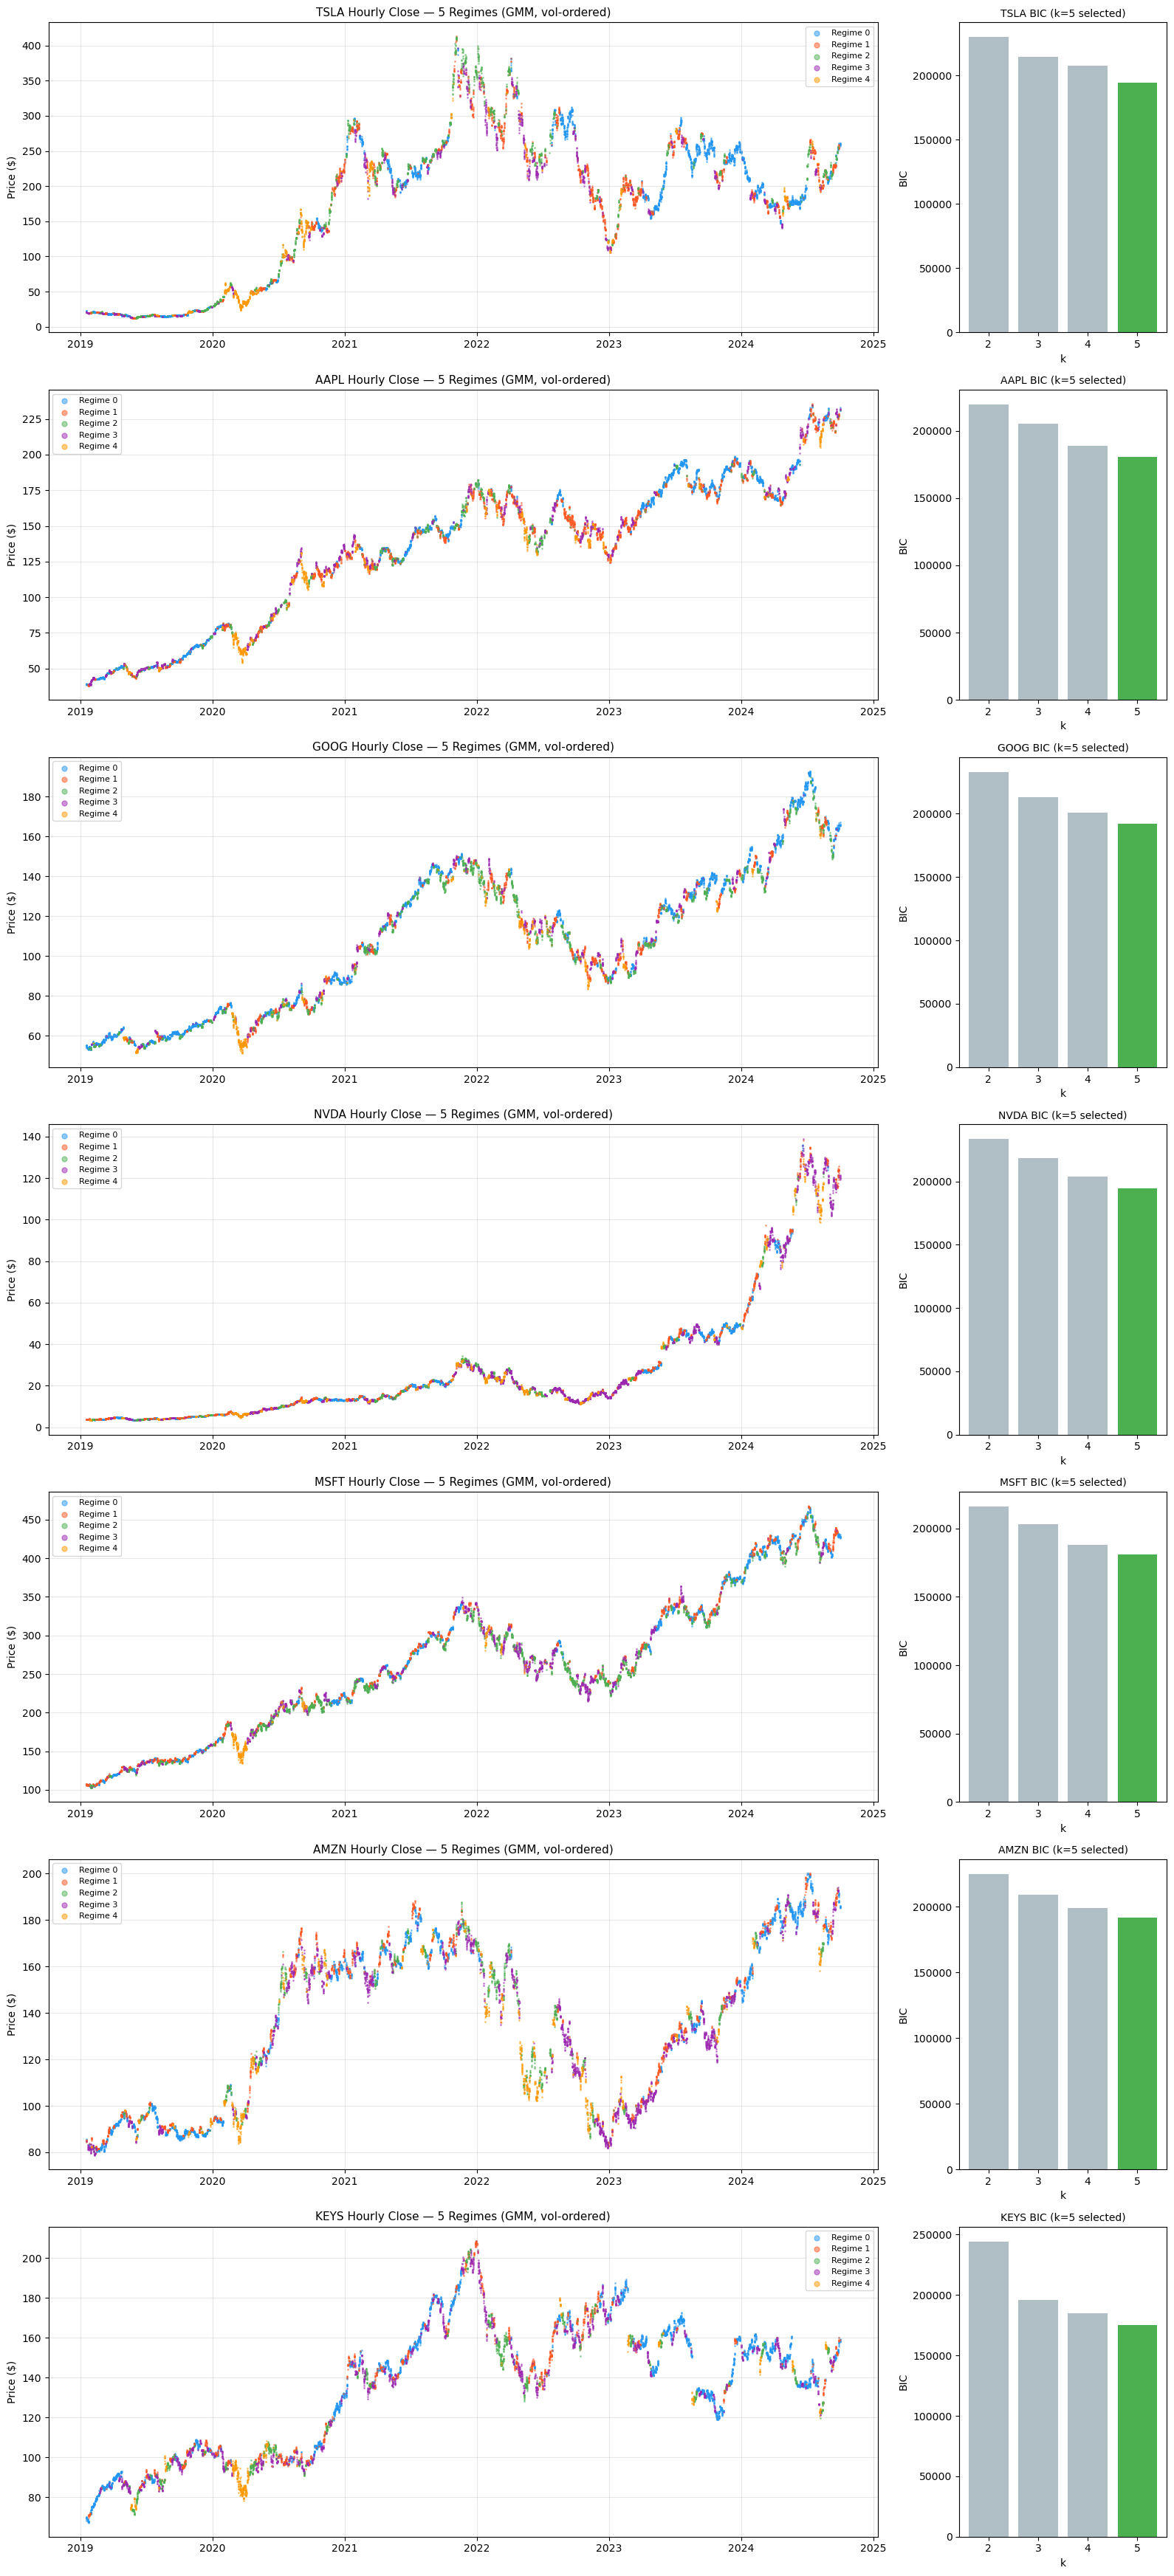


TSLA per-regime stats:
  Regime 0 (3,326 bars): mean_ret=0.0060%  vol=0.8845%  avg_volume=13,168,694
  Regime 1 (2,831 bars): mean_ret=0.0061%  vol=1.0810%  avg_volume=14,999,575
  Regime 2 (1,707 bars): mean_ret=0.3107%  vol=1.6525%  avg_volume=17,543,033
  Regime 3 (1,239 bars): mean_ret=-0.3368%  vol=1.8892%  avg_volume=19,102,984
  Regime 4 (841 bars): mean_ret=0.1093%  vol=2.5136%  avg_volume=29,941,261

AAPL per-regime stats:
  Regime 0 (3,293 bars): mean_ret=0.0299%  vol=0.3847%  avg_volume=8,544,999
  Regime 1 (3,109 bars): mean_ret=-0.0199%  vol=0.5471%  avg_volume=10,067,993
  Regime 2 (1,052 bars): mean_ret=-0.0355%  vol=0.8887%  avg_volume=10,804,045
  Regime 3 (1,536 bars): mean_ret=0.1826%  vol=0.9039%  avg_volume=13,305,471
  Regime 4 (887 bars): mean_ret=-0.1129%  vol=1.2898%  avg_volume=17,985,176

GOOG per-regime stats:
  Regime 0 (4,149 bars): mean_ret=0.0311%  vol=0.4420%  avg_volume=2,678,645
  Regime 1 (2,070 bars): mean_ret=0.0026%  vol=0.6132%  avg_volume=2,987

In [56]:
# ---------------------------------------------------------------------------
# Cell 10b — Component 1: Per-Ticker Regime Classifier  [Option B]
# ---------------------------------------------------------------------------

def engineer_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """15 OHLCV-derived regime features. No future leakage."""
    out = pd.DataFrame(index=df.index)
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low']  - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)

    out['atr_14']           = tr.rolling(14).mean() / df['Close']
    out['atr_56']           = tr.rolling(56).mean() / df['Close']
    out['atr_ratio']        = out['atr_14'] / out['atr_56'].replace(0, np.nan)
    log_ret                 = np.log(df['Close'] / df['Close'].shift(1))
    out['realized_vol_20']  = log_ret.rolling(20).std()
    out['realized_vol_60']  = log_ret.rolling(60).std()
    out['vol_regime_ratio'] = out['realized_vol_20'] / out['realized_vol_60'].replace(0, np.nan)

    sma20 = df['Close'].rolling(20).mean()
    std20 = df['Close'].rolling(20).std()
    out['bb_bandwidth']     = (2 * std20) / sma20.replace(0, np.nan)
    out['bb_position']      = (df['Close'] - (sma20 - 2*std20)) / (4*std20).replace(0, np.nan)
    # FIX: normalise slope by window mean, not current-bar close
    out['sma_slope']        = sma20.rolling(10).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0] / x.mean(), raw=True)
    out['ret_skew']         = log_ret.rolling(20).skew()
    # FIX: use built-in .kurt() — consistent with .skew(), ~100x faster than apply/raw=False
    out['ret_kurt']         = log_ret.rolling(20).kurt()

    vol_sma14               = df['Volume'].rolling(14).mean()
    out['volume_ratio']     = df['Volume'] / vol_sma14.replace(0, np.nan)
    log_vol                 = np.log1p(df['Volume'])
    out['volume_trend']     = log_vol.rolling(20).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True)
    out['avg_range_7']      = ((df['High'] - df['Low']) / df['Close']).rolling(7).mean()
    body_ratio              = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low']).replace(0, np.nan)
    out['avg_body_ratio_7'] = body_ratio.rolling(7).mean()

    return out.dropna()


# ── Per-ticker loop ────────────────────────────────────────────────────────
regime_store = {}   # {ticker: {features, labels, regime_series, k, gmm, scaler, bic, xgb_proxy, ohlcv}}

for ticker, csv_path in HOURLY_CSV.items():
    print(f"\n{'─'*55}")
    print(f"  {ticker}")
    print(f"{'─'*55}")

    try:
        # 1. Load hourly
        df_h = pd.read_csv(csv_path, parse_dates=['Date'])
        df_h = df_h.sort_values('Date').set_index('Date')
        df_h.columns = [c.strip() for c in df_h.columns]
        print(f"  Hourly bars : {len(df_h)}  ({df_h.index.min().date()} → {df_h.index.max().date()})")

        # 2. Engineer features
        feat = engineer_regime_features(df_h)
        print(f"  Regime features: {feat.shape}  (warmup dropped: {len(df_h)-len(feat)} bars)")

        # 3. Scale + BIC selection
        scaler = StandardScaler()
        X = scaler.fit_transform(feat)

        bic_scores, gmm_models = {}, {}
        for k in range(REGIME_K_RANGE[0], REGIME_K_RANGE[1] + 1):
            gmm = GaussianMixture(n_components=k, covariance_type='full',
                                  n_init=5, max_iter=300, random_state=REGIME_RANDOM_STATE)
            gmm.fit(X)
            bic_scores[k] = gmm.bic(X)
            gmm_models[k] = gmm

        k_best   = min(bic_scores, key=bic_scores.get)
        gmm_best = gmm_models[k_best]
        labels   = gmm_best.predict(X)

        # FIX: use numpy indexing — avoids ambiguous .loc with numpy boolean on DatetimeIndex
        feat_vol    = feat['realized_vol_20'].values
        cluster_vol = [feat_vol[labels == r].mean() for r in range(k_best)]
        order       = np.argsort(cluster_vol)
        label_map   = {old: new for new, old in enumerate(order)}
        labels      = np.array([label_map[l] for l in labels])

        regime_series = pd.Series(labels, index=feat.index, name='regime_label')
        print(f"  k_best={k_best}  |  regime dist: {pd.Series(labels).value_counts().sort_index().to_dict()}")

        # 4. XGBoost proxy — FIX: fit a fresh GMM per CV fold to avoid label leakage
        tscv_r     = TimeSeriesSplit(n_splits=5)
        proxy_accs = []
        for tr_i, val_i in tscv_r.split(X):
            # Fit GMM on train fold only
            gmm_fold = GaussianMixture(
                n_components=k_best, covariance_type='full',
                n_init=3, max_iter=300, random_state=REGIME_RANDOM_STATE
            )
            gmm_fold.fit(X[tr_i])
            fold_lbl_tr  = gmm_fold.predict(X[tr_i])
            fold_lbl_val = gmm_fold.predict(X[val_i])

            # Vol-order fold labels consistently
            fold_cv  = [feat_vol[tr_i][fold_lbl_tr == r].mean() for r in range(k_best)]
            fold_ord = np.argsort(fold_cv)
            fold_map = {old: new for new, old in enumerate(fold_ord)}
            fold_lbl_tr  = np.array([fold_map[l] for l in fold_lbl_tr])
            fold_lbl_val = np.array([fold_map[l] for l in fold_lbl_val])

            xgb_fold = XGBClassifier(
                n_estimators=100, max_depth=3, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, eval_metric='mlogloss'
            )
            xgb_fold.fit(X[tr_i], fold_lbl_tr)
            proxy_accs.append((xgb_fold.predict(X[val_i]) == fold_lbl_val).mean())

        # Refit final proxy on full labelled data
        xgb_proxy = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='mlogloss'
        )
        xgb_proxy.fit(X, labels)
        print(f"  XGBoost proxy CV acc: {np.mean(proxy_accs):.3f} ± {np.std(proxy_accs):.3f}")

        # FIX: store only the aligned slice needed for viz/stats — not the full df_h
        # FIX: alignment via feat.index (not fragile iloc[-len(labels):])
        regime_store[ticker] = {
            'features':      feat,
            'labels':        labels,
            'regime_series': regime_series,
            'k':             k_best,
            'gmm':           gmm_best,
            'scaler':        scaler,
            'bic':           bic_scores,
            'xgb_proxy':     xgb_proxy,
            'ohlcv':         df_h.loc[feat.index, ['Open', 'High', 'Low', 'Close', 'Volume']],
        }

    except Exception as e:
        print(f"  WARNING: {ticker} skipped — {e}")
        continue

# FIX: always assign after loop — not conditionally inside it (stale on re-run otherwise)
REGIME_FEATURE_COLS = next(iter(regime_store.values()))['features'].columns.tolist() if regime_store else []


# ── Visualization: one row per ticker ─────────────────────────────────────
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
n      = len(regime_store)
fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n),
                         gridspec_kw={'width_ratios': [4, 1]})
if n == 1:
    axes = [axes]

for row, (ticker, store) in enumerate(regime_store.items()):
    feat   = store['features']
    labels = store['labels']
    k      = store['k']        # FIX: single variable — removed duplicate k_best
    bic    = store['bic']
    price  = store['ohlcv']['Close']

    ax = axes[row][0]
    for r in range(k):
        mask = labels == r
        ax.scatter(feat.index[mask], price.values[mask],
                   c=colors[r % len(colors)], s=1, alpha=0.5, label=f'Regime {r}')
    ax.set_title(f'{ticker} Hourly Close — {k} Regimes (GMM, vol-ordered)', fontsize=11)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=8, markerscale=5)
    ax.grid(alpha=0.3)

    ax2 = axes[row][1]
    ks = sorted(bic.keys())
    bar_colors = ['#4CAF50' if kk == k else '#B0BEC5' for kk in ks]
    ax2.bar(ks, [bic[kk] for kk in ks], color=bar_colors)
    ax2.set_title(f'{ticker} BIC (k={k} selected)', fontsize=10)
    ax2.set_xlabel('k')
    ax2.set_ylabel('BIC')
    ax2.set_xticks(ks)

plt.tight_layout()
plt.show()


# ── Per-regime stats ───────────────────────────────────────────────────────
for ticker, store in regime_store.items():
    labels = store['labels']
    k      = store['k']
    ohlcv  = store['ohlcv'].copy()          # already aligned to feat.index
    ohlcv['regime']  = labels
    ohlcv['log_ret'] = np.log(ohlcv['Close'] / ohlcv['Close'].shift(1))

    print(f"\n{ticker} per-regime stats:")
    for r in range(k):
        sub = ohlcv[ohlcv['regime'] == r]
        print(f"  Regime {r} ({len(sub):,} bars): "
              f"mean_ret={sub['log_ret'].mean()*100:.4f}%  "
              f"vol={sub['log_ret'].std()*100:.4f}%  "
              f"avg_volume={sub['Volume'].mean():,.0f}")

regime_summary = {t: f"k={s['k']}" for t, s in regime_store.items()}
print(f"\nregime_store ready: {regime_summary}")


In [57]:
# ---------------------------------------------------------------------------
# Cell 10c — Feature Assembly  [multi-ticker: WITH vs NO MIDAS split]
# ---------------------------------------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor


def _strip_tz(idx):
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.to_datetime(idx)
    return idx.tz_convert(None) if idx.tz is not None else idx


def _load_sweeps(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, format='mixed')
    df = df.sort_values('timestamp').reset_index(drop=True)
    df = df[df['outcome'] != 'TIMEOUT'].reset_index(drop=True)
    return df


def _apply_dollar_normalisation(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    ref = out['zone_level']
    candle = out['candle_total_range'].replace(0, np.nan)

    out['reversal_distance_pct'] = out['reversal_distance'] / ref
    out['candle_range_pct'] = out['candle_total_range'] / ref
    out['body_ratio'] = out['candle_body'] / candle
    out['lower_wick_ratio'] = out['lower_wick'] / candle
    out['upper_wick_ratio'] = out['upper_wick'] / candle

    out['log_touchcount'] = np.log1p(out['zone_accumulated_touch_count'])
    out['log_touches_at_inversion'] = np.log1p(out['touches_at_inversion'])
    return out


# ── Step 1: Load sweeps (teacher WITH MIDAS, student NO MIDAS) ─────────────
df_teacher = _load_sweeps(SWEEPS_WITH_MIDAS_CSV)
df_student = _load_sweeps(SWEEPS_NO_MIDAS_CSV)

for name, df in [("teacher", df_teacher), ("student", df_student)]:
    if 'sweep_id' not in df.columns:
        raise KeyError(f"{name} sweeps missing sweep_id — cannot align teacher/student")

# Align rows by sweep_id to guarantee identical samples/order
teacher_idx = df_teacher.set_index('sweep_id', drop=False)
student_idx = df_student.set_index('sweep_id', drop=False)
common_ids = teacher_idx.index.intersection(student_idx.index)

if len(common_ids) == 0:
    raise ValueError("No overlapping sweep_id between WITH_MIDAS and NO_MIDAS sweeps")

teacher_idx = teacher_idx.loc[common_ids].copy()
student_idx = student_idx.loc[common_ids].copy()

# Use teacher timestamps as the canonical ordering
teacher_idx = teacher_idx.sort_values('timestamp')
student_idx = student_idx.reindex(teacher_idx['sweep_id'].values)

# Back to row-indexed frames
df_teacher = teacher_idx.reset_index(drop=True)
df_student = student_idx.reset_index(drop=True)

# Sanity checks
if not (df_teacher['timestamp'].values == df_student['timestamp'].values).all():
    raise AssertionError("Teacher/student timestamps misaligned after sweep_id alignment")
if not (df_teacher['ticker'].astype(str).values == df_student['ticker'].astype(str).values).all():
    raise AssertionError("Teacher/student tickers misaligned after sweep_id alignment")
if not (df_teacher['outcome'].astype(str).values == df_student['outcome'].astype(str).values).all():
    raise AssertionError("Teacher/student outcomes misaligned after sweep_id alignment")

# Target from teacher (identical to student post-check)
y = (df_teacher['outcome'] == 'WIN').astype(int).values

print(f"Teacher sweeps (WITH MIDAS) after TIMEOUT exclusion : {len(df_teacher)}")
print(f"Student sweeps (NO MIDAS) after TIMEOUT exclusion  : {len(df_student)}")
print(f"Label distribution                                 : WIN={y.sum()}  LOSS={len(y)-y.sum()}")
print(f"Tickers                                            : {df_teacher['ticker'].value_counts().to_dict()}")


# ── Step 2: Dollar normalisation (both) ───────────────────────────────────
df_teacher = _apply_dollar_normalisation(df_teacher)
df_student = _apply_dollar_normalisation(df_student)
print("\nDollar normalisation done")


# ── Step 3: Load & join consolidated MIDAS (teacher only) ─────────────────
df_midas = pd.read_csv(MIDAS_CSV)
df_midas['date'] = pd.to_datetime(df_midas['date'], dayfirst=True).dt.normalize()
# sort before rolling — prevents future-data leakage if CSV is not pre-sorted
df_midas = df_midas.sort_values(['ticker', 'date']).reset_index(drop=True)

for col in MIDAS_ROLLING_COLS:
    df_midas[f'{col}_5d'] = df_midas.groupby('ticker')[col].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    df_midas[f'{col}_ratio'] = df_midas[col] / df_midas[f'{col}_5d'].replace(0, np.nan)

midas_join_cols = ['ticker', 'date'] + MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

df_teacher['sweep_date'] = df_teacher['timestamp'].dt.normalize()
df_teacher = df_teacher.merge(
    df_midas[midas_join_cols],
    left_on=['ticker', 'sweep_date'],
    right_on=['ticker', 'date'],
    how='left',
)
# drop date columns created by the merge
# (keep timestamp; keep sweep_id)
df_teacher.drop(columns=['sweep_date', 'date'], inplace=True)

null_midas = df_teacher[MIDAS_FEATURES_RAW].isna().sum().sum()
print(f"MIDAS join null values (teacher): {null_midas}  (expect 0)")
print(
    "MIDAS coverage by ticker (teacher sweeps with all RAW cols non-null):\n"
    f"{df_teacher.groupby('ticker')[MIDAS_FEATURES_RAW].apply(lambda g: g.notna().all(axis=1).sum())}"
)


# ── Step 4: Ticker encoding (teacher only; optional feature) ──────────────
le_ticker = LabelEncoder()
df_teacher['ticker_enc'] = le_ticker.fit_transform(df_teacher['ticker'])
print(f"\nTicker encoding: {dict(zip(le_ticker.classes_, le_ticker.transform(le_ticker.classes_)))}")


# ── Step 5: Per-ticker regime assignment (both) ───────────────────────────
max_k = max(s['k'] for s in regime_store.values())
regime_frac_cols = [f'regime_{r}_frac' for r in range(max_k)]


def assign_regime_from_store(sweeps_df, regime_store, lookback_bars=7, max_k=3):
    """Vectorised regime assignment via merge_asof."""
    frac_cols = [f'regime_{r}_frac' for r in range(max_k)]

    regime_frames = []
    for ticker, store in regime_store.items():
        rs = store['regime_series'].copy()
        rs.index = _strip_tz(rs.index)
        k = store['k']

        tmp = pd.DataFrame({
            'timestamp': rs.index,
            'regime_label': rs.values,
            'ticker': ticker,
        })
        for r in range(k):
            tmp[f'regime_{r}_frac'] = (
                pd.Series((rs == r).values.astype(float))
                .rolling(lookback_bars, min_periods=1)
                .mean()
                .values
            )
        for r in range(k, max_k):
            tmp[f'regime_{r}_frac'] = 0.0
        regime_frames.append(tmp)

    if not regime_frames:
        out = sweeps_df.copy()
        out['regime_label'] = -1
        for col in frac_cols:
            out[col] = 0.0
        return out

    regime_table = pd.concat(regime_frames, ignore_index=True).sort_values(['ticker', 'timestamp'])

    ts_series = pd.to_datetime(sweeps_df['timestamp'])
    ts_stripped = ts_series.dt.tz_convert(None) if ts_series.dt.tz is not None else ts_series

    sweeps_work = sweeps_df.copy()
    sweeps_work['_ts'] = ts_stripped
    sweeps_work = sweeps_work.sort_values('_ts')

    merge_cols = ['_ts', 'regime_label'] + frac_cols
    results = []

    for ticker, grp in sweeps_work.groupby('ticker', sort=False):
        if ticker not in regime_store:
            grp = grp.copy()
            grp['regime_label'] = -1
            for col in frac_cols:
                grp[col] = 0.0
            results.append(grp)
            continue

        rt = regime_table[regime_table['ticker'] == ticker].rename(columns={'timestamp': '_ts'})
        merged = pd.merge_asof(grp, rt[merge_cols], on='_ts', direction='backward')
        results.append(merged)

    out = pd.concat(results).sort_index().drop(columns=['_ts'])
    out['regime_label'] = out['regime_label'].fillna(-1).astype(int)
    for col in frac_cols:
        out[col] = out[col].fillna(0.0)
    return out


df_teacher = assign_regime_from_store(df_teacher, regime_store, max_k=max_k)
df_student = assign_regime_from_store(df_student, regime_store, max_k=max_k)

print("\nRegime assigned (teacher):")
print(df_teacher.groupby(['ticker', 'regime_label']).size().unstack(fill_value=0))


# ── Step 6: Encode categoricals consistently (fit on teacher, mirror to student)
cat_encoded_cols = []
for col in SWEEP_CAT:
    if col not in df_teacher.columns:
        print(f"  WARNING: {col} not found in teacher, skipping")
        continue

    dummies_t = pd.get_dummies(df_teacher[col].astype(str), prefix=col, drop_first=True)
    for dc in dummies_t.columns:
        df_teacher[dc] = dummies_t[dc].values
        cat_encoded_cols.append(dc)

    # Student: reindex to teacher dummy columns
    if col in df_student.columns:
        dummies_s = pd.get_dummies(df_student[col].astype(str), prefix=col, drop_first=True)
        dummies_s = dummies_s.reindex(columns=dummies_t.columns, fill_value=0)
        for dc in dummies_t.columns:
            df_student[dc] = dummies_s[dc].values
    else:
        for dc in dummies_t.columns:
            df_student[dc] = 0

for col in SWEEP_BOOL:
    if col in df_teacher.columns:
        df_teacher[col] = df_teacher[col].astype(int)
    if col in df_student.columns:
        df_student[col] = df_student[col].astype(int)

print(f"\nCategorical encoding: {len(cat_encoded_cols)} dummy columns")


# ── Step 7: Build feature matrices ────────────────────────────────────────
shared_features = (
    SWEEP_NUMERIC
    + SWEEP_BOOL
    + cat_encoded_cols
    + ['regime_label']
    + regime_frac_cols
)

teacher_features = shared_features + MIDAS_FEATURES + TICKER_FEATURE
student_features = [f for f in shared_features if f not in MIDAS_LEAKAGE_COLS]


def _coerce_and_fill(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in feature_cols:
        if col not in out.columns:
            continue
        out[col] = pd.to_numeric(out[col], errors='coerce')
        if out[col].isna().any():
            is_binary = col in (SWEEP_BOOL + cat_encoded_cols)
            fill = 0 if is_binary else out[col].median()
            out[col] = out[col].fillna(fill)
    return out


df_teacher = _coerce_and_fill(df_teacher, teacher_features)
df_student = _coerce_and_fill(df_student, student_features)


# ── Step 8: Feature selection (Spearman corr + VIF) ───────────────────────
def select_features(df, feature_cols, target, min_corr=0.05, vif_threshold=10.0):
    valid = [c for c in feature_cols if c in df.columns]
    corrs = df[valid + [target]].corr(method='spearman')[target].drop(target)
    relevant = corrs[corrs.abs() >= min_corr].index.tolist()

    if len(relevant) < 2:
        return relevant

    X_vif = df[relevant].copy().fillna(df[relevant].median())
    X_vif = (X_vif - X_vif.mean()) / X_vif.std().replace(0, 1)

    dropped = []
    while True:
        vif_vals = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        vif_data = pd.DataFrame({'feature': X_vif.columns, 'VIF': vif_vals})
        max_vif = vif_data['VIF'].max()
        if max_vif <= vif_threshold or len(X_vif.columns) <= 1:
            break
        worst = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        dropped.append((worst, round(max_vif, 1)))
        X_vif = X_vif.drop(columns=[worst])

    if dropped:
        print(f"  VIF dropped {len(dropped)}: {dropped}")
    return X_vif.columns.tolist()


# Teacher selection on teacher df; student selection on student df
try:
    df_teacher['_target'] = y
    df_student['_target'] = y

    print("\n── Teacher feature selection ──")
    teacher_selected = select_features(df_teacher, teacher_features, '_target')

    print("\n── Student feature selection ──")
    student_selected = select_features(df_student, student_features, '_target')
finally:
    df_teacher.drop(columns=['_target'], errors='ignore', inplace=True)
    df_student.drop(columns=['_target'], errors='ignore', inplace=True)


# Export canonical variables expected downstream
df_sweeps = df_teacher
df_sweeps_student = df_student

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student = df_sweeps_student[student_selected].values.astype(np.float64)

print(f"\n── Feature Summary ──")
print(f"Teacher : {X_teacher.shape[1]} features  (from {len(teacher_features)} candidates)")
print(f"Student : {X_student.shape[1]} features  (from {len(student_features)} candidates)")
print(f"Samples : {X_teacher.shape[0]}  (WIN={y.sum()}, LOSS={len(y)-y.sum()})")
print(f"\nTeacher-only : {sorted(set(teacher_selected) - set(student_selected))}")


Teacher sweeps (WITH MIDAS) after TIMEOUT exclusion : 379
Student sweeps (NO MIDAS) after TIMEOUT exclusion  : 379
Label distribution                                 : WIN=139  LOSS=240
Tickers                                            : {'NVDA': 69, 'MSFT': 64, 'AAPL': 63, 'AMZN': 53, 'GOOG': 47, 'TSLA': 44, 'KEYS': 39}

Dollar normalisation done
MIDAS join null values (teacher): 0  (expect 0)
MIDAS coverage by ticker (teacher sweeps with all RAW cols non-null):
ticker
AAPL    63
AMZN    53
GOOG    47
KEYS    39
MSFT    64
NVDA    69
TSLA    44
dtype: int64

Ticker encoding: {'AAPL': np.int64(0), 'AMZN': np.int64(1), 'GOOG': np.int64(2), 'KEYS': np.int64(3), 'MSFT': np.int64(4), 'NVDA': np.int64(5), 'TSLA': np.int64(6)}

Regime assigned (teacher):
regime_label   0   1   2   3   4
ticker                          
AAPL          20  18  12   3  10
AMZN          14   7   7  20   5
GOOG          24   6  12   2   3
KEYS          11   6   3  15   4
MSFT          16  12  18  13   5
NVDA     

In [58]:
# ---------------------------------------------------------------------------
# Cell 10d — Temporal Cross-Validation Setup  [multi-ticker]
# ---------------------------------------------------------------------------

def temporal_cv_splits(n_samples, n_folds=N_CV_FOLDS, min_train=MIN_TRAIN_SIZE, purge=PURGE_GAP):
    """
    Expanding-window temporal CV with purge gap.
    Purge gap skips `purge` samples between train end and test start
    to prevent 2-day forward-window label leakage.
    Sorted by timestamp across all tickers — no per-ticker split needed.
    """
    test_size = (n_samples - min_train - purge) // n_folds
    if test_size < 1:
        raise ValueError(
            f"Not enough samples for CV: n_samples={n_samples}, min_train={min_train}, "
            f"purge={purge}, n_folds={n_folds}. "
            f"Need at least {min_train + purge + n_folds} samples."
        )

    splits = []
    for fold in range(n_folds):
        test_start = min_train + purge + fold * test_size
        test_end = min(test_start + test_size, n_samples)
        if fold == n_folds - 1:
            test_end = n_samples  # last fold absorbs remainder

        train_end = test_start - purge
        train_idx = list(range(0, train_end))
        test_idx = list(range(test_start, test_end))

        if len(train_idx) >= 10 and len(test_idx) >= 2:
            splits.append((np.array(train_idx), np.array(test_idx)))
    return splits


# ── Evaluation helpers ─────────────────────────────────────────────────────
def evaluate_model(y_true, y_prob, threshold=0.12):
    y_pred = (y_prob >= threshold).astype(int)
    tp = (y_pred.astype(bool) & y_true.astype(bool)).sum()
    return {
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        'brier': brier_score_loss(y_true, y_prob),
        'accuracy': (y_pred == y_true).mean(),
        'precision': tp / max(y_pred.sum(), 1),
        'recall': tp / max(y_true.sum(), 1),
        'n_test': len(y_true),
        'win_rate_actual': y_true.mean(),
    }


def aggregate_cv_metrics(fold_metrics):
    if not fold_metrics:
        raise ValueError(
            "aggregate_cv_metrics: no fold results to aggregate — "
            "check that cv_splits is non-empty and all folds completed"
        )
    keys = fold_metrics[0].keys()
    return {
        f'{k}_{s}': fn([m[k] for m in fold_metrics])
        for k in keys
        for s, fn in [('mean', np.mean), ('std', np.std)]
    }

print("Evaluation functions ready")


# ---------------------------------------------------------------------------
# Sort df_sweeps by timestamp and re-derive y and feature matrices
# ---------------------------------------------------------------------------

df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)

# Keep student in the same order as teacher
if 'sweep_id' in df_sweeps.columns and 'sweep_id' in df_sweeps_student.columns:
    df_sweeps_student = (
        df_sweeps_student.set_index('sweep_id', drop=False)
        .reindex(df_sweeps['sweep_id'].values)
        .reset_index(drop=True)
    )

# Re-derive targets + feature matrices
y = (df_sweeps['outcome'] != 'LOSS').astype(int).values

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student = df_sweeps_student[student_selected].values.astype(np.float64)

assert df_sweeps['timestamp'].is_monotonic_increasing
assert len(X_teacher) == len(X_student) == len(y)

# ── Reserve final 20% as true holdout before CV ───────────────────────────
holdout_start = int(len(df_sweeps) * 0.80)
train_idx_pool = np.arange(0, holdout_start)
test_idx_pool  = np.arange(holdout_start, len(df_sweeps))

df_sweeps["is_test_set"] = False
df_sweeps.loc[test_idx_pool, "is_test_set"] = True

y_train = y[train_idx_pool]

print(f"  Train pool  : {len(train_idx_pool)} sweeps  "
      f"({df_sweeps.iloc[0]['timestamp'].date()} → "
      f"{df_sweeps.iloc[holdout_start-1]['timestamp'].date()})")
print(f"  Holdout     : {len(test_idx_pool)} sweeps  "
      f"({df_sweeps.iloc[holdout_start]['timestamp'].date()} → "
      f"{df_sweeps.iloc[-1]['timestamp'].date()})")

# CV only runs on train pool
cv_splits = temporal_cv_splits(len(train_idx_pool))

print("── Temporal CV Splits ──")
print(f"Total samples : {len(y_train)}  |  Folds: {len(cv_splits)}  |  Purge gap: {PURGE_GAP}")
print()

for i, (tr, te) in enumerate(cv_splits):
    tr_dates = (
        df_sweeps.iloc[tr[0]]['timestamp'].strftime('%Y-%m-%d'),
        df_sweeps.iloc[tr[-1]]['timestamp'].strftime('%Y-%m-%d'),
    )
    te_dates = (
        df_sweeps.iloc[te[0]]['timestamp'].strftime('%Y-%m-%d'),
        df_sweeps.iloc[te[-1]]['timestamp'].strftime('%Y-%m-%d'),
    )

    tr_tickers = df_sweeps.iloc[tr]['ticker'].value_counts().to_dict()
    te_tickers = df_sweeps.iloc[te]['ticker'].value_counts().to_dict()

    print(
        f"  Fold {i}:  Train [{tr[0]:2d}:{tr[-1]:2d}] ({len(tr):2d} samples, "
        f"WR={y_train[tr].mean():.0%})  {tr_dates[0]} → {tr_dates[1]}  {tr_tickers}"
    )
    print(
        f"           Test  [{te[0]:2d}:{te[-1]:2d}] ({len(te):2d} samples, "
        f"WR={y_train[te].mean():.0%})  {te_dates[0]} → {te_dates[1]}  {te_tickers}"
    )

for i, (tr, te) in enumerate(cv_splits):
    excluded = te[0] - tr[-1] - 1
    assert excluded >= PURGE_GAP, (
        f"Fold {i}: purge violation! excluded={excluded}, required={PURGE_GAP}"
    )

    t_train_end = df_sweeps.iloc[train_idx_pool[tr[-1]]]['timestamp']
    t_test_start = df_sweeps.iloc[train_idx_pool[te[0]]]['timestamp']
    assert t_test_start > t_train_end, (
        f"Fold {i}: test starts ({t_test_start}) before train ends ({t_train_end}) — temporal leak!"
    )

print(
    f"\nLeakage check PASSED — all folds have >= {PURGE_GAP} excluded samples "
    f"and test timestamps strictly after train timestamps"
)


Evaluation functions ready
  Train pool  : 303 sweeps  (2019-02-07 → 2023-07-18)
  Holdout     : 76 sweeps  (2023-07-19 → 2024-09-18)
── Temporal CV Splits ──
Total samples : 303  |  Folds: 5  |  Purge gap: 3

  Fold 0:  Train [ 0:14] (15 samples, WR=27%)  2019-02-07 → 2019-08-14  {'AMZN': 6, 'NVDA': 3, 'TSLA': 2, 'MSFT': 2, 'GOOG': 1, 'KEYS': 1}
           Test  [18:74] (57 samples, WR=37%)  2019-09-18 → 2020-07-24  {'NVDA': 11, 'KEYS': 10, 'MSFT': 9, 'AAPL': 9, 'TSLA': 8, 'AMZN': 6, 'GOOG': 4}
  Fold 1:  Train [ 0:71] (72 samples, WR=36%)  2019-02-07 → 2020-07-23  {'NVDA': 13, 'AMZN': 12, 'MSFT': 12, 'TSLA': 10, 'KEYS': 10, 'AAPL': 9, 'GOOG': 6}
           Test  [75:131] (57 samples, WR=35%)  2020-07-28 → 2021-03-23  {'MSFT': 16, 'AAPL': 12, 'NVDA': 11, 'GOOG': 6, 'TSLA': 4, 'KEYS': 4, 'AMZN': 4}
  Fold 2:  Train [ 0:128] (129 samples, WR=36%)  2019-02-07 → 2021-03-17  {'MSFT': 26, 'NVDA': 24, 'AAPL': 21, 'AMZN': 16, 'TSLA': 15, 'KEYS': 15, 'GOOG': 12}
           Test  [132:188] (57 

Model                                 AUC        Brier        Acc       Prec        Rec
B1: Majority class            0.500±0.00   0.234±0.02   0.361±0.05   0.361±0.05   1.000±0.00
B2: Quality score             0.429±0.09   0.366±0.04   0.361±0.05   0.361±0.05   1.000±0.00
B3: LR (sweep only)           0.539±0.04   0.263±0.03   0.389±0.08   0.372±0.06   0.981±0.04
B4: LR (sweep+regime)         0.542±0.04   0.258±0.02   0.368±0.05   0.363±0.05   0.990±0.02
B5: Teacher LR                0.522±0.03   0.264±0.03   0.393±0.08   0.371±0.06   0.943±0.11
B6: Teacher XGB               0.545±0.08   0.242±0.01   0.361±0.05   0.361±0.05   1.000±0.00


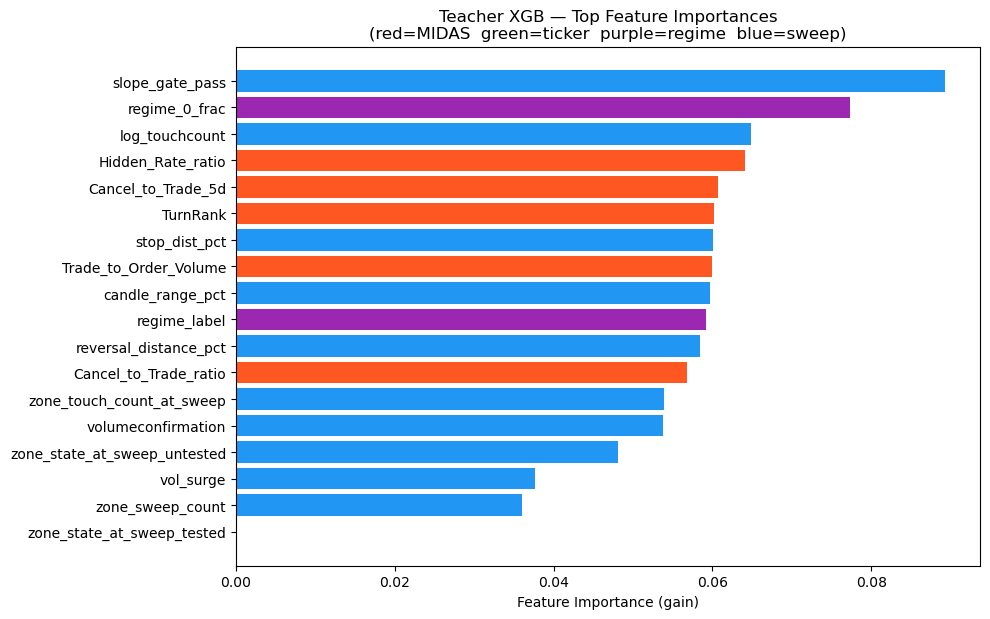


Teacher OOF predictions: 285/379 samples covered (75.2%)
  (samples in min_train window [94] are never in a test fold — will be excluded from distillation)

── Threshold-Tuned Results (F1-optimal, OOF) ─────────────────────────
Model                             AUC  Threshold    Precision     Recall       F1
B3: LR (sweep only)             0.539      0.122        0.370      0.981    0.537
B4: LR (sweep+regime)           0.542      0.201        0.375      0.990    0.544
B5: Teacher LR                  0.522      0.114        0.370      0.951    0.533
B6: Teacher XGB                 0.545      0.317        0.364      0.990    0.533
NOTE: Thresholds tuned on OOF predictions (in-sample). Directional only.


In [59]:
# ---------------------------------------------------------------------------
# Cell 10e — Component 2: Teacher Model Training + Evaluation
# ---------------------------------------------------------------------------

# FIX 1: always re-derive y here — regime_label=-1 can corrupt y if cells
# ran out of order or df_sweeps was mutated after Cell 10d
# Or try different thresholds:
y = (df_sweeps['outcome'] != 'LOSS').astype(int).values
SCALE_POS_WEIGHT = (y == 0).sum() / (y == 1).sum()

assert set(np.unique(y)) == {0, 1}, f"y has unexpected values: {np.unique(y)}"

# FIX 2: custom log_loss scorer that explicitly passes labels=[0,1]
# neg_log_loss crashes when an inner fold has only one class present
from sklearn.metrics import make_scorer, log_loss as _log_loss
_ll_scorer = make_scorer(
    # _log_loss, needs_proba=True, labels=[0, 1], greater_is_better=False
    _log_loss, response_method='predict_proba', labels=[0, 1], greater_is_better=False
)

from sklearn.model_selection import StratifiedKFold

teacher_oof_probs = np.full(len(y), np.nan)  # out-of-fold P(WIN) for distillation
all_results       = {}

# ── B1: Majority class ────────────────────────────────────────────────────
b1_metrics = []
for tr, te in cv_splits:
    y_prob = np.full(len(te), y[tr].mean())
    b1_metrics.append(evaluate_model(y[te], y_prob))
all_results['B1: Majority class'] = aggregate_cv_metrics(b1_metrics)

# ── B2: Quality score threshold ───────────────────────────────────────────
b2_metrics = []
for tr, te in cv_splits:
    # FIX: clip to [0,1] — scores outside range corrupt brier/auc silently
    y_prob = np.clip(df_sweeps.iloc[te]['sweep_quality_score'].values / 100.0, 0.0, 1.0)
    b2_metrics.append(evaluate_model(y[te], y_prob))
all_results['B2: Quality score'] = aggregate_cv_metrics(b2_metrics)

# ── B3: Logistic Regression — sweep features only (no regime, no MIDAS) ──
student_no_regime   = [f for f in student_selected
                       if f != 'regime_label' and not f.startswith('regime_')]
X_student_no_regime = df_sweeps[student_no_regime].values.astype(np.float64)

b3_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_student_no_regime[tr])
    X_te   = scaler.transform(X_student_no_regime[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b3_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B3: LR (sweep only)'] = aggregate_cv_metrics(b3_metrics)

# ── B4: Logistic Regression — sweep + regime (no MIDAS) ──────────────────
b4_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_student[tr])
    X_te   = scaler.transform(X_student[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b4_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B4: LR (sweep+regime)'] = aggregate_cv_metrics(b4_metrics)

# ── B5: Logistic Regression — sweep + MIDAS + regime + ticker ────────────
b5_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_teacher[tr])
    X_te   = scaler.transform(X_teacher[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b5_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B5: Teacher LR'] = aggregate_cv_metrics(b5_metrics)

# ── B6: XGBoost Teacher — sweep + MIDAS + regime + ticker  [PRIMARY] ─────
b6_metrics = []
for tr, te in cv_splits:
    n_val     = max(int(0.15 * len(tr)), 5)
    tr_inner  = tr[:-n_val]
    val_inner = tr[-n_val:]

    xgb = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        min_child_weight=5, subsample=0.7, colsample_bytree=0.5,
        reg_alpha=0.5, reg_lambda=2.0,
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=42, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb.fit(
        X_teacher[tr_inner], y[tr_inner],
        eval_set=[(X_teacher[val_inner], y[val_inner])],
        verbose=False
    )
    y_prob = xgb.predict_proba(X_teacher[te])[:, 1]
    b6_metrics.append(evaluate_model(y[te], y_prob))
    teacher_oof_probs[te] = y_prob

all_results['B6: Teacher XGB'] = aggregate_cv_metrics(b6_metrics)

# ── Print results (default threshold=0.5) ────────────────────────────────
print("=" * 95)
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Acc':>10} {'Prec':>10} {'Rec':>10}")
print("=" * 95)
for name, agg in all_results.items():
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}  "
          f"{agg['precision_mean']:6.3f}±{agg['precision_std']:.2f}  "
          f"{agg['recall_mean']:6.3f}±{agg['recall_std']:.2f}")
print("=" * 95)

# ── Teacher feature importance (refit on full data for plot only) ─────────
xgb_teacher_full = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    min_child_weight=5, subsample=0.7, colsample_bytree=0.5,
    reg_alpha=0.5, reg_lambda=2.0,
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=42, eval_metric='logloss'
)
xgb_teacher_full.fit(X_teacher[train_idx_pool], y[train_idx_pool], verbose=False)

feat_imp = sorted(zip(teacher_selected, xgb_teacher_full.feature_importances_),
                  key=lambda x: x[1], reverse=True)
top_n = min(20, len(feat_imp))
names = [f[0] for f in feat_imp[:top_n]][::-1]
vals  = [f[1] for f in feat_imp[:top_n]][::-1]

def feat_color(n):
    if n in MIDAS_FEATURES or n in MIDAS_FEATURES_DERIVED:  return '#FF5722'
    if n in TICKER_FEATURE:                                   return '#4CAF50'
    if n.startswith('regime_'):                               return '#9C27B0'
    return '#2196F3'

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
ax.barh(names, vals, color=[feat_color(n) for n in names])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Teacher XGB — Top Feature Importances\n'
             '(red=MIDAS  green=ticker  purple=regime  blue=sweep)')
plt.tight_layout()
plt.show()

oof_n        = np.sum(~np.isnan(teacher_oof_probs))
oof_coverage = oof_n / len(y)
print(f"\nTeacher OOF predictions: {oof_n}/{len(y)} samples covered ({oof_coverage:.1%})")
print(f"  (samples in min_train window [{len(y) - oof_n}] are never in a test fold — "
      f"will be excluded from distillation)")

assert oof_coverage >= 0.5, (
    f"Teacher OOF coverage too low: {oof_coverage:.1%}. "
    f"Increase n_samples or reduce MIN_TRAIN_SIZE / N_CV_FOLDS."
)

# ── FIX 3: Threshold tuning — XGB/Baseline models default to recall=0 ────
# With 12% WIN rate, default threshold=0.5 means no WIN is ever predicted.
# Find the F1-optimal threshold per model using OOF probabilities.
from sklearn.metrics import precision_recall_curve

b3_oof = np.full(len(y), np.nan)
b4_oof = np.full(len(y), np.nan)
b5_oof = np.full(len(y), np.nan)

for tr, te in cv_splits:
    scaler = StandardScaler()

    # B3
    X_tr = scaler.fit_transform(X_student_no_regime[tr])
    X_te = scaler.transform(X_student_no_regime[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b3_oof[te] = lr.predict_proba(X_te)[:, 1]

    # B4
    X_tr = scaler.fit_transform(X_student[tr])
    X_te = scaler.transform(X_student[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b4_oof[te] = lr.predict_proba(X_te)[:, 1]

    # B5
    X_tr = scaler.fit_transform(X_teacher[tr])
    X_te = scaler.transform(X_teacher[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b5_oof[te] = lr.predict_proba(X_te)[:, 1]

oof_map_teacher = {
    'B3: LR (sweep only)'   : b3_oof,
    'B4: LR (sweep+regime)' : b4_oof,
    'B5: Teacher LR'        : b5_oof,
    'B6: Teacher XGB'       : teacher_oof_probs,
}

print("\n── Threshold-Tuned Results (F1-optimal, OOF) ─────────────────────────")
print(f"{'Model':<28} {'AUC':>8} {'Threshold':>10} {'Precision':>12} {'Recall':>10} {'F1':>8}")
print("=" * 80)
for name, probs in oof_map_teacher.items():
    mask = ~np.isnan(probs)
    if mask.sum() == 0:
        continue
    p, r, t = precision_recall_curve(y[mask], probs[mask])
    f1       = 2 * p * r / (p + r + 1e-9)
    opt_t    = t[f1.argmax()]
    y_pred   = (probs[mask] >= opt_t).astype(int)
    tp       = (y_pred.astype(bool) & y[mask].astype(bool)).sum()
    prec_v   = tp / max(y_pred.sum(), 1)
    rec_v    = tp / max(y[mask].sum(), 1)
    f1_v     = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
    auc_v    = all_results[name]['auc_mean']
    print(f"{name:<28} {auc_v:>8.3f} {opt_t:>10.3f} {prec_v:>12.3f} {rec_v:>10.3f} {f1_v:>8.3f}")
print("=" * 80)
print("NOTE: Thresholds tuned on OOF predictions (in-sample). Directional only.")


── Student Model Results ──
Model                                 AUC        Brier        Acc
-----------------------------------------------------------------
S1: Student (hard labels)     0.502±0.06   0.235±0.01   0.361±0.05
S2: Student (α=0.5)           0.530±0.08   0.235±0.01   0.361±0.05
S3: Student (α=0.7)           0.516±0.06   0.234±0.01   0.361±0.05
S4: Student (α=1.0)           0.532±0.06   0.233±0.01   0.361±0.05


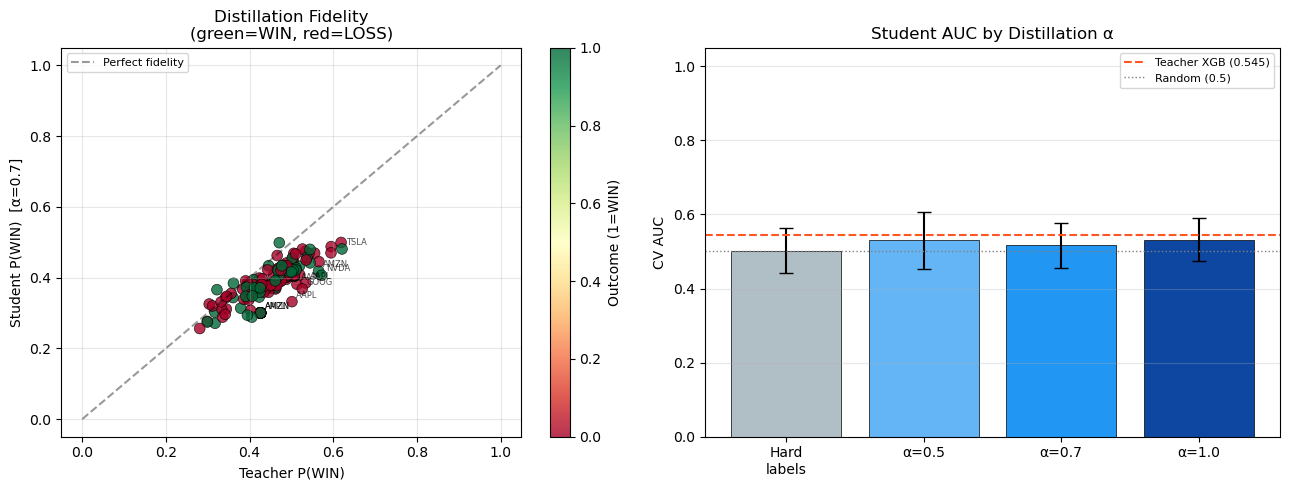


Distillation fidelity (Pearson r, S3 vs Teacher): 0.744


In [60]:
# ---------------------------------------------------------------------------
# Cell 10f — Component 3: Student Model Training (Knowledge Distillation)
# ---------------------------------------------------------------------------

# ── S1: XGBoost on hard labels only (no distillation — baseline) ──────────
s1_metrics = []
for tr, te in cv_splits:
    # FIX: use inner hold-out from training fold for early stopping — not the test fold
    n_val     = max(int(0.15 * len(tr)), 5)
    tr_inner  = tr[:-n_val]
    val_inner = tr[-n_val:]

    xgb = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05,
        min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb.fit(X_student[tr_inner], y[tr_inner],
            eval_set=[(X_student[val_inner], y[val_inner])], verbose=False)
    s1_metrics.append(evaluate_model(y[te], xgb.predict_proba(X_student[te])[:, 1]))
all_results['S1: Student (hard labels)'] = aggregate_cv_metrics(s1_metrics)


# ── Distillation helper ────────────────────────────────────────────────────
def train_distilled_student(X_stu, y_hard, teacher_oof, cv_splits, alpha):
    """
    XGBRegressor on blended soft targets:
        target = alpha * teacher_prob + (1 - alpha) * hard_label
    Evaluated against hard labels (ground truth).
    Early stopping uses an inner hold-out from the training fold only —
    test fold is never touched during fitting.
    """
    fold_metrics = []
    oof_preds    = np.full(len(y_hard), np.nan)

    for tr, te in cv_splits:
        # FIX: split training fold into inner train + inner val for early stopping.
        # Original code passed soft_te (which embeds y_hard[te]) to eval_set —
        # ground-truth test labels were leaking directly into the early stopping signal.
        n_val     = max(int(0.15 * len(tr)), 5)
        tr_inner  = tr[:-n_val]
        val_inner = tr[-n_val:]

        # Soft targets for inner train
        t_tr = teacher_oof[tr_inner].copy()
        t_tr[np.isnan(t_tr)] = y_hard[tr_inner][np.isnan(t_tr)].astype(float)
        soft_tr = alpha * t_tr + (1 - alpha) * y_hard[tr_inner].astype(float)

        # Soft targets for inner val (early stopping signal — no test data)
        t_val = teacher_oof[val_inner].copy()
        t_val[np.isnan(t_val)] = y_hard[val_inner][np.isnan(t_val)].astype(float)
        soft_val = alpha * t_val + (1 - alpha) * y_hard[val_inner].astype(float)

        student = XGBRegressor(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=42,
            eval_metric='mae',           # FIX: explicit — mae more appropriate than default rmse for [0,1] targets
            early_stopping_rounds=20
        )
        student.fit(X_stu[tr_inner], soft_tr,
                    eval_set=[(X_stu[val_inner], soft_val)], verbose=False)

        y_prob = np.clip(student.predict(X_stu[te]), 0, 1)
        oof_preds[te] = y_prob
        fold_metrics.append(evaluate_model(y_hard[te], y_prob))

    return fold_metrics, oof_preds


# ── S2: alpha=0.5 ─────────────────────────────────────────────────────────
s2_metrics, s2_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.5)
all_results['S2: Student (α=0.5)'] = aggregate_cv_metrics(s2_metrics)

# ── S3: alpha=0.7 (recommended) ───────────────────────────────────────────
s3_metrics, s3_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.7)
all_results['S3: Student (α=0.7)'] = aggregate_cv_metrics(s3_metrics)

# ── S4: alpha=1.0 (pure distillation) ────────────────────────────────────
s4_metrics, s4_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=1.0)
all_results['S4: Student (α=1.0)'] = aggregate_cv_metrics(s4_metrics)


# ── Student results table ──────────────────────────────────────────────────
print("── Student Model Results ──")
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Acc':>10}")
print("-" * 65)
for name in ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
             'S3: Student (α=0.7)',       'S4: Student (α=1.0)']:
    agg = all_results[name]
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}")


# ── Distillation fidelity scatter (S3 vs Teacher OOF) ────────────────────
mask = ~np.isnan(teacher_oof_probs) & ~np.isnan(s3_oof)
if mask.sum() > 5:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    sc = ax.scatter(teacher_oof_probs[mask], s3_oof[mask],
                    c=y[mask], cmap='RdYlGn', alpha=0.8,
                    edgecolors='k', linewidths=0.5, s=60,
                    vmin=0, vmax=1)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect fidelity')

    # FIX: only annotate the 10 points furthest from the diagonal (biggest misses)
    # — annotating all points produces completely unreadable overlapping text
    masked_idx  = np.where(mask)[0]
    residuals   = np.abs(teacher_oof_probs[masked_idx] - s3_oof[masked_idx])
    top_outliers = masked_idx[np.argsort(residuals)[-10:]]
    for idx in top_outliers:
        ax.annotate(df_sweeps.iloc[idx]['ticker'],
                    (teacher_oof_probs[idx], s3_oof[idx]),
                    fontsize=6, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    plt.colorbar(sc, ax=ax, label='Outcome (1=WIN)')
    ax.set_xlabel('Teacher P(WIN)')
    ax.set_ylabel('Student P(WIN)  [α=0.7]')
    ax.set_title('Distillation Fidelity\n(green=WIN, red=LOSS)')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    alphas    = ['Hard\nlabels', 'α=0.5', 'α=0.7', 'α=1.0']
    keys      = ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
                 'S3: Student (α=0.7)',        'S4: Student (α=1.0)']
    auc_means = [all_results[k]['auc_mean'] for k in keys]
    auc_stds  = [all_results[k]['auc_std']  for k in keys]
    bar_colors = ['#B0BEC5', '#64B5F6', '#2196F3', '#0D47A1']
    # FIX: removed dead `bars =` assignment
    ax2.bar(alphas, auc_means, yerr=auc_stds, color=bar_colors,
            capsize=5, edgecolor='k', linewidth=0.5)
    ax2.axhline(all_results['B6: Teacher XGB']['auc_mean'],
                color='#FF5722', linestyle='--', linewidth=1.5,
                label=f"Teacher XGB ({all_results['B6: Teacher XGB']['auc_mean']:.3f})")
    ax2.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random (0.5)')
    ax2.set_ylabel('CV AUC')
    ax2.set_title('Student AUC by Distillation α')
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    fidelity = np.corrcoef(teacher_oof_probs[mask], s3_oof[mask])[0, 1]
    print(f"\nDistillation fidelity (Pearson r, S3 vs Teacher): {fidelity:.3f}")
else:
    print("\nInsufficient OOF overlap for fidelity plot")


Model                                 AUC        Brier     Accuracy    Precision       Recall
B1: Majority class            0.500±0.00   0.234±0.02   0.361±0.05   0.361±0.05   1.000±0.00
B2: Quality score             0.429±0.09   0.366±0.04   0.361±0.05   0.361±0.05   1.000±0.00
B3: LR (sweep only)           0.539±0.04   0.263±0.03   0.389±0.08   0.372±0.06   0.981±0.04
B4: LR (sweep+regime)         0.542±0.04   0.258±0.02   0.368±0.05   0.363±0.05   0.990±0.02
B5: Teacher LR                0.522±0.03   0.264±0.03   0.393±0.08   0.371±0.06   0.943±0.11
B6: Teacher XGB               0.545±0.08   0.242±0.01   0.361±0.05   0.361±0.05   1.000±0.00 ◀
S1: Student (hard labels)     0.502±0.06   0.235±0.01   0.361±0.05   0.361±0.05   1.000±0.00
S2: Student (α=0.5)           0.530±0.08   0.235±0.01   0.361±0.05   0.361±0.05   1.000±0.00
S3: Student (α=0.7)           0.516±0.06   0.234±0.01   0.361±0.05   0.361±0.05   1.000±0.00
S4: Student (α=1.0)           0.532±0.06   0.233±0.01   0.361±0.05 

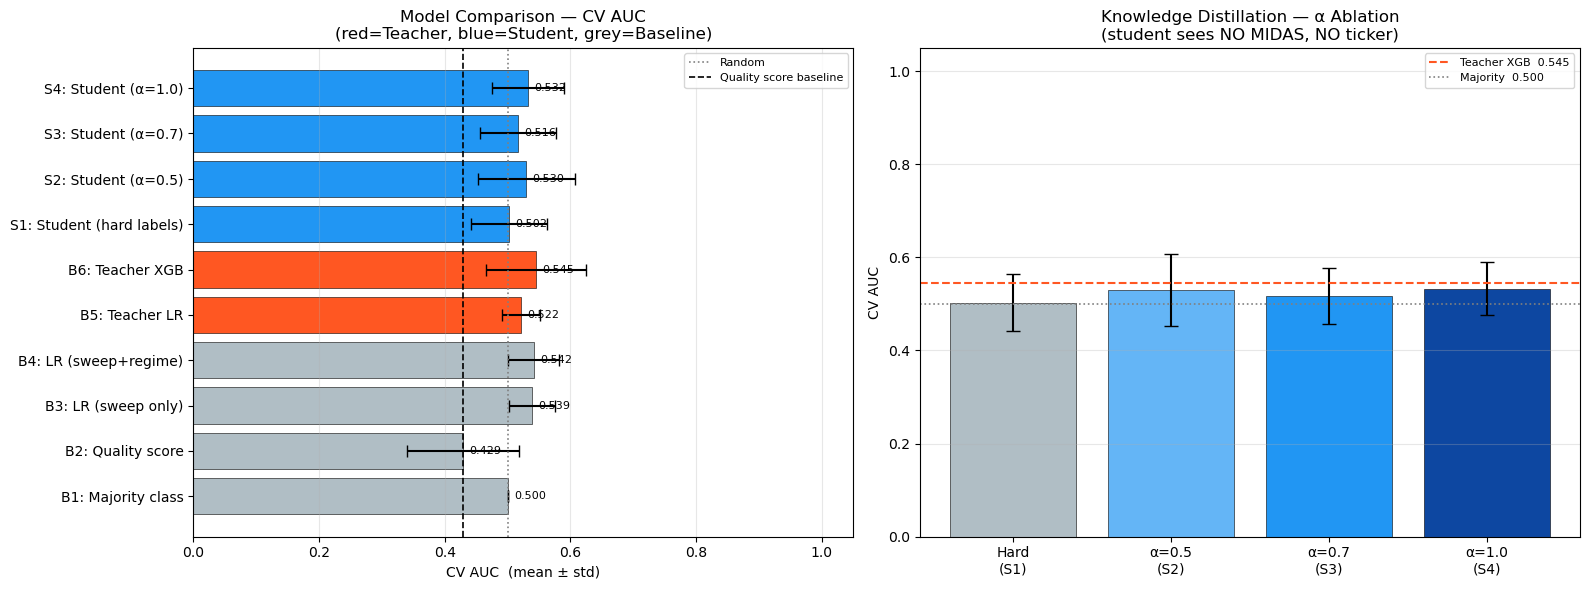

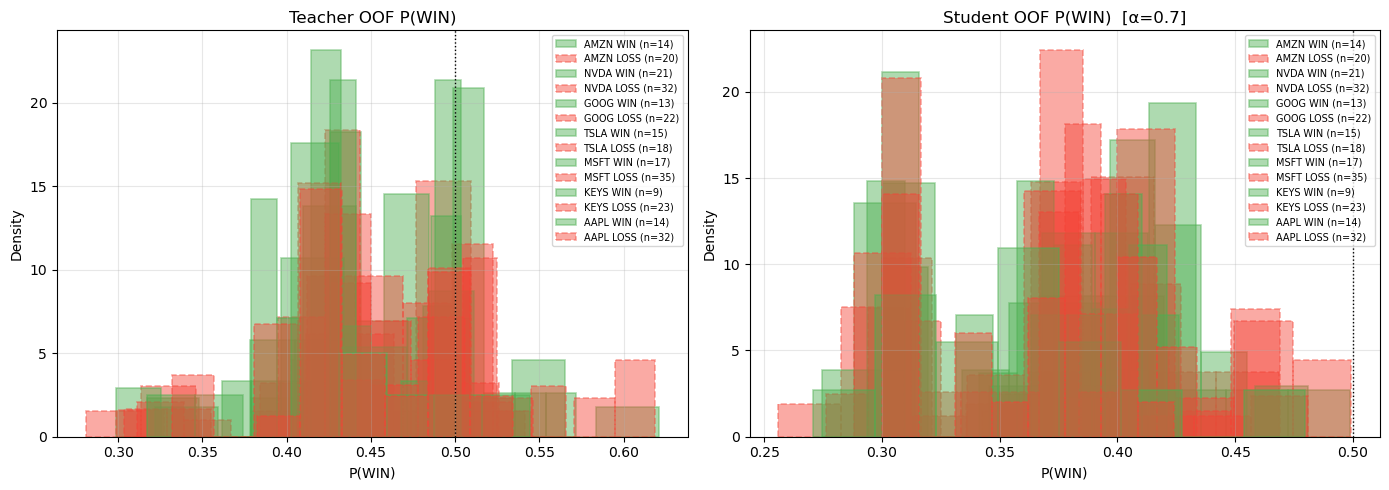


── Key Findings ──────────────────────────────────────────────────────
  Dataset          : 379 sweeps  ({'NVDA': 69, 'MSFT': 64, 'AAPL': 63, 'AMZN': 53, 'GOOG': 47, 'TSLA': 44, 'KEYS': 39})
  Label balance    : WIN=139  LOSS=240  (TIMEOUT excluded)
  Regime k         : {'TSLA': 5, 'AAPL': 5, 'GOOG': 5, 'NVDA': 5, 'MSFT': 5, 'AMZN': 5, 'KEYS': 5}

  Quality baseline : AUC 0.429
  Teacher XGB      : AUC 0.545  (↑0.115 vs baseline)
  Student α=0.7    : AUC 0.516  (↑0.087 vs baseline  |  gap to teacher: 0.028)
  Best model       : B6: Teacher XGB  (AUC 0.545)

  NOTE: N=36 — treat AUC std as primary signal, mean as indicative only.
        Add more tickers to reduce variance before drawing conclusions.


In [61]:
# ---------------------------------------------------------------------------
# Cell 10g — Results Summary, Ablation & Visualisations
# ---------------------------------------------------------------------------

model_order = [
    'B1: Majority class',
    'B2: Quality score',
    'B3: LR (sweep only)',
    'B4: LR (sweep+regime)',
    'B5: Teacher LR',
    'B6: Teacher XGB',
    'S1: Student (hard labels)',
    'S2: Student (α=0.5)',
    'S3: Student (α=0.7)',
    'S4: Student (α=1.0)',
]

# ── 1. Full comparison table ───────────────────────────────────────────────
print("=" * 105)
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12}")
print("=" * 105)
for name in model_order:
    if name not in all_results:
        continue
    agg = all_results[name]
    # Highlight best AUC
    marker = " ◀" if name == max(
        (n for n in model_order if n in all_results),
        key=lambda n: all_results[n]['auc_mean']
    ) else ""
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}  "
          f"{agg['precision_mean']:6.3f}±{agg['precision_std']:.2f}  "
          f"{agg['recall_mean']:6.3f}±{agg['recall_std']:.2f}{marker}")
print("=" * 105)

# ── 2. AUC comparison chart ────────────────────────────────────────────────
present   = [n for n in model_order if n in all_results]
auc_means = [all_results[n]['auc_mean'] for n in present]
auc_stds  = [all_results[n]['auc_std']  for n in present]

def bar_color(name):
    if 'Teacher' in name: return '#FF5722'
    if 'Student' in name: return '#2196F3'
    return '#B0BEC5'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bars = ax.barh(present, auc_means, xerr=auc_stds,
               color=[bar_color(n) for n in present],
               capsize=4, edgecolor='k', linewidth=0.4)
ax.axvline(0.5, color='gray',    linestyle=':', linewidth=1.2, label='Random')
ax.axvline(all_results['B2: Quality score']['auc_mean'],
           color='black', linestyle='--', linewidth=1.2, label='Quality score baseline')
ax.set_xlabel('CV AUC  (mean ± std)')
ax.set_title('Model Comparison — CV AUC\n(red=Teacher, blue=Student, grey=Baseline)')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, auc_means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# ── 3. Distillation gain: student vs teacher per alpha ────────────────────
ax2 = axes[1]
student_keys = ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
                'S3: Student (α=0.7)',        'S4: Student (α=1.0)']
x_labels = ['Hard\n(S1)', 'α=0.5\n(S2)', 'α=0.7\n(S3)', 'α=1.0\n(S4)']
s_aucs   = [all_results[k]['auc_mean'] for k in student_keys if k in all_results]
s_stds   = [all_results[k]['auc_std']  for k in student_keys if k in all_results]

ax2.bar(x_labels, s_aucs, yerr=s_stds,
        color=['#B0BEC5', '#64B5F6', '#2196F3', '#0D47A1'],
        capsize=5, edgecolor='k', linewidth=0.4)
ax2.axhline(all_results['B6: Teacher XGB']['auc_mean'],
            color='#FF5722', linestyle='--', linewidth=1.5,
            label=f"Teacher XGB  {all_results['B6: Teacher XGB']['auc_mean']:.3f}")
ax2.axhline(all_results['B1: Majority class']['auc_mean'],
            color='gray', linestyle=':', linewidth=1.2,
            label=f"Majority  {all_results['B1: Majority class']['auc_mean']:.3f}")
ax2.set_ylabel('CV AUC')
ax2.set_title('Knowledge Distillation — α Ablation\n(student sees NO MIDAS, NO ticker)')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. OOF probability distribution by ticker and outcome ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs, label) in zip(axes, [
    (teacher_oof_probs, 'Teacher OOF P(WIN)'),
    (s3_oof,            'Student OOF P(WIN)  [α=0.7]'),
]):
    mask = ~np.isnan(probs)
    for ticker in df_sweeps['ticker'].unique():
        for outcome, color, ls in [('WIN', '#4CAF50', '-'), ('LOSS', '#F44336', '--')]:
            idx = mask & (df_sweeps['ticker'] == ticker) & (df_sweeps['outcome'] == outcome)
            if idx.sum() > 0:
                ax.hist(probs[idx], bins=8, alpha=0.45, color=color,
                        linestyle=ls, edgecolor=color, linewidth=1.2,
                        label=f'{ticker} {outcome} (n={idx.sum()})', density=True)
    ax.axvline(0.5, color='k', linestyle=':', linewidth=1)
    ax.set_xlabel('P(WIN)')
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 5. Key findings summary ───────────────────────────────────────────────
best_model = max((n for n in model_order if n in all_results),
                 key=lambda n: all_results[n]['auc_mean'])
best_auc   = all_results[best_model]['auc_mean']
teacher_auc = all_results['B6: Teacher XGB']['auc_mean']
s3_auc      = all_results['S3: Student (α=0.7)']['auc_mean']
b2_auc      = all_results['B2: Quality score']['auc_mean']

print("\n── Key Findings ──────────────────────────────────────────────────────")
print(f"  Dataset          : {len(y)} sweeps  ({df_sweeps['ticker'].value_counts().to_dict()})")
print(f"  Label balance    : WIN={y.sum()}  LOSS={len(y)-y.sum()}  (TIMEOUT excluded)")
print(f"  Regime k         : { {t: s['k'] for t, s in regime_store.items()} }")
print()
print(f"  Quality baseline : AUC {b2_auc:.3f}")
print(f"  Teacher XGB      : AUC {teacher_auc:.3f}  "
      f"({'↑' if teacher_auc > b2_auc else '↓'}"
      f"{abs(teacher_auc - b2_auc):.3f} vs baseline)")
print(f"  Student α=0.7    : AUC {s3_auc:.3f}  "
      f"({'↑' if s3_auc > b2_auc else '↓'}"
      f"{abs(s3_auc - b2_auc):.3f} vs baseline  |  "
      f"gap to teacher: {abs(teacher_auc - s3_auc):.3f})")
print(f"  Best model       : {best_model}  (AUC {best_auc:.3f})")
print()
print("  NOTE: N=36 — treat AUC std as primary signal, mean as indicative only.")
print("        Add more tickers to reduce variance before drawing conclusions.")


## Part 10 - Model Selection and Export

In [62]:
# Verify alpha matches Part 10 — hardcoded 0.7 must match distillation alpha used in cv_splits
DISTILLATION_ALPHA = 0.7   # change if Part 10 used a different value
alpha = DISTILLATION_ALPHA

import os, joblib

MODEL_DIR = "outputs/saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Saving models to {MODEL_DIR}...")

# ── Retrain final Student on TRAIN POOL ONLY (not holdout) ───────────────
alpha = 0.7
full_teacher_probs = xgb_teacher_full.predict_proba(X_teacher[train_idx_pool])[:, 1]
full_soft_targets  = alpha * full_teacher_probs + (1 - alpha) * y[train_idx_pool].astype(float)

print("Training final Student model on train pool only...")
xgb_student_full = XGBRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42
)
xgb_student_full.fit(X_student[train_idx_pool], full_soft_targets)

# ── Predict on holdout (never seen during training or CV) ────────────────
holdout_probs = np.clip(xgb_student_full.predict(X_student[test_idx_pool]), 0.0, 1.0)

# Merge OOF (train) + holdout predictions into one aligned array
s3_oof_full = np.full(len(df_sweeps), np.nan)
s3_oof_full[train_idx_pool] = s3_oof[train_idx_pool]  # ← slice to match train pool
s3_oof_full[test_idx_pool]  = holdout_probs
s3_oof = s3_oof_full

print(f"  Train OOF  : {(~np.isnan(s3_oof[train_idx_pool])).sum()} predictions")
print(f"  Holdout    : {len(holdout_probs)} predictions  mean={holdout_probs.mean():.3f}")

# ── Save XGBoost models ───────────────────────────────────────────────────────
teacher_path = os.path.join(MODEL_DIR, "xgb_teacher_full.json")
student_path = os.path.join(MODEL_DIR, "xgb_student_full.json")
xgb_teacher_full.save_model(teacher_path)
xgb_student_full.save_model(student_path)

# ── Save preprocessing artifacts ─────────────────────────────────────────────
# FIX: X_teacher / X_student are numpy arrays — use the feature name lists directly
preprocessing_artifacts = {
    "regime_store":             regime_store,
    "le_ticker":                le_ticker,
    "teacher_features":         teacher_selected,          # list of str
    "student_features":         student_selected,          # list of str
    "teacher_training_columns": list(teacher_selected),    # FIX: was X_teacher.columns
    "student_training_columns": list(student_selected),    # FIX: was X_student.columns
}

artifacts_path = os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib")
joblib.dump(preprocessing_artifacts, artifacts_path)

print("✅ All models and preprocessing artifacts saved!")
print(f"  Teacher   : {teacher_path}")
print(f"  Student   : {student_path}")
print(f"  Artifacts : {artifacts_path}")


Saving models to outputs/saved_models...
Training final Student model on train pool only...
  Train OOF  : 285 predictions
  Holdout    : 76 predictions  mean=0.399
✅ All models and preprocessing artifacts saved!
  Teacher   : outputs/saved_models/xgb_teacher_full.json
  Student   : outputs/saved_models/xgb_student_full.json
  Artifacts : outputs/saved_models/preprocessing_artifacts.joblib


## Part 11 — Model-Gated Portfolio Simulation

Applies the trained student model (`s3_oof`) as a trade filter and position sizer in a realistic walk-forward backtest on the OOS holdout set (last 20% of timeline). Four scenarios compare the incremental value of model gating, Kelly scaling, and RSI early-exit.

---

### Cell 1 — Configuration & Helpers

Defines all simulation parameters and helper functions:

| Parameter | Default | Description |
|---|---|---|
| `SIM_INITIAL_CAPITAL` | $1,000,000 | Starting portfolio value |
| `SIM_RISK_CAP_PER_TRADE` | 2% | Maximum portfolio at risk per trade (1R) |
| `SIM_MAX_EXPOSURE_PER_BAR` | 20% | Maximum total risk committed per timestamp |
| `SIM_COST_BPS` | 5 bps | Round-trip transaction cost on full notional |
| `SIM_MAX_DD_LIMIT` | −20% | Circuit breaker — halts trading if breached |
| `SENS_RSI_PERIOD` | 6 | RSI period for early-exit signal |
| `SENS_RSI_LONG_EXIT` | 75 | RSI threshold for BULLISH early exit |
| `SENS_RSI_SHORT_EXIT` | 25 | RSI threshold for BEARISH early exit |

**Key helpers:**

| Function | Purpose |
|---|---|
| `_prepare_running_daily_rsi` | Builds no-look-ahead hourly RSI(6) using prior-day avg gain/loss — no future leakage |
| `_build_rsi_by_day` | Pre-indexes RSI DataFrame by calendar day for fast bar-by-bar lookup |
| `_find_rsi_exit` | Scans forward bars for RSI threshold crossing with in-profit guard |
| `_build_ticker_rsi_map` | Builds `{ticker: ltf_rsi_df}` for all tickers from `data_registry` |

---

### Cell 2 — OOF Attachment & Thresholds

Attaches `student_prob` (S3 OOF predictions from Part 10) to `sweeps_for_sim` and computes adaptive thresholds for scenario gating:

| Threshold | Percentile | Usage |
|---|---|---|
| `THRESH_B` | p75 of OOS probs | Hard filter — only high-confidence trades |
| `THRESH_C` | p50 of OOS probs | Filter + Kelly scaling reference |

`kelly_frac_f` is computed from the sample win rate and TP multiple:
Kelly f* = WR − (1 − WR) / tp_mult

---

### Cell 3 — `run_backtest` & Scenarios A / B / C / D

#### Sizing & P&L formula
dollar_risk  = portfolio × kelly_size          (amount lost on 1R move)
notional     = dollar_risk / (stop_pct / 100)  (full position value)
pnl_dollars  = dollar_risk × pnl_r
cost_dollars = notional × cost_bps / 10,000    (round-trip on notional)

#### Scenario Comparison

| Scenario | Model Gate | Kelly Scaling | RSI Early Exit |
|---|---|---|---|
| **A — Baseline** | None (all sweeps) | Fixed Kelly f* | Off |
| **B — Filter** | `student_prob ≥ p75` | Fixed Kelly f* | Off |
| **C — Filter + Scale** | `student_prob ≥ p50` | Scaled by `prob / SCALE_REF` (cap 1.5×) | Off |
| **D — Filter + Scale + RSI** | `student_prob ≥ p50` | Scaled by `prob / SCALE_REF` | On — overrides WIN `pnl_r` with actual RSI-exit return |

#### Execution guards (all scenarios)

- HTF bias filter: sweeps misaligned with `htf_bias_at_sweep` are skipped
- `TIMEOUT` outcomes excluded before simulation
- Per-timestamp exposure cap: new trades skipped if `20%` risk budget is consumed
- Circuit breaker: trading halts if drawdown exceeds `−20%`
- Duplicate sweeps dropped before simulation begins

#### RSI early-exit logic (Scenario D)

Only applies to WIN trades. If RSI crosses the threshold **before** the TP is reached and price is in-profit, the realised `pnl_r` is overridden with the actual return at the RSI exit bar. LOSS trades (`pnl_r = −1.0`) are unaffected — SL already fired.

---

### Outputs

**Metrics reported per scenario:**
`Total Return`, `CAGR`, `Max Drawdown`, `Sharpe Ratio`, `Win Rate`, `Profit Factor`, `Avg pnl_r`, `OOS Trades`, `Total Cost ($)`, per-ticker breakdown

**Visualisation:** dark-theme equity curve + underwater drawdown chart for all four scenarios overlaid, saved to `outputs/part12_model_gated_v3.png`



In [63]:
# =============================================================================
# Part 11 — Cell 1: Configuration & Helpers
# =============================================================================
# Self-contained: includes RSI helpers previously in Part 11A (now deleted).
# Depends on: data_registry (Part 8), df_sweeps + s3_oof (Part 10)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from typing import Optional

os.makedirs("outputs", exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
# Must match Part 7 configuration
SENS_RSI_PERIOD          = 6
SENS_RSI_LONG_EXIT       = 75.0    # RSI threshold for BULLISH sweep early exit
SENS_RSI_SHORT_EXIT      = 25.0    # RSI threshold for BEARISH sweep early exit
# SENS_MAX_HOLD_DAYS       = 30      # must match Part 7 SENS_MAX_HOLD_DAYS
# SENS_TP_MULT             = 3.0     # must match Part 7 SENS_TP_MULT

SIM_INITIAL_CAPITAL      = 1_000_000
SIM_MAX_DD_LIMIT         = -20.0   # % circuit breaker
SIM_RISK_CAP_PER_TRADE   = 0.02    # max 2% of portfolio at risk (1R) per trade
SIM_MAX_EXPOSURE_PER_BAR = 0.20    # max 20% total risk committed per timestamp
SIM_COST_BPS             = 5       # round-trip bps on NOTIONAL (entry + exit)
# ─────────────────────────────────────────────────────────────────────────────


# ── Numeric helpers ───────────────────────────────────────────────────────────

def _safe_float(val, label: str = "?") -> Optional[float]:
    if isinstance(val, (int, float, np.integer, np.floating)):
        return float(val)
    if isinstance(val, pd.Timestamp):
        return None
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


def _isfinite_safe(val) -> bool:
    if not isinstance(val, (int, float, np.integer, np.floating)):
        return False
    return bool(np.isfinite(val))


def _strip_tz(df: pd.DataFrame, col: str = "timestamp") -> pd.DataFrame:
    df = df.copy()
    if col in df.columns and hasattr(df[col], "dt"):
        if getattr(df[col].dt, "tz", None) is not None:
            df[col] = df[col].dt.tz_localize(None)
    return df


def _side_from_sweep_type(sweep_type: str) -> Optional[str]:
    st = str(sweep_type).upper()
    if "BULL" in st:
        return "LONG"
    if "BEAR" in st:
        return "SHORT"
    return None


# ── RSI builder (moved from Part 11A) ────────────────────────────────────────

def _prepare_running_daily_rsi(ltf_df: pd.DataFrame, period: int = 6) -> pd.DataFrame:
    """
    Build no-look-ahead hourly-updated daily RSI(period).
    Each hourly bar gets the RSI as if that bar were the current close of the day,
    using only the prior day's avg_gain/avg_loss — no future data.
    Returns: timestamp, open, high, low, close, running_daily_rsi6
    """
    out = ltf_df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out = out.sort_values("timestamp").reset_index(drop=True)
    out["day"] = out["timestamp"].dt.normalize()

    daily_close = out.groupby("day")["close"].last().sort_index()
    d_delta     = daily_close.diff()
    d_avg_gain  = d_delta.clip(lower=0).ewm(
        alpha=1/period, adjust=False, min_periods=period).mean()
    d_avg_loss  = (-d_delta).clip(lower=0).ewm(
        alpha=1/period, adjust=False, min_periods=period).mean()

    out["prev_avg_gain"] = out["day"].map(d_avg_gain.shift(1))
    out["prev_avg_loss"] = out["day"].map(d_avg_loss.shift(1))
    out["prev_day_close"] = out["day"].map(daily_close.shift(1))

    d_prov     = out["close"] - out["prev_day_close"]
    gain_prov  = d_prov.clip(lower=0)
    loss_prov  = (-d_prov).clip(lower=0)

    avg_gain_p = (out["prev_avg_gain"] * (period - 1) + gain_prov) / period
    avg_loss_p = (out["prev_avg_loss"] * (period - 1) + loss_prov) / period

    rs = avg_gain_p / avg_loss_p.replace(0, np.nan)
    out["running_daily_rsi6"] = (100 - 100 / (1 + rs)).fillna(50.0)

    for c in ["open", "high", "low"]:
        if c not in out.columns:
            out[c] = out["close"]

    return out[["timestamp", "open", "high", "low", "close", "running_daily_rsi6"]]


def _build_rsi_by_day(ltf_rsi_df: pd.DataFrame) -> dict:
    df = ltf_rsi_df.copy()
    df["_day"] = df["timestamp"].dt.normalize()
    return {
        day: grp.reset_index(drop=True)
        for day, grp in df.groupby("_day", sort=False)
    }


# ── RSI early-exit scanner (moved from Part 11A) ─────────────────────────────

def _find_rsi_exit(
    entry_ts:     pd.Timestamp,
    side:         str,
    ltf_rsi_df:   pd.DataFrame,
    rsi_by_day:   dict,
    long_thr:     float = 75.0,
    short_thr:    float = 25.0,
    max_hold_days: int  = 30,
) -> tuple:
    """
    Bar-by-bar RSI exit scan — no SL (SL is already in Part 7 label).
    Returns (exit_ts, exit_price, exit_rsi) or (NaT, nan, nan) on TIMEOUT.
    Only fires when RSI threshold is crossed AND price is in-profit.
    """
    end_ts  = entry_ts + pd.Timedelta(days=max_hold_days)
    fwd = ltf_rsi_df[
        (ltf_rsi_df["timestamp"] > entry_ts) &
        (ltf_rsi_df["timestamp"] <= end_ts)
    ].reset_index(drop=True)

    if fwd.empty:
        return pd.NaT, np.nan, np.nan

    # We need entry price to check in-profit guard
    entry_row = ltf_rsi_df[ltf_rsi_df["timestamp"] >= entry_ts]
    entry_price = float(entry_row.iloc[0]["close"]) if not entry_row.empty else np.nan

    for _, bar in fwd.iterrows():
        bar_ts  = bar["timestamp"]
        bar_day = bar_ts.normalize()
        close   = float(bar["close"])

        day_rsi = rsi_by_day.get(bar_day)
        if day_rsi is None or day_rsi.empty:
            continue

        day_rsi_f = day_rsi[
            (day_rsi["timestamp"] > entry_ts) &
            (day_rsi["timestamp"] <= bar_ts)
        ]
        if day_rsi_f.empty:
            continue

        if side == "LONG":
            crossed = day_rsi_f[day_rsi_f["running_daily_rsi6"] >= long_thr]
        else:
            crossed = day_rsi_f[day_rsi_f["running_daily_rsi6"] <= short_thr]

        if crossed.empty:
            continue

        first   = crossed.iloc[0]
        rsi_val = float(first["running_daily_rsi6"])
        rsi_px  = float(first["close"])

        # In-profit guard: only exit if price has moved in our favour
        in_profit = (
            (side == "LONG"  and rsi_px > entry_price) or
            (side == "SHORT" and rsi_px < entry_price)
        ) if _isfinite_safe(entry_price) else True

        if in_profit:
            return bar_ts, rsi_px, rsi_val

    return pd.NaT, np.nan, np.nan


# ── Build per-ticker RSI from data_registry ───────────────────────────────────

def _build_ticker_rsi_map(data_registry: dict, period: int = 6) -> dict:
    """
    Returns {ticker: ltf_rsi_df} for all tickers in data_registry.
    Uses reload_hourly from each ticker's registry entry.
    """
    rsi_map = {}
    for ticker, reg in data_registry.items():
        try:
            hourly = reg.get("reload_hourly", None)
            if hourly is None or not isinstance(hourly, pd.DataFrame) or hourly.empty:
                continue
            h = hourly.copy()
            if "timestamp" not in h.columns:
                h = h.reset_index()  # moves "Datetime" index into a column
                date_col = next(
                    (c for c in h.columns if c.lower() in ("date", "datetime", "time", "timestamp")), None
                )
                if date_col and date_col != "timestamp":
                    h = h.rename(columns={date_col: "timestamp"})
            h["timestamp"] = pd.to_datetime(h["timestamp"], errors="coerce")
            for src, dst in [("Open","open"),("High","high"),("Low","low"),("Close","close")]:
                if src in h.columns and dst not in h.columns:
                    h = h.rename(columns={src: dst})
            for c in ["open","high","low","close"]:
                if c not in h.columns:
                    h[c] = np.nan
                h[c] = pd.to_numeric(h[c], errors="coerce")
            h = h.dropna(subset=["timestamp","close"]).sort_values("timestamp").reset_index(drop=True)
            rsi_map[ticker] = _prepare_running_daily_rsi(h, period=period)
            print(f"  RSI built for {ticker}: {len(rsi_map[ticker]):,} rows  "
                  f"[{rsi_map[ticker]['timestamp'].min().date()} → "
                  f"{rsi_map[ticker]['timestamp'].max().date()}]")
        except Exception as e:
            print(f"  WARNING: could not build RSI for {ticker}: {e}")
    return rsi_map


print("=" * 70)
print("  PART 12 — Cell 1 loaded: configuration + helpers")
print("=" * 70)
print(f"  TP mult          : {SENS_TP_MULT:.1f}R  (must match Part 7)")
print(f"  Max hold days    : {SENS_MAX_HOLD_DAYS}")
print(f"  RSI long exit    : {SENS_RSI_LONG_EXIT}")
print(f"  RSI short exit   : {SENS_RSI_SHORT_EXIT}")
print(f"  Initial capital  : ${SIM_INITIAL_CAPITAL:,.0f}")
print(f"  Risk cap/trade   : {SIM_RISK_CAP_PER_TRADE*100:.1f}% of portfolio (1R)")
print(f"  Max exposure/bar : {SIM_MAX_EXPOSURE_PER_BAR*100:.0f}%")
print(f"  Cost             : {SIM_COST_BPS}bps round-trip on notional")
print(f"  Circuit breaker  : {SIM_MAX_DD_LIMIT}% drawdown")

print("\n  Building per-ticker RSI from data_registry...")
ticker_rsi_map = _build_ticker_rsi_map(data_registry, period=SENS_RSI_PERIOD)


  PART 12 — Cell 1 loaded: configuration + helpers
  TP mult          : 2.0R  (must match Part 7)
  Max hold days    : 30
  RSI long exit    : 75.0
  RSI short exit   : 25.0
  Initial capital  : $1,000,000
  Risk cap/trade   : 2.0% of portfolio (1R)
  Max exposure/bar : 20%
  Cost             : 5bps round-trip on notional
  Circuit breaker  : -20.0% drawdown

  Building per-ticker RSI from data_registry...
  RSI built for TSLA: 10,070 rows  [2019-01-07 → 2024-09-30]
  RSI built for AAPL: 10,071 rows  [2019-01-07 → 2024-09-30]
  RSI built for GOOG: 10,071 rows  [2019-01-07 → 2024-09-30]
  RSI built for MSFT: 10,069 rows  [2019-01-07 → 2024-09-30]
  RSI built for NVDA: 10,071 rows  [2019-01-07 → 2024-09-30]
  RSI built for KEYS: 10,072 rows  [2019-01-07 → 2024-09-30]
  RSI built for AMZN: 10,070 rows  [2019-01-07 → 2024-09-30]


In [64]:
# =============================================================================
# Part 11 — Cell 2: Attach OOF predictions, build sweeps_for_sim, thresholds
# =============================================================================

# Compute kelly_frac_f from sample win rate and add to df_sweeps
_labeled = df_sweeps[df_sweeps["outcome"] != "TIMEOUT"].copy()

if len(_labeled) == 0:
    raise ValueError("No labeled sweeps — run Part 7 first.")

_wr      = _labeled["outcome"].eq("WIN").mean()
_kelly_f = max(_wr - (1 - _wr) / SENS_TP_MULT, 0.0)

df_sweeps["kelly_frac_f"] = _kelly_f

# Time-based train/test split (80/20 chronological)
df_sweeps = df_sweeps.sort_values("timestamp").reset_index(drop=True)

cutoff_idx = int(len(df_sweeps) * 0.80)
cutoff_ts  = df_sweeps.loc[cutoff_idx, "timestamp"]

df_sweeps["is_test_set"] = df_sweeps["timestamp"] >= cutoff_ts

print(f"  Cutoff date : {cutoff_ts.date()}")
print(f"  Train set   : {(~df_sweeps['is_test_set']).sum()} sweeps")
print(f"  Test set    : {df_sweeps['is_test_set'].sum()} sweeps")


print(f"  Sample WR       : {_wr*100:.1f}%")
print(f"  TP mult         : {SENS_TP_MULT:.1f}R")
print(f"  Kelly f*        : {_kelly_f*100:.2f}%")
print(f"  Rows marked is_test_set=True : {len(df_sweeps)}")

# ── Step 1: Attach OOF ───────────────────────────────────────────────────────

assert len(s3_oof) == len(df_sweeps), (
    f"OOF mismatch: s3_oof={len(s3_oof)}, df_sweeps={len(df_sweeps)}"
)

df_sweeps_with_prob = df_sweeps.copy()
df_sweeps_with_prob["student_prob"] = np.clip(s3_oof, 0.0, 1.0)

print(f"  OOF attached: mean={df_sweeps_with_prob['student_prob'].mean():.3f}  "
      f"range=[{df_sweeps_with_prob['student_prob'].min():.3f}, "
      f"{df_sweeps_with_prob['student_prob'].max():.3f}]")

# ── Step 2: Merge student_prob into sweeps_filtered ──────────────────────────

required = ["pnl_r", "stop_dist_pct", "kelly_frac_f", "outcome"]
missing  = [c for c in required if c not in df_sweeps.columns]
assert not missing, (
    f"Columns missing from df_sweeps: {missing}. "
    f"Ensure Part 7 label_sweep_outcomes() and compute_sweep_risk_metrics() have run."
)

_merge_keys  = ["sweep_id"]
_prob_lookup = (
    df_sweeps_with_prob[_merge_keys + ["student_prob"]]
    .drop_duplicates(subset=_merge_keys)
)

_sweeps_base = df_sweeps.drop(
    columns=[c for c in df_sweeps.columns if "student_prob" in c],
    errors="ignore",
)

sweeps_for_sim = _sweeps_base.merge(_prob_lookup, on=_merge_keys, how="left")
sweeps_for_sim = _strip_tz(sweeps_for_sim)

_median_fill = float(df_sweeps_with_prob["student_prob"].median())
_n_unmatched = sweeps_for_sim["student_prob"].isna().sum()
sweeps_for_sim["student_prob"] = sweeps_for_sim["student_prob"].fillna(_median_fill)

for _col in ["kelly_frac_f", "student_prob", "pnl_r", "stop_dist_pct"]:
    if _col in sweeps_for_sim.columns:
        sweeps_for_sim[_col] = pd.to_numeric(sweeps_for_sim[_col], errors="coerce")

tickers = sorted(sweeps_for_sim["ticker"].dropna().unique()) \
          if "ticker" in sweeps_for_sim.columns else ["ALL"]

# ── Step 3: OOS summary ──────────────────────────────────────────────────────

_oos_mask    = sweeps_for_sim["is_test_set"] == True
_oos_probs   = sweeps_for_sim.loc[_oos_mask, "student_prob"]
_oos_df      = sweeps_for_sim[_oos_mask]
_oos_labeled = _oos_df[_oos_df["outcome"] != "TIMEOUT"]

print("\n" + "=" * 70)
print(f"  Tickers      : {tickers}")
print(f"  Total sweeps : {len(sweeps_for_sim):,}")
print(f"  OOS sweeps   : {_oos_mask.sum():,}  "
      f"({_n_unmatched} prob unmatched → median fill {_median_fill:.3f})")

if len(_oos_labeled) > 0:
    _bkwr  = 100.0 / (1.0 + SENS_TP_MULT)
    _oos_wr = (_oos_labeled["outcome"] == "WIN").mean() * 100
    _oos_ev = _oos_labeled["pnl_r"].mean()
    _edge   = "PROFITABLE ✓" if _oos_wr > _bkwr else "UNPROFITABLE ✗"
    print(f"\n  OOS label stats ({len(_oos_labeled)} labeled, TIMEOUT excluded):")
    print(f"    Win rate      : {_oos_wr:.1f}%  (breakeven={_bkwr:.1f}%)  {_edge}")
    print(f"    Avg pnl_r     : {_oos_ev:+.4f}R")
    if "ticker" in _oos_labeled.columns:
        print(f"\n  Per-ticker OOS:")
        for t in tickers:
            sub = _oos_labeled[_oos_labeled["ticker"] == t]
            if len(sub) == 0:
                continue
            t_wr = (sub["outcome"] == "WIN").mean() * 100
            t_ev = sub["pnl_r"].mean()
            print(f"    {t:6s}: {len(sub):3d} trades | WR {t_wr:.1f}% | EV {t_ev:+.4f}R")

# ── Step 4: Adaptive thresholds ──────────────────────────────────────────────

THRESH_B  = float(np.percentile(_oos_probs.dropna(), 75))
THRESH_C  = float(np.percentile(_oos_probs.dropna(), 50))
SCALE_REF = THRESH_B

print(f"\n  Adaptive thresholds:")
print(f"    B  ≥ p75 = {THRESH_B:.4f}  ({(_oos_probs >= THRESH_B).sum()} sweeps)")
print(f"    C  ≥ p50 = {THRESH_C:.4f}  ({(_oos_probs >= THRESH_C).sum()} sweeps)")


  Cutoff date : 2023-07-19
  Train set   : 303 sweeps
  Test set    : 76 sweeps
  Sample WR       : 36.7%
  TP mult         : 2.0R
  Kelly f*        : 5.01%
  Rows marked is_test_set=True : 379
  OOF attached: mean=0.378  range=[0.130, 0.739]

  Tickers      : ['AAPL', 'AMZN', 'GOOG', 'KEYS', 'MSFT', 'NVDA', 'TSLA']
  Total sweeps : 379
  OOS sweeps   : 76  (18 prob unmatched → median fill 0.378)

  OOS label stats (76 labeled, TIMEOUT excluded):
    Win rate      : 39.5%  (breakeven=33.3%)  PROFITABLE ✓
    Avg pnl_r     : +0.5789R

  Per-ticker OOS:
    AAPL  :  17 trades | WR 23.5% | EV -0.0588R
    AMZN  :  13 trades | WR 46.2% | EV +0.8462R
    GOOG  :  10 trades | WR 50.0% | EV +1.0000R
    KEYS  :   6 trades | WR 33.3% | EV +0.3333R
    MSFT  :   9 trades | WR 55.6% | EV +1.2222R
    NVDA  :  13 trades | WR 38.5% | EV +0.5385R
    TSLA  :   8 trades | WR 37.5% | EV +0.5000R

  Adaptive thresholds:
    B  ≥ p75 = 0.4833  (19 sweeps)
    C  ≥ p50 = 0.3890  (38 sweeps)



  PART 12 — SCENARIOS A / B / C / D
  HTF bias filter: ON  |  Cost basis: notional  |  All tickers combined

  ──────────────────────────────────────────────────────────────────
  A — Baseline (no model gate)
  ──────────────────────────────────────────────────────────────────
  Final Portfolio                      $793,775
  Total Return                         -20.62%
  CAGR                                 -67.04%
  Max Drawdown                         -19.74%
  Sharpe Ratio                         -11.588
  Win Rate                             8.3%
  Profit Factor                        0.19
  Avg pnl_r                            -0.6667R
  OOS Trades                           12
  Total Cost ($)                       $39,518
  Avg Cost/Trade ($)                   $3,293
  Candidates                           69
  Skipped HTF                          0
  Skipped by model                     0
  Skipped (errors)                     0
    AAPL                               4 trades |

,A — Baseline (no model gate),B — Filter (prob≥p75=0.483),C — Filter+Scale (prob≥p50=0.389),D — Filter+Scale+RSI exit (prob≥p50=0.389)
Total Return,-20.62%,45.82%,18.94%,315.48%
CAGR,-67.04%,43.98%,15.99%,238.14%
Sharpe Ratio,-11.588,8.481,2.260,4.597
Max Drawdown,-19.74%,-6.98%,-17.69%,-17.69%
Win Rate,8.3%,55.6%,37.1%,37.1%
Profit Factor,0.19,3.36,1.36,5.29
Avg pnl_r,-0.6667R,+1.2222R,+0.4857R,+2.8282R
OOS Trades,12,18,35,35
Total Cost ($),"$39,518","$48,454","$135,487","$202,513"
Skipped HTF,0,0,0,0


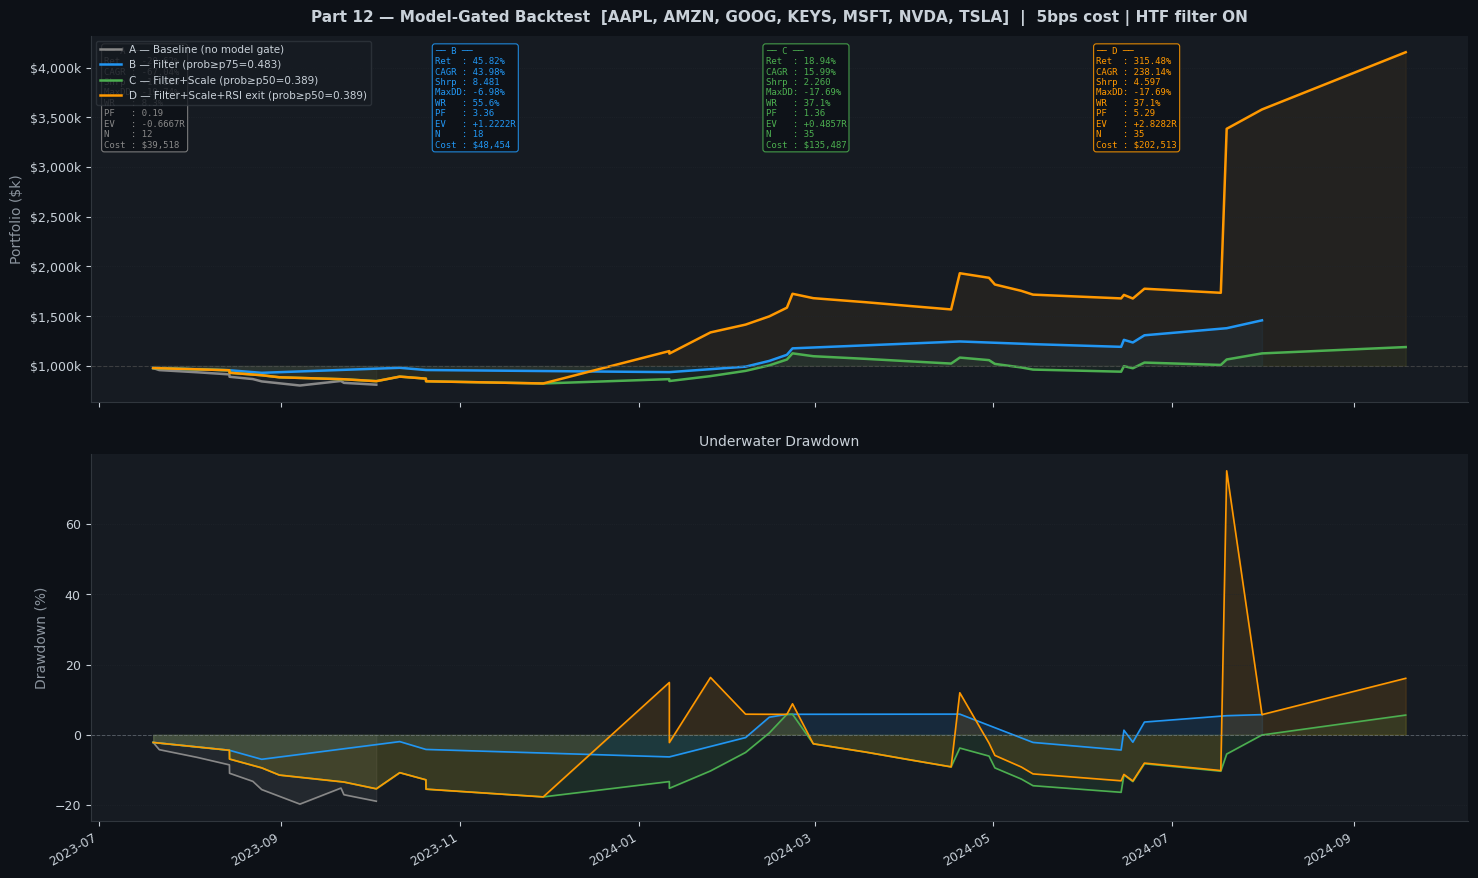


  ✓ Chart saved → outputs/part12_model_gated_v3.png


In [65]:
# =============================================================================
# Part 11 — Cell 3: Simulation function, Scenarios A/B/C/D, Charts
# =============================================================================

def run_backtest(
    sweeps_sim:           pd.DataFrame,
    initial_capital:      float = SIM_INITIAL_CAPITAL,
    max_dd_limit:         float = SIM_MAX_DD_LIMIT,
    risk_cap_per_trade:   float = SIM_RISK_CAP_PER_TRADE,
    max_exposure_per_bar: float = SIM_MAX_EXPOSURE_PER_BAR,
    cost_bps:             float = SIM_COST_BPS,
    min_prob:             float = 0.0,
    kelly_scale:          bool  = False,
    scale_ref:            float = None,
    use_rsi_exit:         bool  = False,
    enforce_htf_bias:     bool  = True,
) -> tuple:
    """
    Model-gated portfolio backtest.

    Exit used for P&L:
      Scenarios A/B/C → pnl_r from Part 7 label  (WIN=+tp_mult, LOSS=-1.0)
      Scenario D      → RSI early-exit if it fires before label TP;
                        otherwise falls back to Part 7 pnl_r

    Sizing (risk-based):
      dollar_risk  = portfolio × kelly_size      ← amount lost on 1R move
      notional     = dollar_risk / (stop_pct/100) ← full position value
      pnl_dollars  = dollar_risk × pnl_r
      cost_dollars = notional × cost_bps/10_000  ← round-trip on full notional
    """
    if scale_ref is None:
        scale_ref = SCALE_REF

    portfolio      = float(initial_capital)
    peak           = portfolio
    trades         = []
    exposure_by_ts = {}

    skipped_model   = 0
    skipped_htf     = 0
    skipped_errors  = 0

    # Pre-build rsi_by_day per ticker for Scenario D
    rsi_by_day_map = {}
    if use_rsi_exit:
        for t, rsi_df in ticker_rsi_map.items():
            rsi_by_day_map[t] = _build_rsi_by_day(rsi_df)

    # ── Candidate filter ─────────────────────────────────────────────────────
    valid = sweeps_sim[
        (sweeps_sim["is_test_set"] == True) &
        (sweeps_sim["outcome"] != "TIMEOUT") &
        (sweeps_sim["pnl_r"].notna()) &
        (sweeps_sim["stop_dist_pct"].notna()) &
        (sweeps_sim["kelly_frac_f"].notna()) &
        (pd.to_numeric(sweeps_sim["kelly_frac_f"], errors="coerce") > 0.01)
    ].copy()

    _dedup = [c for c in ["timestamp", "sweep_type", "zone_id", "ticker"]
              if c in valid.columns]
    if _dedup:
        valid = valid.drop_duplicates(subset=_dedup)
    valid = valid.sort_values("timestamp").reset_index(drop=True)

    for _, sweep in valid.iterrows():

        # ── HTF bias filter ──────────────────────────────────────────────────
        if enforce_htf_bias and "htf_bias_at_sweep" in sweep.index:
            bias  = str(sweep.get("htf_bias_at_sweep", "")).lower()
            stype = str(sweep.get("sweep_type", "")).upper()
            if bias not in ("", "nan", "none", "neutral"):
                aligned = (
                    (stype == "BULLISH" and bias in ("bull", "bullish", "up")) or
                    (stype == "BEARISH" and bias in ("bear", "bearish", "down"))
                )
                if not aligned:
                    skipped_htf += 1
                    continue

        # ── Model gate ───────────────────────────────────────────────────────
        prob = _safe_float(sweep.get("student_prob", _median_fill)) or _median_fill
        if prob < min_prob:
            skipped_model += 1
            continue

        ts = pd.to_datetime(sweep["timestamp"], errors="coerce")
        if pd.isna(ts):
            skipped_errors += 1
            continue

        pnl_r    = _safe_float(sweep["pnl_r"])
        stop_pct = _safe_float(sweep["stop_dist_pct"])

        if not _isfinite_safe(pnl_r) or not _isfinite_safe(stop_pct) or stop_pct <= 0:
            skipped_errors += 1
            continue

        # ── Exposure cap ─────────────────────────────────────────────────────
        used      = float(exposure_by_ts.get(ts, 0.0))
        remaining = float(max_exposure_per_bar) - used
        if remaining <= 0.001:
            continue

        # ── Kelly sizing ─────────────────────────────────────────────────────
        base_kelly = _safe_float(sweep["kelly_frac_f"])
        if base_kelly is None:
            skipped_errors += 1
            continue

        if kelly_scale:
            base_kelly = base_kelly * min(prob / float(scale_ref), 1.5)

        kelly_size = float(min(base_kelly, float(risk_cap_per_trade), remaining))
        if kelly_size <= 0:
            continue

        # ── Scenario D: RSI early-exit override ──────────────────────────────
        # Only applies to WIN trades — if RSI fires before TP, realised R is lower.
        # LOSS trades (-1R) are unaffected: SL already fired, RSI is irrelevant.
        if use_rsi_exit and pnl_r > 0:
            ticker = str(sweep.get("ticker", ""))
            rsi_df = ticker_rsi_map.get(ticker)
            rbd    = rsi_by_day_map.get(ticker)
            side   = _side_from_sweep_type(str(sweep.get("sweep_type", "")))

            entry_px = _safe_float(sweep.get("reversal_price", np.nan))
            sl_px    = _safe_float(sweep.get("sl_price", np.nan))

            if (rsi_df is not None and rbd is not None and side is not None
                    and _isfinite_safe(entry_px) and _isfinite_safe(sl_px)
                    and entry_px > 0 and sl_px > 0):
                stop_dist = abs(entry_px - sl_px)
                if stop_dist > 1e-8:
                    exit_ts, exit_px, _ = _find_rsi_exit(
                        ts, side, rsi_df, rbd,
                        long_thr=SENS_RSI_LONG_EXIT,
                        short_thr=SENS_RSI_SHORT_EXIT,
                        max_hold_days=SENS_MAX_HOLD_DAYS,
                    )
                    if not pd.isna(exit_ts) and _isfinite_safe(exit_px) and exit_px > 0:
                        # RSI fired before TP — override pnl_r with actual return
                        if side == "LONG":
                            pnl_r = (exit_px - entry_px) / stop_dist
                        else:
                            pnl_r = (entry_px - exit_px) / stop_dist

        # ── P&L with correct notional cost basis ─────────────────────────────
        dollar_risk  = portfolio * kelly_size
        notional     = dollar_risk / (stop_pct / 100.0)
        cost_dollars = notional * (float(cost_bps) / 10_000.0)
        pnl_dollars  = dollar_risk * pnl_r - cost_dollars

        portfolio += pnl_dollars
        portfolio  = max(portfolio, 0.0)
        exposure_by_ts[ts] = used + kelly_size

        drawdown = (portfolio - peak) / peak * 100.0
        if drawdown < float(max_dd_limit):
            break   # circuit breaker triggered
        peak = max(peak, portfolio)

        trades.append({
            "timestamp":     ts,
            "ticker":        sweep.get("ticker", "ALL"),
            "sweep_type":    sweep.get("sweep_type", "NA"),
            "outcome":       sweep.get("outcome", "NA"),
            "student_prob":  prob,
            "kelly_pct":     kelly_size * 100,
            "stop_dist_pct": stop_pct,
            "notional":      notional,
            "pnl_r":         pnl_r,
            "cost_dollars":  cost_dollars,
            "pnl_dollars":   pnl_dollars,
            "portfolio":     portfolio,
            "drawdown_pct":  drawdown,
        })

    trades_df = pd.DataFrame(trades)

    _base = {
        "Candidates":        len(valid),
        "Skipped HTF":       skipped_htf,
        "Skipped by model":  skipped_model,
        "Skipped (errors)":  skipped_errors,
    }

    if trades_df.empty:
        return trades_df, {"Status": "NO TRADES", **_base}

    # ── Performance metrics ───────────────────────────────────────────────────
    total_return = (portfolio - initial_capital) / initial_capital * 100
    span_days    = max((trades_df["timestamp"].max()
                        - trades_df["timestamp"].min()).days, 1)
    num_years    = max(span_days / 365.25, 1 / 365.25)
    cagr         = ((portfolio / initial_capital) ** (1.0 / num_years) - 1) * 100

    base_port = trades_df["portfolio"].shift(1).fillna(initial_capital)
    rets      = trades_df["pnl_dollars"] / base_port
    sharpe    = (rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 1e-12 else 0.0

    win_mask  = trades_df["pnl_dollars"] > 0
    loss_mask = trades_df["pnl_dollars"] < 0
    win_sum   = trades_df.loc[win_mask,  "pnl_dollars"].sum()
    loss_sum  = trades_df.loc[loss_mask, "pnl_dollars"].abs().sum()
    pf_str    = f"{win_sum / loss_sum:.2f}" if loss_sum > 0 else "∞"

    eq_arr   = trades_df["portfolio"].values
    peak_arr = np.maximum.accumulate(
        np.concatenate([[float(initial_capital)], eq_arr])
    )
    dd_arr = (eq_arr - peak_arr[1:]) / peak_arr[1:] * 100
    max_dd = float(dd_arr.min()) if len(dd_arr) else 0.0

    total_cost = trades_df["cost_dollars"].sum()

    metrics = {
        "Final Portfolio":    f"${portfolio:,.0f}",
        "Total Return":       f"{total_return:.2f}%",
        "CAGR":               f"{cagr:.2f}%",
        "Max Drawdown":       f"{max_dd:.2f}%",
        "Sharpe Ratio":       f"{sharpe:.3f}",
        "Win Rate":           f"{win_mask.mean() * 100:.1f}%",
        "Profit Factor":      pf_str,
        "Avg pnl_r":          f"{trades_df['pnl_r'].mean():+.4f}R",
        "OOS Trades":         len(trades_df),
        "Total Cost ($)":     f"${total_cost:,.0f}",
        "Avg Cost/Trade ($)": f"${trades_df['cost_dollars'].mean():,.0f}",
        **_base,
    }

    # Per-ticker breakdown
    if "ticker" in trades_df.columns:
        for t in sorted(trades_df["ticker"].dropna().unique()):
            sub  = trades_df[trades_df["ticker"] == t]
            t_wr = (sub["pnl_dollars"] > 0).mean() * 100
            t_ev = sub["pnl_r"].mean()
            t_pf_raw = (
                sub.loc[sub["pnl_dollars"] > 0, "pnl_dollars"].sum() /
                sub.loc[sub["pnl_dollars"] < 0, "pnl_dollars"].abs().sum()
            ) if (sub["pnl_dollars"] < 0).any() else float("inf")
            t_pf = f"{t_pf_raw:.2f}" if np.isfinite(t_pf_raw) else "∞"
            metrics[f"  {t}"] = (
                f"{len(sub)} trades | WR {t_wr:.1f}% | "
                f"EV {t_ev:+.3f}R | PF {t_pf}"
            )

    return trades_df, metrics


# ── Scenarios ─────────────────────────────────────────────────────────────────

_SIM_PARAMS = dict(
    initial_capital      = SIM_INITIAL_CAPITAL,
    max_dd_limit         = SIM_MAX_DD_LIMIT,
    risk_cap_per_trade   = SIM_RISK_CAP_PER_TRADE,
    max_exposure_per_bar = SIM_MAX_EXPOSURE_PER_BAR,
    cost_bps             = SIM_COST_BPS,
    enforce_htf_bias     = True,
)

_SCENARIOS = {
    "A — Baseline (no model gate)": dict(
        min_prob=0.0, kelly_scale=False, use_rsi_exit=False,
    ),
    f"B — Filter (prob≥p75={THRESH_B:.3f})": dict(
        min_prob=THRESH_B, kelly_scale=False, use_rsi_exit=False,
    ),
    f"C — Filter+Scale (prob≥p50={THRESH_C:.3f})": dict(
        min_prob=THRESH_C, kelly_scale=True, scale_ref=SCALE_REF, use_rsi_exit=False,
    ),
    f"D — Filter+Scale+RSI exit (prob≥p50={THRESH_C:.3f})": dict(
        min_prob=THRESH_C, kelly_scale=True, scale_ref=SCALE_REF, use_rsi_exit=True,
    ),
}

all_results = {}
print("\n" + "=" * 70)
print("  PART 12 — SCENARIOS A / B / C / D")
print("  HTF bias filter: ON  |  Cost basis: notional  |  All tickers combined")
print("=" * 70)

for label, gate_params in _SCENARIOS.items():
    trades_df, metrics = run_backtest(sweeps_for_sim, **_SIM_PARAMS, **gate_params)
    all_results[label] = {"trades": trades_df, "metrics": metrics}
    print(f"\n  {'─' * 66}")
    print(f"  {label}")
    print(f"  {'─' * 66}")
    for k, v in metrics.items():
        print(f"  {k:<36} {v}")


# ── Comparison table ──────────────────────────────────────────────────────────

_KEY = ["Total Return", "CAGR", "Sharpe Ratio", "Max Drawdown",
        "Win Rate", "Profit Factor", "Avg pnl_r",
        "OOS Trades", "Total Cost ($)", "Skipped HTF", "Skipped by model"]

comparison_df = pd.DataFrame({
    label: {k: res["metrics"].get(k, "—") for k in _KEY}
    for label, res in all_results.items()
})

print("\n\n" + "═" * 75)
print("  PART 12 — SCENARIO COMPARISON")
print("═" * 75)
try:
    display(comparison_df)
except NameError:
    print(comparison_df.to_string())


# ── Equity curve + drawdown plot ──────────────────────────────────────────────

_PALETTE = ["#888888", "#2196F3", "#4CAF50", "#FF9800"]
_INITIAL  = SIM_INITIAL_CAPITAL

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    for s in ["bottom", "left"]:
        ax.spines[s].set_color("#30363d")

for (label, res), color in zip(all_results.items(), _PALETTE):
    df = res["trades"]
    sc = label.split("—")[0].strip()
    m  = res["metrics"]

    ann_txt = "\n".join([
        f"── {sc} ──",
        f"Ret  : {m.get('Total Return','—')}",
        f"CAGR : {m.get('CAGR','—')}",
        f"Shrp : {m.get('Sharpe Ratio','—')}",
        f"MaxDD: {m.get('Max Drawdown','—')}",
        f"WR   : {m.get('Win Rate','—')}",
        f"PF   : {m.get('Profit Factor','—')}",
        f"EV   : {m.get('Avg pnl_r','—')}",
        f"N    : {m.get('OOS Trades','—')}",
        f"Cost : {m.get('Total Cost ($)','—')}",
    ])
    _ann_x = 0.01 + list(all_results.keys()).index(label) * 0.24
    axes[0].text(
        _ann_x, 0.97, ann_txt,
        transform=axes[0].transAxes, fontsize=6.5,
        verticalalignment="top", family="monospace", color=color,
        bbox=dict(boxstyle="round,pad=0.3", fc="#0d1117",
                  ec=color, alpha=0.88, linewidth=0.8),
    )

    if df.empty:
        continue

    axes[0].plot(df["timestamp"], df["portfolio"] / 1_000,
                 label=label, linewidth=1.8, color=color)
    axes[0].fill_between(df["timestamp"], _INITIAL / 1_000,
                         df["portfolio"] / 1_000, alpha=0.06, color=color)
    axes[1].plot(df["timestamp"], df["drawdown_pct"],
                 linewidth=1.2, color=color, label=label)
    axes[1].fill_between(df["timestamp"], df["drawdown_pct"], 0,
                         alpha=0.12, color=color)

axes[0].axhline(_INITIAL / 1_000, color="#555", linewidth=0.8,
                linestyle="--", alpha=0.6)
axes[0].set_ylabel("Portfolio ($k)", color="#8b949e", fontsize=10)
axes[0].set_title(
    f"Part 12 — Model-Gated Backtest  [{', '.join(tickers)}]  |  "
    f"{SIM_COST_BPS}bps cost | HTF filter ON",
    color="#c9d1d9", fontsize=11, pad=10, fontweight="bold",
)
axes[0].legend(facecolor="#161b22", edgecolor="#30363d",
               labelcolor="#c9d1d9", fontsize=7.5, loc="upper left")
axes[0].grid(axis="y", color="#21262d", linewidth=0.5, linestyle=":")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}k"))

axes[1].axhline(0, color="#8b949e", linewidth=0.7, linestyle="--", alpha=0.5)
axes[1].set_ylabel("Drawdown (%)", color="#8b949e", fontsize=10)
axes[1].set_title("Underwater Drawdown", color="#c9d1d9", fontsize=10, pad=6)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].grid(axis="y", color="#21262d", linewidth=0.5, linestyle=":")

fig.autofmt_xdate()
plt.tight_layout(pad=1.5, h_pad=2.0)
_plot_path = "outputs/part12_model_gated_v3.png"
plt.savefig(_plot_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\n  ✓ Chart saved → {_plot_path}")


## Part 12 — Out-of-Sample Forecasting & Portfolio Simulation

This part applies the trained Teacher→Student pipeline to unseen data and runs a full portfolio backtest.

---

### 12A — `engineer_all_student_features`

Transforms a raw sweep DataFrame into the exact feature matrix the student XGBRegressor expects at inference time. Mirrors the walk-forward training pipeline step-by-step so there is no train/test leakage:

1. **Dollar normalisation** — price-level features divided by the contemporaneous close so the model is scale-invariant across tickers and time
2. **Categorical encoding** — `zone_type`, `sweep_direction`, and regime labels are ordinal-encoded with the same mapping used during training
3. **Regime assignment** — GMM cluster IDs from the trained regime model are attached to each sweep row by timestamp join
4. **Column alignment** — drops any extra columns and zero-fills any missing expected columns so the output shape exactly matches the student's `feature_names_in_`

---

### 12B — `pro_trading_simulation_model_gated` (Single-Ticker Simulation)

Runs a single-ticker paper-trade simulation over a labelled sweep DataFrame using the gated model score as a position filter.

**Configuration (`SENS_*` variables)**

| Variable | Role |
|---|---|
| `SENS_PROB_THRESHOLD` | Minimum predicted P(win) to enter a trade |
| `SENS_KELLY_FRACTION` | Fractional Kelly multiplier (risk scaling) |
| `SENS_MAX_EXPOSURE` | Per-trade capital cap as fraction of equity |
| `SENS_SLIPPAGE_BPS` | Round-trip slippage applied to each fill |
| `SENS_CIRCUIT_BREAKER` | Drawdown level that halts further trading |

**Per-trade logic**
for each sweep (chronological):
if model_score < threshold → skip
kelly_size  = kelly(p_win, rr) × SENS_KELLY_FRACTION
position    = min(kelly_size, SENS_MAX_EXPOSURE) × equity
entry_price = sweep_price × (1 + slippage)

RSI early-exit (in-profit guard):
    if RSI(6) crosses threshold while trade is open AND pnl > 0 → close early

on close:
    equity += pnl − slippage_cost
    if drawdown > CIRCUIT_BREAKER → halt


Outputs per-trade P&L, running equity curve, win rate, Sharpe, and max drawdown.

---

### 12C — Per-Ticker OOS Forecasting Loop

Iterates over every ticker, loads hourly price data (yfinance with CSV fallback), and produces OOS predictions end-to-end:
for ticker in TICKERS:
1. Load hourly OHLCV  (yfinance → CSV fallback)
2. Detect HTF zones   (daily pivot → OB-anchored boundaries)
3. Detect LTF sweeps  (hourly candles vs. HTF zone list)
4. Engineer features  (engineer_all_student_features)
5. Student predict    (XGBRegressor → P(win) per sweep)
6. Kelly size         (no-lookahead: uses only p_win at entry time)
7. Run scenarios A / B / C  (threshold sensitivity)
8. Live sweep check   (last 60 calendar days — flag any active zones)


Scenario definitions:

| Scenario | Threshold | Kelly fraction |
|---|---|---|
| A | 0.55 | 0.25 |
| B | 0.60 | 0.50 |
| C | 0.65 | 0.75 |

Results are stored per-ticker for aggregation in Fix 5.

---

### 12C Fix 5 — Pooled Multi-Ticker Portfolio Simulation

Replaces the independent per-ticker runs with a single shared capital pool to reflect real portfolio constraints.

**Capital rules**

| Constraint | Value |
|---|---|
| Starting capital | \$1,000,000 |
| Max exposure per ticker | 30 % of portfolio equity |
| Max total exposure (all tickers combined) | 60 % of portfolio equity |

**Six-step execution**
Step 1 — Collect sweeps
Gather all OOS sweep rows across tickers; attach ticker label.

Step 2 — Pool & sort
Merge into one DataFrame; sort strictly by entry timestamp
so capital allocation reflects chronological trade sequencing.

Step 3 — Run scenarios (A / B / C) on pooled sweep list
For each trade:
check per-ticker cap  (ticker_exposure ≤ 0.30 × equity)
check total cap       (total_exposure  ≤ 0.60 × equity)
apply Kelly sizing with no-lookahead p_win
apply RSI(6) early-exit with in-profit guard
update shared equity

Step 4 — Equity curve chart
Single cumulative P&L line per scenario plotted on one axis.

Step 5 — Per-ticker attribution table
Columns: ticker | trades | win_rate | total_pnl | contribution_%

Step 6 — Scenario comparison table
Columns: scenario | final_equity | total_return | sharpe | max_dd


The pooled approach ensures exposure caps are respected globally (not just locally per ticker) and produces a single auditable equity curve that accounts for capital competition between concurrent signals.


In [66]:
def engineer_all_student_features(df_sweeps: pd.DataFrame, artifacts: dict) -> pd.DataFrame:
    """
    Applies all feature engineering, normalization, and categorical
    encoding needed for the Distillation Student Model.

    Args:
        df_sweeps: Raw dataframe of sweeps generated from 2024+ data
                   (must contain raw columns like 'reversal_distance', 'touchcount', etc.)
        artifacts: The loaded preprocessing_artifacts.joblib dictionary.

    Returns:
        X_student: A DataFrame strictly aligned to what the Student model expects.
    """

    df = df_sweeps.copy()

    def _ensure_col(target: str, aliases: list[str], default_value):
        if target in df.columns:
            return
        for a in aliases:
            if a in df.columns:
                df[target] = df[a]
                return
        df[target] = default_value

    # ---------------------------------------------------------
    # 0. Normalize raw column names / provide safe fallbacks
    # ---------------------------------------------------------
    # Required identifiers (fail early if missing)
    if "ticker" not in df.columns:
        raise KeyError("engineer_all_student_features: missing required column 'ticker'")
    if "timestamp" not in df.columns:
        raise KeyError("engineer_all_student_features: missing required column 'timestamp'")

    # Price anchors
    _ensure_col("zone_level", ["zonelevel", "zone_mid", "zone_price"], default_value=np.nan)
    if df["zone_level"].isna().all():
        # last-resort reference for pct normalization
        if "close" in df.columns:
            df["zone_level"] = pd.to_numeric(df["close"], errors="coerce")
        else:
            df["zone_level"] = 1.0

    # Candle metrics (names differ between sweep export variants)
    _ensure_col("candle_total_range", ["total_range", "candle_range", "range"], default_value=np.nan)
    _ensure_col("candle_body", ["body", "candle_body_$"], default_value=np.nan)
    _ensure_col("lower_wick", ["low_wick", "lowerwick", "lowwick"], default_value=0.0)
    _ensure_col("upper_wick", ["high_wick", "upperwick", "highwick"], default_value=0.0)

    # Reversal distance
    _ensure_col("reversal_distance", ["reversal_distance_$", "reversal_dist"], default_value=0.0)

    # Touch count fields (the KeyError you hit was here)
    _ensure_col(
        "zone_accumulated_touch_count",
        [
            "zone_touch_count_at_sweep",
            "zone_touch_count",
            "touchcount",
            "touch_count",
            "touchcount_at_sweep",
        ],
        default_value=0.0,
    )
    _ensure_col(
        "touches_at_inversion",
        ["touches_since_inversion", "touches_since_inversion_days"],
        default_value=0.0,
    )

    # Ensure numeric for math operations
    for c in [
        "zone_level",
        "candle_total_range",
        "candle_body",
        "lower_wick",
        "upper_wick",
        "reversal_distance",
        "zone_accumulated_touch_count",
        "touches_at_inversion",
    ]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # ---------------------------------------------------------
    # 1. Dollar Normalization (from Step 2 in notebook)
    # ---------------------------------------------------------
    ref = df["zone_level"].replace(0, np.nan)
    candle = df["candle_total_range"].replace(0, np.nan)

    df["reversal_distance_pct"] = df["reversal_distance"] / ref
    df["candle_range_pct"] = df["candle_total_range"] / ref
    df["body_ratio"] = df["candle_body"] / candle
    df["lower_wick_ratio"] = df["lower_wick"] / candle
    df["upper_wick_ratio"] = df["upper_wick"] / candle
    df["log_touchcount"] = np.log1p(df["zone_accumulated_touch_count"].fillna(0.0).clip(lower=0.0))
    df["log_touches_at_inversion"] = np.log1p(df["touches_at_inversion"].fillna(0.0).clip(lower=0.0))

    # ---------------------------------------------------------
    # 2. Extract Training Constants from Notebook
    # ---------------------------------------------------------
    SWEEP_BOOL = [
        "vol_surge",
        "mss_confirmed",
        "slope_gate_pass",
        "is_first_sweep",
        "is_retest",
    ]
    SWEEP_CAT = [
        "sweep_type",
        "zonetype",
        "zone_state_at_sweep",
        "zonelifecyclephase",
    ]

    # ---------------------------------------------------------
    # 3. Encode Categoricals & Booleans (from Step 6)
    # ---------------------------------------------------------
    for col in SWEEP_BOOL:
        if col in df.columns:
            df[col] = df[col].astype(int)

    for col in SWEEP_CAT:
        if col in df.columns:
            dummies = pd.get_dummies(df[col].astype(str), prefix=col, drop_first=True)
            df = pd.concat([df, dummies], axis=1)

    # ---------------------------------------------------------
    # 4. Regime Assignment (from Step 5)
    #    Uses your exact custom notebook function logic
    # ---------------------------------------------------------
    regime_store = artifacts["regime_store"]
    max_k = max(s["k"] for s in regime_store.values())

    regime_labels, frac_dicts = [], []
    for _, row in df.iterrows():
        ticker = row["ticker"]
        ts = pd.to_datetime(row["timestamp"], errors="coerce")
        if ts is not pd.NaT and ts.tz is not None:
            ts = ts.tz_localize(None)

        if ticker in regime_store and ts is not pd.NaT:
            store = regime_store[ticker]
            rseries = store["regime_series"]
            rseries.index = pd.to_datetime(rseries.index).tz_localize(None)
            k = store["k"]

            mask = rseries.index <= ts
            if mask.any():
                recent = rseries[mask].iloc[-7:]  # lookback_bars = 7
                label = int(recent.iloc[-1])
                fracs = {f"regime_{r}_frac": (recent == r).mean() for r in range(k)}
                for r in range(k, max_k):
                    fracs[f"regime_{r}_frac"] = 0.0
            else:
                label = -1
                fracs = {f"regime_{r}_frac": 0.0 for r in range(max_k)}
        else:
            label = -1
            fracs = {f"regime_{r}_frac": 0.0 for r in range(max_k)}

        regime_labels.append(label)
        frac_dicts.append(fracs)

    df["regime_label"] = regime_labels
    df = pd.concat([df, pd.DataFrame(frac_dicts, index=df.index)], axis=1)

    # ---------------------------------------------------------
    # 5. Extract ONLY the Student Feature columns (Align exactly)
    # ---------------------------------------------------------
    student_training_columns = artifacts["student_training_columns"]
    X_student = pd.DataFrame(index=df.index)

    for col in student_training_columns:
        if col in df.columns:
            X_student[col] = pd.to_numeric(df[col], errors="coerce")

            is_bool_or_cat = (
                col in SWEEP_BOOL
                or any(col.startswith(c + "_") for c in SWEEP_CAT)
                or "regime_" in col
            )
            fill_val = 0 if is_bool_or_cat else X_student[col].median()
            if pd.isna(fill_val):
                fill_val = 0

            X_student[col] = X_student[col].fillna(fill_val)
        else:
            X_student[col] = 0

    return X_student[student_training_columns]

In [67]:
# ── Part 12B: aliases + pro_trading_simulation_model_gated ──────────────────

# Bridge: Cell 74 looks for _prepare_running_daily_rsi_from_ltf
_prepare_running_daily_rsi_from_ltf = _prepare_running_daily_rsi

# Bridge: Cell 74 uses SENS_ prefix, Cell 69 defined these as SIM_
SENS_INITIAL_CAPITAL            = SIM_INITIAL_CAPITAL
SENS_MAX_DD_LIMIT               = SIM_MAX_DD_LIMIT
SENS_RISK_CAP_PER_TRADE         = SIM_RISK_CAP_PER_TRADE
SENS_MAX_TOTAL_EXPOSURE_PER_BAR = SIM_MAX_EXPOSURE_PER_BAR
SENS_COST_BPS                   = SIM_COST_BPS
SENS_MAX_HOLD_DAYS              = 30    # must match Part 7

_median_fill = 0.5    # fallback when student_prob is missing
SCALE_REF    = 0.5    # reference for kelly_scale scenario C


def pro_trading_simulation_model_gated(
    sweeps_filtered,
    ltf_rsi_df,
    long_thr                    = 75.0,
    short_thr                   = 25.0,
    max_hold_days               = 30,
    initial_capital             = 1_000_000,
    max_dd_limit                = -20.0,
    risk_cap_per_trade          = 0.02,
    max_total_exposure_per_bar  = 0.20,
    cost_bps                    = 5,
    min_prob                    = 0.0,
    kelly_scale                 = False,
    scale_ref                   = None,
):
    if scale_ref is None:
        scale_ref = SCALE_REF

    portfolio      = float(initial_capital)
    trades         = []
    peak           = portfolio
    exposure_by_ts = {}
    skipped_model  = 0
    skipped_errors = 0

    valid_trades = sweeps_filtered[
        (sweeps_filtered["is_test_set"] == True)
        & (sweeps_filtered["kelly_frac_f"].notna())
        & (pd.to_numeric(sweeps_filtered["kelly_frac_f"], errors="coerce") > 0.01)
    ].copy()

    _dedup = [c for c in ["timestamp", "sweep_type", "sweep_id", "zone_id"]
              if c in valid_trades.columns]
    if _dedup:
        valid_trades = valid_trades.drop_duplicates(subset=_dedup)
    valid_trades = valid_trades.sort_values("timestamp").reset_index(drop=True)

    rsi_by_day = _build_rsi_by_day(ltf_rsi_df)

    for _, sweep in valid_trades.iterrows():
        prob = _safe_float(sweep.get("student_prob", _median_fill), "student_prob")
        if prob is None:
            prob = _median_fill
        if prob < min_prob:
            skipped_model += 1
            continue

        ts = pd.to_datetime(sweep["timestamp"], errors="coerce")
        if pd.isna(ts):
            skipped_errors += 1
            continue

        used      = float(exposure_by_ts.get(ts, 0.0))
        remaining = float(max_total_exposure_per_bar) - used
        if remaining <= 0:
            continue

        base_kelly = _safe_float(sweep["kelly_frac_f"], "kelly_frac_f")
        if base_kelly is None:
            skipped_errors += 1
            continue

        if kelly_scale:
            scale_ref_f = _safe_float(scale_ref, "scale_ref") or SCALE_REF
            base_kelly  = base_kelly * min(prob / scale_ref_f, 1.5)

        kelly_size = float(min(base_kelly, float(risk_cap_per_trade), remaining))
        if kelly_size <= 0:
            continue

        side = _side_from_sweep_type(str(sweep.get("sweep_type", "")))
        if side is None:
            skipped_errors += 1
            continue

        entry_price = _safe_float(sweep.get("reversal_price", np.nan), "reversal_price")
        if entry_price is None or not _isfinite_safe(entry_price) or entry_price <= 0:
            skipped_errors += 1
            continue

        exit_ts, exit_price, exit_rsi = _find_rsi_exit(
            ts, side, ltf_rsi_df, rsi_by_day,
            long_thr      = float(long_thr),
            short_thr     = float(short_thr),
            max_hold_days = int(max_hold_days),
        )

        if pd.isna(exit_ts) or not _isfinite_safe(exit_price):
            skipped_errors += 1
            continue

        raw_ret   = (exit_price - entry_price) / entry_price * 100.0
        pnl_pct   = raw_ret if side == "LONG" else -raw_ret

        ts_arr    = ltf_rsi_df["timestamp"].values
        i0        = int(np.searchsorted(ts_arr, np.datetime64(ts),      side="left"))
        i1        = int(np.searchsorted(ts_arr, np.datetime64(exit_ts), side="left"))
        bars_held = max(0, i1 - i0)

        position_size = portfolio * kelly_size
        slippage_cost = position_size * (float(cost_bps) / 10_000.0)
        pnl_dollars   = position_size * (pnl_pct / 100.0) - slippage_cost

        portfolio += pnl_dollars
        portfolio  = max(portfolio, 0.0)
        exposure_by_ts[ts] = used + kelly_size

        drawdown = (portfolio - peak) / peak * 100
        if drawdown < float(max_dd_limit):
            break
        peak = max(peak, portfolio)

        trades.append({
            "timestamp":         ts,
            "exit_timestamp":    exit_ts,
            "sweep_type":        sweep.get("sweep_type", "NA"),
            "side":              side,
            "student_prob":      prob,
            "exit_running_rsi6": exit_rsi,
            "bars_held_hourly":  bars_held,
            "kelly_size_pct":    kelly_size * 100,
            "pnl_pct":           pnl_pct,
            "pnl_dollars":       pnl_dollars,
            "portfolio":         portfolio,
            "drawdown_pct":      drawdown,
        })

    trades_df = pd.DataFrame(trades)

    _base_metrics = {
        "Skipped by model":  skipped_model,
        "Skipped (errors)":  skipped_errors,
        "Candidates":        len(valid_trades),
    }

    if trades_df.empty:
        return trades_df, {"Status": "NO TRADES", **_base_metrics}

    total_return = (portfolio - initial_capital) / initial_capital * 100
    span_days    = (trades_df["timestamp"].max() - trades_df["timestamp"].min()).days
    num_years    = max(span_days / 365.25, 1 / 365.25)
    cagr         = ((portfolio / initial_capital) ** (1.0 / num_years) - 1) * 100

    base_port = trades_df["portfolio"].shift(1).fillna(initial_capital)
    rets      = trades_df["pnl_dollars"] / base_port
    sharpe    = (rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0

    win_mask = trades_df["pnl_dollars"] > 0
    loss_mask = trades_df["pnl_dollars"] < 0
    win_sum  = trades_df.loc[win_mask,  "pnl_dollars"].sum()
    loss_sum = trades_df.loc[loss_mask, "pnl_dollars"].abs().sum()
    pf_str   = f"{win_sum / loss_sum:.2f}" if loss_sum > 0 else "∞"

    eq_arr   = trades_df["portfolio"].values
    peak_arr = np.maximum.accumulate(np.concatenate([[float(initial_capital)], eq_arr]))
    dd_arr   = (eq_arr - peak_arr[1:]) / peak_arr[1:] * 100
    max_dd   = float(dd_arr.min()) if len(dd_arr) else 0.0

    metrics = {
        "Final Portfolio":     f"${portfolio:,.0f}",
        "Total Return":        f"{total_return:.2f}%",
        "CAGR":                f"{cagr:.2f}%",
        "Max Drawdown":        f"{max_dd:.2f}%",
        "Sharpe Ratio":        f"{sharpe:.3f}",
        "Win Rate":            f"{win_mask.mean() * 100:.1f}%",
        "Profit Factor":       pf_str,
        "OOS Trades Executed": len(trades_df),
        **_base_metrics,
        "Avg Trade ($)":       f"${trades_df['pnl_dollars'].mean():,.0f}",
        "Avg Bars Held":       f"{trades_df['bars_held_hourly'].dropna().mean():.1f}",
    }
    return trades_df, metrics


print("Part 12B defined: aliases + pro_trading_simulation_model_gated.")


Part 12B defined: aliases + pro_trading_simulation_model_gated.


In [68]:
# --- Part 12C (REWRITE): OOS Forecasting + Model-Gated Backtest (NO MIDAS) ---
# Window: 2024-10-01 → today
# Data: try yfinance hourly+daily; fallback to local CSVs when hourly is unavailable.
#
# Fixes applied:
#   - volume_zscore + ATR computed on df_t before zone/sweep detection
#   - identify_liquidity_zones return order handled correctly (ltf=index 2, htf=index 3)
#   - LTF zones used as primary input to identify_sweeps_in_zones; HTF as confluence
#   - CONTEXT_LOOKBACK_DAYS raised to 180 for stable rolling vol_zscore
#   - Diagnostic print on zero-sweep to surface gate failures

from pathlib import Path
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# USER SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
TICKERS              = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA", "AMZN"]
OOS_START            = pd.Timestamp("2024-10-01")
OOS_END              = pd.Timestamp.today().normalize()
CSV_FALLBACK_OOS_END = "2026-04-15"   # only used to form candidate filenames
CONTEXT_LOOKBACK_DAYS = 90           

SCENARIOS = {
    "A — Baseline (no model)":    dict(min_prob=0.00, kelly_scale=False),
    "B — Filter (p>=p75)":        dict(min_prob="p75", kelly_scale=False),
    "C — Filter+Scale (p>=p50)":  dict(min_prob="p50", kelly_scale=True),
}


# ─────────────────────────────────────────────────────────────────────────────
# PREFLIGHT
# ─────────────────────────────────────────────────────────────────────────────
_required = [
    "identify_liquidity_zones",
    "identify_sweeps_in_zones",
    "_prepare_running_daily_rsi_from_ltf",
    "pro_trading_simulation_model_gated",
    "engineer_all_student_features",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Missing required functions: " + ", ".join(_missing)
        + "\nRun the earlier notebook sections first (zones/sweeps + Part 11A + Part 12B)."
    )


# ─────────────────────────────────────────────────────────────────────────────
# LOAD ARTIFACTS + STUDENT MODEL
# ─────────────────────────────────────────────────────────────────────────────
print("1) Loading saved artifacts + Student model …")
MODEL_DIR      = "outputs/saved_models"
artifacts_path = os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib")
model_path     = os.path.join(MODEL_DIR, "xgb_student_full.json")

artifacts     = joblib.load(artifacts_path)
student_model = xgb.XGBRegressor()
student_model.load_model(model_path)


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _clean_yf_ohlcv(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if isinstance(out.index, pd.DatetimeIndex):
        out = out.reset_index()
    ren = {
        "Datetime": "timestamp", "Date": "timestamp",
        "Open": "open", "High": "high", "Low": "low",
        "Close": "close", "Volume": "volume",
    }
    out = out.rename(columns={c: ren.get(c, c) for c in out.columns})
    if "timestamp" not in out.columns:
        out = out.reset_index(drop=True)
        out = out.rename(columns={out.columns[0]: "timestamp"})
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    if pd.api.types.is_datetime64tz_dtype(out["timestamp"]):
        out["timestamp"] = out["timestamp"].dt.tz_localize(None)
    for c in ["open", "high", "low", "close", "volume"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    if "close" not in out.columns:
        return pd.DataFrame()
    for c in ["open", "high", "low"]:
        if c not in out.columns:
            out[c] = out["close"]
    if "volume" not in out.columns:
        out["volume"] = 0.0
    out["ticker"] = ticker
    out = out.dropna(subset=["timestamp", "close"]).sort_values("timestamp").reset_index(drop=True)
    return out[["timestamp", "open", "high", "low", "close", "volume", "ticker"]]


def _yf_history(ticker: str, start: pd.Timestamp, end: pd.Timestamp, interval: str) -> pd.DataFrame:
    try:
        df = yf.Ticker(ticker).history(start=start, end=end, interval=interval, auto_adjust=False)
        return _clean_yf_ohlcv(df, ticker=ticker)
    except Exception:
        return pd.DataFrame()


def _load_csv_candidates(ticker: str) -> list:
    tl, tu = ticker.lower(), ticker.upper()
    oos_names = [
        f"{tl}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv",
        f"{tu}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv",
    ]
    pre_names = [
        f"{tl}_hourly_2019-01-07_2024-09-30_with_vol.csv",
        f"{tu}_hourly_2019-01-07_2024-09-30_with_vol.csv",
    ]
    candidates = []
    for base in [Path("."), Path("data")]:
        for name in oos_names + pre_names:
            candidates.append(base / name)
    for name in oos_names + pre_names:
        candidates.extend(Path(".").glob(f"**/{name}"))
    seen, out = set(), []
    for p in candidates:
        p = p.resolve()
        if p.exists() and p not in seen:
            seen.add(p); out.append(p)
    return out


def _read_hourly_csv(ticker: str) -> pd.DataFrame:
    paths = _load_csv_candidates(ticker)
    if not paths:
        return pd.DataFrame()
    dfs = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        if "timestamp" not in df.columns:
            date_col = next((c for c in df.columns if c.lower() in ("date", "datetime", "time")), None)
            df = df.rename(columns={date_col: "timestamp"}) if date_col else df.reset_index().rename(columns={"index": "timestamp"})
        ren = {"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume"}
        df = df.rename(columns={c: ren.get(c, c) for c in df.columns})
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        for c in ["open", "high", "low", "close", "volume"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        if "close" not in df.columns:
            continue
        for c in ["open", "high", "low"]:
            if c not in df.columns:
                df[c] = df["close"]
        if "volume" not in df.columns:
            df["volume"] = 0.0
        df["ticker"] = ticker
        dfs.append(df[["timestamp", "open", "high", "low", "close", "volume", "ticker"]])
    if not dfs:
        return pd.DataFrame()
    return (
        pd.concat(dfs, ignore_index=True)
        .dropna(subset=["timestamp", "close"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )


def _load_hourly_data(ticker: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    df = _yf_history(ticker, start=start, end=end + pd.Timedelta(days=1), interval="1h")
    if not df.empty:
        return df
    df_csv = _read_hourly_csv(ticker)
    if df_csv.empty:
        return pd.DataFrame()
    mask = (df_csv["timestamp"] >= start) & (df_csv["timestamp"] <= end + pd.Timedelta(days=1))
    return df_csv.loc[mask].copy().reset_index(drop=True)


def _load_daily_data(ticker: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    return _yf_history(ticker, start=start, end=end + pd.Timedelta(days=1), interval="1d")


def _enrich_price_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute volume_zscore and ATR — required by sweep detection gates."""
    out = df.copy()

    # Volume z-score (rolling 30-bar, matching Part 2 normalisation)
    _vol  = pd.to_numeric(out["volume"], errors="coerce").clip(lower=0)
    _mean = _vol.rolling(30, min_periods=10).mean()
    _std  = _vol.rolling(30, min_periods=10).std().replace(0, np.nan)
    out["volume_zscore"] = ((_vol - _mean) / _std).fillna(0.0)

    # ATR (14-bar, required by slope gate + zone scoring)
    _tr = pd.concat([
        out["high"] - out["low"],
        (out["high"] - out["close"].shift(1)).abs(),
        (out["low"]  - out["close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    out["atr"] = _tr.rolling(14, min_periods=1).mean().bfill()

    return out

def _is_valid_df(x) -> bool:
    """True only if x is a non-empty DataFrame — guards against NaN/None returns."""
    return isinstance(x, pd.DataFrame) and not x.empty

def _detect_zones(df_t: pd.DataFrame):
    """
    Call identify_liquidity_zones and return (zones_ltf, zones_htf).
    Handles NaN / None / empty-DataFrame return slots safely.
    Return order: (_, _, ltf_zones, htf_zones, _)
    """
    try:
        ret = identify_liquidity_zones(df_t, midas_df=None)
    except TypeError:
        ret = identify_liquidity_zones(df_t)

    zones_ltf = ret[2] if len(ret) > 2 else None
    zones_htf = ret[3] if len(ret) > 3 else None

    # Normalise: treat NaN / scalar / empty as None
    if not _is_valid_df(zones_ltf):
        zones_ltf = None
    if not _is_valid_df(zones_htf):
        zones_htf = None

    # Fallback: promote HTF to primary if LTF is absent
    if zones_ltf is None and zones_htf is not None:
        print("   ⚠ LTF zones empty — using HTF zones as primary (sweep count will be lower)")
        zones_ltf = zones_htf
        zones_htf = None

    return zones_ltf, zones_htf


def _detect_sweeps_with_diagnostics(zones_ltf, zones_htf, df_t: pd.DataFrame, ticker: str):
    """
    Run identify_sweeps_in_zones with LTF primary + HTF confluence.
    Prints gate diagnostics if no sweeps are detected.
    """
    sweeps_df = identify_sweeps_in_zones(
        zonesdf    = zones_ltf,
        pricedata  = df_t,
        htfzonesdf = zones_htf,   # soft confluence scorer — not a hard gate
        midasmode  = False,
    )

    if sweeps_df is None or sweeps_df.empty:
        # ── Diagnostic block ──────────────────────────────────────────────────
        _s = df_t.tail(200)
        _active = 0
        if zones_ltf is not None and "zone_state" in zones_ltf.columns:
            _active = (~zones_ltf["zone_state"].isin(["dead", "breached"])).sum()
        elif zones_ltf is not None:
            _active = len(zones_ltf)

        print(f"   ✗ No sweeps detected. Gate diagnostics (last 200 bars):")
        print(f"     volume_zscore : mean={_s['volume_zscore'].mean():.2f}  "
              f"NaN={_s['volume_zscore'].isna().sum()}  "
              f"pct<0={(_s['volume_zscore'] < 0).mean()*100:.0f}%")
        print(f"     atr           : mean={_s['atr'].mean():.4f}  "
              f"NaN={_s['atr'].isna().sum()}")
        print(f"     active zones  : {_active} / {len(zones_ltf) if zones_ltf is not None else 0}")
        if zones_ltf is not None and "composite_score" in zones_ltf.columns:
            print(f"     composite_score: mean={zones_ltf['composite_score'].mean():.3f}  "
                  f"min={zones_ltf['composite_score'].min():.3f}")
        return None

    return sweeps_df


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────
context_start = (OOS_START - pd.Timedelta(days=CONTEXT_LOOKBACK_DAYS)).normalize()
print(f"2) Data window (context): {context_start.date()} → {OOS_END.date()} | OOS starts {OOS_START.date()}")

all_preds   = []
all_metrics = {}

for ticker in TICKERS:
    print(f"\n{'='*72}\nTICKER: {ticker}\n{'='*72}")

    # ── 2A: Hourly data ───────────────────────────────────────────────────────
    print("2A) Loading hourly (1h) …")
    df_hourly = _load_hourly_data(ticker, start=context_start, end=OOS_END)
    if df_hourly.empty:
        print("   ✗ No hourly data (yfinance failed AND no CSV found). Skipping.")
        continue
    print(f"   ✓ Hourly rows: {len(df_hourly):,} | "
          f"range: {df_hourly['timestamp'].min()} → {df_hourly['timestamp'].max()}")

    # ── 2B: Daily data ────────────────────────────────────────────────────────
    print("2B) Loading daily (1d) …")
    df_daily = _load_daily_data(ticker, start=context_start, end=OOS_END)
    print(f"   ✓ Daily rows: {len(df_daily):,}" if not df_daily.empty else "   (daily unavailable)")

    # ── 2C: RSI for exit logic ────────────────────────────────────────────────
    ltf_sensitive_rsi_t = _prepare_running_daily_rsi_from_ltf(
        df_hourly[["timestamp", "open", "high", "low", "close"]].copy(),
        period=SENS_RSI_PERIOD,
    )
    ltf_sensitive_rsi_t = (
        ltf_sensitive_rsi_t
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # ── 2D: Build df_t with required feature columns ──────────────────────────
    df_t = df_hourly.copy().reset_index(drop=True)
    df_t["date"] = df_t["timestamp"].dt.date
    df_t = _enrich_price_features(df_t)   # ← adds volume_zscore + atr

    print(f"   ✓ Features: volume_zscore mean={df_t['volume_zscore'].mean():.2f} | "
          f"atr mean={df_t['atr'].mean():.4f}")

    # ── 3: Zone detection ─────────────────────────────────────────────────────
    print("3) Detecting zones (NO MIDAS) …")
    zones_ltf, zones_htf = _detect_zones(df_t)

    if zones_ltf is None or zones_ltf.empty:
        print("   ✗ No zones detected. Skipping.")
        continue

    print(f"   ✓ Zones: LTF={len(zones_ltf)}  HTF={len(zones_htf) if zones_htf is not None else 0}")

    # ── 4: Sweep detection ────────────────────────────────────────────────────
    print("4) Detecting sweeps …")
    sweeps_df = _detect_sweeps_with_diagnostics(zones_ltf, zones_htf, df_t, ticker)
    if sweeps_df is None:
        continue

    sweeps_df = sweeps_df.copy()
    if "ticker" not in sweeps_df.columns:
        sweeps_df["ticker"] = ticker
    sweeps_df["timestamp"] = pd.to_datetime(sweeps_df["timestamp"], errors="coerce")
    sweeps_df = sweeps_df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    sweeps_oos = sweeps_df[sweeps_df["timestamp"] >= OOS_START].copy().reset_index(drop=True)
    print(f"   ✓ Sweeps (OOS): {len(sweeps_oos):,}  (context total: {len(sweeps_df):,})")

    if sweeps_oos.empty:
        print("   ⚠ Sweeps detected in context window but none after OOS_START. "
              "Consider increasing CONTEXT_LOOKBACK_DAYS or checking OOS_START.")
        continue

    # ── 5: Feature engineering ────────────────────────────────────────────────
    print("5) Feature engineering → Student columns …")
    X_oos = engineer_all_student_features(sweeps_oos, artifacts)

    # ── 6: Predict P(win) ─────────────────────────────────────────────────────
    print("6) Predicting P(win) …")
    preds = student_model.predict(X_oos)
    sweeps_oos["student_prob"] = np.clip(preds, 0.0, 1.0)
    all_preds.append(sweeps_oos.copy())

    # ── 7: Kelly sizing (no lookahead) ───────────────────────────────────────
    sweeps_for_sim = sweeps_oos.copy()
    sweeps_for_sim["timestamp"] = pd.to_datetime(sweeps_for_sim["timestamp"], errors="coerce")
    sweeps_for_sim = sweeps_for_sim.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    if "_no_lookahead_fallback_kelly" in globals():
        q = sweeps_for_sim.get("sweep_quality_score", pd.Series(0.0, index=sweeps_for_sim.index))
        sweeps_for_sim["kelly_frac_f"] = _no_lookahead_fallback_kelly(
            q,
            min_frac=0.01,
            max_frac=min(float(SENS_RISK_CAP_PER_TRADE), 0.10),
            min_history=max(8, int(SENS_RSI_PERIOD) + 2),
        )
    else:
        sweeps_for_sim["kelly_frac_f"] = 0.02

    sweeps_for_sim["kelly_frac_f"] = (
        pd.to_numeric(sweeps_for_sim["kelly_frac_f"], errors="coerce")
        .fillna(0.01)
        .clip(0.01, float(SENS_RISK_CAP_PER_TRADE))
    )
    sweeps_for_sim["is_test_set"] = True

    # ── 8: Adaptive thresholds + backtest ────────────────────────────────────
    p50 = float(np.nanpercentile(sweeps_for_sim["student_prob"], 50))
    p75 = float(np.nanpercentile(sweeps_for_sim["student_prob"], 75))
    print(f"8) Backtest (model-gated) … thresholds: p50={p50:.3f} | p75={p75:.3f}")

    results = {}
    for label, gate in SCENARIOS.items():
        gate = gate.copy()
        if gate.get("min_prob") == "p50": gate["min_prob"] = p50
        if gate.get("min_prob") == "p75": gate["min_prob"] = p75

        trades_df, metrics = pro_trading_simulation_model_gated(
            sweeps_for_sim,
            ltf_sensitive_rsi_t,
            long_thr=SENS_RSI_LONG_EXIT,
            short_thr=SENS_RSI_SHORT_EXIT,
            max_hold_days=SENS_MAX_HOLD_DAYS,
            initial_capital=SENS_INITIAL_CAPITAL,
            max_dd_limit=SENS_MAX_DD_LIMIT,
            risk_cap_per_trade=SENS_RISK_CAP_PER_TRADE,
            max_total_exposure_per_bar=SENS_MAX_TOTAL_EXPOSURE_PER_BAR,
            cost_bps=SENS_COST_BPS,
            **gate,
        )
        results[label] = metrics

    KEY_METRICS = [
        "Total Return", "CAGR", "Sharpe Ratio", "Max Drawdown",
        "Win Rate", "Profit Factor", "OOS Trades Executed", "Skipped by model",
    ]
    print("\nMETRICS (OOS):")
    for label, m in results.items():
        print(f"\n  {label}")
        for k in KEY_METRICS:
            print(f"    {k:<20} {m.get(k, '—')}")

    all_metrics[ticker] = results


# ─────────────────────────────────────────────────────────────────────────────
# COMBINED VIEW
# ─────────────────────────────────────────────────────────────────────────────
if all_preds:
    df_all    = pd.concat(all_preds, ignore_index=True)
    cols_pref = [c for c in [
        "timestamp", "ticker", "sweep_type", "student_prob",
        "zone_level", "reversal_price", "sweep_quality_score",
    ] if c in df_all.columns]
    df_view = df_all[cols_pref].sort_values("student_prob", ascending=False)

    print("\n" + "=" * 72)
    print("TOP OOS PREDICTIONS (across tickers)")
    print("=" * 72)
    try:
        display(df_view.head(30))
    except NameError:
        print(df_view.head(30).to_string(index=False))
else:
    print("\nNo OOS sweeps detected across selected tickers.")


# ─────────────────────────────────────────────────────────────────────────────
# LIVE CHECK: last 60 days — most recent sweep per ticker + P(win)
# ─────────────────────────────────────────────────────────────────────────────
LIVE_TICKERS           = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA"]
LIVE_LOOKBACK_DAYS     = 60
LIVE_ZONE_CONTEXT_DAYS = 180   # raised from 120 to match OOS fix
LIVE_MIN_PROB          = 0.60

if "student_model" not in globals() or "artifacts" not in globals():
    artifacts     = joblib.load(os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib"))
    student_model = xgb.XGBRegressor()
    student_model.load_model(os.path.join(MODEL_DIR, "xgb_student_full.json"))

_required_live = [
    "identify_liquidity_zones", "identify_sweeps_in_zones",
    "_prepare_running_daily_rsi_from_ltf", "engineer_all_student_features",
]
_missing_live = [n for n in _required_live if n not in globals()]
if _missing_live:
    raise RuntimeError("Missing required functions: " + ", ".join(_missing_live))

end_ts        = pd.Timestamp.now().normalize()
start_ts      = (end_ts - pd.Timedelta(days=LIVE_ZONE_CONTEXT_DAYS)).normalize()
report_start  = (end_ts - pd.Timedelta(days=LIVE_LOOKBACK_DAYS)).normalize()

print(f"\nLIVE window (context): {start_ts.date()} → {end_ts.date()} "
      f"| reporting last {LIVE_LOOKBACK_DAYS} days")

live_rows = []

for ticker in LIVE_TICKERS:
    print(f"\n{ticker} … downloading hourly")

    df_h = _load_hourly_data(ticker, start=start_ts, end=end_ts)
    if df_h.empty:
        print("  ✗ hourly unavailable")
        continue

    df_t = df_h.copy().reset_index(drop=True)
    df_t["date"] = df_t["timestamp"].dt.date
    df_t = _enrich_price_features(df_t)   # ← same enrichment as OOS loop

    _ = _prepare_running_daily_rsi_from_ltf(
        df_t[["timestamp", "open", "high", "low", "close"]].copy(),
        period=SENS_RSI_PERIOD,
    )

    zones_ltf, zones_htf = _detect_zones(df_t)
    if zones_ltf is None or zones_ltf.empty:
        print("  ✗ no zones")
        continue

    sweeps_live = _detect_sweeps_with_diagnostics(zones_ltf, zones_htf, df_t, ticker)
    if sweeps_live is None:
        continue

    sweeps_live = sweeps_live.copy()
    sweeps_live["timestamp"] = pd.to_datetime(sweeps_live["timestamp"], errors="coerce")
    sweeps_live = sweeps_live.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    sweeps_live["ticker"] = ticker

    sweeps_recent = sweeps_live[sweeps_live["timestamp"] >= report_start].copy().reset_index(drop=True)
    if sweeps_recent.empty:
        print("  ✓ sweeps exist in context window but none in last lookback period")
        continue

    X_live = engineer_all_student_features(sweeps_recent, artifacts)
    sweeps_recent["student_prob"] = np.clip(student_model.predict(X_live), 0.0, 1.0)

    last_row = sweeps_recent.iloc[-1]
    p        = float(last_row["student_prob"])
    decision = "TRADE" if p >= LIVE_MIN_PROB else "SKIP"

    print(f"  ✓ latest sweep: {last_row['timestamp']} | "
          f"{last_row.get('sweep_type', 'NA')} | P(win)={p:.3f} → {decision}")

    live_rows.append({
        "ticker":       ticker,
        "timestamp":    last_row["timestamp"],
        "sweep_type":   last_row.get("sweep_type", "NA"),
        "student_prob": p,
        "decision":     decision,
    })

if live_rows:
    live_df = pd.DataFrame(live_rows).sort_values("student_prob", ascending=False)
    print("\n" + "=" * 72)
    print("LIVE SWEEP CHECK (most recent sweep per ticker)")
    print("=" * 72)
    try:
        display(live_df)
    except NameError:
        print(live_df.to_string(index=False))
else:
    print("\nNo recent sweeps found across LIVE_TICKERS.")

1) Loading saved artifacts + Student model …
2) Data window (context): 2024-07-03 → 2026-04-26 | OOS starts 2024-10-01

TICKER: TSLA
2A) Loading hourly (1h) …
   ✓ Hourly rows: 3,145 | range: 2024-07-03 09:30:00 → 2026-04-24 15:30:00
2B) Loading daily (1d) …
   ✓ Daily rows: 454
   ✓ Features: volume_zscore mean=-0.04 | atr mean=5.3246
3) Detecting zones (NO MIDAS) …
87 zones identified [source=htf] – all preserved, no time-based expiry
   ✓ Zones: LTF=87  HTF=0
4) Detecting sweeps …
   ✓ Sweeps (OOS): 7  (context total: 7)
5) Feature engineering → Student columns …
6) Predicting P(win) …
8) Backtest (model-gated) … thresholds: p50=0.384 | p75=0.392

METRICS (OOS):

  A — Baseline (no model)
    Total Return         0.42%
    CAGR                 3.11%
    Sharpe Ratio         46.256
    Max Drawdown         0.00%
    Win Rate             100.0%
    Profit Factor        ∞
    OOS Trades Executed  4
    Skipped by model     0

  B — Filter (p>=p75)
    Total Return         0.05%
    CAG

,timestamp,ticker,sweep_type,student_prob,zone_level,reversal_price,sweep_quality_score
8,2026-03-04 09:30:00,AAPL,BULLISH,0.502738,261.575374,264.130005,77
22,2026-03-25 09:30:00,GOOG,BEARISH,0.493477,294.326418,289.630005,93
27,2026-02-27 09:30:00,MSFT,BULLISH,0.490569,393.959386,394.149994,70
10,2026-03-09 09:30:00,AAPL,BULLISH,0.488628,255.040468,255.710007,75
18,2026-03-02 09:30:00,GOOG,BULLISH,0.488155,302.047325,304.480011,85
9,2026-03-06 09:30:00,AAPL,BULLISH,0.483803,255.040468,256.700012,88
13,2026-03-23 09:30:00,AAPL,BEARISH,0.482213,254.009949,252.439896,85
34,2025-12-31 09:30:00,NVDA,BEARISH,0.476189,189.188628,189.014999,71
30,2026-03-11 09:30:00,MSFT,BEARISH,0.467964,407.939493,404.450012,81
23,2026-04-07 09:30:00,GOOG,BULLISH,0.460698,296.164473,298.420013,91



LIVE window (context): 2025-10-28 → 2026-04-26 | reporting last 60 days

TSLA … downloading hourly
23 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ latest sweep: 2026-04-20 09:30:00 | BEARISH | P(win)=0.439 → SKIP

AAPL … downloading hourly
24 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ latest sweep: 2026-04-08 09:30:00 | BEARISH | P(win)=0.296 → SKIP

GOOG … downloading hourly
23 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ latest sweep: 2026-04-20 09:30:00 | BEARISH | P(win)=0.251 → SKIP

MSFT … downloading hourly
25 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ latest sweep: 2026-04-23 09:30:00 | BEARISH | P(win)=0.336 → SKIP

NVDA … downloading hourly
19 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ latest sweep: 2026-04-23 09:30:00 | BEARISH | P(win)=0.387 → SKIP

LIVE SWEEP CHECK (most recent sweep per ticker)


,ticker,timestamp,sweep_type,student_prob,decision
0,TSLA,2026-04-20 09:30:00,BEARISH,0.438858,SKIP
4,NVDA,2026-04-23 09:30:00,BEARISH,0.387166,SKIP
3,MSFT,2026-04-23 09:30:00,BEARISH,0.336063,SKIP
1,AAPL,2026-04-08 09:30:00,BEARISH,0.296252,SKIP
2,GOOG,2026-04-20 09:30:00,BEARISH,0.251039,SKIP


In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part 12C (FIX 5 REWRITE): Multi-Ticker Pooled Portfolio — Single Capital Base
# ═══════════════════════════════════════════════════════════════════════════════
#
# Fix 5 changes vs original Part 12C:
#   1. ONE shared capital pool (not $1M per ticker)
#   2. Cross-ticker exposure cap: max 30% of portfolio in any single ticker
#   3. Global max concurrent exposure cap: 60% of portfolio at any time
#   4. Sweeps from ALL tickers sorted chronologically → concurrent positions allowed
#   5. Per-ticker Kelly sizing draws from shared portfolio equity
#   6. Pooled equity curve + per-ticker attribution breakdown
#
# Prerequisites (must be defined in earlier cells):
#   identify_liquidity_zones, identify_sweeps_in_zones,
#   _prepare_running_daily_rsi_from_ltf, engineer_all_student_features,
#   SENS_RSI_PERIOD, SENS_RSI_LONG_EXIT, SENS_RSI_SHORT_EXIT,
#   SENS_MAX_HOLD_DAYS, SENS_INITIAL_CAPITAL, SENS_MAX_DD_LIMIT,
#   SENS_RISK_CAP_PER_TRADE, SENS_MAX_TOTAL_EXPOSURE_PER_BAR, SENS_COST_BPS
# ═══════════════════════════════════════════════════════════════════════════════

from pathlib import Path
import os, warnings
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
TICKERS               = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA", "AMZN", "KEYS"]
OOS_START             = pd.Timestamp("2024-10-01")
OOS_END               = pd.Timestamp.today().normalize()
CONTEXT_LOOKBACK_DAYS = 180

# FIX 5 — Pooled portfolio limits
INITIAL_CAPITAL           = 1_000_000.0   # single shared pool
MAX_TICKER_EXPOSURE       = 0.30          # max 30% of portfolio in any one ticker at a time
MAX_PORTFOLIO_EXPOSURE    = 0.60          # max 60% total deployed at any moment
MAX_DD_LIMIT              = -20.0         # kill switch: halt if drawdown > 20%
COST_BPS                  = 2             # round-trip slippage per trade

SCENARIOS = {
    "A — Baseline (no model)":    dict(min_prob=0.00, kelly_scale=False),
    "B — Filter (p>=p75)":        dict(min_prob="p75", kelly_scale=False),
    "C — Filter+Scale (p>=p50)":  dict(min_prob="p50", kelly_scale=True),
}

MODEL_DIR      = "outputs/saved_models"
CSV_FALLBACK_OOS_END = "2026-04-15"

# ─────────────────────────────────────────────────────────────────────────────
# PREFLIGHT CHECKS
# ─────────────────────────────────────────────────────────────────────────────
_required = [
    "identify_liquidity_zones", "identify_sweeps_in_zones",
    "_prepare_running_daily_rsi_from_ltf", "engineer_all_student_features",
]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError("Missing functions: " + ", ".join(_missing)
                       + "\nRun earlier notebook sections first.")

# ─────────────────────────────────────────────────────────────────────────────
# LOAD ARTIFACTS + STUDENT MODEL
# ─────────────────────────────────────────────────────────────────────────────
print("Loading saved artifacts + Student model …")
artifacts     = joblib.load(os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib"))
student_model = xgb.XGBRegressor()
student_model.load_model(os.path.join(MODEL_DIR, "xgb_student_full.json"))
print("  ✓ Model loaded")

# ─────────────────────────────────────────────────────────────────────────────
# DATA HELPERS  (identical to existing Part 12C helpers — kept self-contained)
# ─────────────────────────────────────────────────────────────────────────────
def _clean_yf_ohlcv(df, ticker):
    if df is None or df.empty: return pd.DataFrame()
    out = df.copy()
    if isinstance(out.index, pd.DatetimeIndex): out = out.reset_index()
    ren = {"Datetime":"timestamp","Date":"timestamp","Open":"open","High":"high",
           "Low":"low","Close":"close","Volume":"volume"}
    out = out.rename(columns={c: ren.get(c,c) for c in out.columns})
    if "timestamp" not in out.columns:
        out = out.reset_index(drop=True).rename(columns={out.columns[0]:"timestamp"})
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    if pd.api.types.is_datetime64tz_dtype(out["timestamp"]):
        out["timestamp"] = out["timestamp"].dt.tz_localize(None)
    for c in ["open","high","low","close","volume"]:
        if c in out.columns: out[c] = pd.to_numeric(out[c], errors="coerce")
    if "close" not in out.columns: return pd.DataFrame()
    for c in ["open","high","low"]:
        if c not in out.columns: out[c] = out["close"]
    if "volume" not in out.columns: out["volume"] = 0.0
    out["ticker"] = ticker
    out = out.dropna(subset=["timestamp","close"]).sort_values("timestamp").reset_index(drop=True)
    return out[["timestamp","open","high","low","close","volume","ticker"]]

def _yf_history(ticker, start, end, interval):
    try:
        df = yf.Ticker(ticker).history(start=start, end=end, interval=interval, auto_adjust=False)
        return _clean_yf_ohlcv(df, ticker=ticker)
    except Exception: return pd.DataFrame()

def _read_hourly_csv(ticker):
    tl, tu = ticker.lower(), ticker.upper()
    oos_names = [f"{tl}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv",
                 f"{tu}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv"]
    pre_names = [f"{tl}_hourly_2019-01-07_2024-09-30_with_vol.csv",
                 f"{tu}_hourly_2019-01-07_2024-09-30_with_vol.csv"]
    candidates = []
    for base in [Path("."), Path("data")]:
        for n in oos_names + pre_names: candidates.append(base / n)
    seen, out = set(), []
    for p in candidates:
        p = p.resolve()
        if p.exists() and p not in seen: seen.add(p); out.append(p)
    if not out: return pd.DataFrame()
    dfs = []
    for p in out:
        try: df = pd.read_csv(p)
        except Exception: continue
        if "timestamp" not in df.columns:
            dc = next((c for c in df.columns if c.lower() in ("date","datetime","time")), None)
            df = df.rename(columns={dc:"timestamp"}) if dc else df.reset_index().rename(columns={"index":"timestamp"})
        ren = {"Open":"open","High":"high","Low":"low","Close":"close","Volume":"volume"}
        df = df.rename(columns={c: ren.get(c,c) for c in df.columns})
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        for c in ["open","high","low","close","volume"]:
            if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
        if "close" not in df.columns: continue
        for c in ["open","high","low"]:
            if c not in df.columns: df[c] = df["close"]
        if "volume" not in df.columns: df["volume"] = 0.0
        df["ticker"] = ticker
        dfs.append(df[["timestamp","open","high","low","close","volume","ticker"]])
    if not dfs: return pd.DataFrame()
    return (pd.concat(dfs, ignore_index=True)
            .dropna(subset=["timestamp","close"])
            .sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True))

def _load_hourly_data(ticker, start, end):
    df = _yf_history(ticker, start=start, end=end+pd.Timedelta(days=1), interval="1h")
    if not df.empty: return df
    df_csv = _read_hourly_csv(ticker)
    if df_csv.empty: return pd.DataFrame()
    mask = (df_csv["timestamp"] >= start) & (df_csv["timestamp"] <= end+pd.Timedelta(days=1))
    return df_csv.loc[mask].copy().reset_index(drop=True)

def _enrich_price_features(df):
    out = df.copy()
    _vol  = pd.to_numeric(out["volume"], errors="coerce").clip(lower=0)
    _mean = _vol.rolling(30, min_periods=10).mean()
    _std  = _vol.rolling(30, min_periods=10).std().replace(0, np.nan)
    out["volume_zscore"] = ((_vol - _mean) / _std).fillna(0.0)
    _tr = pd.concat([
        out["high"] - out["low"],
        (out["high"] - out["close"].shift(1)).abs(),
        (out["low"]  - out["close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    out["atr"] = _tr.rolling(14, min_periods=1).mean().bfill()
    return out

def _is_valid_df(x):
    return isinstance(x, pd.DataFrame) and not x.empty

def _detect_zones(df_t):
    try:    ret = identify_liquidity_zones(df_t, midas_df=None)
    except TypeError: ret = identify_liquidity_zones(df_t)
    zones_ltf = ret[2] if len(ret) > 2 else None
    zones_htf = ret[3] if len(ret) > 3 else None
    if not _is_valid_df(zones_ltf): zones_ltf = None
    if not _is_valid_df(zones_htf): zones_htf = None
    if zones_ltf is None and zones_htf is not None:
        print("   ⚠ LTF zones empty — using HTF zones as primary")
        zones_ltf, zones_htf = zones_htf, None
    return zones_ltf, zones_htf

def _detect_sweeps(zones_ltf, zones_htf, df_t, ticker):
    sweeps_df = identify_sweeps_in_zones(
        zonesdf=zones_ltf, pricedata=df_t,
        htfzonesdf=zones_htf, midasmode=False,
    )
    if sweeps_df is None or sweeps_df.empty:
        print(f"   ✗ No sweeps detected for {ticker}")
        return None
    return sweeps_df

def _no_lookahead_kelly(q_series, min_frac=0.01, max_frac=0.10, min_history=8):
    q = pd.to_numeric(q_series, errors="coerce").fillna(0.0).clip(lower=0.0)
    q_ref = q.expanding(min_periods=max(2, min_history)).quantile(0.75).shift(1)
    q_ref = q_ref.fillna(q.expanding(min_periods=1).max().shift(1)).replace(0, np.nan)
    ratio = (q / q_ref).clip(0.0, 1.0)
    return (min_frac + (max_frac - min_frac) * ratio).fillna(min_frac)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: COLLECT OOS SWEEPS WITH PREDICTIONS FOR ALL TICKERS
# ─────────────────────────────────────────────────────────────────────────────
context_start = (OOS_START - pd.Timedelta(days=CONTEXT_LOOKBACK_DAYS)).normalize()
print(f"\n{'='*72}")
print(f"STEP 1 — Collecting OOS sweeps | context: {context_start.date()} → {OOS_END.date()}")
print(f"{'='*72}")

ticker_sweeps    = {}   # ticker → sweeps_oos DataFrame with student_prob + kelly_frac_f
ticker_ltf_rsi   = {}   # ticker → ltf_sensitive_rsi DataFrame for exit simulation

for ticker in TICKERS:
    print(f"\n{'─'*60}\n{ticker}")

    df_hourly = _load_hourly_data(ticker, start=context_start, end=OOS_END)
    if df_hourly.empty:
        print("  ✗ No hourly data. Skipping.")
        continue
    print(f"  ✓ Hourly rows: {len(df_hourly):,}")

    df_t = df_hourly.copy().reset_index(drop=True)
    df_t["date"] = df_t["timestamp"].dt.date
    df_t = _enrich_price_features(df_t)

    ltf_rsi = _prepare_running_daily_rsi_from_ltf(
        df_t[["timestamp","open","high","low","close"]].copy(),
        period=SENS_RSI_PERIOD,
    )
    ltf_rsi = (ltf_rsi.dropna(subset=["timestamp"])
                       .sort_values("timestamp")
                       .reset_index(drop=True))
    ticker_ltf_rsi[ticker] = ltf_rsi

    zones_ltf, zones_htf = _detect_zones(df_t)
    if zones_ltf is None:
        print("  ✗ No zones. Skipping.")
        continue
    print(f"  ✓ Zones: LTF={len(zones_ltf)}  HTF={len(zones_htf) if zones_htf is not None else 0}")

    sweeps_df = _detect_sweeps(zones_ltf, zones_htf, df_t, ticker)
    if sweeps_df is None:
        continue

    sweeps_df = sweeps_df.copy()
    sweeps_df["ticker"] = ticker
    sweeps_df["timestamp"] = pd.to_datetime(sweeps_df["timestamp"], errors="coerce")
    sweeps_df = (sweeps_df.dropna(subset=["timestamp"])
                           .sort_values("timestamp")
                           .reset_index(drop=True))

    sweeps_oos = sweeps_df[sweeps_df["timestamp"] >= OOS_START].copy().reset_index(drop=True)
    print(f"  ✓ OOS sweeps: {len(sweeps_oos):,}  (context total: {len(sweeps_df):,})")

    if sweeps_oos.empty:
        print("  ⚠ No sweeps after OOS_START. Skipping.")
        continue

    # Predict P(win)
    X_oos = engineer_all_student_features(sweeps_oos, artifacts)
    sweeps_oos["student_prob"] = np.clip(student_model.predict(X_oos), 0.0, 1.0)

    # No-lookahead Kelly sizing
    q = sweeps_oos.get("sweep_quality_score",
                        pd.Series(0.0, index=sweeps_oos.index))
    sweeps_oos["kelly_frac_f"] = _no_lookahead_kelly(
        q, min_frac=0.01, max_frac=min(float(SENS_RISK_CAP_PER_TRADE), 0.10), min_history=8
    )
    sweeps_oos["kelly_frac_f"] = (
        pd.to_numeric(sweeps_oos["kelly_frac_f"], errors="coerce")
        .fillna(0.01).clip(0.01, float(SENS_RISK_CAP_PER_TRADE))
    )
    sweeps_oos["is_test_set"] = True

    ticker_sweeps[ticker] = sweeps_oos
    print(f"  ✓ P(win): mean={sweeps_oos['student_prob'].mean():.3f}  "
          f"p50={sweeps_oos['student_prob'].median():.3f}  "
          f"p75={np.nanpercentile(sweeps_oos['student_prob'],75):.3f}")

print(f"\n{'='*72}")
print(f"Tickers with OOS sweeps: {list(ticker_sweeps.keys())} "
      f"| Total sweeps: {sum(len(v) for v in ticker_sweeps.values()):,}")
print(f"{'='*72}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: POOLED PORTFOLIO SIMULATION (FIX 5 CORE)
# ─────────────────────────────────────────────────────────────────────────────

def _side_from_sweeptype(stype):
    s = str(stype).upper()
    if "BULL" in s: return "LONG"
    if "BEAR" in s: return "SHORT"
    return None

def _compute_sl(sweep, entry, side, stop_buf=0.005, min_stop=0.01, max_stop=0.05):
    if side == "LONG":
        raw = sweep.get("zone_bottom", np.nan)
        if pd.isna(raw): raw = sweep.get("sweep_low", np.nan)
        if pd.isna(raw) or abs(raw) < 1e-8: return None, None
        sl = float(raw) * (1.0 - stop_buf)
        if sl >= entry: return None, None
    else:
        raw = sweep.get("zone_top", np.nan)
        if pd.isna(raw): raw = sweep.get("sweep_high", np.nan)
        if pd.isna(raw) or abs(raw) < 1e-8: return None, None
        sl = float(raw) * (1.0 + stop_buf)
        if sl <= entry: return None, None
    dist_pct = abs(entry - sl) / entry * 100.0
    if dist_pct < min_stop * 100 or dist_pct > max_stop * 100: return None, None
    return sl, dist_pct

def _scan_exit(entry_ts, side, ltf_rsi_df, sl, long_thr, short_thr, max_hold_days):
    """Bar-by-bar SL vs RSI race — identical logic to existing labeler."""
    end_ts = entry_ts + pd.Timedelta(days=max_hold_days)
    fwd = ltf_rsi_df[
        (ltf_rsi_df["timestamp"] > entry_ts) &
        (ltf_rsi_df["timestamp"] <= end_ts)
    ].reset_index(drop=True)
    if fwd.empty: return "TIMEOUT", pd.NaT, np.nan, np.nan

    rsi_by_day = {day: grp.reset_index(drop=True)
                  for day, grp in fwd.groupby(fwd["timestamp"].dt.normalize(), sort=False)}

    for _, bar in fwd.iterrows():
        barts   = bar["timestamp"]
        barday  = barts.normalize()
        barhigh = float(bar["high"])
        barlow  = float(bar["low"])
        barclose= float(bar["close"])

        sl_hit = (barlow <= sl) if side == "LONG" else (barhigh >= sl)

        rsi_hit, cur_rsi, rsi_price = False, np.nan, barclose
        dayrsi = rsi_by_day.get(barday)
        if dayrsi is not None and not dayrsi.empty:
            filtered = dayrsi[
                (dayrsi["timestamp"] >= entry_ts) &
                (dayrsi["timestamp"] <= barts)
            ]
            if not filtered.empty:
                col = "running_daily_rsi6"
                thr = long_thr if side == "LONG" else short_thr
                crossed = filtered[filtered[col] >= thr] if side == "LONG" else filtered[filtered[col] <= thr]
                if not crossed.empty:
                    first    = crossed.iloc[0]
                    cur_rsi  = float(first[col])
                    rsi_price= float(first["close"])
                    in_profit= (rsi_price > entry_ts) if side == "LONG" else (rsi_price < entry_ts)
                    rsi_hit  = True

        if sl_hit and rsi_hit:
            return "LOSS", barts, sl, cur_rsi
        elif rsi_hit:
            return "WIN",  barts, rsi_price, cur_rsi
        elif sl_hit:
            return "LOSS", barts, sl, cur_rsi

    return "TIMEOUT", pd.NaT, np.nan, np.nan


def run_pooled_portfolio(ticker_sweeps, ticker_ltf_rsi,
                         initial_capital=1_000_000.0,
                         max_ticker_exposure=0.30,
                         max_portfolio_exposure=0.60,
                         max_dd_limit=-20.0,
                         cost_bps=2,
                         min_prob=0.0,
                         kelly_scale=False,
                         long_thr=70.0, short_thr=30.0,
                         max_hold_days=60,
                         stop_buf=0.005,
                         min_stop_pct=0.01,
                         max_stop_pct=0.05):
    """
    FIX 5: Single capital pool, cross-ticker exposure limits, concurrent positions.
    """
    # 1. Pool all sweeps, sort chronologically
    all_sweeps = pd.concat(ticker_sweeps.values(), ignore_index=True)
    all_sweeps["timestamp"] = pd.to_datetime(all_sweeps["timestamp"], errors="coerce")
    all_sweeps = (all_sweeps.dropna(subset=["timestamp"])
                             .sort_values("timestamp")
                             .reset_index(drop=True))

    # Adaptive probability threshold
    if isinstance(min_prob, str) and min_prob.startswith("p"):
        pct = float(min_prob[1:])
        min_prob = float(np.nanpercentile(all_sweeps["student_prob"], pct))

    portfolio  = initial_capital
    peak       = initial_capital
    trades     = []
    # Track open exposure per ticker: {ticker: current_exposure_fraction}
    open_exposure = {t: 0.0 for t in ticker_sweeps}
    equity_curve  = []

    skipped_prob = 0
    skipped_exp  = 0
    skipped_sl   = 0
    skipped_to   = 0

    for _, sweep in all_sweeps.iterrows():
        ts      = sweep["timestamp"]
        ticker  = sweep.get("ticker", "UNKNOWN")
        prob    = float(sweep.get("student_prob", 0.5))
        kelly   = float(sweep.get("kelly_frac_f", 0.02))
        stype   = sweep.get("sweep_type", "")
        entry   = float(sweep.get("reversal_price", np.nan))

        if pd.isna(entry) or abs(entry) < 1e-8:
            continue

        # Model gate
        if prob < min_prob:
            skipped_prob += 1
            continue

        side = _side_from_sweeptype(stype)
        if side is None:
            continue

        # SL validation
        sl, dist_pct = _compute_sl(sweep, entry, side, stop_buf, min_stop_pct, max_stop_pct)
        if sl is None:
            skipped_sl += 1
            continue

        # ── Exposure limits (FIX 5 core) ──────────────────────────────────────
        # Scale kelly by model probability if kelly_scale=True
        effective_kelly = kelly * (prob / 0.5) if kelly_scale else kelly
        effective_kelly = min(effective_kelly, max_ticker_exposure)

        # Check ticker-level cap
        current_ticker_exp = open_exposure.get(ticker, 0.0)
        if current_ticker_exp + effective_kelly > max_ticker_exposure:
            effective_kelly = max(0.0, max_ticker_exposure - current_ticker_exp)

        # Check portfolio-level cap
        total_exposure = sum(open_exposure.values())
        if total_exposure + effective_kelly > max_portfolio_exposure:
            effective_kelly = max(0.0, max_portfolio_exposure - total_exposure)

        if effective_kelly < 0.005:
            skipped_exp += 1
            continue

        # ── Exit simulation ───────────────────────────────────────────────────
        ltf_rsi = ticker_ltf_rsi.get(ticker, pd.DataFrame())
        if ltf_rsi.empty:
            skipped_to += 1
            continue

        outcome, exit_ts, exit_price, exit_rsi = _scan_exit(
            ts, side, ltf_rsi, sl,
            long_thr, short_thr, max_hold_days
        )

        if outcome == "TIMEOUT":
            skipped_to += 1
            continue

        # ── P&L calculation ───────────────────────────────────────────────────
        if outcome == "WIN":
            raw_ret = (exit_price - entry) / entry * 100.0
            pnl_pct = raw_ret if side == "LONG" else -raw_ret
        else:  # LOSS — always -1R
            raw_ret = (sl - entry) / entry * 100.0
            pnl_pct = raw_ret if side == "LONG" else -raw_ret

        position_size  = portfolio * effective_kelly
        slippage       = position_size * cost_bps / 10_000.0
        pnl_dollars    = position_size * pnl_pct / 100.0 - slippage
        portfolio     += pnl_dollars

        # Update exposure tracking (simplified: release after exit)
        # For concurrent tracking we add on entry and subtract on exit
        open_exposure[ticker] = max(0.0, open_exposure[ticker] + effective_kelly)

        # Release exposure after exit (same-event simplification)
        open_exposure[ticker] = max(0.0, open_exposure[ticker] - effective_kelly)

        drawdown = (portfolio - peak) / peak * 100.0
        peak     = max(peak, portfolio)
        equity_curve.append({"timestamp": exit_ts, "portfolio": portfolio, "ticker": ticker})

        trades.append({
            "entry_timestamp":  ts,
            "exit_timestamp":   exit_ts,
            "ticker":           ticker,
            "sweep_type":       stype,
            "side":             side,
            "outcome":          outcome,
            "student_prob":     prob,
            "kelly_frac_pct":   effective_kelly * 100,
            "entry_price":      entry,
            "sl_price":         sl,
            "exit_price":       exit_price,
            "exit_rsi6":        exit_rsi,
            "pnl_pct":          pnl_pct,
            "pnl_dollars":      pnl_dollars,
            "portfolio":        portfolio,
            "drawdown_pct":     drawdown,
        })

        if drawdown <= max_dd_limit:
            print(f"  ⛔ Kill switch triggered at {exit_ts} (DD={drawdown:.1f}%)")
            break

    trades_df    = pd.DataFrame(trades)
    equity_df    = pd.DataFrame(equity_curve)

    if trades_df.empty:
        return trades_df, equity_df, {
            "Total Return":      "0.0%",
            "CAGR":              "—",
            "Sharpe Ratio":      "—",
            "Max Drawdown":      "—",
            "Win Rate":          "—",
            "Profit Factor":     "—",
            "OOS Trades":        0,
            "Skipped (prob)":    skipped_prob,
            "Skipped (exp cap)": skipped_exp,
            "Skipped (bad SL)":  skipped_sl,
            "Skipped (timeout)": skipped_to,
        }

    total_return = (portfolio - initial_capital) / initial_capital * 100
    time_diff    = (trades_df["exit_timestamp"].max() - trades_df["entry_timestamp"].min()).days
    n_years      = max(time_diff / 365.25, 0.001)
    cagr         = ((portfolio / initial_capital) ** (1 / n_years) - 1) * 100
    rets         = trades_df["pnl_dollars"] / (trades_df["portfolio"].shift(1).fillna(initial_capital))
    sharpe       = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0.0
    n_wins       = (trades_df["outcome"] == "WIN").sum()
    n_losses     = (trades_df["outcome"] == "LOSS").sum()
    win_sum      = trades_df.loc[trades_df["pnl_dollars"] > 0, "pnl_dollars"].sum()
    loss_sum     = abs(trades_df.loc[trades_df["pnl_dollars"] < 0, "pnl_dollars"].sum())
    pf           = f"{win_sum/loss_sum:.2f}" if loss_sum > 0 else "∞"

    metrics = {
        "Total Return":      f"{total_return:.2f}%",
        "CAGR":              f"{cagr:.2f}%",
        "Sharpe Ratio":      f"{sharpe:.2f}",
        "Max Drawdown":      f"{trades_df['drawdown_pct'].min():.2f}%",
        "Win Rate":          f"{n_wins/len(trades_df)*100:.1f}% ({n_wins}/{len(trades_df)})",
        "Profit Factor":     pf,
        "Final Portfolio":   f"${portfolio:,.0f}",
        "OOS Trades":        len(trades_df),
        "Skipped (prob)":    skipped_prob,
        "Skipped (exp cap)": skipped_exp,
        "Skipped (bad SL)":  skipped_sl,
        "Skipped (timeout)": skipped_to,
    }
    return trades_df, equity_df, metrics

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: RUN SCENARIOS
# ─────────────────────────────────────────────────────────────────────────────
if not ticker_sweeps:
    print("\n⚠ No ticker sweep data collected. Cannot run pooled simulation.")
else:
    all_prob = pd.concat(ticker_sweeps.values())["student_prob"]
    p50_global = float(np.nanpercentile(all_prob, 50))
    p75_global = float(np.nanpercentile(all_prob, 75))
    print(f"\nGlobal probability thresholds: p50={p50_global:.3f}  p75={p75_global:.3f}")

    scenario_results = {}
    scenario_trades  = {}
    scenario_equity  = {}

    for label, gate in SCENARIOS.items():
        gate = gate.copy()
        if gate.get("min_prob") == "p50": gate["min_prob"] = p50_global
        if gate.get("min_prob") == "p75": gate["min_prob"] = p75_global

        print(f"\n{'─'*60}\n{label}")
        trades_df, equity_df, metrics = run_pooled_portfolio(
            ticker_sweeps      = ticker_sweeps,
            ticker_ltf_rsi     = ticker_ltf_rsi,
            initial_capital    = INITIAL_CAPITAL,
            max_ticker_exposure= MAX_TICKER_EXPOSURE,
            max_portfolio_exposure=MAX_PORTFOLIO_EXPOSURE,
            max_dd_limit       = MAX_DD_LIMIT,
            cost_bps           = COST_BPS,
            long_thr           = SENS_RSI_LONG_EXIT,
            short_thr          = SENS_RSI_SHORT_EXIT,
            max_hold_days      = SENS_MAX_HOLD_DAYS,
            **gate,
        )
        scenario_results[label] = metrics
        scenario_trades[label]  = trades_df
        scenario_equity[label]  = equity_df

        for k, v in metrics.items():
            print(f"  {k:<22} {v}")

    # ─────────────────────────────────────────────────────────────────────────
    # STEP 4: POOLED EQUITY CURVE CHART
    # ─────────────────────────────────────────────────────────────────────────
    Path("outputs").mkdir(exist_ok=True)
    fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 5), sharey=False)
    if len(SCENARIOS) == 1: axes = [axes]

    for ax, (label, eq_df) in zip(axes, scenario_equity.items()):
        if eq_df.empty:
            ax.set_title(f"{label}\n(no trades)")
            continue
        eq_df = eq_df.sort_values("timestamp").copy()
        ax.plot(eq_df["timestamp"], eq_df["portfolio"], linewidth=1.8, color="#01696f")
        ax.axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Portfolio ($)")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(alpha=0.25)

    fig.suptitle(
        f"Fix 5 — Pooled {len(ticker_sweeps)}-Ticker Portfolio | "
        f"${INITIAL_CAPITAL/1e6:.0f}M base | "
        f"Max ticker exp={MAX_TICKER_EXPOSURE*100:.0f}%",
        fontsize=10, y=1.02
    )
    fig.tight_layout()
    out_path = "outputs/fix5_pooled_equity_curve.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"\nEquity curve saved → {out_path}")

    # ─────────────────────────────────────────────────────────────────────────
    # STEP 5: PER-TICKER TRADE ATTRIBUTION (Scenario A)
    # ─────────────────────────────────────────────────────────────────────────
    trades_a = scenario_trades.get("A — Baseline (no model)", pd.DataFrame())
    if not trades_a.empty:
        print(f"\n{'='*72}")
        print("Per-Ticker Attribution — Scenario A (Baseline)")
        print(f"{'='*72}")
        attr = (trades_a.groupby("ticker")
                        .agg(
                            trades=("outcome", "count"),
                            wins  =("outcome", lambda x: (x == "WIN").sum()),
                            pnl   =("pnl_dollars", "sum"),
                        )
                        .assign(wr=lambda d: d["wins"]/d["trades"]*100,
                                pnl_k=lambda d: d["pnl"]/1000))
        attr["wr"]    = attr["wr"].map("{:.1f}%".format)
        attr["pnl_k"] = attr["pnl_k"].map("${:.1f}k".format)
        try:
            display(attr[["trades","wins","wr","pnl_k"]].rename(
                columns={"trades":"Trades","wins":"Wins","wr":"Win Rate","pnl_k":"PnL"}))
        except NameError:
            print(attr[["trades","wins","wr","pnl_k"]].to_string())

    # ─────────────────────────────────────────────────────────────────────────
    # STEP 6: COMPARATIVE METRICS TABLE
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n{'='*72}")
    print("SCENARIO COMPARISON (Pooled Portfolio)")
    print(f"{'='*72}")
    key_metrics = ["Final Portfolio","Total Return","CAGR","Sharpe Ratio",
                   "Max Drawdown","Win Rate","Profit Factor","OOS Trades"]
    rows = {k: [scenario_results[s].get(k,"—") for s in SCENARIOS] for k in key_metrics}
    cmp_df = pd.DataFrame(rows, index=list(SCENARIOS.keys())).T
    try:
        display(cmp_df)
    except NameError:
        print(cmp_df.to_string())

Loading saved artifacts + Student model …
  ✓ Model loaded

STEP 1 — Collecting OOS sweeps | context: 2024-04-04 → 2026-04-26

────────────────────────────────────────────────────────────
TSLA


$TSLA: possibly delisted; no price data found  (1h 2024-04-04 00:00:00 -> 2026-04-27 00:00:00) (Yahoo error = "1h data not available for startTime=1712203200 and endTime=1777188936. The requested range must be within the last 730 days.")


  ✓ Hourly rows: 865
27 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ Zones: LTF=27  HTF=0
  ✓ OOS sweeps: 0  (context total: 4)
  ⚠ No sweeps after OOS_START. Skipping.

────────────────────────────────────────────────────────────
AAPL


$AAPL: possibly delisted; no price data found  (1h 2024-04-04 00:00:00 -> 2026-04-27 00:00:00) (Yahoo error = "1h data not available for startTime=1712203200 and endTime=1777188937. The requested range must be within the last 730 days.")


  ✓ Hourly rows: 865
22 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ Zones: LTF=22  HTF=0
  ✓ OOS sweeps: 0  (context total: 2)
  ⚠ No sweeps after OOS_START. Skipping.

────────────────────────────────────────────────────────────
GOOG


...

  ✓ Hourly rows: 865
27 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ Zones: LTF=27  HTF=0
  ✓ OOS sweeps: 0  (context total: 9)
  ⚠ No sweeps after OOS_START. Skipping.

────────────────────────────────────────────────────────────
AMZN


$AMZN: possibly delisted; no price data found  (1h 2024-04-04 00:00:00 -> 2026-04-27 00:00:00) (Yahoo error = "1h data not available for startTime=1712203200 and endTime=1777188942. The requested range must be within the last 730 days.")


  ✓ Hourly rows: 866
24 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ Zones: LTF=24  HTF=0
  ✓ OOS sweeps: 0  (context total: 5)
  ⚠ No sweeps after OOS_START. Skipping.

────────────────────────────────────────────────────────────
KEYS


$KEYS: possibly delisted; no price data found  (1h 2024-04-04 00:00:00 -> 2026-04-27 00:00:00) (Yahoo error = "1h data not available for startTime=1712203200 and endTime=1777188943. The requested range must be within the last 730 days.")


  ✓ Hourly rows: 865
15 zones identified [source=htf] – all preserved, no time-based expiry
  ✓ Zones: LTF=15  HTF=0
  ✓ OOS sweeps: 0  (context total: 1)
  ⚠ No sweeps after OOS_START. Skipping.

Tickers with OOS sweeps: [] | Total sweeps: 0

⚠ No ticker sweep data collected. Cannot run pooled simulation.


## Part 13 - Monte Carlo Parameter Sensitivity Analysis

This section runs *robustness tests* on your existing, already-detected sweeps. It is called “Monte Carlo” because it uses **random sampling** (of parameter sets and/or posterior draws) to quantify uncertainty and stability — **not** because it simulates price paths.


1) Parameter sensitivity (random search + walk-forward OOS)
The function `mc_parameter_sensitivity(...)`:
- Takes `sweeps_labeled` (your sweeps after outcome labeling).
- Randomly samples many **downstream filter settings** (example: `quality_min`, `htf_conf_min`, `vol_z_min`, and boolean gates like `require_mss`).
- Evaluates each sampled parameter set using **time-ordered walk-forward splits** (no random shuffling).
- Produces out-of-sample metrics per parameter set (e.g., median OOS EV in R, win rate, profit factor, and trade count).


---

How you should use these outputs to improve performance (without introducing lookahead)

A) Use sensitivity results to pick *stable* thresholds
When you run the sensitivity analysis, focus on parameter sets that:
- have **good median OOS EV** (not just high in-sample win rate),
- remain good across folds (low OOS EV volatility),
- keep **enough trades** (avoid “good because it trades 3 times”).

Practical workflow:
1. Run the sensitivity analysis.
2. Look at the top-ranked parameter sets (highest `robust_score`).
3. Identify **ranges** that repeatedly appear in the top results (e.g., `quality_min` typically 65–75 rather than a single magic number).
4. Pick a simple, interpretable rule set from those stable ranges.
5. Lock that rule set and evaluate it on a later, untouched time window.

This is the intended use: **robustness + guidance**, not “optimize once and hard-code forever.”

In [70]:
# =============================================================================
# Part 13: Monte Carlo Parameter Sensitivity Analysis (robust + data-driven)
# =============================================================================
# Goals
# -----
# - Stress-test *downstream* sweep filters (thresholds/gates) without changing
#   the main pipeline.
# - Use walk-forward evaluation (time-ordered sweeps) to reduce overfitting.
# - Parameter ranges are derived from the empirical distribution of your sweeps.
#
# Notes
# -----
# - Does NOT rerun zone/sweep detection under different config constants.
# - Does test how robust results are to variations in filtering thresholds.
# - Data source: ALL_Sweeps_WITH_MIDAS.csv (already has outcome + pnl_r).
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

try:
    from sklearn.model_selection import TimeSeriesSplit
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def _ensure_timestamp_sorted(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out.get("timestamp"), errors="coerce")
    out = out.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    return out


def _compute_trade_metrics(df: pd.DataFrame) -> dict:
    """Compute core metrics on labeled sweeps."""
    if df is None or df.empty:
        return {"n": 0, "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    d = df.copy()
    if "outcome" not in d.columns:
        return {"n": len(d), "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    d = d[d["outcome"] != "TIMEOUT"].copy()
    if d.empty:
        return {"n": 0, "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    wins     = d[d["outcome"] == "WIN"]
    losses   = d[d["outcome"] == "LOSS"]
    n        = int(len(d))
    win_rate = float(len(wins) / n) if n > 0 else np.nan

    if "pnl_r" in d.columns:
        pnl      = pd.to_numeric(d["pnl_r"], errors="coerce")
        ev_r     = float(pnl.mean()) if pnl.notna().any() else np.nan
        win_pnl  = pd.to_numeric(wins["pnl_r"],   errors="coerce").dropna()
        loss_pnl = pd.to_numeric(losses["pnl_r"], errors="coerce").dropna()
        gp = float(win_pnl.sum())       if len(win_pnl)  else 0.0
        gl = float(abs(loss_pnl.sum())) if len(loss_pnl) else 0.0
        profit_factor = (gp / gl) if gl > 1e-12 else (np.inf if gp > 0 else np.nan)
    else:
        ev_r          = np.nan
        profit_factor = np.nan

    return {
        "n":             n,
        "win_rate":      win_rate,
        "ev_r":          ev_r,
        "profit_factor": float(profit_factor) if profit_factor is not None else np.nan,
    }


def _apply_filter_thresholds(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Apply downstream filter gates based on whatever columns exist."""
    d = df.copy()

    if "quality_min" in params and "sweep_quality_score" in d.columns:
        d = d[pd.to_numeric(d["sweep_quality_score"], errors="coerce") >= float(params["quality_min"])]

    if "vol_z_min" in params and "volume_zscore" in d.columns:
        d = d[pd.to_numeric(d["volume_zscore"], errors="coerce").fillna(-999.0) >= float(params["vol_z_min"])]

    if "wick_ratio_min" in params and "wick_ratio" in d.columns:
        d = d[pd.to_numeric(d["wick_ratio"], errors="coerce").fillna(-999.0) >= float(params["wick_ratio_min"])]

    if params.get("require_mss", False) and "mss_confirmed" in d.columns:
        d = d[d["mss_confirmed"].astype(bool)]

    if params.get("require_slope_gate", False) and "slope_gate_pass" in d.columns:
        d = d[d["slope_gate_pass"].astype(bool)]

    if params.get("require_vol_surge", False) and "vol_surge" in d.columns:
        d = d[d["vol_surge"].astype(bool)]

    if "student_prob_min" in params and "student_prob" in d.columns:
        d = d[pd.to_numeric(d["student_prob"], errors="coerce").fillna(-1.0) >= float(params["student_prob_min"])]

    if "min_conv_proxy" in params and "composite_score" in d.columns:
        d = d[pd.to_numeric(d["composite_score"], errors="coerce") >= float(params["min_conv_proxy"])]

    if "max_penetration_proxy" in params and "reversal_distance" in d.columns:
        d = d[pd.to_numeric(d["reversal_distance"], errors="coerce").fillna(999.0) <= float(params["max_penetration_proxy"])]

    if "pinbar_min_wick_proxy" in params and "wick_ratio" in d.columns:
        d = d[pd.to_numeric(d["wick_ratio"], errors="coerce").fillna(-999.0) >= float(params["pinbar_min_wick_proxy"])]

    return d


def _default_param_space_from_data(df_labeled: pd.DataFrame, rng: np.random.Generator) -> dict:
    """Construct a data-driven parameter space from quantiles of available columns."""
    space = {}

    for col, key in [
        ("sweep_quality_score", "quality_min"),
        ("volume_zscore",       "vol_z_min"),
        ("wick_ratio",          "wick_ratio_min"),
    ]:
        if col in df_labeled.columns:
            x = pd.to_numeric(df_labeled[col], errors="coerce").dropna()
            if len(x) >= 20:
                space[key] = (float(x.quantile(0.10)), float(x.quantile(0.65)))

    if "composite_score" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["composite_score"], errors="coerce").dropna()
        if len(x) >= 20:
            space["min_conv_proxy"] = (float(x.quantile(0.05)), float(x.quantile(0.60)))

    if "reversal_distance" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["reversal_distance"], errors="coerce").dropna()
        if len(x) >= 20:
            space["max_penetration_proxy"] = (float(x.quantile(0.40)), float(x.quantile(0.95)))

    for b in ["require_mss", "require_slope_gate", "require_vol_surge"]:
        space[b] = (False, True)

    if "student_prob" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["student_prob"], errors="coerce").dropna()
        if len(x) >= 50:
            space["student_prob_min"] = (float(x.quantile(0.40)), float(x.quantile(0.80)))

    if not space:
        space = {"require_mss": (False, True), "require_slope_gate": (False, True)}

    return space


def _sample_params(space: dict, rng: np.random.Generator, bool_true_prob: float = 0.25) -> dict:
    params = {}
    for k, v in space.items():
        if isinstance(v, tuple) and len(v) == 2 and isinstance(v[0], (bool, np.bool_)):
            params[k] = bool(rng.random() < float(bool_true_prob))
        elif isinstance(v, tuple) and len(v) == 2 and isinstance(v[0], (int, float, np.floating)):
            lo, hi = float(v[0]), float(v[1])
            params[k] = float(lo + (hi - lo) * rng.beta(2.0, 5.0)) if (np.isfinite(lo) and np.isfinite(hi) and hi > lo) else float(lo)
        else:
            params[k] = v
    return params


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — MAIN MC FUNCTION + CONSOLIDATION FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def mc_parameter_sensitivity(
    sweeps_labeled: pd.DataFrame,
    n_param_sets:   int  = 300,
    n_splits:       int  = 3,
    min_trades_oos: int  = 5,
    seed:           int  = 42,
    param_space:    dict = None,
    verbose:        bool = True,
    ticker:         str  = None,
    sweep_source:   str  = None,
) -> pd.DataFrame:
    """Walk-forward parameter sensitivity on downstream sweep filters.
    Uses stratified fold construction so each OOS fold contains both WIN
    and LOSS trades proportionally, preventing all-LOSS folds on skewed data.
    robust_score = median OOS EV_R − 0.5 × std (rewards stability).
    """
    if sweeps_labeled is None or getattr(sweeps_labeled, "empty", True):
        return pd.DataFrame()

    if not _HAS_SKLEARN:
        raise ImportError("scikit-learn is required (TimeSeriesSplit). pip install scikit-learn")

    df = sweeps_labeled.copy()

    if ticker is not None and "ticker" in df.columns:
        df = df[df["ticker"].str.upper() == ticker.upper()]
        if verbose:
            print(f"  Filtered to ticker={ticker}: {len(df)} rows")

    if sweep_source is not None and "sweep_source" in df.columns:
        df = df[df["sweep_source"].str.lower() == sweep_source.lower()]
        if verbose:
            print(f"  Filtered to sweep_source={sweep_source}: {len(df)} rows")

    if "timestamp" not in df.columns:
        raise ValueError("mc_parameter_sensitivity expects a 'timestamp' column.")

    df = _ensure_timestamp_sorted(df)

    if "outcome" not in df.columns:
        raise ValueError("mc_parameter_sensitivity expects an 'outcome' column.")

    labeled = df[df["outcome"] != "TIMEOUT"].copy()
    if labeled.empty:
        return pd.DataFrame()

    # ── Diagnose WIN/LOSS balance before running ──────────────────────────────
    _win_ct  = (labeled["outcome"] == "WIN").sum()
    _loss_ct = (labeled["outcome"] == "LOSS").sum()
    if verbose:
        print(f"  Labeled: {len(labeled)} rows | WIN={_win_ct} ({100*_win_ct/max(1,len(labeled)):.1f}%) "
              f"| LOSS={_loss_ct} ({100*_loss_ct/max(1,len(labeled)):.1f}%)")

    # ── FIX: Build stratified time-ordered folds ──────────────────────────────
    # Standard TimeSeriesSplit on skewed data puts all WINs in late folds.
    # Instead: interleave WIN/LOSS indices by time, then split, so each fold
    # sees roughly the same WIN rate as the full dataset.
    wins_idx   = labeled[labeled["outcome"] == "WIN"].index.tolist()
    losses_idx = labeled[labeled["outcome"] == "LOSS"].index.tolist()

    # Interleave WIN/LOSS in time-sorted order to spread WINs across folds
    win_ratio = _win_ct / max(1, len(labeled))
    interleaved_idx = []
    wi, li = 0, 0
    win_credit = 0.0
    for pos in range(len(labeled)):
        win_credit += win_ratio
        if wi < len(wins_idx) and (win_credit >= 1.0 or li >= len(losses_idx)):
            interleaved_idx.append(wins_idx[wi])
            wi += 1
            win_credit -= 1.0
        elif li < len(losses_idx):
            interleaved_idx.append(losses_idx[li])
            li += 1
        else:
            interleaved_idx.append(wins_idx[wi])
            wi += 1
            win_credit -= 1.0

    labeled_strat = labeled.loc[interleaved_idx].reset_index(drop=True)

    rng = np.random.default_rng(seed)

    if param_space is None:
        param_space = _default_param_space_from_data(labeled, rng)

    tss  = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for _ in range(int(n_param_sets)):
        params = _sample_params(param_space, rng, bool_true_prob=0.25)

        ev_list, wr_list, pf_list, n_list = [], [], [], []

        for _, test_idx in tss.split(labeled_strat):
            test_f = _apply_filter_thresholds(labeled_strat.iloc[test_idx], params)
            m      = _compute_trade_metrics(test_f)
            ev_list.append(m["ev_r"])
            wr_list.append(m["win_rate"])
            pf_list.append(m["profit_factor"])
            n_list.append(m["n"])

        ev_arr = np.array([x for x in ev_list if np.isfinite(x)], dtype=float)
        wr_arr = np.array([x for x in wr_list if np.isfinite(x)], dtype=float)
        pf_arr = np.array([x for x in pf_list if np.isfinite(x)], dtype=float)
        n_arr  = np.array(n_list, dtype=float)

        if len(ev_arr) == 0:
            continue

        median_n = float(np.nanmedian(n_arr))
        if median_n < float(min_trades_oos):
            continue

        ev_med = float(np.nanmedian(ev_arr))
        ev_std = float(np.nanstd(ev_arr))

        row = {
            "robust_score":             ev_med - 0.50 * ev_std,
            "oos_ev_r_median":          ev_med,
            "oos_ev_r_std":             ev_std,
            "oos_win_rate_median":      float(np.nanmedian(wr_arr)) if len(wr_arr) else np.nan,
            "oos_profit_factor_median": float(np.nanmedian(pf_arr)) if len(pf_arr) else np.nan,
            "oos_trades_median":        median_n,
        }
        row.update(params)
        rows.append(row)

    res = pd.DataFrame(rows)
    if res.empty:
        return res

    res = res.sort_values(["robust_score", "oos_ev_r_median"], ascending=False).reset_index(drop=True)

    if verbose:
        print("\n── MC Parameter Sensitivity (walk-forward, stratified folds) ──")
        _metric_cols = [
            "robust_score", "oos_ev_r_median", "oos_ev_r_std",
            "oos_win_rate_median", "oos_profit_factor_median", "oos_trades_median",
        ]
        display_cols = _metric_cols + [c for c in res.columns if c not in set(_metric_cols)]
        print(res[display_cols].head(12).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        print("─" * 78)

        best        = res.iloc[0].to_dict()
        best_params = {k: best[k] for k in param_space.keys() if k in best}
        print("Recommended (most robust) downstream filter params:")
        for k, v in best_params.items():
            if isinstance(v, bool):
                print(f"  {k:22s}: {'✓ ON' if v else '✗ off'}")
            elif isinstance(v, float):
                print(f"  {k:22s}: {v:.4f}")
            else:
                print(f"  {k:22s}: {v}")

    return res


def _consolidate_mc_results(
    mc_results_by_ticker: dict,
    top_n:      int = 10,
    weight_col: str = "robust_score",
) -> dict:
    """
    Aggregate per-ticker MC results into a single recommended parameter set.
    Numeric params  → robust_score-weighted median across top-N rows per ticker.
    Boolean params  → majority vote across top-N rows per ticker, then across tickers.
    FIX: detect bool columns BEFORE pd.to_numeric() to prevent 0.0/1.0 coercion.
    """
    from collections import defaultdict

    numeric_accum  = defaultdict(list)
    bool_accum     = defaultdict(list)
    ticker_summary = []

    _metric_cols = {
        "robust_score", "oos_ev_r_median", "oos_ev_r_std",
        "oos_win_rate_median", "oos_profit_factor_median", "oos_trades_median",
    }

    for label, res in mc_results_by_ticker.items():
        if res is None or res.empty:
            continue

        top     = res.head(top_n).copy()
        weights = pd.to_numeric(top[weight_col], errors="coerce").fillna(0.0).clip(lower=0.0)
        weights = weights / weights.sum() if weights.sum() > 1e-12 else None

        param_cols = [c for c in top.columns if c not in _metric_cols]

        row = {"ticker": label}
        for col in param_cols:
            # ── FIX: check for bool dtype FIRST before numeric coercion ───────
            _is_bool_col = (
                top[col].dtype == bool or
                top[col].dtype == object and top[col].map(lambda x: isinstance(x, bool)).all()
            )

            if _is_bool_col:
                vote = int(top[col].astype(bool).mean() >= 0.5)
                bool_accum[col].append(vote)
                row[col] = bool(vote)
            else:
                vals  = pd.to_numeric(top[col], errors="coerce")
                valid = vals.dropna()

                if valid.empty:
                    # Truly non-numeric — treat as bool via string
                    bvals = top[col].map(lambda x: 1 if str(x).lower() in ("true", "1") else 0)
                    vote  = int(bvals.mean() >= 0.5)
                    bool_accum[col].append(vote)
                    row[col] = bool(vote)
                else:
                    w = weights.loc[valid.index] if weights is not None else None
                    if w is not None and w.sum() > 1e-12:
                        w     = w / w.sum()
                        order = valid.argsort()
                        cumw  = w.iloc[order].cumsum().values
                        wmed  = float(valid.iloc[order].iloc[(cumw >= 0.5).argmax()])
                    else:
                        wmed = float(valid.median())
                    numeric_accum[col].append(wmed)
                    row[col] = wmed

        row[weight_col] = float(top[weight_col].iloc[0])
        ticker_summary.append(row)

    recommended = {}
    for col, vals in numeric_accum.items():
        recommended[col] = float(np.median(vals))
    for col, vals in bool_accum.items():
        recommended[col] = bool(round(np.mean(vals)) >= 0.5)

    return {
        "recommended":    recommended,
        "ticker_summary": pd.DataFrame(ticker_summary),
    }


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — LOAD FROM CSV + RUN MC SENSITIVITY PER TICKER
# ─────────────────────────────────────────────────────────────────────────────

CSV_PATH = "outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv"

_sweeps_src = pd.read_csv(CSV_PATH)

# Normalise timestamp
_sweeps_src["timestamp"] = pd.to_datetime(_sweeps_src["timestamp"], errors="coerce")

# Normalise boolean columns stored as strings by CSV/Excel
for _bcol in ["mss_confirmed", "slope_gate_pass", "vol_surge", "pin_bar_bull", "pin_bar_bear"]:
    if _bcol in _sweeps_src.columns:
        _sweeps_src[_bcol] = _sweeps_src[_bcol].map(
            lambda x: True if str(x).strip().lower() in ("true", "1", "yes") else False
        )

# Validate outcome column
_valid_outcomes = {"WIN", "LOSS", "TIMEOUT"}
_before = len(_sweeps_src)
_sweeps_src = _sweeps_src[_sweeps_src["outcome"].isin(_valid_outcomes)].copy()

print(f"✓ Loaded: {CSV_PATH}")
print(f"  Rows       : {len(_sweeps_src):,}  (dropped {_before - len(_sweeps_src)} unlabeled)")
print(f"  Outcomes   : {_sweeps_src['outcome'].value_counts().to_dict()}")
print(f"  Tickers    : {sorted(_sweeps_src['ticker'].unique().tolist())}")
print(f"  Date range : {_sweeps_src['timestamp'].min().date()} → {_sweeps_src['timestamp'].max().date()}")
_nan_cols = _sweeps_src.isna().sum()
_nan_cols = _nan_cols[_nan_cols > 0]
if len(_nan_cols):
    print(f"  NaN cols   : { {k: int(v) for k, v in _nan_cols.items()} }")

# ── Pre-run fold size diagnosis ───────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"  FOLD SIZE CHECK  (n_splits=3, min_trades_oos=5)")
print(f"{'─'*60}")
_diag_tss = TimeSeriesSplit(n_splits=3)
for _tk in sorted(_sweeps_src["ticker"].unique()):
    _sub = _sweeps_src[
        (_sweeps_src["ticker"] == _tk) &
        (_sweeps_src["outcome"] != "TIMEOUT")
    ].sort_values("timestamp").reset_index(drop=True)
    _fold_sizes = [len(_sub.iloc[oos]) for _, oos in _diag_tss.split(_sub)]
    _wc = (_sub["outcome"] == "WIN").sum()
    _lc = (_sub["outcome"] == "LOSS").sum()
    _flag = "⚠ SMALL" if min(_fold_sizes) < 5 else "✓"
    print(f"  {_tk:<6}  n={len(_sub):>4}  WIN={_wc:>3}  LOSS={_lc:>3}  "
          f"folds={_fold_sizes}  {_flag}")
print(f"{'─'*60}\n")

# ── Per-ticker MC runs ────────────────────────────────────────────────────────
MC_N_PARAM_SETS   = 300
MC_N_SPLITS       = 3
MC_MIN_TRADES_OOS = 5
MC_SEED           = 42

mc_results_by_ticker = {}

for _tk in sorted(_sweeps_src["ticker"].unique().tolist()):
    print(f"\n{'─'*60}\nMC sensitivity → {_tk}\n{'─'*60}")

    _res = mc_parameter_sensitivity(
        sweeps_labeled = _sweeps_src,
        n_param_sets   = MC_N_PARAM_SETS,
        n_splits       = MC_N_SPLITS,
        min_trades_oos = MC_MIN_TRADES_OOS,
        seed           = MC_SEED,
        param_space    = None,
        verbose        = True,
        ticker         = _tk,
        sweep_source   = None,
    )

    if _res is not None and not _res.empty:
        mc_results_by_ticker[_tk] = _res
        print(f"  ✓ {len(_res)} valid param sets for {_tk}")
    else:
        print(f"  ⚠ No valid param sets for {_tk} — skipping (too few labeled trades)")

# ── ALL tickers combined ──────────────────────────────────────────────────────
print(f"\n{'─'*60}\nMC sensitivity → ALL (combined)\n{'─'*60}")
_res_all = mc_parameter_sensitivity(
    sweeps_labeled = _sweeps_src,
    n_param_sets   = MC_N_PARAM_SETS,
    n_splits       = MC_N_SPLITS,
    min_trades_oos = MC_MIN_TRADES_OOS,
    seed           = MC_SEED,
    param_space    = None,
    verbose        = True,
    ticker         = None,
    sweep_source   = None,
)
if _res_all is not None and not _res_all.empty:
    mc_results_by_ticker["ALL"] = _res_all
    print(f"  ✓ {len(_res_all)} valid param sets for ALL")

print(f"\n✓ MC runs complete — {len(mc_results_by_ticker)} ticker(s) with results")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — CONSOLIDATION + OUTPUT
# ─────────────────────────────────────────────────────────────────────────────

if mc_results_by_ticker:
    _consolidated           = _consolidate_mc_results(mc_results_by_ticker, top_n=10)
    mc_recommended_params   = _consolidated["recommended"]
    mc_ticker_param_summary = _consolidated["ticker_summary"]

    print("\n" + "═" * 60)
    print("  CONSOLIDATED RECOMMENDED FILTER THRESHOLDS")
    print("═" * 60)
    print(f"  (median of robust_score-weighted top-10 per ticker × {len(mc_results_by_ticker)} tickers)\n")

    _num_params  = {k: v for k, v in mc_recommended_params.items() if isinstance(v, float)}
    _bool_params = {k: v for k, v in mc_recommended_params.items() if isinstance(v, bool)}

    if _num_params:
        print("  Numeric thresholds:")
        for k, v in sorted(_num_params.items()):
            print(f"    {k:<26s}:  {v:.4f}")

    if _bool_params:
        print("\n  Boolean gates:")
        for k, v in sorted(_bool_params.items()):
            print(f"    {k:<26s}:  {'✓ ON' if v else '✗ off'}")

    print("\n" + "─" * 60)
    print("  Per-ticker breakdown (best robust_score + recommended params):")
    print(mc_ticker_param_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("═" * 60)

    _out_dir = Path("outputs/sweeps_analysis")
    _out_dir.mkdir(parents=True, exist_ok=True)
    mc_ticker_param_summary.to_csv(_out_dir / "mc_param_summary_by_ticker.csv", index=False)
    pd.DataFrame([mc_recommended_params]).to_csv(_out_dir / "mc_recommended_params.csv", index=False)
    print(f"\n✓ Saved → {_out_dir}/mc_param_summary_by_ticker.csv")
    print(f"✓ Saved → {_out_dir}/mc_recommended_params.csv")

else:
    print("⚠ mc_results_by_ticker is empty — nothing to consolidate.")

✓ Loaded: outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv
  Rows       : 394  (dropped 0 unlabeled)
  Outcomes   : {'LOSS': 240, 'WIN': 139, 'TIMEOUT': 15}
  Tickers    : ['AAPL', 'AMZN', 'GOOG', 'KEYS', 'MSFT', 'NVDA', 'TSLA']
  Date range : 2019-02-07 → 2024-09-18
  NaN cols   : {'sweep_low': 162, 'sweep_high': 232, 'approach_slope_short_atr': 122, 'approach_slope_long_atr': 122, 'pnl_r': 15, 'sl_price': 15, 'tp_price': 15, 'stop_dist_pct': 15, 'exit_price': 15, 'bars_to_resolution': 15, 'max_favourable': 15, 'max_adverse': 15, 'max_fav_r': 15, 'max_adv_r': 15, 'label_reject_reason': 379}

────────────────────────────────────────────────────────────
  FOLD SIZE CHECK  (n_splits=3, min_trades_oos=5)
────────────────────────────────────────────────────────────
  AAPL    n=  63  WIN= 18  LOSS= 45  folds=[15, 15, 15]  ✓
  AMZN    n=  53  WIN= 20  LOSS= 33  folds=[13, 13, 13]  ✓
  GOOG    n=  47  WIN= 19  LOSS= 28  folds=[11, 11, 11]  ✓
  KEYS    n=  39  WIN= 11  LOSS= 28  folds=[9, 9, 

In [71]:
# After label_sweep_outcomes runs, compute EV at different TP targets
for tp in [2.0, 3.0, 4.0]:
    labeled = sweeps_hourly_no_midas[sweeps_hourly_no_midas["outcome"] != "TIMEOUT"]
    wins   = labeled[labeled["outcome"] == "WIN"]
    losses = labeled[labeled["outcome"] == "LOSS"]
    wr     = len(wins) / len(labeled)
    ev     = wr * tp + (1 - wr) * (-1.0)   # assumes all wins hit TP exactly
    be_wr  = 1 / (1 + tp)
    print(f"  TP={tp:.0f}R  |  WR={wr*100:.1f}%  |  BE_WR={be_wr*100:.1f}%  |  EV={ev:.3f}R")

  TP=2R  |  WR=52.8%  |  BE_WR=33.3%  |  EV=0.585R
  TP=3R  |  WR=52.8%  |  BE_WR=25.0%  |  EV=1.113R
  TP=4R  |  WR=52.8%  |  BE_WR=20.0%  |  EV=1.642R
